## Phase 1 — Data Understanding & Initial Project Setup


In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import re

import warnings
from IPython.display import display

warnings.filterwarnings("ignore")


pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42

TARGET_COL = 'match_result'
ID_COL = 'match_id'



print("Libraries imported successfully")

Libraries imported successfully


In [9]:
PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / 'football_data.csv'

print('Project root: ', PROJECT_ROOT)
print('data path: ', DATA_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'dataset file was not found at :\n{DATA_PATH}\n'
        'please make sure football_data.csv is in the project root folder'
    )

Project root:  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction
data path:  c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\football_data.csv


In [10]:
df_raw = pd.read_csv(DATA_PATH)

print('Dataset loaded successfully')
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]:,} columns")

display(df_raw.head())

Dataset loaded successfully
Shape: 110,938 rows × 190 columns


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw

In [11]:
def normalize_column_name(column_name : str) -> str:
    
    column_name = str(column_name).strip().lower()
    column_name = re.sub(r'[^\w\s]+',' ', column_name)
    column_name = re.sub(r'\s+','_',column_name)
    column_name = re.sub(r'_+','_',column_name)
    column_name = column_name.strip('_')
    return column_name


def make_unique_column_names(columns)->list:
    
    seen = {}
    unique_columns = []
    
    for col in columns:
        base_name = normalize_column_name(col)
        
        
        if base_name not in seen:
            seen[base_name] = 0
            unique_columns.append(base_name)
        else:
            seen[base_name] += 1
            unique_columns.append(f'{base_name}_{seen[base_name]}')
            
    return unique_columns

original_columns = list(df_raw.columns)
normalize_columns = make_unique_column_names(original_columns)


column_mapping = pd.DataFrame({
    'original_columns' : original_columns,
    'normalize_column': normalize_columns
})
df = df_raw.copy()
df.columns = normalize_columns

print('column normalization  completed')
print(f'number of columns : {len(df.columns):,}')

display(column_mapping)

column normalization  completed
number of columns : 190


,original_columns,normalize_column
0,match_id,match_id
1,match_result,match_result
2,home_club,home_club
3,away_club,away_club
4,fixture_date,fixture_date
...,...,...
185,away_club_recent_competition_code_6,away_club_recent_competition_code_6
186,away_club_recent_competition_code_7,away_club_recent_competition_code_7
187,away_club_recent_competition_code_8,away_club_recent_competition_code_8
188,away_club_recent_competition_code_9,away_club_recent_competition_code_9


In [12]:
print('dataset overview')
print('='*60)
print(f'Rows: {df.shape[0]:,}')
print(f'Columns : {df.shape[1]:,}')


print('\nFirst 5 rows')
display(df.head())

print('\nLast 5 rows')
display(df.tail())

print('\nColumn List')
for i,col in enumerate(df.columns,start=1):
        print(f'{i:03d}. {col}')
        

dataset overview
Rows: 110,938
Columns : 190

First 5 rows


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw


Last 5 rows


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw


Column List
001. match_id
002. match_result
003. home_club
004. away_club
005. fixture_date
006. competition
007. competition_code
008. cup_game
009. home_manager_id
010. away_manager_id
011. home_club_recent_fixture_date_1
012. home_club_recent_fixture_date_2
013. home_club_recent_fixture_date_3
014. home_club_recent_fixture_date_4
015. home_club_recent_fixture_date_5
016. home_club_recent_fixture_date_6
017. home_club_recent_fixture_date_7
018. home_club_recent_fixture_date_8
019. home_club_recent_fixture_date_9
020. home_club_recent_fixture_date_10
021. home_club_recent_played_at_home_1
022. home_club_recent_played_at_home_2
023. home_club_recent_played_at_home_3
024. home_club_recent_played_at_home_4
025. home_club_recent_played_at_home_5
026. home_club_recent_played_at_home_6
027. home_club_recent_played_at_home_7
028. home_club_recent_played_at_home_8
029. home_club_recent_played_at_home_9
030. home_club_recent_played_at_home_10
031. home_club_recent_cup_game_1
032. home_club_re

In [13]:
TARGET_COL = 'match_result'
ID_COL = 'match_id'


MAIN_MATCH_COLUMNS = [
    'match_id',
    'match_result',
    'home_club',
    'away_club',
    'fixture_date',
    'competition',
    'competition_code',
    'cup_game',
    'home_manager_id',
    'away_manager_id'
]


main_columns_status = pd.DataFrame({
    'column': MAIN_MATCH_COLUMNS,
    'exists': [col in df.columns for col in MAIN_MATCH_COLUMNS],
    'dtype': [str(df[col].dtype) if col in df.columns else None for col in MAIN_MATCH_COLUMNS],
    'null_count':[df[col].isna().sum() if col in df.columns else None for col in MAIN_MATCH_COLUMNS],
    'unique_count': [df[col].nunique(dropna=True) if col in df.columns else None for col in MAIN_MATCH_COLUMNS]
})



display(main_columns_status)


missing_main_columns = main_columns_status.loc[
        ~main_columns_status['exists'],
        'column'
].tolist()




if TARGET_COL not in df.columns:
    raise ValueError(
        f'Target column {TARGET_COL} was not found'
        'please check the dataset column name or update TARGET_COL'
    )
    
print(f'target column {TARGET_COL} exists')


if ID_COL in df.columns:
    duplicated_id_count = df[ID_COL].duplicated().sum()
    print(f'duplicated match_id  count: {duplicated_id_count:,}')
    
else:
    print(f'warning : id column {ID_COL} was not found')


print(f'existing main column : {len(MAIN_MATCH_COLUMNS) - len(missing_main_columns)}/{len(MAIN_MATCH_COLUMNS)}')

if missing_main_columns:
    print('\nwarning-> misising main  columns:')
    for col in missing_main_columns:
        print('-',col)

,column,exists,dtype,null_count,unique_count
0,match_id,True,int64,0,110938
1,match_result,True,object,0,3
2,home_club,True,object,1,9813
3,away_club,True,object,1,9892
4,fixture_date,True,object,0,20269
5,competition,True,object,1,727
6,competition_code,True,int64,0,862
7,cup_game,True,object,1,2
8,home_manager_id,True,float64,21721,8804
9,away_manager_id,True,float64,21815,8938


target column match_result exists
duplicated match_id  count: 0
existing main column : 10/10


In [14]:
target_counts = df[TARGET_COL].value_counts(dropna=False)
target_percentage = df[TARGET_COL].value_counts(normalize=True,dropna=False).mul(100)

target_distribution = pd.DataFrame({
    'count': target_counts,
    'percentage' : target_percentage.round(2)
})

print('Target Distribution')
print('-'*60)

display(target_distribution)

print(f'number of target classes: {df[TARGET_COL].nunique(dropna=True)}')

missing_target_count = df[TARGET_COL].isna().sum()


if missing_target_count > 0:
    print(f'warning : target column contians {missing_target_count :,} missing values')

majority_class_percentage =  target_percentage.max()

print(f'Majority class percentage : {majority_class_percentage :.2f}%')

if majority_class_percentage >= 70:
    print('warning : Target distribution seems highly imbalanced')
    
else:
    print('Target distribution does not seem extremely imbalanced')
    

Target Distribution
------------------------------------------------------------


,count,percentage
match_result,,
home,48113,43.37
away,35174,31.71
draw,27651,24.92


number of target classes: 3
Majority class percentage : 43.37%
Target distribution does not seem extremely imbalanced


In [15]:
dtype_summary= pd.DataFrame({
    'column' : df.columns,
    'dtype': df.dtypes.astype(str).values,
    'non_null_count': df.notna().sum().values,
    'null_count': df.isna().sum().values,
    'null_percentage': df.isna().mean().mul(100).round(2).values,
    'unique_count': [df[col].nunique(dropna=True) for col in df.columns]
})


dtype_summary['unique_percentage'] = (
    dtype_summary['unique_count'] / len(df)*100
).round(2)

dtype_summary = dtype_summary.sort_values(
    ['null_percentage','unique_count'],
    ascending=[False,False]
)

print('column qulity summary - to 50')
display(dtype_summary.head(50))

print('\nDtype counts:')
display(dtype_summary['dtype'].value_counts().to_frame('count'))

print('\nColumns with more than 50% missing values: ')
high_missing_columns = dtype_summary[dtype_summary['null_percentage']>50]

if len(high_missing_columns)> 0:
    display(high_missing_columns)
else:
    print('no columns with more than 50% missing values')

column qulity summary - to 50


,column,dtype,non_null_count,null_count,null_percentage,unique_count,unique_percentage
179,away_club_recent_manager_id_10,float64,83809,27129,24.45,7936,7.15
89,home_club_recent_manager_id_10,float64,84285,26653,24.03,7891,7.11
178,away_club_recent_manager_id_9,float64,84788,26150,23.57,8044,7.25
88,home_club_recent_manager_id_9,float64,85205,25733,23.20,8002,7.21
177,away_club_recent_manager_id_8,float64,85719,25219,22.73,8144,7.34
87,home_club_recent_manager_id_8,float64,86069,24869,22.42,8150,7.35
176,away_club_recent_manager_id_7,float64,86561,24377,21.97,8303,7.48
86,home_club_recent_manager_id_7,float64,86958,23980,21.62,8265,7.45
175,away_club_recent_manager_id_6,float64,87413,23525,21.21,8440,7.61
85,home_club_recent_manager_id_6,float64,87680,23258,20.96,8385,7.56



Dtype counts:


,count
dtype,
float64,162
object,26
int64,2



Columns with more than 50% missing values: 
no columns with more than 50% missing values


In [16]:
date_like_columns = [col for col in df.columns if "date" in col]

print("Detected date-like columns:")
for col in date_like_columns:
    print("-", col)

date_parse_report = []

for col in date_like_columns:
    parsed = pd.to_datetime(df[col], errors="coerce")

    non_null_original = df[col].notna().sum()
    parsed_non_null = parsed.notna().sum()

    if non_null_original > 0:
        parse_success_percentage = parsed_non_null / non_null_original * 100
    else:
        parse_success_percentage = 0

    date_parse_report.append({
        "column": col,
        "original_dtype": str(df[col].dtype),
        "original_non_null_count": non_null_original,
        "parsed_non_null_count": parsed_non_null,
        "parse_success_percentage": round(parse_success_percentage, 2),
        "min_date": parsed.min(),
        "max_date": parsed.max(),
        "null_after_parse": parsed.isna().sum()
    })

date_parse_report = pd.DataFrame(date_parse_report)

display(date_parse_report)

poor_date_parse_columns = date_parse_report[
    date_parse_report["parse_success_percentage"] < 80
]

if len(poor_date_parse_columns) > 0:
    print("\nwarning: Some date-like columns have weak parsing quality:")
    display(poor_date_parse_columns)
else:
    print("\nall detected date-like columns have acceptable parsing quality.")

Detected date-like columns:
- fixture_date
- home_club_recent_fixture_date_1
- home_club_recent_fixture_date_2
- home_club_recent_fixture_date_3
- home_club_recent_fixture_date_4
- home_club_recent_fixture_date_5
- home_club_recent_fixture_date_6
- home_club_recent_fixture_date_7
- home_club_recent_fixture_date_8
- home_club_recent_fixture_date_9
- home_club_recent_fixture_date_10
- away_club_recent_fixture_date_1
- away_club_recent_fixture_date_2
- away_club_recent_fixture_date_3
- away_club_recent_fixture_date_4
- away_club_recent_fixture_date_5
- away_club_recent_fixture_date_6
- away_club_recent_fixture_date_7
- away_club_recent_fixture_date_8
- away_club_recent_fixture_date_9
- away_club_recent_fixture_date_10


,column,original_dtype,original_non_null_count,parsed_non_null_count,parse_success_percentage,min_date,max_date,null_after_parse
0,fixture_date,object,110938,110938,100.0,2019-12-01 00:45:00,2021-05-01 00:00:00,0
1,home_club_recent_fixture_date_1,object,109779,109779,100.0,2019-01-04 14:00:00,2021-04-28 23:00:00,1159
2,home_club_recent_fixture_date_2,object,108487,108487,100.0,2019-01-05 02:30:00,2021-04-25 23:00:00,2451
3,home_club_recent_fixture_date_3,object,107165,107165,100.0,2019-01-03 15:45:00,2021-04-23 23:00:00,3773
4,home_club_recent_fixture_date_4,object,105837,105837,100.0,2019-01-03 15:45:00,2021-04-22 00:00:00,5101
5,home_club_recent_fixture_date_5,object,104461,104461,100.0,2019-01-03 15:45:00,2021-04-18 23:00:00,6477
6,home_club_recent_fixture_date_6,object,103042,103042,100.0,2019-01-04 22:30:00,2021-04-17 01:00:00,7896
7,home_club_recent_fixture_date_7,object,101643,101643,100.0,2019-01-02 16:00:00,2021-04-15 00:30:00,9295
8,home_club_recent_fixture_date_8,object,100219,100219,100.0,2019-01-03 23:30:00,2021-04-08 00:30:00,10719
9,home_club_recent_fixture_date_9,object,98802,98802,100.0,2019-01-02 16:00:00,2021-04-03 14:00:00,12136



all detected date-like columns have acceptable parsing quality.


In [17]:
RECENT_PATTERN = re.compile(r'^(home_club|away_club)_recent_(.+)_(\d+)$')

recent_columns_info = []

for col in df.columns:
    match = RECENT_PATTERN.match(col)
    if match:
        club_side = match.group(1)
        feature_name = match.group(2)
        recent_number = int(match.group(3))
        
        recent_columns_info.append({
            'column':col,
            'club_side':club_side,
            'feature' : feature_name,
            'recent_number': recent_number,
            'dtype': str(df[col].dtype),
            'null_percentage': round(df[col].isna().mean()*100,2),
            'unique_count': df[col].nunique(dropna=True)
        })
        
        
recent_columns_info = pd.DataFrame(recent_columns_info)

print('number of deteceted recent_history columns:',len(recent_columns_info))


if len(recent_columns_info)> 0:
    display(
        recent_columns_info
        .sort_values(['club_side','feature','recent_number'])
        .head(50)
    )
    
    recent_feature_summary = (
        recent_columns_info
        .groupby(['club_side','feature'])
        .agg(
            deteceted_recent_numbers = ('recent_number',lambda x: sorted(x.tolist())),
            deteceted_count=('column','count'),
            min_recent_number =('recent_number','min'),
            max_recent_number = ('recent_number','max'),
            avg_null_percentage = ('null_percentage','mean'),
            avg_unique_count = ('unique_count','mean')
        )
        .reset_index()
    )
    
    recent_feature_summary['avg_null_percentage'] = recent_feature_summary['avg_null_percentage'].round(2)
    recent_feature_summary['avg_unique_count'] = recent_feature_summary['avg_unique_count'].round(2)

    display(recent_feature_summary)
    
else:
    print('no recent-history columns were detected please check columns names')

number of deteceted recent_history columns: 180


,column,club_side,feature,recent_number,dtype,null_percentage,unique_count
170,away_club_recent_competition_code_1,away_club,competition_code,1,float64,1.11,864
171,away_club_recent_competition_code_2,away_club,competition_code,2,float64,2.34,856
172,away_club_recent_competition_code_3,away_club,competition_code,3,float64,3.64,854
173,away_club_recent_competition_code_4,away_club,competition_code,4,float64,4.97,850
174,away_club_recent_competition_code_5,away_club,competition_code,5,float64,6.31,836
175,away_club_recent_competition_code_6,away_club,competition_code,6,float64,7.60,828
176,away_club_recent_competition_code_7,away_club,competition_code,7,float64,8.89,821
177,away_club_recent_competition_code_8,away_club,competition_code,8,float64,10.18,808
178,away_club_recent_competition_code_9,away_club,competition_code,9,float64,11.50,791
179,away_club_recent_competition_code_10,away_club,competition_code,10,float64,12.81,777


,club_side,feature,deteceted_recent_numbers,deteceted_count,min_recent_number,max_recent_number,avg_null_percentage,avg_unique_count
0,away_club,competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,828.5
1,away_club,cup_game,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,7.22,2.0
2,away_club,fixture_date,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,19651.7
3,away_club,goals_conceded,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,15.6
4,away_club,goals_scored,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,16.9
5,away_club,manager_id,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,21.35,8485.7
6,away_club,opponent_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,97015.8
7,away_club,played_at_home,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,2.0
8,away_club,team_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.94,97057.5
9,home_club,competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,1,10,6.54,831.3


In [18]:
expected_recent_numbers = set(range(1,11))

recent_structure_checks = []

if 'recent_columns_info' in globals() and len(recent_columns_info) > 0:
    for (club_side,feature) , group in recent_columns_info.groupby(['club_side','feature']):
        deteceted_numbers =  set(group['recent_number'].tolist())
        
        
        missing_numbers = sorted(expected_recent_numbers - deteceted_numbers)
        extra_numbers = sorted(deteceted_numbers - expected_recent_numbers)
        
        
        recent_structure_checks.append({
            'club_side': club_side,
            'feature': feature,
            'expected_numbers': sorted(expected_recent_numbers),
            'detected_numbers': sorted(deteceted_numbers),
            'detected_count': len(deteceted_numbers),
            'missing_numbers': missing_numbers,
            'extra_numbers': extra_numbers,
            'is_complete_1_to_10': len(missing_numbers) == 0 and len(extra_numbers) == 0
        })
        

recent_structure_checks = pd.DataFrame(recent_structure_checks)

print('recent_history structure check')
print('-'*60)


if len(recent_structure_checks)> 0:
    display(recent_columns_info)
    
    
    incomplete_recent_features = recent_structure_checks[
        ~recent_structure_checks['is_complete_1_to_10']
    ]
    
    if len(incomplete_recent_features) == 0:
        print('all detected recent-history features  have complete numbers from 1 to 10')
    else:
        print('warning : some recent-history features are in incomplete_recent_features')
        display(incomplete_recent_features)
else:
    print('no recent-history structure was checked beacuse no recent-history columns were detected')

recent_history structure check
------------------------------------------------------------


,column,club_side,feature,recent_number,dtype,null_percentage,unique_count
0,home_club_recent_fixture_date_1,home_club,fixture_date,1,object,1.04,19552
1,home_club_recent_fixture_date_2,home_club,fixture_date,2,object,2.21,19543
2,home_club_recent_fixture_date_3,home_club,fixture_date,3,object,3.40,19646
3,home_club_recent_fixture_date_4,home_club,fixture_date,4,object,4.60,19763
4,home_club_recent_fixture_date_5,home_club,fixture_date,5,object,5.84,19850
...,...,...,...,...,...,...,...
175,away_club_recent_competition_code_6,away_club,competition_code,6,float64,7.60,828
176,away_club_recent_competition_code_7,away_club,competition_code,7,float64,8.89,821
177,away_club_recent_competition_code_8,away_club,competition_code,8,float64,10.18,808
178,away_club_recent_competition_code_9,away_club,competition_code,9,float64,11.50,791


all detected recent-history features  have complete numbers from 1 to 10


In [19]:
full_duplicate_count = df.duplicated().sum()
full_duplicate_percentage = full_duplicate_count / len(df)*100

print('duplicate records check')
print('-'*60)


print(f'fully duplicated rows : {full_duplicate_count:,}')
print(f'fully duplicate rows percentage : {full_duplicate_percentage:.2f}%')


duplicated_match_id_count = None
missing_match_id_count = None

if ID_COL in df.columns:
    missing_match_id_count = df[ID_COL].isna().sum()
    
    non_null_id_mask = df[ID_COL].notna()
    duplicated_match_id_count = df.loc[non_null_id_mask,ID_COL].duplicated().sum()
    
    
    print(f'\nmissing {ID_COL} values : {missing_match_id_count:,}')
    print(f'duplicate non-null {ID_COL} values: {duplicated_match_id_count: ,}')
    
    
    if duplicated_match_id_count > 0:
        duplicated_ids_preview  = (
            df[df[ID_COL].notna() & df[ID_COL].duplicated(keep=False)]
            .sort_values(ID_COL)
            .head(20)
        )
        
        print('\n preview of duplicated match_id records: ')
        display(duplicated_ids_preview)
        
        
        duplicated_id_summary = (
            df.loc[df[ID_COL].notna(),ID_COL]
            .value_counts()
            .loc[lambda x: x>1]
            .reset_index()
        )
        
        
        duplicated_id_summary.columns = [ID_COL,'duplicate_count']
        
        print('\n duplicated match_id summary')
        display(duplicated_id_summary.head(20))
        
else:
    print(f'\ncolumn {ID_COL} not found skipping match_id duplicate check')

duplicate records check
------------------------------------------------------------
fully duplicated rows : 0
fully duplicate rows percentage : 0.00%

missing match_id values : 0
duplicate non-null match_id values:  0


In [20]:
missing_summary = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'missing_count': df.isna().sum().values,
    'missing_percentage': df.isna().mean().mul(100).round(2).values,
    'non_missing_count': df.notna().sum().values,
    'unique_count': [df[col].nunique(dropna=True) for col in df.columns]
})


missing_summary['missing_level'] = pd.cut(
    missing_summary['missing_percentage'],
    bins = [-0.01,0,10,30,50,100],
    labels = ['none','low','medium','high','very_high']
)


missing_summary = missing_summary.sort_values(
    ['missing_percentage','unique_count'],
    ascending=[False,False]
)

print('missing values summary')
print('-'*60)

print('top column by missing percentage')
display(missing_summary.head(50))


columns_with_missing = missing_summary[missing_summary['missing_count']>0]
high_missing_columns = missing_summary[missing_summary["missing_percentage"] > 50]

print(f'\ncolumns with at least one missing value : {len(columns_with_missing):,}/{df.shape[1]:,}')
print(f'columns with more than 50% missing values :{len(high_missing_columns):,}')


if len(high_missing_columns)>0:
    display(high_missing_columns)
    
    
row_missing_summary = pd.DataFrame({
    'row_missing_count': df.isna().sum(axis=1),
    'row_missing_percentage': df.isna().mean(axis=1).mul(100).round(2)
})

print('\n row level missingness:')
display(row_missing_summary.describe().T)

missing values summary
------------------------------------------------------------
top column by missing percentage


,column,dtype,missing_count,missing_percentage,non_missing_count,unique_count,missing_level
179,away_club_recent_manager_id_10,float64,27129,24.45,83809,7936,medium
89,home_club_recent_manager_id_10,float64,26653,24.03,84285,7891,medium
178,away_club_recent_manager_id_9,float64,26150,23.57,84788,8044,medium
88,home_club_recent_manager_id_9,float64,25733,23.20,85205,8002,medium
177,away_club_recent_manager_id_8,float64,25219,22.73,85719,8144,medium
87,home_club_recent_manager_id_8,float64,24869,22.42,86069,8150,medium
176,away_club_recent_manager_id_7,float64,24377,21.97,86561,8303,medium
86,home_club_recent_manager_id_7,float64,23980,21.62,86958,8265,medium
175,away_club_recent_manager_id_6,float64,23525,21.21,87413,8440,medium
85,home_club_recent_manager_id_6,float64,23258,20.96,87680,8385,medium



columns with at least one missing value : 186/190
columns with more than 50% missing values :0

 row level missingness:


,count,mean,std,min,25%,50%,75%,max
row_missing_count,110938.0,15.479421,33.954936,0.0,0.0,0.0,11.00,182.00
row_missing_percentage,110938.0,8.147255,17.870966,0.0,0.0,0.0,5.79,95.79


In [21]:
categorical_keywrods = [
    'club',
    'competition',
    'manager',
    'result',
    'code',
    'cup_game',
    'played_at_home'
]

possible_categorical_columns = []

for col in df.columns:
    is_object_or_category = df[col].dtype == 'object' or str(df[col].dtype) == 'category'
    
    is_boolean = df[col].dtype =='bool'
    has_categorical_keyword = any(keyword in col for keyword in categorical_keywrods)
    
    if is_object_or_category or is_boolean or has_categorical_keyword:
        possible_categorical_columns.append(col)
        
possible_categorical_columns = sorted(set(possible_categorical_columns))

categorical_cardinality = pd.DataFrame({
    'column': possible_categorical_columns,
    'dtype': [str(df[col].dtype) for col in possible_categorical_columns],
    'unique_count': [df[col].nunique(dropna=True) for col in possible_categorical_columns],
    'missing_percentage': [round(df[col].isna().mean()*100,2) for col in possible_categorical_columns],
    'sample_values':[
        df[col].dropna().astype(str).unique()[:5].tolist()
        for col in possible_categorical_columns
    ]
})


categorical_cardinality['unique_percentage'] = (
    categorical_cardinality["unique_count"] / len(df) * 100
).round(2)

categorical_cardinality['cardinality_level'] = pd.cut(
    categorical_cardinality['unique_count'],
    bins = [-1,2,10,50,200,np.inf],
    labels=['binary','low','medium','high','very_high']
)

categorical_cardinality = categorical_cardinality.sort_values(
    ['unique_count','missing_percentage'],
    ascending=[False,False],
)

print('categorical cardinality summary')
print('-'*60)

display(categorical_cardinality.head(50))

high_cardinality_columns  = categorical_cardinality[
    categorical_cardinality["cardinality_level"].isin(["high", "very_high"])
]

print(f'\n possible categorical columns: {len(possible_categorical_columns):,}')
print(f'high-cardinality categorical columns: {len(high_cardinality_columns):,}')

if len(high_cardinality_columns)>0:
    display(high_cardinality_columns)

categorical cardinality summary
------------------------------------------------------------


,column,dtype,unique_count,missing_percentage,sample_values,unique_percentage,cardinality_level
157,home_club_recent_opponent_rating_1,float64,103250,1.06,"[5.19984, 3.67161, 6.82519375, 5.998799999999999, 5.535514285714286]",93.07,very_high
81,away_club_recent_team_rating_1,float64,103200,1.12,"[4.598, 6.000587500000001, 8.37941875, 5.998799999999999, 6.34939]",93.02,very_high
177,home_club_recent_team_rating_1,float64,103169,1.06,"[3.85686, 13.668799999999996, 5.73671875, 5.998799999999999, 6.295742857142858]",93.00,very_high
61,away_club_recent_opponent_rating_1,float64,103089,1.12,"[5.2532250000000005, 6.881762499999999, 5.487337500000001, 5.998799999999999, 5.57518]",92.92,very_high
179,home_club_recent_team_rating_2,float64,101900,2.22,"[5.72437, 5.967622222222223, 9.745283333333331, 5.860495833333333, 7.625358333333333]",91.85,very_high
159,home_club_recent_opponent_rating_2,float64,101841,2.22,"[3.6940333333333335, 6.1212277777777775, 4.053166666666667, 6.024041666666666, 4.848224999999999]",91.80,very_high
63,away_club_recent_opponent_rating_2,float64,101786,2.35,"[2.8199625, 6.840557692307692, 7.6977125, 6.548433333333334, 5.901841666666668]",91.75,very_high
83,away_club_recent_team_rating_2,float64,101757,2.35,"[11.825566666666669, 4.692007692307692, 4.8501, 4.901579166666666, 5.8947]",91.72,very_high
180,home_club_recent_team_rating_3,float64,100658,3.41,"[4.335090624999999, 9.13061111111111, 5.685919999999999, 8.2569, 5.320905555555555]",90.73,very_high
160,home_club_recent_opponent_rating_3,float64,100641,3.41,"[5.13115625, 3.3204499999999992, 5.293940000000001, 4.508125, 6.279472222222222]",90.72,very_high



 possible categorical columns: 189
high-cardinality categorical columns: 107


,column,dtype,unique_count,missing_percentage,sample_values,unique_percentage,cardinality_level
157,home_club_recent_opponent_rating_1,float64,103250,1.06,"[5.19984, 3.67161, 6.82519375, 5.998799999999999, 5.535514285714286]",93.07,very_high
81,away_club_recent_team_rating_1,float64,103200,1.12,"[4.598, 6.000587500000001, 8.37941875, 5.998799999999999, 6.34939]",93.02,very_high
177,home_club_recent_team_rating_1,float64,103169,1.06,"[3.85686, 13.668799999999996, 5.73671875, 5.998799999999999, 6.295742857142858]",93.00,very_high
61,away_club_recent_opponent_rating_1,float64,103089,1.12,"[5.2532250000000005, 6.881762499999999, 5.487337500000001, 5.998799999999999, 5.57518]",92.92,very_high
179,home_club_recent_team_rating_2,float64,101900,2.22,"[5.72437, 5.967622222222223, 9.745283333333331, 5.860495833333333, 7.625358333333333]",91.85,very_high
...,...,...,...,...,...,...,...
10,away_club_recent_competition_code_9,float64,791,11.50,"[636.0, 752.0, 734.0, 746.0, 705.0]",0.71,very_high
106,home_club_recent_competition_code_9,float64,791,10.94,"[636.0, 752.0, 734.0, 743.0, 705.0]",0.71,very_high
98,home_club_recent_competition_code_10,float64,784,12.22,"[636.0, 752.0, 734.0, 743.0, 705.0]",0.71,very_high
2,away_club_recent_competition_code_10,float64,777,12.81,"[1122.0, 752.0, 734.0, 743.0, 705.0]",0.70,very_high


In [22]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

print('numeric columns summary')
print('-'*60)


print(f'number of numeric columns: {len(numeric_columns):,}')


if numeric_columns:
    numeric_description = df[numeric_columns].describe().T.reset_index()
    numeric_description = numeric_description.rename(columns={'index':'column'})
    
    
    numeric_description['missing_percentage'] = (
        df[numeric_columns].isna().mean().mul(100).round(2).values
    )
    numeric_description['negative_count'] = [
        (df[col]<0).sum() for col in numeric_columns
    ]
    
    display(numeric_description.head(30))
    
    constant_numeric_columns = [
        col for col in numeric_columns
        if df[col].nunique(dropna=True) <=1 
    ]
    print(f'\n constant or near-empty numeric columns:{len(constant_numeric_columns):,}')
    
    
    if  constant_numeric_columns:
        print(constant_numeric_columns)
        
else:
    print('no numeric columns detected')

numeric columns summary
------------------------------------------------------------
number of numeric columns: 164


,column,count,mean,std,min,25%,50%,75%,max,missing_percentage,negative_count
0,match_id,110938.0,1.519875e+07,2.536393e+06,11428294.0,12000376.25,16759881.5,17242303.75,18053837.0,0.00,0
1,competition_code,110938.0,9.104570e+02,5.491210e+02,2.0,444.00,947.0,1293.00,2039.0,0.00,0
2,home_manager_id,89217.0,1.287134e+07,1.578479e+07,2.0,459612.00,1552728.0,32431162.00,37568493.0,19.58,0
3,away_manager_id,89123.0,1.291552e+07,1.580344e+07,2.0,459565.00,1552806.0,32795385.50,37568466.0,19.66,0
4,home_club_recent_played_at_home_1,109779.0,3.069440e-01,4.612280e-01,0.0,0.00,0.0,1.00,1.0,1.04,0
5,home_club_recent_played_at_home_2,108487.0,5.678008e-01,4.953840e-01,0.0,0.00,1.0,1.00,1.0,2.21,0
6,home_club_recent_played_at_home_3,107165.0,4.661410e-01,4.988546e-01,0.0,0.00,0.0,1.00,1.0,3.40,0
7,home_club_recent_played_at_home_4,105837.0,5.194686e-01,4.996232e-01,0.0,0.00,1.0,1.00,1.0,4.60,0
8,home_club_recent_played_at_home_5,104461.0,4.878567e-01,4.998549e-01,0.0,0.00,0.0,1.00,1.0,5.84,0
9,home_club_recent_played_at_home_6,103042.0,5.072883e-01,4.999493e-01,0.0,0.00,1.0,1.00,1.0,7.12,0



 constant or near-empty numeric columns:0


In [23]:
leakage_suspicious_keywords = [
    'result',
    'final',
    'score',
    'winner',
    'outcome',
    'home_goals',
    'away_goals',
    'full_time',
    'half_time',
    'ft_',
    'ht_'
]

leakage_report = []

for col in df.columns:
    col_lower = col.lower()
    
    
    if col == TARGET_COL:
        continue
    
    
    matched_keywords = [
        keyword for keyword in leakage_suspicious_keywords
        if keyword in col_lower
    ]
    
    
    if not matched_keywords:
        continue
    
    is_recent_history_column  = bool(RECENT_PATTERN.match(col)) if 'RECENT_PATTERN' in globals() else False
    
    
    if is_recent_history_column  :
        leakage_risk  = 'low'
        reason = 'column appears to describe previous matches not the current match result'
        
    else:
        leakage_risk  = 'high'
        reason = 'column name may contain post-match information or target-related information'
        

    leakage_report.append({
        "column": col,
        "matched_keywords": matched_keywords,
        "is_recent_history_column": is_recent_history_column,
        "leakage_risk": leakage_risk,
        "reason": reason
    })

    
leakage_report = pd.DataFrame(leakage_report)

print('potential data leakage check')
print('-'*60)


if len(leakage_report)>0:
    display(leakage_report.sort_values(['leakage_risk','column'],ascending=[True,True]))
    
    high_risk_leakage_columns = leakage_report[
        leakage_report['leakage_risk'] == 'high'
    ]['column'].tolist()
    
    
    if high_risk_leakage_columns:
        print('\nhigh-risk suspicious columns:')
        for col in high_risk_leakage_columns:
            print('-',col)
            
    else:
        print('\n no high-risk leakage columns detected')
        
else:
    high_risk_leakage_columns = []
    print('no obvious suspicious leakage columns detected based on keyword rules')
    
print('\nImportant')
print('this is keyword-based leakage check .final leakage validation  must be done before modeling')

potential data leakage check
------------------------------------------------------------


,column,matched_keywords,is_recent_history_column,leakage_risk,reason
10,away_club_recent_goals_scored_1,[score],True,low,column appears to describe previous matches not the current match result
19,away_club_recent_goals_scored_10,[score],True,low,column appears to describe previous matches not the current match result
11,away_club_recent_goals_scored_2,[score],True,low,column appears to describe previous matches not the current match result
12,away_club_recent_goals_scored_3,[score],True,low,column appears to describe previous matches not the current match result
13,away_club_recent_goals_scored_4,[score],True,low,column appears to describe previous matches not the current match result
14,away_club_recent_goals_scored_5,[score],True,low,column appears to describe previous matches not the current match result
15,away_club_recent_goals_scored_6,[score],True,low,column appears to describe previous matches not the current match result
16,away_club_recent_goals_scored_7,[score],True,low,column appears to describe previous matches not the current match result
17,away_club_recent_goals_scored_8,[score],True,low,column appears to describe previous matches not the current match result
18,away_club_recent_goals_scored_9,[score],True,low,column appears to describe previous matches not the current match result



 no high-risk leakage columns detected

Important
this is keyword-based leakage check .final leakage validation  must be done before modeling


In [24]:
import json

existing_main_columns = [col for col in MAIN_MATCH_COLUMNS  if col in df.columns]
missing_main_columns = [col for col in MAIN_MATCH_COLUMNS  if col not in df.columns]


target_distribution_dict = (
    target_distribution.reset_index().rename(columns={'index':'class'}).to_dict(orient='records')
    if 'target_distribution' in globals()
    else []
    
)


phase_1_summary = {
    'dataset_path' : str(DATA_PATH),
    'n_rows':int(df.shape[0]),
    'n_columns': int(df.shape[1]),
    
    
    'target_column' : TARGET_COL,
    'target_exists': TARGET_COL in df.columns,
    'n_target_classes' : int(df[TARGET_COL].nunique(dropna=True)) if TARGET_COL in df.columns else None,
    'target_missing_count': int(df[TARGET_COL].isna().sum()) if TARGET_COL in df.columns else None,
    'target_distribution': target_distribution_dict,
    
    'id_column': ID_COL,
    'id_exists': ID_COL in df.columns,
    'missing_match_id_count' : int(missing_match_id_count) if missing_match_id_count is not None else None,
    'duplicated_match_id_count': int(duplicated_match_id_count) if duplicated_match_id_count is not None else None,
    
    'main_columns_existing': existing_main_columns,
    'main_columns_missing': missing_main_columns,
    
    
    'full_duplicate_rows': int(full_duplicate_count),
    'full_duplicate_percentage': round(float(full_duplicate_percentage),2),
    
    
    "columns_with_missing_count": int(len(columns_with_missing)) if "columns_with_missing" in globals() else None,
    'high_missing_columns_count': int(len(high_missing_columns)) if 'high_missing_columns' in globals() else None,
    
    
    'numeric_columns_count': int(len(numeric_columns)) if 'numeric_columns' in globals() else None,
    'possible_categorical_columns_count': int(len(possible_categorical_columns)) if 'possible_categorical_columns' in globals() else None,
    
    
    'recent_history_columns_detected': int(len(recent_columns_info)) if 'recent_columns_info' in globals() else 0, 
    
    'recent_history_incomplete_feature_count' : int(len(incomplete_recent_features)) if 'incomplete_recent_features' in globals() else None,
    
    'date_like_columns_detected' : date_like_columns if 'date_like_columns' in globals() else [],
    
    'high_risk_suspicious_leakage_columns' : high_risk_leakage_columns if 'high_risk_leakage_columns' in globals() else []
    
      
}

print('Phase  One summary')
print('*'*60)

print(json.dumps(phase_1_summary,indent=4,ensure_ascii=False,default=str))

Phase  One summary
************************************************************
{
    "dataset_path": "c:\\Users\\mojta_tok6stl\\OneDrive\\Desktop\\learning_ai\\Football_Match_Prediction\\football_data.csv",
    "n_rows": 110938,
    "n_columns": 190,
    "target_column": "match_result",
    "target_exists": true,
    "n_target_classes": 3,
    "target_missing_count": 0,
    "target_distribution": [
        {
            "match_result": "home",
            "count": 48113,
            "percentage": 43.37
        },
        {
            "match_result": "away",
            "count": 35174,
            "percentage": 31.71
        },
        {
            "match_result": "draw",
            "count": 27651,
            "percentage": 24.92
        }
    ],
    "id_column": "match_id",
    "id_exists": true,
    "missing_match_id_count": 0,
    "duplicated_match_id_count": 0,
    "main_columns_existing": [
        "match_id",
        "match_result",
        "home_club",
        "away_club",
  

In [25]:
phase_1_report_dir = PROJECT_ROOT / "phase_1_data_understanding"
phase_1_report_dir.mkdir(parents=True, exist_ok=True)

saved_files = []

def save_dataframe_report(df_report, file_name):
    if df_report is not None and isinstance(df_report, pd.DataFrame) and len(df_report) > 0:
        output_path = phase_1_report_dir / file_name
        df_report.to_csv(output_path, index=False)
        saved_files.append(output_path.name)


report_tables = {
    "column_mapping.csv": column_mapping,
    "dtype_summary.csv": dtype_summary,
    "missing_summary.csv": missing_summary,
    "date_parse_report.csv": date_parse_report if "date_parse_report" in globals() else None,
    "recent_columns_info.csv": recent_columns_info if "recent_columns_info" in globals() else None,
    "recent_structure_checks.csv": recent_structure_checks if "recent_structure_checks" in globals() else None,
    "categorical_cardinality.csv": categorical_cardinality if "categorical_cardinality" in globals() else None,
    "numeric_description.csv": numeric_description if "numeric_description" in globals() else None,
    "leakage_report.csv": leakage_report if "leakage_report" in globals() else None
}

for file_name, report_df in report_tables.items():
    save_dataframe_report(report_df, file_name)

summary_path = phase_1_report_dir / "phase_1_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(
        phase_1_summary,
        f,
        indent=4,
        ensure_ascii=False,
        default=str
    )

saved_files.append(summary_path.name)

print("Phase 1 reports saved successfully.")
print("Report directory:")
print(phase_1_report_dir)

print("\nSaved files:")
for file_name in saved_files:
    print("-", file_name)

Phase 1 reports saved successfully.
Report directory:
c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\phase_1_data_understanding

Saved files:
- column_mapping.csv
- dtype_summary.csv
- missing_summary.csv
- date_parse_report.csv
- recent_columns_info.csv
- recent_structure_checks.csv
- categorical_cardinality.csv
- numeric_description.csv
- leakage_report.csv
- phase_1_summary.json


## Phase 2 — Exploratory Data Analysis / EDA


In [26]:

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

print('*'*80)
print('Phase 2: EDA')
print('*'*80)


if 'df' not in globals():
    raise RuntimeError('df is not defined please run phase 1 at first')

df_eda = df.copy()

print('dataset is ready for EDA')
print(f'shape:{df_eda.shape[0]:,} rows x {df_eda.shape[1]:,} columns' )

display(df_eda.head())



********************************************************************************
Phase 2: EDA
********************************************************************************
dataset is ready for EDA
shape:110,938 rows x 190 columns


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw

In [27]:
TARGET_COL = 'match_result'
ID_COL = 'match_id'


MAIN_MATCH_COLUMNS  = [
    'match_id',
    'match_result',
    'home_club',
    'away_club',
    'fixture_date',
    'competition',
    'competition_code',
    'cup_game',
    'home_manager_id',
    'away_manager_id'
]


if 'PROJECT_ROOT' not in globals():
    PROJECT_ROOT = Path.cwd()
    
    
PHASE_2_REPORT_DIR  = PROJECT_ROOT / 'reports' /'phase_2_eda'
PHASE_2_FIGURES_DIR = PHASE_2_REPORT_DIR   / 'figures'


PHASE_2_REPORT_DIR.mkdir(parents=True, exist_ok=True)
PHASE_2_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if TARGET_COL not in df_eda.columns:
    raise ValueError(
        f"Target column '{TARGET_COL}' was not found. "
        "Please check the normalized column names from Phase 1."
    )

print(f"Target column: {TARGET_COL}")
print(f"Reports will be saved to: {PHASE_2_REPORT_DIR}")
print(f"Figures will be saved to: {PHASE_2_FIGURES_DIR}")

Target column: match_result
Reports will be saved to: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda
Figures will be saved to: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures


In [28]:
def save_current_figure(filename,dpi=150,fig=None):
    
    
    path = PHASE_2_FIGURES_DIR /filename
    
    if fig is None:
        fig = plt.gcf()
        
    fig.tight_layout()
    fig.savefig(path,dpi=dpi,bbox_inches='tight')
    print(f'saved figure:{path}')
    
    
def existing_columns(columns,dataframe=df_eda):
    
    return [col for col in columns if col in dataframe.columns]

def missing_columns(columns,dataframe=df_eda):
    
    return [col for col in columns if col not in dataframe.columns]


def prepare_categorical_series(series,missing_label='missing'):
    return series.astype('object').where(series.notna(),missing_label)


def plot_bar(series,title,xlabel='',ylabel='Count',filename=None,rotation=45,figsize=(10,5)):
    
    
    if series is None or len(series) == 0:
        print('nothing to plot')
        return
    
    fig,ax = plt.subplots(figsize=figsize)
    
    x_lables = series.index.astype(str)
    ax.bar(x_lables,series.values)
    
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x',rotation=rotation)
    ax.grid(axis='y',alpha=0.3)
    
    
    for label in ax.get_xticklabels():
        label.set_ha('right')
        
        
    if filename:
        save_current_figure(filename,fig=fig)
        
    plt.show()
    plt.close(fig)
    
    
def plot_line(series,title,xlabel='',ylabel='',filename=None,rotation=45,figsize=(10,5)):
    
    if series is None or len(series) == 0:
        print('nothing to plot')
        return
    
    fig,ax = plt.subplots(figsize=figsize)
    
    ax.plot(series.index.astype(str),series.values,marker='o')
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x',rotation=rotation)
    ax.grid(alpha=0.3)
    
    
    for label in ax.get_xticklabels():
        label.set_ha('right')
        
    
    if filename:
        save_current_figure(filename,fig=fig)
        
    
    plt.show()
    plt.close(fig)
    
def plot_grouped_bar(dataframe,title,xlabel='',ylabel='',filename=None,rotation=45,figsize=(12,5)):
    
    if dataframe is None or dataframe.empty:
        print('nothing to plot')
        return
    
    fig,ax = plt.subplots(figsize=figsize)
    
    
    dataframe.plot(kind='bar',ax=ax)
    
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x',rotation=rotation)
    ax.grid(axis='y',alpha=0.3)
    ax.legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')    
    
    for label in ax.get_xticklabels():
        label.set_ha('right')
        
    if filename:
        save_current_figure(filename,fig=fig)
        
    plt.show()
    plt.close(fig)
    

def plot_stacked_percentage(dataframe, title, xlabel="", ylabel="Percentage", filename=None, rotation=45, figsize=(12, 5)):

    if dataframe is None or dataframe.empty:
        print("Nothing to plot.")
        return

    fig, ax = plt.subplots(figsize=figsize)

    dataframe.plot(kind="bar", stacked=True, ax=ax)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=rotation)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="Match result", bbox_to_anchor=(1.02, 1), loc="upper left")

    for label in ax.get_xticklabels():
        label.set_ha("right")

    if filename:
        save_current_figure(filename, fig=fig)

    plt.show()
    plt.close(fig)


def to_numeric_series(series):

    return pd.to_numeric(series, errors="coerce")


def get_recent_columns(side, feature, numbers=range(1, 11), dataframe=df_eda):

    side = str(side).strip().lower().replace("-", "_").replace(" ", "_")
    feature = str(feature).strip().lower().replace("-", "_").replace(" ", "_")

    cols = []

    for number in numbers:
        col = f"{side}_recent_{feature}_{number}"
        if col in dataframe.columns:
            cols.append(col)

    return cols


def recent_pattern_info(dataframe=df_eda):

    pattern = re.compile(r"^(home_club|away_club)_recent_(.+)_(\d+)$")
    rows = []

    for col in dataframe.columns:
        match = pattern.match(col)

        if match:
            rows.append({
                "column": col,
                "club_side": match.group(1),
                "feature": match.group(2),
                "recent_number": int(match.group(3)),
                "dtype": str(dataframe[col].dtype),
                "missing_count": int(dataframe[col].isna().sum()),
                "missing_percentage": round(dataframe[col].isna().mean() * 100, 2),
                "unique_count": int(dataframe[col].nunique(dropna=True))
            })

    return pd.DataFrame(rows)


def crosstab_percentage(dataframe, row_col, target_col=TARGET_COL):
 
    if row_col not in dataframe.columns:
        print(f"Column '{row_col}' does not exist.")
        return pd.DataFrame()

    if target_col not in dataframe.columns:
        print(f"Target column '{target_col}' does not exist.")
        return pd.DataFrame()

    row_values = prepare_categorical_series(dataframe[row_col])
    target_values = prepare_categorical_series(dataframe[target_col])

    table = pd.crosstab(row_values, target_values, normalize="index")
    table = table.mul(100).round(2)

    return table


def target_distribution_by_group(dataframe, group_col, min_count=30, target_col=TARGET_COL):

    if group_col not in dataframe.columns:
        print(f"Column '{group_col}' does not exist.")
        return pd.DataFrame()

    if target_col not in dataframe.columns:
        print(f"Target column '{target_col}' does not exist.")
        return pd.DataFrame()

    group_values = prepare_categorical_series(dataframe[group_col])
    target_values = prepare_categorical_series(dataframe[target_col])

    group_counts = group_values.value_counts(dropna=False)
    valid_groups = group_counts[group_counts >= min_count].index

    mask = group_values.isin(valid_groups)

    if mask.sum() == 0:
        return pd.DataFrame()

    table = pd.crosstab(
        group_values[mask],
        target_values[mask],
        normalize="index"
    ).mul(100).round(2)

    table["row_count"] = group_counts.reindex(table.index).astype(int)
    table = table.sort_values("row_count", ascending=False)

    return table


def safe_save_csv(dataframe, filename, index=False):

    if dataframe is None:
        print(f"Skipped saving {filename}: dataframe is None.")
        return

    if not isinstance(dataframe, pd.DataFrame):
        print(f"Skipped saving {filename}: object is not a DataFrame.")
        return

    path = PHASE_2_REPORT_DIR / filename
    dataframe.to_csv(path, index=index)
    print(f"Saved: {path}")


def safe_save_json(dictionary, filename):

    path = PHASE_2_REPORT_DIR / filename

    with open(path, "w", encoding="utf-8") as f:
        json.dump(dictionary, f, indent=4, ensure_ascii=False, default=str)

    print(f"Saved: {path}")
    

In [29]:
main_columns_status = pd.DataFrame({
    
    'column': MAIN_MATCH_COLUMNS,
    'exists': [col in df_eda.columns for col in MAIN_MATCH_COLUMNS],
    'dtype': [
        str(df_eda[col].dtype) if col in df_eda.columns else None
        for col in MAIN_MATCH_COLUMNS
    ],
    
    'missing_count':[
        int(df_eda[col].isna().sum()) if col in df_eda.columns else None
        for col in MAIN_MATCH_COLUMNS
    ],
    
    'missing_percentage':[
        round(df_eda[col].isna().mean()*100,2) if col in df_eda.columns else None
        for col in MAIN_MATCH_COLUMNS
    ],
    'unique_count':[
        int(df_eda[col].nunique(dropna=True)) if  col in df_eda.columns else None   
        for col in MAIN_MATCH_COLUMNS
     ]
})

print('main match columns status')
print('*'*80)


safe_save_csv(main_columns_status,'main_columns_status.csv',index=False)

missing_main_cols  = missing_columns(MAIN_MATCH_COLUMNS,dataframe=df_eda)

if missing_main_cols  :
    print('warning: missing main columns')
    for col in missing_main_cols:
        print('*'*80)
else:
    print('all main match columns are available')

main match columns status
********************************************************************************
Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\main_columns_status.csv
all main match columns are available


Target distribution
************************************************************


,count,percentage
match_result,,
home,48113,43.37
away,35174,31.71
draw,27651,24.92


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\target_distribution.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\01_match_result_distribution.png


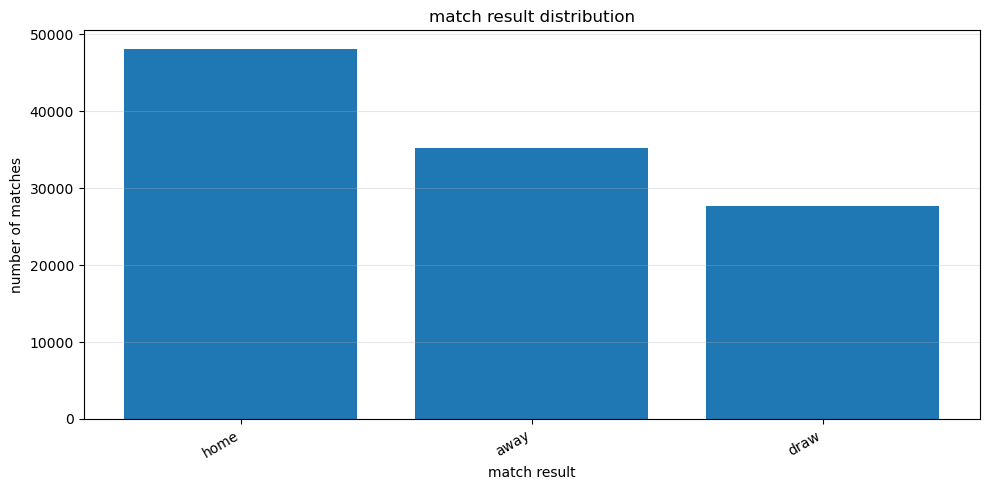

majority class:home
majority baseline accuracy :0.4337
Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\class_balance_report.json


,majority_class,majority_baseline_accuracy,number_of_classes,target_missing_count,total_rows,valid_target_rows
0,home,0.433693,3,0,110938,110938


In [30]:
target_values = prepare_categorical_series(df_eda[TARGET_COL])

target_counts = target_values.value_counts(dropna=False)
target_percentage = target_values.value_counts(normalize=True,dropna=False).mul(100).round(2)



target_distribution = pd.DataFrame({
    'count': target_counts,
    'percentage': target_percentage
})

target_distribution.index.name = TARGET_COL


print('Target distribution')
print('*'*60)

display(target_distribution)

safe_save_csv(
    target_distribution.reset_index(),
    'target_distribution.csv',
    index=False
)

plot_bar(
    target_distribution['count'],
    title='match result distribution',
    xlabel='match result',
    ylabel='number of matches',
    filename='01_match_result_distribution.png',
    rotation=30
)

valid_target_values = df_eda[TARGET_COL].dropna()


if len(valid_target_values) >0 :
    valid_target_counts = valid_target_values.value_counts()
    
    
    majority_class = valid_target_counts.idxmax()
    majority_baseline_acccuracy = valid_target_counts.max()/ len(valid_target_values)
    
    print(f'majority class:{majority_class}')
    print(f'majority baseline accuracy :{majority_baseline_acccuracy:.4f}')
    
    
    class_balance_report = {
        'majority_class': str(majority_class),
        'majority_baseline_accuracy': float(majority_baseline_acccuracy),
        'number_of_classes':int(valid_target_counts.nunique()),
        'target_missing_count': int(df_eda[TARGET_COL].isna().sum()),
        'total_rows': int(len(df_eda)),
        'valid_target_rows': int(len(valid_target_values))
    }
    
    
    safe_save_json(class_balance_report,'class_balance_report.json')
    
    display(pd.DataFrame([class_balance_report]))
    
else:
    raise ValueError('target  column has no valid non-missing values')

fixture date analysis
********************************************************************************
original non-null fixture_date values: 110,938
successfully parsed fixture_date values :110,938
fixture date parse success:100.00%
minimum fixture date: 2019-12-01 00:45:00
maximum fixture date: 2021-05-01 00:00:00

matches by year


,year,matches_count
0,2019,6105
1,2020,71588
2,2021,33245


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\yearly_match_counts.csv
Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\monthly_match_counts.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\02_matches_by_year.png


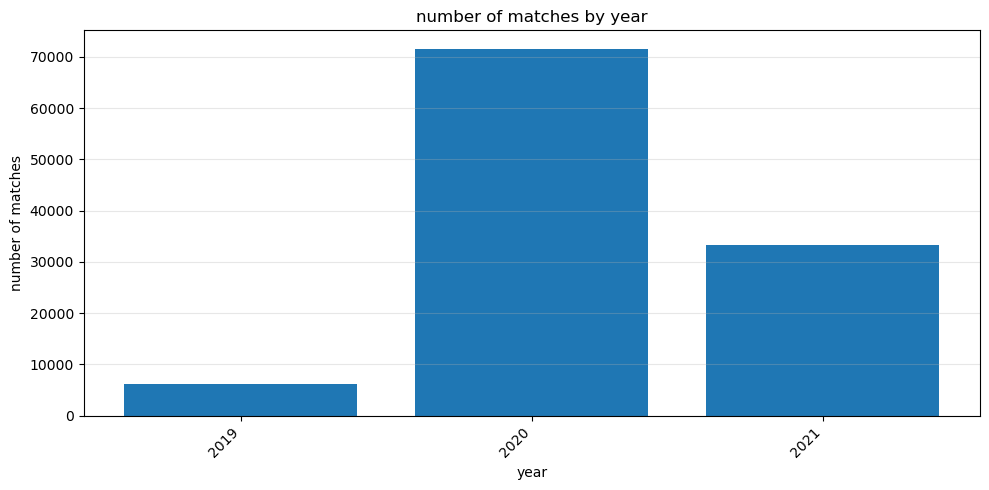

saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\03_matches_by_month.png


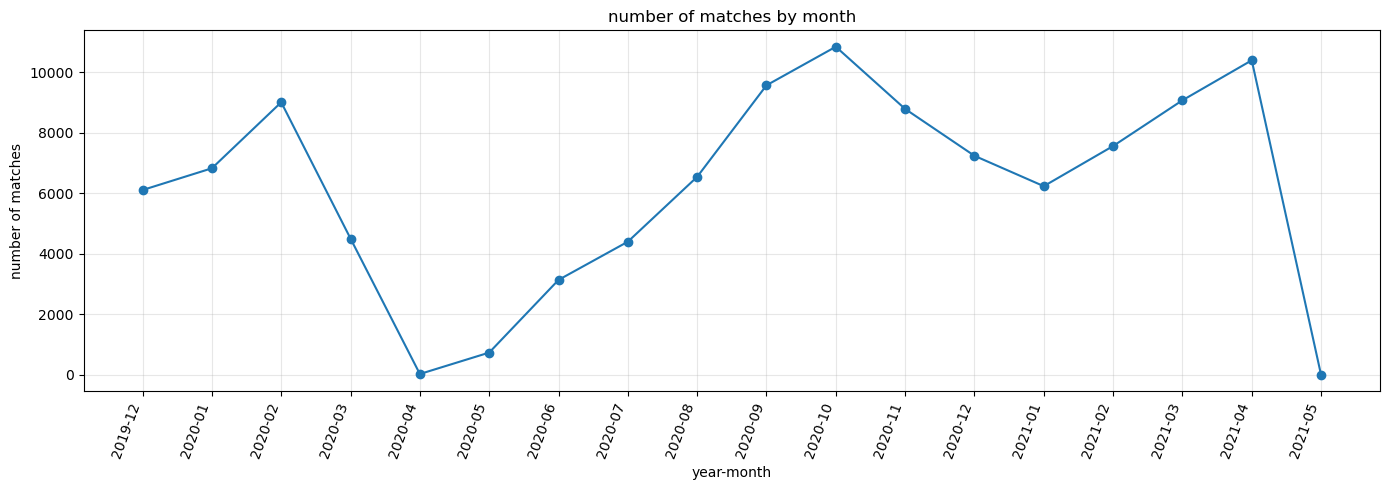

In [31]:

eda_df = df.copy()

if 'fixture_date' in eda_df.columns:
    eda_df['fixture_date_parsed'] = pd.to_datetime(
        eda_df['fixture_date'], errors='coerce'
    )
    
    original_non_null_dates = eda_df['fixture_date'].notna().sum()
    parsed_non_null_dates = eda_df['fixture_date_parsed'].notna().sum()
    
    
    if original_non_null_dates > 0:
        date_parse_success = parsed_non_null_dates / original_non_null_dates*100
    else:
        date_parse_success = 0
        
        
    print('fixture date analysis')
    print('*'*80)
    
    print(f'original non-null fixture_date values: {original_non_null_dates:,}')
    print(f'successfully parsed fixture_date values :{parsed_non_null_dates:,}')
    print(f'fixture date parse success:{date_parse_success:.2f}%')
    print(f'minimum fixture date: {eda_df['fixture_date_parsed'].min()}')
    print(f'maximum fixture date: {eda_df['fixture_date_parsed'].max()}')
    
    
    eda_df['fixture_year'] = eda_df['fixture_date_parsed'].dt.year
    eda_df['fixture_month'] = eda_df['fixture_date_parsed'].dt.month
    eda_df['fixture_year_month'] = eda_df['fixture_date_parsed'].dt.to_period('M').astype(str)
    
    
    valid_date_df = eda_df[eda_df['fixture_date_parsed'].notna()].copy()
    
    
    yearly_match_counts = (
        valid_date_df['fixture_year'].astype(int).value_counts().sort_index()
    )
    
    monthly_match_counts = (valid_date_df['fixture_year_month'].value_counts().sort_index())
    
    
    yearly_match_counts.name = 'matches_count'
    monthly_match_counts.name = 'matches_count'
    
    yearly_match_counts.index.name = 'year'
    monthly_match_counts.index.name = 'year_month'
    
    print("\nmatches by year")
    display(yearly_match_counts.reset_index())
    
    safe_save_csv(
            yearly_match_counts.reset_index(),
            'yearly_match_counts.csv',
            index=False
    )
    
    safe_save_csv(
        monthly_match_counts.reset_index(),
        'monthly_match_counts.csv',
        index=False
    )
    
    
    plot_bar(
        yearly_match_counts,
        title='number of matches by year',
        xlabel='year',
        ylabel='number of matches',
        filename='02_matches_by_year.png',
        rotation=45
    )
    
    
    
    if len(monthly_match_counts) <= 120:
        plot_line(
                monthly_match_counts,
                title='number of matches by month',
                xlabel='year-month',
                ylabel='number of matches',
                filename='03_matches_by_month.png',
                rotation=70,
                figsize=(14,5)
        )
    else:
        print("Monthly plot skipped because there are too many months to display clearly.")
else:
        print("fixture_date column does not exist. Skipping date analysis ")    

Competition distribution
------------------------------------------------------------


,matches_count,percentage
competition,,
Premier League,5565,5.02
Club Friendlies,3724,3.36
Primera Division,2369,2.14
Super League,1530,1.38
3. Liga,1327,1.20
Ligue 1,1210,1.09
Championship,1097,0.99
League One,1050,0.95
Superliga,1048,0.94


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\competition_counts.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\04_top_competitions.png


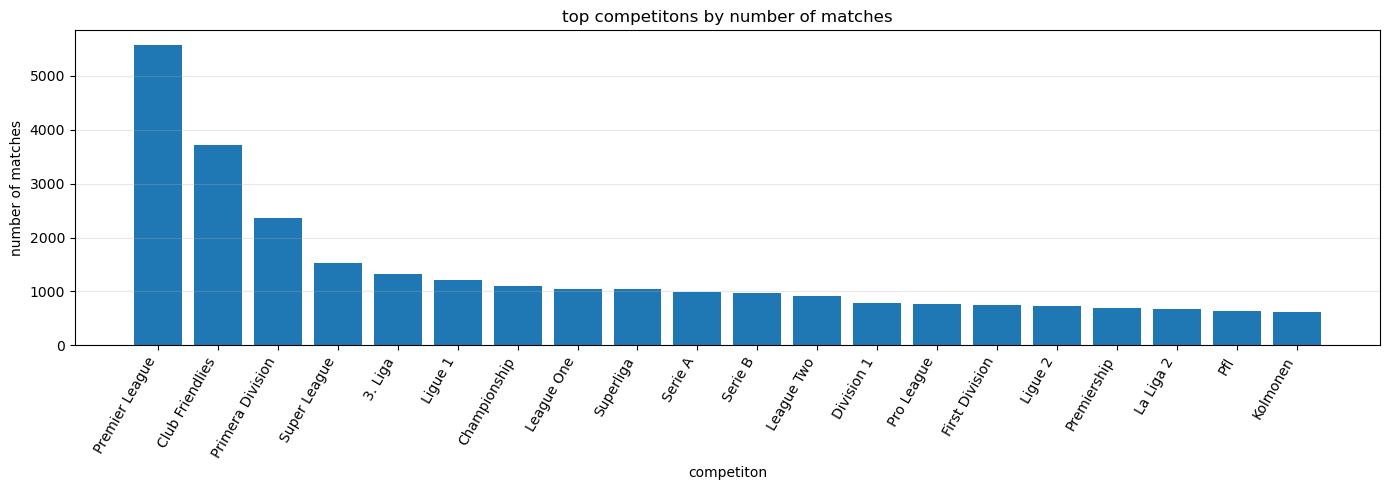


minimum matches required per competition : 554


match_result,away,draw,home,row_count
competition,,,,
Premier League,32.94,26.59,40.47,5565
Club Friendlies,31.23,22.72,46.05,3724
Primera Division,27.73,29.59,42.68,2369
Super League,28.63,28.56,42.81,1530
3. Liga,33.84,24.49,41.67,1327
Ligue 1,29.42,29.67,40.91,1210
Championship,33.55,26.34,40.11,1097
League One,31.81,25.90,42.29,1050
Superliga,31.87,25.76,42.37,1048


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\competition_target_distribution.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\05_target_distribution_by_competition.png


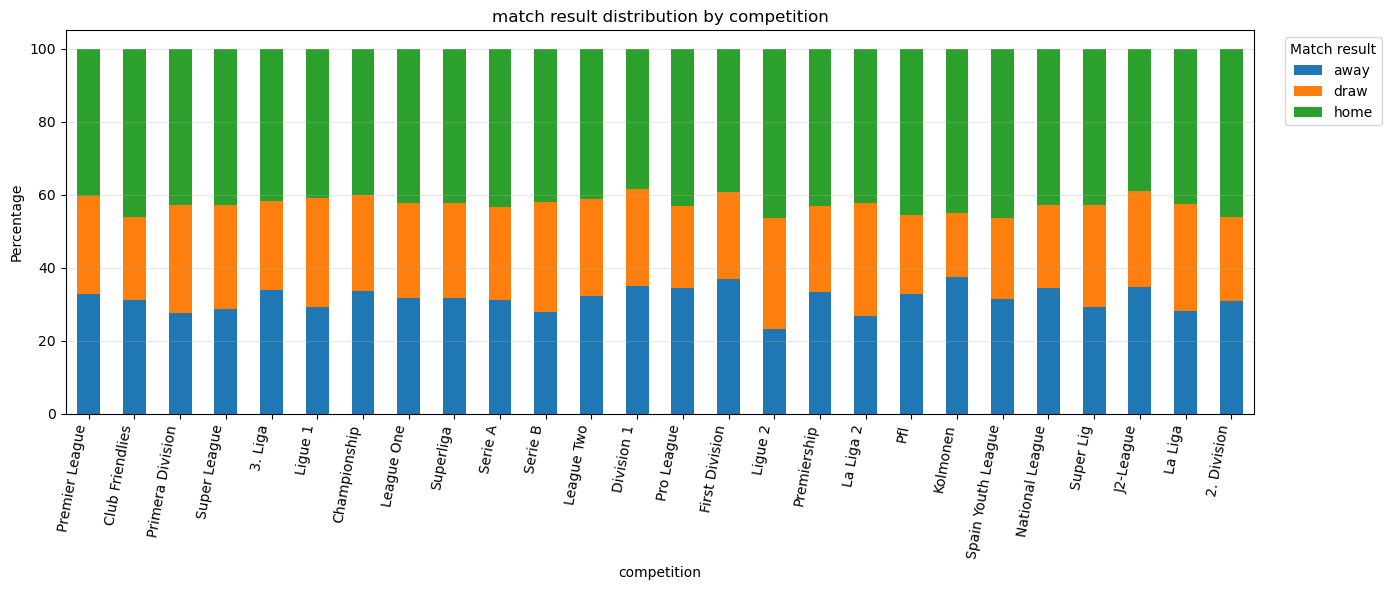

In [32]:
if 'competition' in eda_df.columns:
    competition_values = prepare_categorical_series(eda_df['competition'])
    
    competition_counts = competition_values.value_counts(dropna=False)
    competition_percentage = competition_values.value_counts(normalize=True,dropna=False).mul(100).round(2)
    
    competition_summary = pd.DataFrame({
        'matches_count': competition_counts,
        'precentage': competition_percentage
    })
    
    competition_summary = pd.DataFrame({
        'matches_count': competition_counts,
        'percentage': competition_percentage
    })
    
    
    competition_summary.index.name = 'competition'
    
    print('Competition distribution')
    print('-'*60)
    
    display(competition_summary.head(30))
    
    safe_save_csv(
            competition_summary.reset_index(),
            'competition_counts.csv',
            index=False
    )
    
    plot_bar(
        competition_counts.head(20),
        title='top competitons by number of matches',
        xlabel='competiton',
        ylabel='number of matches',
        filename='04_top_competitions.png',
        rotation=60,
        figsize=(14,5)
    )
    
    min_competition_count = max(20,int(len(eda_df)*0.005))
    
    competition_target_distribution = target_distribution_by_group(
        eda_df,group_col='competition',min_count=min_competition_count,target_col =TARGET_COL
    )
    
    
    print(f'\nminimum matches required per competition : {min_competition_count:,}')
    
    
    if not competition_target_distribution.empty:
        display(competition_target_distribution.head(30))
        
        safe_save_csv(
            competition_target_distribution.reset_index().rename(columns={'index':'competition'}),
            'competition_target_distribution.csv',
            index=False
        )
        
        plot_stacked_percentage(
            competition_target_distribution.drop(columns=['row_count']).head(30),
            title='match result distribution by competition',
            xlabel= 'competition',
            filename='05_target_distribution_by_competition.png',
            rotation=80,
            figsize=(14,6)
        )
    else:
        print('no competition group has enough records for target distribution analysis')
else:
    print("competition column does not exist. Skipping competition analysis.")

cup game distribution
------------------------------------------------------------


,count,percentage
cup_game,,
False,101856,91.81
True,9081,8.19
missing,1,0.00


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\cup_game_distribution.csv

 target distribution by cup game:


match_result,away,draw,home
cup_game,,,
False,31.35,25.24,43.41
True,35.70,21.41,42.89
missing,100.00,0.00,0.00


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\cup_game_target_distribution.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\06_target_distribution_by_cup_game.png


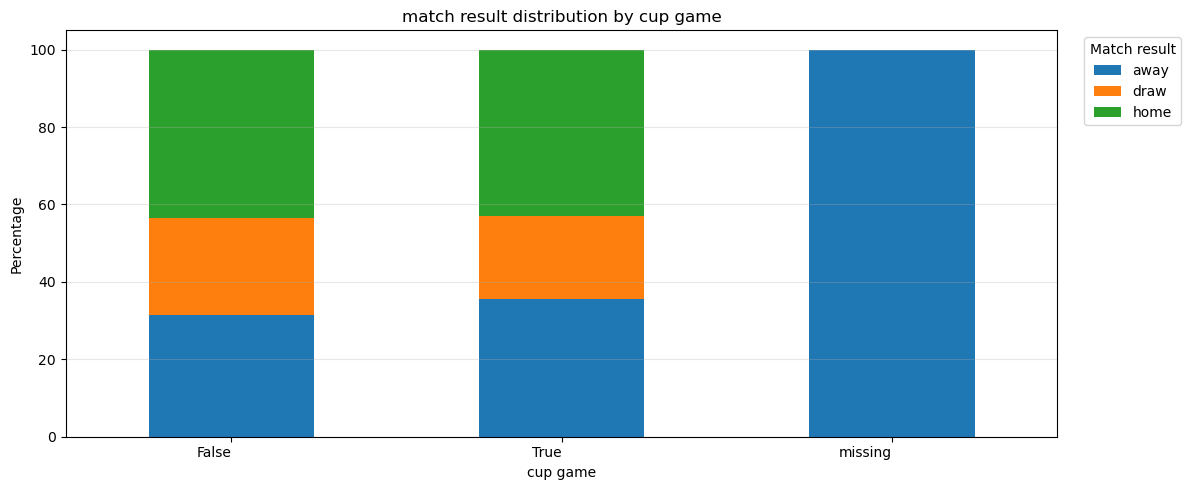

In [33]:
if 'cup_game' in eda_df.columns:
    cup_values = prepare_categorical_series(eda_df['cup_game'])
    
    
    cup_counts = cup_values.value_counts(dropna=False)
    cup_percentages = cup_values.value_counts(normalize=True,dropna=False).mul(100).round(2)
    
    
    cup_summary = pd.DataFrame({
        'count': cup_counts,
        'percentage': cup_percentages
    })
    
    cup_summary.index.name ='cup_game'
    
    print('cup game distribution')
    print('-'*60)
    
    display(cup_summary)
    
    
    safe_save_csv(
        cup_summary.reset_index(),
        'cup_game_distribution.csv',
        index=False
    )
    
    
    cup_target_distribution = crosstab_percentage(
        eda_df,
        row_col='cup_game',
        target_col=TARGET_COL
    )
    
    print('\n target distribution by cup game:')
    display(cup_target_distribution)
    
    
    safe_save_csv(
        cup_target_distribution.reset_index().rename(columns={'index':'cup_game'}),'cup_game_target_distribution.csv',index=False
    )
    
    
    plot_stacked_percentage(
        cup_target_distribution,
        title='match result distribution by cup game',
        xlabel='cup game',
        filename='06_target_distribution_by_cup_game.png',
        rotation=0
    )
    
else:
    print("cup_game column does not exist  Skipping cup game analysis ")

home club  distribution
------------------------------------------------------------


,home_matches,percentage
home_club,,
Al Ittihad,91,0.08
River Plate,71,0.06
Rangers,64,0.06
Liverpool,63,0.06
Al Ahli,62,0.06
Juventus,61,0.05
Independiente,60,0.05
Internacional,59,0.05
Olimpia,58,0.05


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\home_club_counts.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\07_top_home_clubs.png


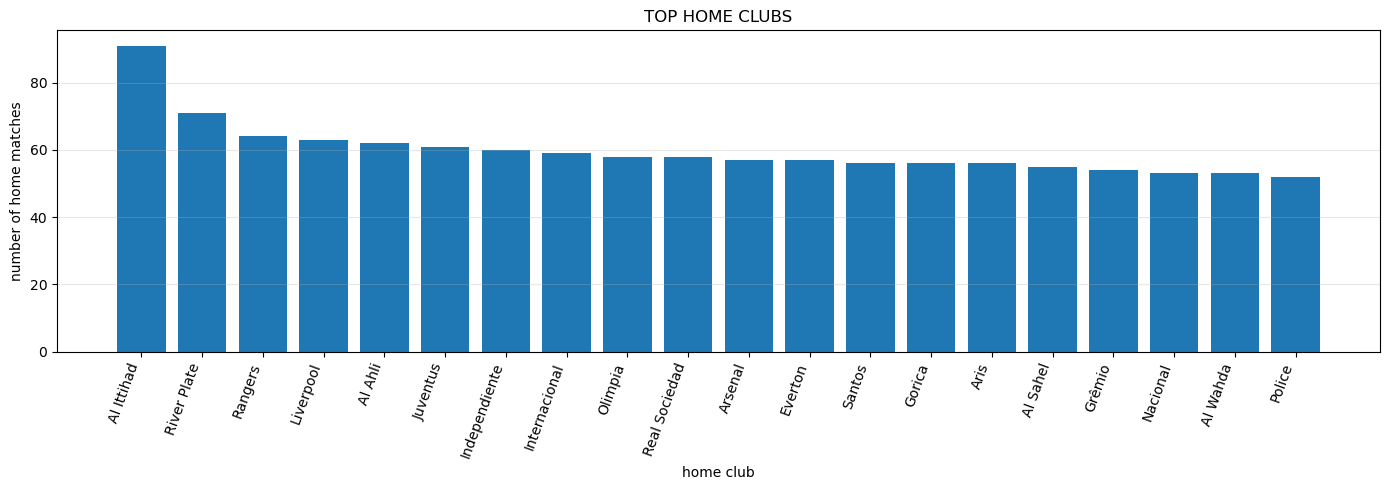


away club distribution
--------------------------------------------------------------------------------


,away_matches,percentage
away_club,,
Al Ittihad,82,0.07
River Plate,77,0.07
Liverpool,65,0.06
Rangers,64,0.06
Al Ahli,64,0.06
Olimpia,63,0.06
Arsenal,59,0.05
Real Sociedad,58,0.05
Santos,57,0.05


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\away_club_counts.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\08_top_away_clubs.png


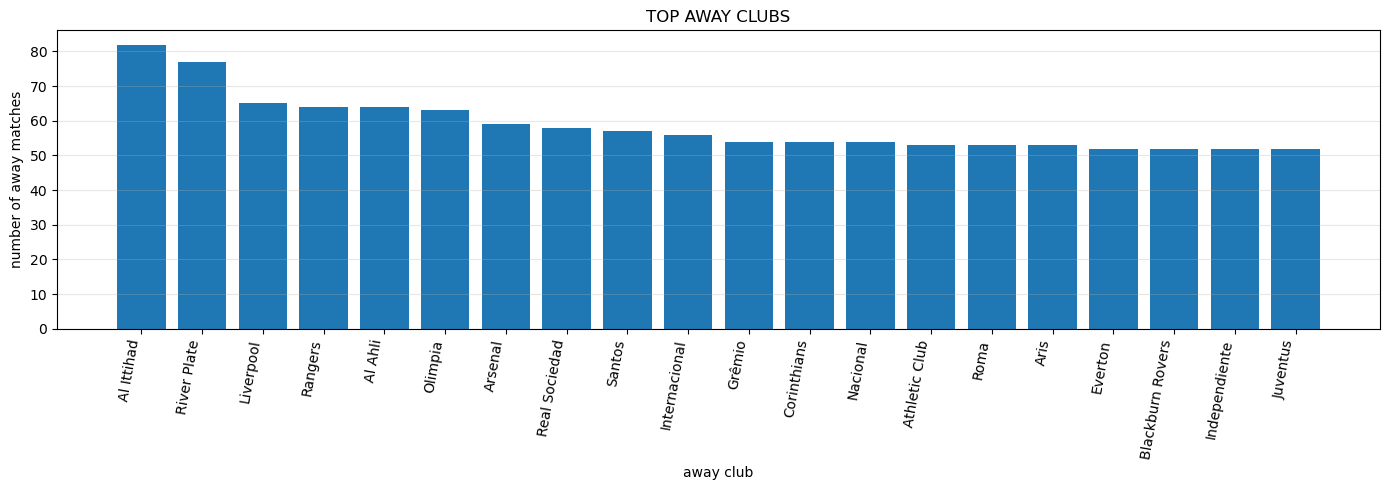


 combined club coverage
----------------------------------------------------------------------


,total_appearances,percentage
club,,
Al Ittihad,173,0.08
River Plate,148,0.07
Liverpool,128,0.06
Rangers,128,0.06
Al Ahli,126,0.06
Olimpia,121,0.05
Real Sociedad,116,0.05
Arsenal,116,0.05
Internacional,115,0.05


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\combined_club_coverage.csv
unique clubs : 10,215
clubs with fewer than 5 appearances :1,533
clubs with fewer than 10 appearances :3,263
median club appearances : 16.00
Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\club_coverage_report.json


In [34]:
if 'home_club' in eda_df.columns:
    home_club_values = prepare_categorical_series(eda_df['home_club'])
    
    home_club_counts = home_club_values.value_counts(dropna=False)
    home_club_percentages = home_club_values.value_counts(normalize=True,dropna=False).mul(100).round(2)
    
    
    home_club_summary = pd.DataFrame({
        'home_matches': home_club_counts,
        'percentage': home_club_percentages
    })
    
    home_club_summary.index.name = 'home_club'
    
    print('home club  distribution')
    print('-'*60)
    
    
    display(home_club_summary.head(30))
    
    
    safe_save_csv(
        home_club_summary.reset_index(),
        'home_club_counts.csv',
        index=False
    )
    
    
    plot_bar(
        home_club_counts.head(20),
        title= 'TOP HOME CLUBS',
        xlabel='home club',
        ylabel='number of home matches',
        filename='07_top_home_clubs.png',
        rotation= 70,
        figsize=(14,5)
    )
    
else:
    print('home club column does not exist  skipping home club analysis')


if 'away_club' in eda_df.columns:
    away_club_values = prepare_categorical_series(eda_df['away_club'])
    
    away_club_counts = away_club_values.value_counts(dropna=False)
    away_club_percentages = away_club_values.value_counts(normalize=True,dropna=False).mul(100).round(2)
    
    
    away_club_summary = pd.DataFrame({
        'away_matches': away_club_counts,
        'percentage': away_club_percentages
    })
    
    away_club_summary.index.name = 'away_club'
    
    print('\naway club distribution')
    print('-'*80)
    
    display(away_club_summary.head(30))
    
    safe_save_csv(
        away_club_summary.reset_index(),
        'away_club_counts.csv',
        index=False
    )
    
    plot_bar(
        away_club_counts.head(20),
        title='TOP AWAY CLUBS',
        xlabel= 'away club',
        ylabel= 'number of away matches',
        filename='08_top_away_clubs.png',
        rotation=80,
        figsize=(14,5)
    )
else:
    print('away club columns does not exist skipping away club analysis')
    

if 'home_club' in eda_df.columns and 'away_club' in eda_df.columns:
    combined_clubs = pd.concat(
        [
            prepare_categorical_series(eda_df['home_club']),
            prepare_categorical_series(eda_df['away_club'])
        ],
        axis=0,
        ignore_index=True
    )
    
    combined_club_counts = combined_clubs.value_counts(dropna=False)
    combined_club_percentages = combined_clubs.value_counts(normalize=True,dropna=False).mul(100).round(2)
    
    
    combined_club_summary = pd.DataFrame({
        'total_appearances': combined_club_counts,
        'percentage': combined_club_percentages
    })
    
    combined_club_summary.index.name = 'club'
    print('\n combined club coverage')
    print('-'*70)
    
    
    display(combined_club_summary.head(30))
    
    safe_save_csv(
            combined_club_summary.reset_index(),
            'combined_club_coverage.csv',
            index=False
    )
    
    rare_clubs_less_5 = int((combined_club_counts <5).sum())
    rare_clubs_less_10 = int((combined_club_counts<10).sum())
    
    
    club_coverage_report = {
        'unique_clubs': int(combined_club_counts.shape[0]),
        'clubs_with_fewer_than_5_appearances': rare_clubs_less_5,
        'clubs_with_fewer_than_10_appearances': rare_clubs_less_10,
        'max_club_appearances': int(combined_club_counts.max()),
        'median_club_appearances': float(combined_club_counts.median())
    }
    
    
    print(f'unique clubs : {club_coverage_report['unique_clubs']:,}')
    print(f'clubs with fewer than 5 appearances :{rare_clubs_less_5:,}')
    print(f'clubs with fewer than 10 appearances :{rare_clubs_less_10:,}')
    print(f'median club appearances : {club_coverage_report['median_club_appearances']:.2f}')
    
    
    safe_save_json(
        club_coverage_report,'club_coverage_report.json'
    )
else:
    print('home club and away_club columns are not both available skipping combined club analysis')

relevent missing values analysis
--------------------------------------------------------------------------------


,column,missing_count,missing_percentage,dtype,unique_count
179,away_club_recent_manager_id_10,27129,24.45,float64,7936
89,home_club_recent_manager_id_10,26653,24.03,float64,7891
178,away_club_recent_manager_id_9,26150,23.57,float64,8044
88,home_club_recent_manager_id_9,25733,23.20,float64,8002
177,away_club_recent_manager_id_8,25219,22.73,float64,8144
87,home_club_recent_manager_id_8,24869,22.42,float64,8150
176,away_club_recent_manager_id_7,24377,21.97,float64,8303
86,home_club_recent_manager_id_7,23980,21.62,float64,8265
175,away_club_recent_manager_id_6,23525,21.21,float64,8440
85,home_club_recent_manager_id_6,23258,20.96,float64,8385


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\relevant_missing_values.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\09_top_relevant_missing_values.png


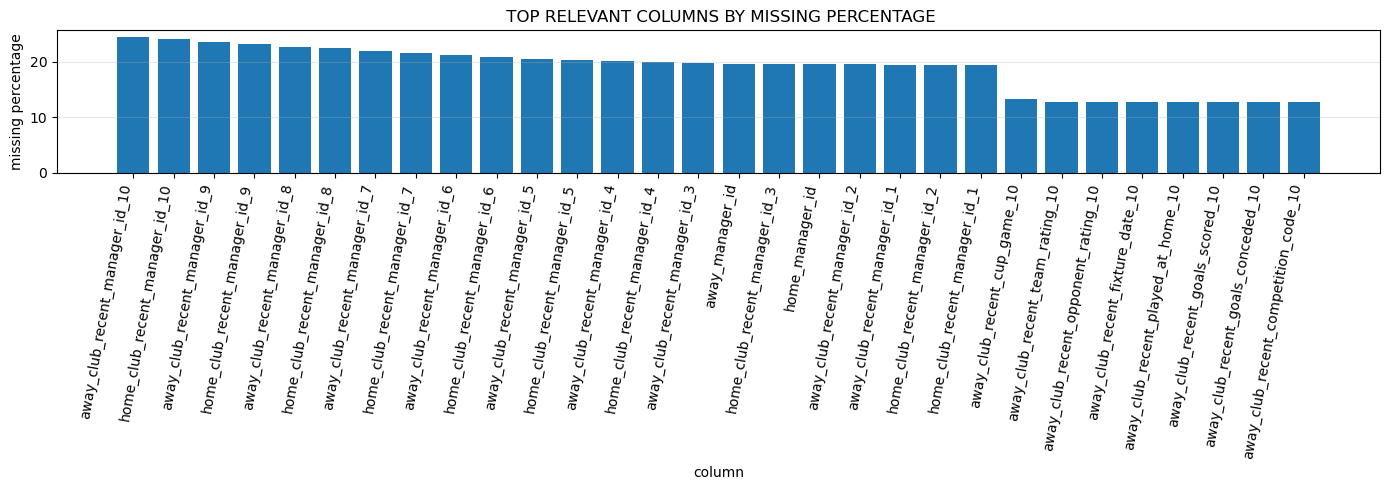

In [35]:
recent_columns_info_eda = recent_pattern_info(eda_df)

recent_cols = (
    recent_columns_info_eda['column'].tolist()
    if not recent_columns_info_eda.empty
    else []
)

main_existing_cols = [col for col in MAIN_MATCH_COLUMNS if col in eda_df.columns]

relevant_columns = list(dict.fromkeys(main_existing_cols+recent_cols))

print('relevent missing values analysis')
print('-'*80)


if len(relevant_columns) == 0:
    relevant_missing_summary = pd.DataFrame()
    print('no relevant columns were found for missing-value analysis')

else:
    relevant_missing_summary  = pd.DataFrame({
        'column': relevant_columns,
        'missing_count': [int(eda_df[col].isna().sum() ) for col in relevant_columns],
        'missing_percentage': [round(eda_df[col].isna().mean()*100,2) for col in relevant_columns],
        'dtype': [str(eda_df[col].dtype) for col in relevant_columns],
        'unique_count':[int(eda_df[col].nunique(dropna=True)) for col in relevant_columns]
    })
    
    relevant_missing_summary = relevant_missing_summary.sort_values(
        ['missing_percentage','missing_count'],
        ascending=[False,False]
    )
    
    display(relevant_missing_summary.head(30))
    
    safe_save_csv(
        relevant_missing_summary,
        'relevant_missing_values.csv',
        index = False
    )
    
    top_missing_relevant = (
        relevant_missing_summary[relevant_missing_summary['missing_count']>0].head(30)
    )
    
    if not top_missing_relevant.empty:
        plot_bar( 
                top_missing_relevant.set_index('column')['missing_percentage'],
                title =' TOP RELEVANT COLUMNS BY MISSING PERCENTAGE',
                xlabel='column',
                ylabel='missing percentage',
                filename= '09_top_relevant_missing_values.png',
                rotation=80,
                figsize=(14,5)
                )
    else:
        print('no missing values were found in relevant columns')

In [36]:
print('recent-history columns analysis')
print('-'*80)

recent_columns_info_eda = recent_pattern_info(eda_df)

print(f'number of detected recent_history columns : {len(recent_columns_info_eda)}')

if not recent_columns_info_eda.empty:
    recent_columns_info_eda = recent_columns_info_eda.sort_values(
        ['club_side','feature','recent_number']
    )
    
    display(recent_columns_info_eda.head(30))
    
    safe_save_csv(
        recent_columns_info_eda,
        'recent_colunmns_info_eda.csv',
        index=False
    )
    
    
    recent_feature_availability = (
        recent_columns_info_eda
        .groupby(['club_side','feature'])
        .agg(
            deteceted_lags= ('recent_number',lambda x: sorted(set(x))),
            deteceted_count=('recent_number','unique'),
            avg_missing_percentage = ('missing_percentage','mean'),
            max_missing_percentage = ('missing_percentage','max'),
            avg_unique_count = ('unique_count','mean')
        )
        .reset_index()
        .sort_values(['club_side','feature'])
    )
    
    
    recent_feature_availability['avg_missing_percentage']= (
        recent_feature_availability['avg_missing_percentage'].round(2)
    )
    
    recent_feature_availability['max_missing_percentage'] = (
        recent_feature_availability['max_missing_percentage'].round(2)
    )
    recent_feature_availability['avg_unique_count'] = (
        recent_feature_availability['avg_unique_count'].round(2)
    )
    
    print('\n recent feature availability: ')
    display(recent_feature_availability)
    
    
    safe_save_csv(
        recent_feature_availability,
        'recent_feature_availability.csv',
        index=False
    )
    
    
    expected_lags  = set(range(1,11))
    completeness_rows  = []
    
    
    for (club_side, feature) , group  in recent_columns_info_eda.groupby(['club_side','feature']):
        detected_lags  = set(group['recent_number'].tolist())
        
        completeness_rows.append({
            'club_side':club_side,
            'feature': feature,
            'expected_lags': sorted(detected_lags),
            'detected_lags': len(detected_lags),
            'missing_lags': sorted(expected_lags - detected_lags),
            'extra_lags': sorted(detected_lags - expected_lags),
            'is_complete_1_to_10': detected_lags == expected_lags
        })
        
    recent_completeness = (
        pd.DataFrame(completeness_rows).sort_values(['club_side','feature'])
    )
    
    print('\n recent-history lag completeneess')
    display(recent_completeness)
    
    safe_save_csv(
        recent_completeness,
        'recent_history_completeness.csv',
        index=False
    )
    
    incomplete_recent_features = recent_completeness[~recent_completeness['is_complete_1_to_10']]
    
    if len(incomplete_recent_features) == 0:
        print('all detected recent-history features are complete from lag 1 to lag 10')
        
    else:
        print('warning --> some recent history features are incomplete')
        display(incomplete_recent_features)
        
        
else:
    recent_feature_availability = pd.DataFrame()
    recent_completeness = pd.DataFrame()
    print('no recent-history columns were found')

recent-history columns analysis
--------------------------------------------------------------------------------
number of detected recent_history columns : 180


,column,club_side,feature,recent_number,dtype,missing_count,missing_percentage,unique_count
170,away_club_recent_competition_code_1,away_club,competition_code,1,float64,1226,1.11,864
171,away_club_recent_competition_code_2,away_club,competition_code,2,float64,2593,2.34,856
172,away_club_recent_competition_code_3,away_club,competition_code,3,float64,4034,3.64,854
173,away_club_recent_competition_code_4,away_club,competition_code,4,float64,5516,4.97,850
174,away_club_recent_competition_code_5,away_club,competition_code,5,float64,7000,6.31,836
175,away_club_recent_competition_code_6,away_club,competition_code,6,float64,8426,7.60,828
176,away_club_recent_competition_code_7,away_club,competition_code,7,float64,9867,8.89,821
177,away_club_recent_competition_code_8,away_club,competition_code,8,float64,11295,10.18,808
178,away_club_recent_competition_code_9,away_club,competition_code,9,float64,12762,11.50,791
179,away_club_recent_competition_code_10,away_club,competition_code,10,float64,14216,12.81,777


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_colunmns_info_eda.csv

 recent feature availability: 


,club_side,feature,deteceted_lags,deteceted_count,avg_missing_percentage,max_missing_percentage,avg_unique_count
0,away_club,competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6.94,12.81,828.5
1,away_club,cup_game,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",7.22,13.36,2.0
2,away_club,fixture_date,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6.94,12.81,19651.7
3,away_club,goals_conceded,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6.94,12.81,15.6
4,away_club,goals_scored,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6.94,12.81,16.9
5,away_club,manager_id,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",21.35,24.45,8485.7
6,away_club,opponent_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6.94,12.82,97015.8
7,away_club,played_at_home,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6.94,12.81,2.0
8,away_club,team_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6.94,12.82,97057.5
9,home_club,competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",6.54,12.22,831.3


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_feature_availability.csv

 recent-history lag completeneess


,club_side,feature,expected_lags,detected_lags,missing_lags,extra_lags,is_complete_1_to_10
0,away_club,competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
1,away_club,cup_game,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
2,away_club,fixture_date,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
3,away_club,goals_conceded,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
4,away_club,goals_scored,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
5,away_club,manager_id,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
6,away_club,opponent_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
7,away_club,played_at_home,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
8,away_club,team_rating,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True
9,home_club,competition_code,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,[],[],True


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_history_completeness.csv
all detected recent-history features are complete from lag 1 to lag 10


In [37]:
print('recent fixture data leakage check')
print('-'*80)

leakage_date_rows = []
violation_examples = []


if 'fixture_date_parsed' not in eda_df.columns and 'fixture_date' in eda_df.columns:
    eda_df['fixture_date_parsed'] = pd.to_datetime(
        eda_df['fixture_date'],
        errors='coerce'
    )
    
    

if 'fixture_date_parsed' in eda_df.columns:
    
    current_dates = eda_df['fixture_date_parsed']
    
    for side in ['home_club','away_club']:
        recent_date_cols = get_recent_columns(
            side,
            'fixture_date',
            numbers=range(1,11),
            dataframe=eda_df
        )
        
        
        for col in recent_date_cols:
            recent_dates = pd.to_datetime(eda_df[col],errors='coerce')
            
            valid_mask = current_dates.notna() & recent_dates.notna()
            violation_mask = valid_mask & (recent_dates >= current_dates)
            
            valid_comparisons = int(valid_mask.sum())
            violation_count = int(violation_mask.sum())
            
            
            leakage_date_rows.append({
                'column': col,
                'side': side,
                'valid_comparisons': valid_comparisons,
                'violation_count': violation_count,
                'violation_percentage':(
                    round(violation_count/valid_comparisons *100,4)
                    if valid_comparisons>0
                    else np.nan
                ),
                
                'min_recent_date':recent_dates.min(),
                'max_recent_date': recent_dates.max()
            })
            
            
            if violation_count > 0:
                example_cols  = []
                
                if ID_COL in eda_df.columns:
                    example_cols.append(ID_COL)
                    
                example_cols += ['fixture_date_parsed',col]
                
                temp_examples = eda_df.loc[violation_mask,example_cols].copy()
                temp_examples['violation_column'] = col
                temp_examples = temp_examples.rename(columns={
                    'fixture_date_parsed': 'current_fixture_date',
                    col : 'recent_fixture_date'
                })                    
                
                
                violation_examples.append(temp_examples.head(5))
                
    recent_date_leakage_check = pd.DataFrame(leakage_date_rows)
    
    if not recent_date_leakage_check.empty:
        recent_date_leakage_check = recent_date_leakage_check.sort_values(
            ['violation_count','violation_percentage'],
            ascending=[False,False]
        )
        
    display(recent_date_leakage_check)
    
    safe_save_csv(
        recent_date_leakage_check,
        'recent_fixture_date_leakage_check.csv',
        index=False
    )    
    
    total_violations  = (
        int(recent_date_leakage_check['violation_count'].sum())
        if not recent_date_leakage_check.empty
        else 0
    )
    
    
    print(f'total recent-date leakage violation :{total_violations :,}')
    
    
    if total_violations >0:
        print('warning -> some recent fixture dates are not before the current fixture date')
        print('these rows must be investigated before modeling')
        
        
        recent_date_violation_examples = pd.concat(
            violation_examples,
            axis=0,
            ignore_index=True
        ) if violation_examples  else pd.DataFrame()
        
        
        if not recent_date_violation_examples.empty:
            display(recent_date_violation_examples.head(40))
            
            safe_save_csv(
                recent_date_violation_examples,
                'recent_fixture_date_violation_examples.csv',
                index= False
            )
    else:
        
        recent_date_violation_examples = pd.DataFrame()
        print('no date leakage was detected based on recent fixture dates')
        

else:
    recent_date_leakage_check = pd.DataFrame()
    recent_date_violation_examples = pd.DataFrame()
    print('current fixture_date could not be parsed skipping recent-date leakage check')

recent fixture data leakage check
--------------------------------------------------------------------------------


,column,side,valid_comparisons,violation_count,violation_percentage,min_recent_date,max_recent_date
0,home_club_recent_fixture_date_1,home_club,109779,0,0.0,2019-01-04 14:00:00,2021-04-28 23:00:00
1,home_club_recent_fixture_date_2,home_club,108487,0,0.0,2019-01-05 02:30:00,2021-04-25 23:00:00
2,home_club_recent_fixture_date_3,home_club,107165,0,0.0,2019-01-03 15:45:00,2021-04-23 23:00:00
3,home_club_recent_fixture_date_4,home_club,105837,0,0.0,2019-01-03 15:45:00,2021-04-22 00:00:00
4,home_club_recent_fixture_date_5,home_club,104461,0,0.0,2019-01-03 15:45:00,2021-04-18 23:00:00
5,home_club_recent_fixture_date_6,home_club,103042,0,0.0,2019-01-04 22:30:00,2021-04-17 01:00:00
6,home_club_recent_fixture_date_7,home_club,101643,0,0.0,2019-01-02 16:00:00,2021-04-15 00:30:00
7,home_club_recent_fixture_date_8,home_club,100219,0,0.0,2019-01-03 23:30:00,2021-04-08 00:30:00
8,home_club_recent_fixture_date_9,home_club,98802,0,0.0,2019-01-02 16:00:00,2021-04-03 14:00:00
9,home_club_recent_fixture_date_10,home_club,97379,0,0.0,2019-01-04 11:30:00,2021-03-30 18:45:00


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_fixture_date_leakage_check.csv
total recent-date leakage violation :0
no date leakage was detected based on recent fixture dates


recent numeric feature by lag
--------------------------------------------------------------------------------


,side,feature,lag,column,non_missing_count,missing_percentage,mean,median,std,min,max,q01,q25,q75,q99
0,home_club,goals_conceded,1,home_club_recent_goals_conceded_1,109779,1.04,1.4236,1.0000,1.3501,0.0000,18.0000,0.0000,0.0000,2.0000,6.0000
1,home_club,goals_conceded,2,home_club_recent_goals_conceded_2,108487,2.21,1.3469,1.0000,1.3124,0.0000,18.0000,0.0000,0.0000,2.0000,5.0000
2,home_club,goals_conceded,3,home_club_recent_goals_conceded_3,107165,3.40,1.3762,1.0000,1.3198,0.0000,14.0000,0.0000,0.0000,2.0000,6.0000
3,home_club,goals_conceded,4,home_club_recent_goals_conceded_4,105837,4.60,1.3565,1.0000,1.3093,0.0000,18.0000,0.0000,0.0000,2.0000,6.0000
4,home_club,goals_conceded,5,home_club_recent_goals_conceded_5,104461,5.84,1.3672,1.0000,1.3096,0.0000,18.0000,0.0000,0.0000,2.0000,5.0000
5,home_club,goals_conceded,6,home_club_recent_goals_conceded_6,103042,7.12,1.3591,1.0000,1.3063,0.0000,18.0000,0.0000,0.0000,2.0000,5.0000
6,home_club,goals_conceded,7,home_club_recent_goals_conceded_7,101643,8.38,1.3587,1.0000,1.2935,0.0000,15.0000,0.0000,0.0000,2.0000,5.0000
7,home_club,goals_conceded,8,home_club_recent_goals_conceded_8,100219,9.66,1.3564,1.0000,1.2932,0.0000,18.0000,0.0000,0.0000,2.0000,5.0000
8,home_club,goals_conceded,9,home_club_recent_goals_conceded_9,98802,10.94,1.3483,1.0000,1.2890,0.0000,14.0000,0.0000,0.0000,2.0000,5.0000
9,home_club,goals_conceded,10,home_club_recent_goals_conceded_10,97379,12.22,1.3573,1.0000,1.2870,0.0000,14.0000,0.0000,0.0000,2.0000,5.0000


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_numeric_stats_by_lag.csv

 mean recent {feature} by lag:


side,away_club,home_club
lag,,
1,1.3232,1.4236
2,1.3940,1.3469
3,1.3582,1.3762
4,1.3747,1.3565
5,1.3596,1.3672
6,1.3649,1.3591
7,1.3626,1.3587
8,1.3593,1.3564
9,1.3616,1.3483


saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\10_recent_goals_conceded_mean_by_lag.png


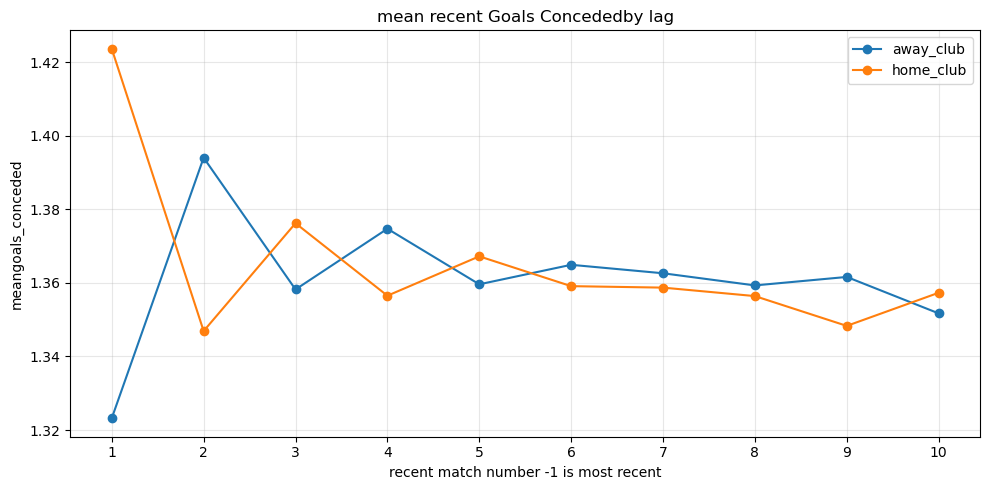


 mean recent {feature} by lag:


side,away_club,home_club
lag,,
1,6.7866,6.3255
2,6.4606,6.6516
3,6.5905,6.5266
4,6.5202,6.5976
5,6.5731,6.5488
6,6.5362,6.5821
7,6.5494,6.5564
8,6.5350,6.5595
9,6.5307,6.5506


saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\10_recent_team_rating_mean_by_lag.png


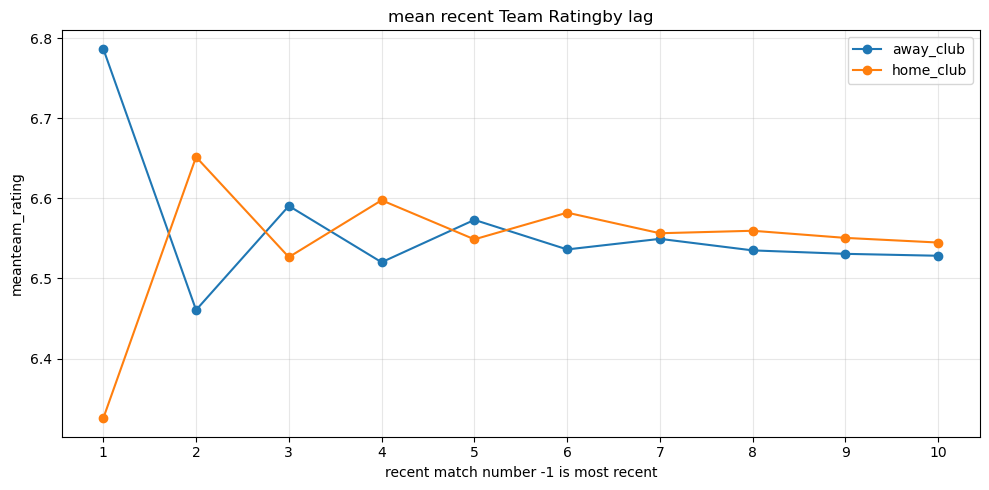


 mean recent {feature} by lag:


side,away_club,home_club
lag,,
1,6.2818,6.7494
2,6.6048,6.4047
3,6.4525,6.5329
4,6.5122,6.4438
5,6.4511,6.4748
6,6.4630,6.4311
7,6.4307,6.4335
8,6.4189,6.4136
9,6.4082,6.3919


saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\10_recent_opponent_rating_mean_by_lag.png


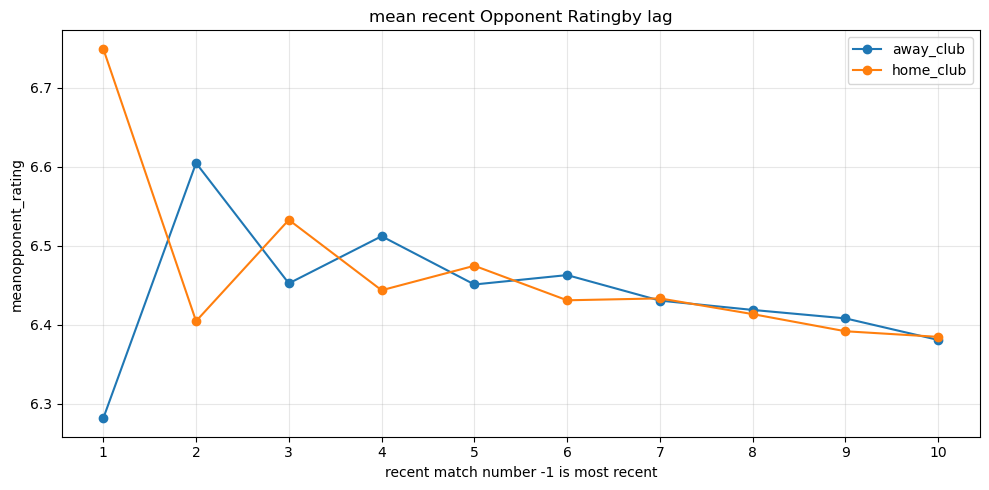

In [38]:
print('recent numeric feature by lag')
print('-'*80)

important_recent_numeric_features = [
    'golas_scored',
    'goals_conceded',
    'team_rating',
    'opponent_rating'
]

recent_numeric_stats_rows = []

for side in ['home_club','away_club']:
    for feature in important_recent_numeric_features:
        for lag in range(1,11):
            col = f'{side}_recent_{feature}_{lag}'
            
            if col not in eda_df.columns:
                continue
            
            values = to_numeric_series(eda_df[col])
            
            
            recent_numeric_stats_rows.append({
                'side':side,
                'feature':feature,
                'lag':lag,
                'column':col,
                'non_missing_count': int(values.notna().sum()),
                'missing_percentage': round(values.isna().mean()*100,2),
                'mean': values.mean(),
                'median': values.median(),
                'std': values.std(),
                'min': values.min(),
                'max':values.max(),
                'q01': values.quantile(0.01),
                'q25': values.quantile(0.25),
                'q75': values.quantile(0.75),
                'q99': values.quantile(0.99)
            })
            
recent_numeric_stats = pd.DataFrame(recent_numeric_stats_rows)
    
if not recent_numeric_stats.empty:
        numeric_round_cols = [
            'mean','median','std','min','max',
            'q01','q25','q75','q99'
        ]
        
        
        recent_numeric_stats[numeric_round_cols]= (
            recent_numeric_stats[numeric_round_cols].round(4)
        )
        
        
        display(recent_numeric_stats.head(40))
        
        
        safe_save_csv(
            recent_numeric_stats,
            'recent_numeric_stats_by_lag.csv',
            index=False
        )
        
        for feature in important_recent_numeric_features :
            temp = recent_numeric_stats[recent_numeric_stats['feature'] == feature].copy()
            
            if temp.empty:
                continue
            
            pivot_mean = temp.pivot(
                index='lag',
                columns='side',
                values='mean'
            )
            
            print('\n mean recent {feature} by lag:')
            display(pivot_mean)
            
            fig,ax = plt.subplots(figsize=(10,5))
            
            for side in pivot_mean.columns:
                ax.plot(
                    pivot_mean.index,
                    pivot_mean[side],
                    marker='o',
                    label = side
                )
                
            ax.set_title(f'mean recent {feature.replace('_',' ').title()}by lag')
            ax.set_xlabel('recent match number -1 is most recent')
            ax.set_ylabel(f'mean{feature}')
            ax.set_xticks(range(1,11))
            ax.grid(alpha=0.3)
            ax.legend()
            
            save_current_figure(
                f'10_recent_{feature}_mean_by_lag.png',
                fig=fig
            )
            
            
            plt.show()
            plt.close(fig)
else:
        print('no recent numeric columns were found')

In [39]:
RECENT_SIDES = {
    'home_club': 'home',
    'away_club': 'away'
}


RECENT_LAGS_10 = range(1,11)
MIN_VALID_VALUES_FOR_OUTLIER_CHECK = 10


outlier_check_rows = []
missing_recent_numeric_groups = []


for side , side_prefix in RECENT_SIDES.items():
    for feature in important_recent_numeric_features:
        cols = get_recent_columns(
                side=side,
                feature=feature,
                numbers= RECENT_LAGS_10,
                dataframe= eda_df
            )
            
            
        if len(cols) == 0 :
                missing_recent_numeric_groups.append({
                    'side':side,
                    'feature':feature,
                    'reason': 'no matching recent_history columns found'
                })
                continue
                
        for col in cols:
            value = to_numeric_series(eda_df[col])
            valid_values = values.dropna()
            valid_count = len(valid_values)
            
            
            if valid_count < MIN_VALID_VALUES_FOR_OUTLIER_CHECK:
                outlier_check_rows.append({
                    'column': col,
                    'side':side,
                    'feature': feature,
                    'valid_count': valid_count,
                    'missing_count': int(values.isna().sum()),
                    'missing_percentage': round(values.isna().mean()*100,2),
                    'q1': np.nan,
                    'median': np.nan,
                    'q3': np.nan,
                    'iqr': np.nan,
                    'lower_bound': np.nan,
                    'upper_bound': np.nan,
                    'outlier_count': np.nan,
                    'min': valid_values.min() if valid_count > 0 else np.nan,
                    'max': valid_values.max() if valid_count > 0 else np.nan,
                    'status': 'skipped , not enough valid numeric values'
                })
                continue
            
            q1 = valid_values.quantile(0.25)
            median = valid_values.median()
            q3 = valid_values.quantile(0.75)
            iqr = q3 - q1
            
            
            lower_bound = q1-1.5*iqr
            upper_bound = q3 + 1.5*iqr
            
            
            outlier_mask = (values < lower_bound)| (values> upper_bound)
            outlier_count = int(outlier_mask.sum())
            
            
            outlier_check_rows.append({
                'column': col,
                'side': side,
                'feature': feature,
                'valid_count': valid_count,
                'missing_count': int(values.isna().sum()),
                'missing_percentage': round(values.isna().mean()*100,2),
                'q1':q1,
                'median': median,
                'q3': q3,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'outlier_count': outlier_count,
                'outlier_percentage': round(outlier_count/valid_count*100,2),
                'min': valid_values.min(),
                'max' : valid_values.max(),
                'status': 'checked'
                })
            
outlier_check = pd.DataFrame(outlier_check_rows)

if not outlier_check.empty:
    outlier_check = outlier_check.sort_values(
        ['outlier_percentage','outlier_count'],
        ascending=[False,False],
        na_position='last'
    )
    
    display(outlier_check.head(50))
    safe_save_csv(outlier_check,'recent_numeric_outlier_check.csv',index=False)
    
else:
    print('no recent numeric columns were available for outlier checking')
    
missing_recent_numeric_groups = pd.DataFrame(missing_recent_numeric_groups)


if not missing_recent_numeric_groups.empty:
    print('recent numeric feature groups with no detected columns : ')
    display(missing_recent_numeric_groups)
    safe_save_csv(missing_recent_numeric_groups,'missing_recent_numeric_groups.csv',index=False)
    

,column,side,feature,valid_count,missing_count,missing_percentage,q1,median,q3,lower_bound,upper_bound,outlier_count,outlier_percentage,min,max,status
0,home_club_recent_goals_conceded_1,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
1,home_club_recent_goals_conceded_2,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
2,home_club_recent_goals_conceded_3,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
3,home_club_recent_goals_conceded_4,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
4,home_club_recent_goals_conceded_5,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
5,home_club_recent_goals_conceded_6,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
6,home_club_recent_goals_conceded_7,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
7,home_club_recent_goals_conceded_8,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
8,home_club_recent_goals_conceded_9,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked
9,home_club_recent_goals_conceded_10,home_club,goals_conceded,96715,14223,12.82,4.776239,5.858191,7.353536,0.910293,11.219483,4296,4.44,0.2556,45.36215,checked


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_numeric_outlier_check.csv
recent numeric feature groups with no detected columns : 


,side,feature,reason
0,home_club,golas_scored,no matching recent_history columns found
1,away_club,golas_scored,no matching recent_history columns found


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\missing_recent_numeric_groups.csv


In [40]:
FORM_LAGS = range(1,6)

RECENT_FROM_FEATURE_SPECS = [
    {
        'source_feature': 'goals_scored',
        'output_suffix': 'avg_goals_scored_last5',
    },
    {
        'source_feature': 'goals_conceded',
        'output_suffix' : 'avg_goals_conceded_last5'
    },
    {
        'source_feature':'team_rating',
        'output_suffix' : 'avg_team_rating_last5'
    },
    {
            'source_feature': 'opponent_rating',
            'output_suffix': 'avg_opponent_rating_last5'
    }
]




def add_recent_mean_feature(
    dataframe,
    side,
    feature,
    new_col,
    lags = FORM_LAGS,
    min_valid_values =1
):
    
    # Dany this is just for eda and final features will be better , this is not for final
    # OK
    cols = get_recent_columns(
        side = side,
        feature= feature,
        numbers= lags,
        dataframe= dataframe
    )
    
    
    metadata = {
        'new_feature': new_col,
        'side': side,
        'source_feature':feature,
        'available_columns': cols,
        'available_lag_count': len(cols),
        'created': False,
        'reason': None
    }

    if len(cols) == 0:
        metadata['reason'] = 'no matching columns found'
        return dataframe,metadata
    
    
    
    numeric_part = dataframe[cols].apply(pd.to_numeric,errors = 'coerce')
    valid_count_per_row = numeric_part.notna().sum(axis=1)
    
    dataframe[new_col] = numeric_part.mean(axis=1)
    dataframe.loc[valid_count_per_row < min_valid_values,new_col] = np.nan
    
    metadata['created'] = True
    metadata['non_null_count'] = int(dataframe[new_col].notna().sum())
    metadata['missing_percentage'] = round(dataframe[new_col].isna().mean()*100,2)
    metadata['mean'] = dataframe[new_col].mean()
    metadata['std'] = dataframe[new_col].std()
    
    return dataframe,metadata






def add_difference_feature(dataframe,left_col,right_col,new_col):
    
    if left_col not in dataframe.columns or right_col not in dataframe.columns:
        return False
    
    dataframe[new_col] = dataframe[left_col] - dataframe[right_col]
    return True

RECENT_SIDES = {
    "home": "home",
    "away": "away"
}
recent_form_feature_metadata = []
created_form_features = []


for side, prefix in RECENT_SIDES.items():
    for spec in RECENT_FROM_FEATURE_SPECS:
        new_col = f'{prefix}_{spec['output_suffix']}_eda'
        
        eda_df,metadata = add_recent_mean_feature(
            dataframe=eda_df,
            side=side,
            feature=spec['source_feature'],
            new_col= new_col,
            lags = FORM_LAGS
        )
        
        recent_form_feature_metadata.append(metadata)
        
        if metadata['created']:
            created_form_features.append(new_col)
            
derived_form_features = []

derived_feature_specs = [
    {
        "left": "home_avg_goals_scored_last5_eda",
        "right": "home_avg_goals_conceded_last5_eda",
        "new": "home_goal_diff_last5_eda"
    },
    {
        "left": "away_avg_goals_scored_last5_eda",
        "right": "away_avg_goals_conceded_last5_eda",
        "new": "away_goal_diff_last5_eda"
    },
    {
        "left": "home_goal_diff_last5_eda",
        "right": "away_goal_diff_last5_eda",
        "new": "goal_diff_advantage_home_minus_away_eda"
    },
    {
        "left": "home_avg_team_rating_last5_eda",
        "right": "away_avg_team_rating_last5_eda",
        "new": "rating_advantage_home_minus_away_eda"
    },
    {
        "left": "home_avg_opponent_rating_last5_eda",
        "right": "away_avg_opponent_rating_last5_eda",
        "new": "recent_opponent_strength_diff_home_minus_away_eda"
    }
]


for spec in derived_feature_specs:
    created = add_difference_feature(
        dataframe=eda_df,
        left_col = spec['left'],
        right_col= spec['right'],
        new_col=spec['new']
    )
    
    if created:
        derived_form_features.append(spec['new'])
        

eda_form_features = list(dict.fromkeys(created_form_features+derived_form_features))

recent_form_feature_metadata = pd.DataFrame(recent_form_feature_metadata)

print('recent from feature creation metadate:')
display(recent_form_feature_metadata)


print('\n temporary eda from features:')


for col in eda_form_features:
    print('-',col)
    

if eda_form_features:
    display(eda_df[eda_form_features+[TARGET_COL]].head())
    
else:
    print('no temporary eda  form features were created')

safe_save_csv(
    recent_form_feature_metadata,
    'recent_form_feature_creation_metadata.csv',
    index=False
)


recent from feature creation metadate:


,new_feature,side,source_feature,available_columns,available_lag_count,created,reason
0,home_avg_goals_scored_last5_eda,home,goals_scored,[],0,False,no matching columns found
1,home_avg_goals_conceded_last5_eda,home,goals_conceded,[],0,False,no matching columns found
2,home_avg_team_rating_last5_eda,home,team_rating,[],0,False,no matching columns found
3,home_avg_opponent_rating_last5_eda,home,opponent_rating,[],0,False,no matching columns found
4,away_avg_goals_scored_last5_eda,away,goals_scored,[],0,False,no matching columns found
5,away_avg_goals_conceded_last5_eda,away,goals_conceded,[],0,False,no matching columns found
6,away_avg_team_rating_last5_eda,away,team_rating,[],0,False,no matching columns found
7,away_avg_opponent_rating_last5_eda,away,opponent_rating,[],0,False,no matching columns found



 temporary eda from features:
no temporary eda  form features were created
Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_form_feature_creation_metadata.csv


In [41]:

form_target_summary_rows = []

for feature in eda_form_features:
    if feature  not in eda_df.columns:
        continue
    
    feature_summary = (
        eda_df
        .groupby(TARGET_COL,dropna=False)[feature]
        .agg(
            count = 'count',
            missing_count = lambda x: int(x.isna().sum()),
            mean='mean',
            median = 'median',
            std = 'std',
            min = 'min',
            max = 'max'
        ).reset_index()
    )
    
    feature_summary.insert(0,'feature',feature)
    form_target_summary_rows.append(feature_summary)
    
if form_target_summary_rows:
    form_target_summary = pd.concat(form_target_summary_rows,ignore_index=True)
    
    display(form_target_summary)
    
    safe_save_csv(
        form_target_summary,
        'form_features_by_target_summary.csv',
        index=False
    )
    
    
    selected_form_features_to_plot = [
        'goal_diff_advantage_home_minus_away_eda',
        'rating_advantage_home_minus_away_eda',
        'recent_opponent_strnght_diff_home_minus_away_eda',
        'home_goal_diff_last5_eda',
        'away_goal_diff_last5_eda',
        'home_avg_goals_scored_last5_eda',
        'away_avg_goals_scored_last5_eda',
        "home_avg_goals_conceded_last5_eda",
        "away_avg_goals_conceded_last5_eda"
    ]
    
    
    for feature in selected_form_features_to_plot:
        if feature not in eda_df.columns:
            continue
        
        target_means = (
            eda_df
            .groupby(TARGET_COL,dropna=False)[feature]
            .mean()
            .sort_values(ascending=False)
        )
        
        
        if target_means.notna().sum() <2 :
            print(f'skipped plot for {feature}: not enough valid target means')
            continue
        
        
        plot_bar(
            target_means,
            title=f'average {feature} by match result',
            xlabel='match result',
            ylabel=f'mean {feature}',
            filename=f'11_{feature}_by_match_reuslt.png',
            rotation=40
        )
        
        
else:
    print('no form features were available for target-level summary')

no form features were available for target-level summary


In [42]:
RECENT_CONTEX_FEATURES = ['played_at_home','cup_game']
CONTEXT_LAGS = range(1,11)


recent_context_rows = []
recent_context_eda_features = []


for side,prefix in RECENT_SIDES.items():
    for feature in RECENT_CONTEX_FEATURES:
        cols = get_recent_columns(
            side = side,
            feature=feature,
            numbers = CONTEXT_LAGS,
            dataframe=eda_df
        )
        
        
        if len(cols) == 0:
            recent_context_rows.append({
                'side': side,
                'feature': feature,
                'available_lags': 0,
                'new_eda_feature': None,
                'created': False,
                'reason': 'no matching columns found'
            })
            
            continue
        
        numeric_part = eda_df[cols].apply(pd.to_numeric,errors='coerce')
        
        
        new_col = f'{prefix}_recent_{feature}_rate_last10_eda'
        eda_df[new_col] = numeric_part.mean(axis=1)
        
        recent_context_eda_features.append(new_col)
        
        stacked_values = numeric_part.stack(dropna=True)
        
        
        invalid_binary_count = int(
            (~stacked_values.isin([0,1])).sum()
        ) if len(stacked_values)> 0 else 0
        
        
        
        recent_context_rows.append({
            'side': side,
            'feature': feature,
            'available_lags': len(cols),
            'new_eda_feature': new_col,
            'created': True,
            'overall_mean': stacked_values.mean() if len(stacked_values)> 0 else np.nan,
            'overall_missing_percentage': round(numeric_part.isna().mean().mean()*100,2),
            'min_value': stacked_values.min() if len(stacked_values) > 0 else np.nan,
            'max_value': stacked_values.max() if len(stacked_values)>0 else np.nan,
            'invalid_binary_value_count': invalid_binary_count,
            'reason': None
        })
        
        lag_means= numeric_part.mean(axis=0)
        lag_means.index = [int(col.rsplit('_',1)[-1]) for col in lag_means.index]
        lag_means = lag_means.sort_index()
        
        
        plot_bar(
            lag_means,
            title=f'{side} recent{feature.replace('_',' ').title()} rate by lag',
            xlabel='lag',
            ylabel='mean/rate',
            filename=f'12_{side}_recent_{feature}_rate_by_lag.png',
            rotation=0
        )
        
        
recent_context_summary = pd.DataFrame(recent_context_rows)

display(recent_context_rows)

safe_save_csv(
    recent_context_summary,'recent_context_summary.csv',index=False
)



for feature in recent_context_eda_features:
    if feature not in eda_df.columns:
        continue
    
    target_means = (
        eda_df
        .groupby(TARGET_COL,dropna=False)[feature]
        .mean()
        .sort_values(ascending=False)
    )
    
    if target_means.notna().sum() < 2:
        print(f'skipped plot for {feature}: not enough valid target means')
        continue
    
    plot_bar(
        target_means,
        title=f'average{feature} by match result',
        xlabel= 'match reuslt',
        ylabel= f'mean {feature}',
        filename = f'13_{feature}_by_match_result.png',
        rotation=40
    )

[{'side': 'home',
  'feature': 'played_at_home',
  'available_lags': 0,
  'new_eda_feature': None,
  'created': False,
  'reason': 'no matching columns found'},
 {'side': 'home',
  'feature': 'cup_game',
  'available_lags': 0,
  'new_eda_feature': None,
  'created': False,
  'reason': 'no matching columns found'},
 {'side': 'away',
  'feature': 'played_at_home',
  'available_lags': 0,
  'new_eda_feature': None,
  'created': False,
  'reason': 'no matching columns found'},
 {'side': 'away',
  'feature': 'cup_game',
  'available_lags': 0,
  'new_eda_feature': None,
  'created': False,
  'reason': 'no matching columns found'}]

Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\recent_context_summary.csv


,column,exists,unique_manager,missing_count,missing_percentage,most_frequent_manager_count,most_frequent_manager_percentage
0,home_manager_id,True,8804,21721,19.58,4455,4.99
1,away_manager_id,True,8938,21815,19.66,4512,5.06


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\manager_summary.csv


,new_feature,created,reason,current_col,previous_col,non_null_count,missing_percentage,change_rate_percentage
0,home_manager_changed_from_last_match_eda,True,None,home_manager_id,home_club_recent_manager_id_1,87810,20.85,3.28
1,away_manager_changed_from_last_match_eda,True,None,away_manager_id,away_club_recent_manager_id_1,87695,20.95,3.40


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\manager_change_feature_creation_summary.csv

Feature: home_manager_changed_from_last_match_eda


,count,percentage
home_manager_changed_from_last_match_eda,,
0.0,84933,76.56
NaN,23128,20.85
1.0,2877,2.59


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\home_manager_changed_from_last_match_eda_distribution.csv


match_result,away,draw,home
home_manager_changed_from_last_match_eda,,,
0.0,30.86,25.28,43.85
1.0,33.61,27.22,39.17
NaN,34.56,23.32,42.12


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\home_manager_changed_from_last_match_eda_target_distribution.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\14_home_manager_changed_from_last_match_eda_target_distribution.png


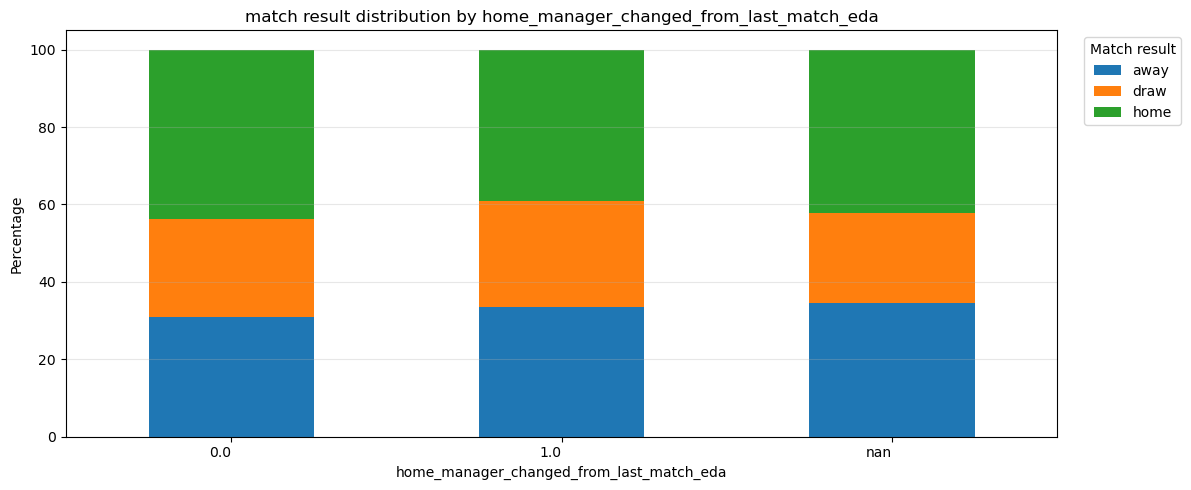


Feature: away_manager_changed_from_last_match_eda


,count,percentage
away_manager_changed_from_last_match_eda,,
0.0,84715,76.36
NaN,23243,20.95
1.0,2980,2.69


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\away_manager_changed_from_last_match_eda_distribution.csv


match_result,away,draw,home
away_manager_changed_from_last_match_eda,,,
0.0,32.33,25.48,42.19
1.0,28.96,24.73,46.31
NaN,29.79,22.92,47.29


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\away_manager_changed_from_last_match_eda_target_distribution.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\14_away_manager_changed_from_last_match_eda_target_distribution.png


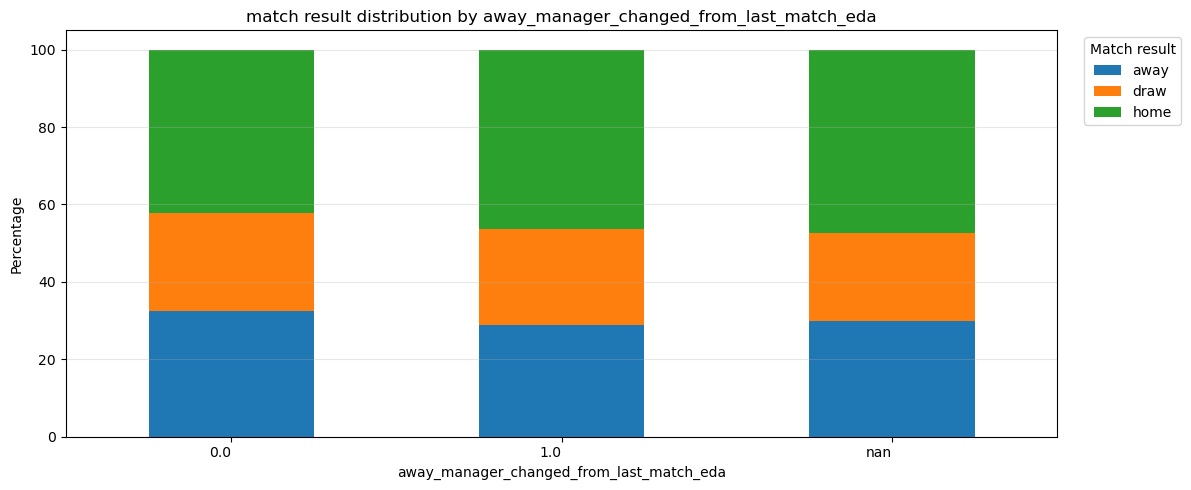

In [43]:
MANAGER_COLUMNS = ['home_manager_id', 'away_manager_id']

manager_summary_rows = []

for col in MANAGER_COLUMNS:
    if col not in eda_df.columns:
        manager_summary_rows.append({
            'column': col,
            'exists': False,
            'unique_manager': np.nan,
            'missing_count': np.nan,
            'missing_percentage': np.nan,
            'most_frequent_manager_count': np.nan,
            'most_frequent_manager_percentage': np.nan
        })

        continue

    value_counts = eda_df[col].value_counts(dropna=True)

    most_frequent_count = int(value_counts.iloc[0]) if len(value_counts) > 0 else 0

    non_missing_count = eda_df[col].notna().sum()

    most_frequent_percentage = (
        most_frequent_count / non_missing_count * 100
        if non_missing_count > 0
        else np.nan
    )

    manager_summary_rows.append({
        'column': col,
        'exists': True,
        'unique_manager': int(eda_df[col].nunique(dropna=True)),
        'missing_count': int(eda_df[col].isna().sum()),
        'missing_percentage': round(eda_df[col].isna().mean() * 100, 2),
        'most_frequent_manager_count': most_frequent_count,
        'most_frequent_manager_percentage': round(most_frequent_percentage, 2)
    })


manager_summary = pd.DataFrame(manager_summary_rows)

display(manager_summary)

safe_save_csv(
    manager_summary,
    'manager_summary.csv',
    index=False
)


def clean_id_for_comparison(series):
    cleaned = series.astype('string').str.strip()

    cleaned = cleaned.replace(
        {
            '': pd.NA,
            'nan': pd.NA,
            'NaN': pd.NA,
            'None': pd.NA,
            'none': pd.NA,
            '<NA>': pd.NA
        }
    )

    numeric_version = pd.to_numeric(cleaned, errors='coerce')
    numeric_success_rate = numeric_version.notna().mean()

    if numeric_success_rate >= 0.90:
        cleaned = numeric_version.round(0).astype('Int64').astype('string')

    return cleaned


manager_changed_specs = [
    {
        'current_col': 'home_manager_id',
        'previous_col': 'home_club_recent_manager_id_1',
        'new_col': 'home_manager_changed_from_last_match_eda'
    },
    {
        'current_col': 'away_manager_id',
        'previous_col': 'away_club_recent_manager_id_1',
        'new_col': 'away_manager_changed_from_last_match_eda'
    }
]


manager_change_features = []
manager_change_creation_rows = []


for spec in manager_changed_specs:
    current_col = spec['current_col']
    previous_col = spec['previous_col']
    new_col = spec['new_col']

    if current_col not in eda_df.columns or previous_col not in eda_df.columns:
        manager_change_creation_rows.append({
            'new_feature': new_col,
            'created': False,
            'reason': 'current or previous manager column is missing',
            'current_col': current_col,
            'previous_col': previous_col
        })

        continue

    current_values = clean_id_for_comparison(eda_df[current_col])
    previous_values = clean_id_for_comparison(eda_df[previous_col])

    missing_mask = current_values.isna() | previous_values.isna()

    comparison = current_values.ne(previous_values).fillna(False).astype(int)

    eda_df[new_col] = comparison.astype(float)
    eda_df.loc[missing_mask, new_col] = np.nan

    manager_change_features.append(new_col)

    manager_change_creation_rows.append({
        'new_feature': new_col,
        'created': True,
        'reason': None,
        'current_col': current_col,
        'previous_col': previous_col,
        'non_null_count': int(eda_df[new_col].notna().sum()),
        'missing_percentage': round(eda_df[new_col].isna().mean() * 100, 2),
        'change_rate_percentage': round(eda_df[new_col].mean() * 100, 2)
    })


manager_change_creation_summary = pd.DataFrame(manager_change_creation_rows)

display(manager_change_creation_summary)

safe_save_csv(
    manager_change_creation_summary,
    'manager_change_feature_creation_summary.csv',
    index=False
)


if manager_change_features:
    for feature in manager_change_features:
        print('\nFeature:', feature)

        feature_counts = eda_df[feature].value_counts(dropna=False)
        feature_percentages = (
            eda_df[feature]
            .value_counts(normalize=True, dropna=False)
            .mul(100)
            .round(2)
        )

        feature_dist = pd.DataFrame({
            'count': feature_counts,
            'percentage': feature_percentages
        })

        display(feature_dist)

        feature_dist_export = feature_dist.reset_index()
        feature_dist_export.columns = [feature, 'count', 'percentage']

        safe_save_csv(
            feature_dist_export,
            f'{feature}_distribution.csv',
            index=False
        )

        manager_target_table = (
            pd.crosstab(
                eda_df[feature],
                eda_df[TARGET_COL],
                normalize='index',
                dropna=False
            )
            .mul(100)
            .round(2)
        )

        display(manager_target_table)

        safe_save_csv(
            manager_target_table.reset_index(),
            f'{feature}_target_distribution.csv',
            index=False
        )

        if manager_target_table.shape[0] > 0 and manager_target_table.shape[1] > 1:
            plot_stacked_percentage(
                manager_target_table,
                title=f'match result distribution by {feature}',
                xlabel=feature,
                filename=f'14_{feature}_target_distribution.png',
                rotation=0
            )
        else:
            print(f'skipped stacked plot for {feature}: not enough categories')

else:
    print('manager change feature could not be created')

number of usable numeric eda features for correlation : 2


,home_manager_changed_from_last_match_eda,away_manager_changed_from_last_match_eda
home_manager_changed_from_last_match_eda,1.000000,0.151602
away_manager_changed_from_last_match_eda,0.151602,1.000000


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\temporary_eda_features_correlation.csv
saved figure:c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\figures\15_temporary_eda_features_correlation.png


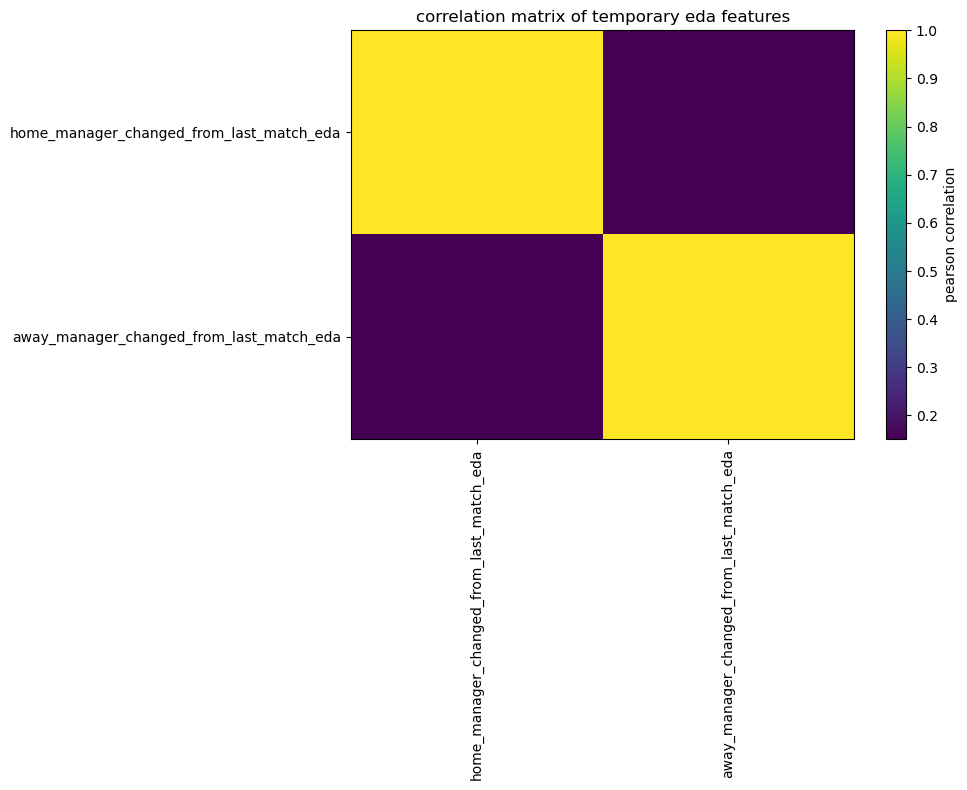

In [44]:
import matplotlib.pyplot as plt

candidate_numeric_eda_features = (
    eda_form_features + recent_context_eda_features + manager_change_features
)


numeric_eda_features = []


for col in candidate_numeric_eda_features:
    if col not in eda_df.columns:
        continue
    
    converted_col = pd.to_numeric(eda_df[col],errors='coerce')
    
    if converted_col.notna().sum() == 0:
        continue
    
    if converted_col.nunique(dropna=True)< 2:
        continue
    
    eda_df[col] = converted_col
    numeric_eda_features.append(col)
    
numeric_eda_features = list(dict.fromkeys(numeric_eda_features))

print(f'number of usable numeric eda features for correlation : {len(numeric_eda_features)}')

if len(numeric_eda_features) >= 2:
    corr_matrix =  eda_df[numeric_eda_features].corr(method='pearson',min_periods=10)
    
    display(corr_matrix)
    
    
    safe_save_csv(
        corr_matrix,
        'temporary_eda_features_correlation.csv', index=True
    )
    
    plt.figure(figsize=(max(10,len(corr_matrix.columns)*0.7),max(8,len(corr_matrix.index)*0.6)))
    plt.imshow(corr_matrix,aspect='auto')
    plt.colorbar(label='pearson correlation')
    
    plt.xticks(
        ticks=range(len(corr_matrix.columns)),
        labels=corr_matrix.columns,
        rotation =90
    )
    plt.yticks(
        ticks=range(len(corr_matrix.index)),
        labels=corr_matrix.index
    )
    
    plt.title('correlation matrix of temporary eda features')
    plt.tight_layout()
    
    save_current_figure('15_temporary_eda_features_correlation.png')
    plt.show()

else:
    print('not enough usable numeric eda features for correlation analysis')

In [45]:
eda_decision_note_rows = []

eda_decision_note_rows.append({
    'area': 'target',
    'finding': 'target distribution and majority-class baseline were analyzed',
    'next_phase_action': 'use stratified evaluation when possible and compare all models against the majority-class baseline',
    'priority': 'high'
})


if 'fixture_date' in eda_df.columns:
    eda_decision_note_rows.append({
        'area': 'fixture_date',
        'finding': 'fixture date availability are parsing quality were analyzed',
        'next_phase_action': 'use fixture_date for temporal features and prefer time-aware split as the main evalutation strategy',
        'priority': 'high'
    })
    
if (
    'recent_columns_info_eda' in  globals()
    and isinstance(recent_columns_info_eda,pd.DataFrame)
    and not recent_columns_info_eda.empty
):
    eda_decision_note_rows.append({
        'area': 'recent_history',
        'finding': f'{len(recent_columns_info_eda)} recent-history columns were detected',
        'next_phase_action': 'use recent-history columns to create form , rating goal-diffrence , opponent-strength and context features',
        'priority': 'high'
    })
    
    
    
if (
    'recent_date_leakage_check'in  globals() 
    and isinstance(recent_date_leakage_check,pd.DataFrame)
    and not recent_date_leakage_check.empty
    and 'violations_recent_date_not_before_current' in recent_date_leakage_check.columns
):
    total_date_violations = int(
        pd.to_numeric(
            recent_date_leakage_check['violations_recent_date_not_before_current'],
            errors='coerce'
        ).fillna(0).sum()
    )
    
    
    leakage_priority = 'high' if total_date_violations > 0 else 'medium'
    
    eda_decision_note_rows.append({
        'area': 'date_leakage',
        'finding': f'recent fixture date leakage violations found :{total_date_violations}',
        'next_phase_action': 'if violations exist, investigate affected rows before modeling or  remove invalid records',
        'priority': leakage_priority
    })
    
    
 
if 'competition' in eda_df.columns:
    eda_decision_note_rows.append({
        'area': 'competition',
        'finding': 'competition frequency and target distribution by competition were analyzed',
        'next_phase_action': 'encode competiton carefully rare competitions may need grouping before modeling',
        'priority' : 'medium'
    })
    


if 'cup_game' in eda_df.columns:
    eda_decision_note_rows.append({
        'area': 'cup_game',
        'finding': 'cupgame distribution and its relationship with result were analyzed',
        'next_phase_action': 'keep cupgame as a binary context feature if missing values and enconding are acceptable',
        'priority': 'medium'
    })
    
    

if (
    'manager_change_features' in globals() and isinstance(manager_change_features,list) and len(manager_change_features)>0
):
    eda_decision_note_rows.append({
        'area': 'manager',
        'finding': 'manager availability and manager-change indicators were analyzed',
        'next_phase_action': 'recent manager-change features in the feature engineering using the same missing value logic',
        'priority': 'medium'
    })
    
    
    
if (
    'outlier_check' in globals() and isinstance(outlier_check,pd.DataFrame) and not outlier_check.empty and 'outlier_percentage' in outlier_check.columns
):
    
    high_outlier_columns = outlier_check[
        pd.to_numeric(outlier_check['outlier_percentage'],errors='coerce') > 10
    ]
    
    eda_decision_note_rows.append({
        'area': 'outliers',
        'finding': f'{len(high_outlier_columns)} recent numeric columns have more than 10% IQR based outliers',
        'next_phase_action': 'do not automatically remvoe football outliers review them and prefer rubust models or transformations if needed',
        'priority': 'medium'
    })
    

eda_decision_notes = pd.DataFrame(eda_decision_note_rows)
display(eda_decision_notes)


safe_save_csv(
    eda_decision_notes,
    'eda_decisiton_notes_for_next_phases.csv',
    index=False
)


,area,finding,next_phase_action,priority
0,target,target distribution and majority-class baseline were analyzed,use stratified evaluation when possible and compare all models against the majority-class baseline,high
1,fixture_date,fixture date availability are parsing quality were analyzed,use fixture_date for temporal features and prefer time-aware split as the main evalutation strategy,high
2,recent_history,180 recent-history columns were detected,"use recent-history columns to create form , rating goal-diffrence , opponent-strength and context features",high
3,competition,competition frequency and target distribution by competition were analyzed,encode competiton carefully rare competitions may need grouping before modeling,medium
4,cup_game,cupgame distribution and its relationship with result were analyzed,keep cupgame as a binary context feature if missing values and enconding are acceptable,medium
5,manager,manager availability and manager-change indicators were analyzed,recent manager-change features in the feature engineering using the same missing value logic,medium
6,outliers,0 recent numeric columns have more than 10% IQR based outliers,do not automatically remvoe football outliers review them and prefer rubust models or transformations if needed,medium


Saved: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\eda_decisiton_notes_for_next_phases.csv


In [46]:
import json

PHASE_2_REPORT_DIR.mkdir(parents=True, exist_ok=True)
PHASE_2_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if TARGET_COL not in eda_df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' does not exist in eda_df.")

target_distribution_final = eda_df[TARGET_COL].value_counts(dropna=True)

if len(target_distribution_final) > 0:
    majority_class = target_distribution_final.idxmax()
    majority_baseline_accuracy = target_distribution_final.max() / target_distribution_final.sum()
else:
    majority_class = None
    majority_baseline_accuracy = None

phase_2_summary = {
    "dataset_shape": {
        "rows": int(eda_df.shape[0]),
        "columns": int(eda_df.shape[1])
    },
    "target_column": TARGET_COL,
    "target_unique_count": int(eda_df[TARGET_COL].nunique(dropna=True)),
    "target_missing_count": int(eda_df[TARGET_COL].isna().sum()),
    "majority_class": str(majority_class) if majority_class is not None else None,
    "majority_baseline_accuracy": (
        float(majority_baseline_accuracy)
        if majority_baseline_accuracy is not None
        else None
    ),
    "recent_history_columns_detected": (
        int(len(recent_columns_info_eda))
        if "recent_columns_info_eda" in globals()
        else None
    ),
    "temporary_form_features_created": eda_form_features if "eda_form_features" in globals() else [],
    "recent_context_features_created": recent_context_eda_features if "recent_context_eda_features" in globals() else [],
    "manager_change_features_created": manager_change_features if "manager_change_features" in globals() else [],
    "numeric_eda_features_used_for_correlation": numeric_eda_features if "numeric_eda_features" in globals() else [],
    "report_dir": str(PHASE_2_REPORT_DIR),
    "figures_dir": str(PHASE_2_FIGURES_DIR)
}

if "fixture_date_parsed" in eda_df.columns:
    fixture_date_non_null_rate = eda_df["fixture_date_parsed"].notna().mean() * 100

    phase_2_summary["fixture_date_parse_success_percentage"] = float(fixture_date_non_null_rate)
    phase_2_summary["fixture_min_date"] = str(eda_df["fixture_date_parsed"].min())
    phase_2_summary["fixture_max_date"] = str(eda_df["fixture_date_parsed"].max())

if "competition" in eda_df.columns:
    phase_2_summary["unique_competitions"] = int(
        eda_df["competition"].nunique(dropna=True)
    )

if "home_club" in eda_df.columns and "away_club" in eda_df.columns:
    phase_2_summary["unique_clubs_combined"] = int(
        pd.concat(
            [eda_df["home_club"], eda_df["away_club"]],
            ignore_index=True
        ).nunique(dropna=True)
    )
    
    # باگ  سینتکسی زدم ولی راحت ترین راه رو بریم :)

if 'recent_date_leakage_check' in globals() and not recent_date_leakage_check.empty:
    possible_leakage_cols = [
        'violations_recent_date_not_before_current',
        'violation_recent_date_not_before_current'
    ]
    
    leakage_col = None
    
    for col in possible_leakage_cols:
        if col in recent_date_leakage_check.column:
            leakage_col = col
            break
        
    if leakage_col is not None:
        phase_2_summary['recent_date_leakage_total_violations'] = int(
            pd.to_numeric(
                recent_date_leakage_check[leakage_col],
                errors='coerce'
            ).fillna(0).sum()
        )
        
        phase_2_summary['recent_date_leakage_column_used'] = leakage_col
        
    else:
        phase_2_summary['recent_date_leakage_total_violations'] = None
        phase_2_summary['recent_date_leakage_note'] = (
            'recent_date_leakage_check exists but no expected leakage-count columns was found'
        )
        
        print('warning : no expected leakage columns was not found in recent_date_leakage_check')
        print('available columns:')
        print(recent_date_leakage_check.column.tolist())

if "outlier_check" in globals() and not outlier_check.empty:
    valid_outlier_percentages = pd.to_numeric(
        outlier_check["outlier_percentage"],
        errors="coerce"
    )

    phase_2_summary["recent_numeric_outlier_columns_checked"] = int(
        valid_outlier_percentages.notna().sum()
    )

    phase_2_summary["recent_numeric_columns_with_outlier_percentage_above_10"] = int(
        (valid_outlier_percentages > 10).sum()
    )

summary_path = PHASE_2_REPORT_DIR / "phase_2_summary.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(
        phase_2_summary,
        f,
        indent=4,
        ensure_ascii=False,
        default=str
    )

print("Phase 2 summary saved to:", summary_path)
print(json.dumps(phase_2_summary, indent=4, ensure_ascii=False, default=str))

print("-" * 80)
print("PHASE 2 COMPLETED SUCCESSFULLY")
print("-" * 80)

available columns:
['home_club_recent_fixture_date_1', 'home_club_recent_fixture_date_2', 'home_club_recent_fixture_date_3', 'home_club_recent_fixture_date_4', 'home_club_recent_fixture_date_5', 'home_club_recent_fixture_date_6', 'home_club_recent_fixture_date_7', 'home_club_recent_fixture_date_8', 'home_club_recent_fixture_date_9', 'home_club_recent_fixture_date_10', 'away_club_recent_fixture_date_1', 'away_club_recent_fixture_date_2', 'away_club_recent_fixture_date_3', 'away_club_recent_fixture_date_4', 'away_club_recent_fixture_date_5', 'away_club_recent_fixture_date_6', 'away_club_recent_fixture_date_7', 'away_club_recent_fixture_date_8', 'away_club_recent_fixture_date_9', 'away_club_recent_fixture_date_10']
Phase 2 summary saved to: c:\Users\mojta_tok6stl\OneDrive\Desktop\learning_ai\Football_Match_Prediction\reports\phase_2_eda\phase_2_summary.json
{
    "dataset_shape": {
        "rows": 110938,
        "columns": 196
    },
    "target_column": "match_result",
    "target_uniqu

# Phase 3/10 — Data Cleaning And Handleing Outliers

In [47]:
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import re

import numpy as np
import pandas as pd


@dataclass
class CleaningConfig:
    input_file: str = "football_data.csv"

    report_csv_file: str = "cleaning_report.csv"
    flagged_output_file: str = "flagged_outliers.csv"
    cleaned_output_file: str = "cleaned_football_data.csv"

    serious_missing_pct: float = 30.0

    valid_target_labels: Tuple[str, ...] = ("home", "away", "draw")

    max_reasonable_goals: int = 10

    remove_time_leak_rows: bool = True
    max_time_leak_removal_pct: float = 5.0

    @property
    def MAX_RESONABLE_GOALS(self) -> int:
        return self.max_reasonable_goals

    @property
    def MAX_REASONABLE_GOALS(self) -> int:
        return self.max_reasonable_goals

In [48]:
def normalize_column_name(col: str) -> str:

    col = str(col).strip().lower()
    col = col.replace("-", "_").replace(" ", "_")
    col = re.sub(r"[^a-z0-9_]+", "", col)
    col = re.sub(r"_+", "_", col)
    col = col.strip("_")
    return col


def make_unique_column_names(columns: List[str]) -> List[str]:

    seen = {}
    unique_columns = []

    for col in columns:
        if col not in seen:
            seen[col] = 0
            unique_columns.append(col)
        else:
            seen[col] += 1
            unique_columns.append(f"{col}_{seen[col]}")

    return unique_columns


def standardize_dataframe_columns(df: pd.DataFrame) -> pd.DataFrame:
 
    df = df.copy()

    normalized_columns = [
        normalize_column_name(col)
        for col in df.columns
    ]

    df.columns = make_unique_column_names(normalized_columns)

    column_aliases = {
        "matches_result": "match_result",
        "matchresult": "match_result",
        "result": "match_result",

        "matchid": "match_id",

        "fixturedate": "fixture_date",
        "date": "fixture_date",

        "cupe_game": "cup_game",
        "cupgame": "cup_game",

        "home_team": "home_club",
        "away_team": "away_club",
    }

    rename_map = {
        col: column_aliases[col]
        for col in df.columns
        if col in column_aliases
    }

    if rename_map:
        df = df.rename(columns=rename_map)
        df.columns = make_unique_column_names(list(df.columns))

    return df


def add_report(report: List[Dict], step: str, metric: str, value, details: str = "") -> None:
    report.append({
        "step": step,
        "metric": metric,
        "value": value,
        "details": details
    })


def collect_flagged_rows(
    flagged_parts: List[pd.DataFrame],
    df: pd.DataFrame,
    mask: pd.Series,
    reason: str,
    action: str
) -> None:
    if mask is None:
        return

    mask = mask.reindex(df.index, fill_value=False).fillna(False).astype(bool)

    if int(mask.sum()) == 0:
        return

    part = df.loc[mask].copy()
    part["flag_reason"] = reason
    part["flag_action"] = action

    flagged_parts.append(part)


def increment_count(removal_counts: Dict[str, int], key: str, amount: int) -> None:
    removal_counts[key] = int(removal_counts.get(key, 0)) + int(amount)


def remove_rows(
    df: pd.DataFrame,
    mask: pd.Series,
    reason: str,
    removal_key: str,
    removal_counts: Dict[str, int],
    flagged_parts: List[pd.DataFrame],
) -> pd.DataFrame:

    mask = mask.reindex(df.index, fill_value=False).fillna(False).astype(bool)

    n_removed = int(mask.sum())
    n_total = len(df)

    collect_flagged_rows(
        flagged_parts=flagged_parts,
        df=df,
        mask=mask,
        reason=reason,
        action="removed",
    )

    if n_total > 0 and n_removed >= n_total:
        raise ValueError(
            f"This cleaning rule would remove all rows: {reason}. "
            f"Rows to remove: {n_removed:,}/{n_total:,}. "
            "This rule is too strict. Change it to flag-only or relax the threshold."
        )

    increment_count(removal_counts, removal_key, n_removed)

    if n_removed > 0:
        print(f"Removed {n_removed:,} rows: {reason}")

    return df.loc[~mask].copy()

In [49]:
def load_and_inspect_data(
    config: CleaningConfig,
    report: List[Dict]
) -> Tuple[pd.DataFrame, int]:

    print("Loading dataset...")

    input_path = Path(config.input_file)

    if not input_path.exists():
        raise FileNotFoundError(f"Input file not found: {input_path.resolve()}")

    df_raw = pd.read_csv(input_path, low_memory=False)

    original_rows = len(df_raw)

    print("Raw shape:", df_raw.shape)
    print("Raw columns:")
    print(list(df_raw.columns))

    print("\nRaw dtypes:")
    display(df_raw.dtypes)

    print("\nFirst raw rows:")
    display(df_raw.head())

    df = standardize_dataframe_columns(df_raw)

    print("\nColumns after normalization:")
    print(list(df.columns))

    print("\nDtypes after column normalization:")
    display(df.dtypes)

    add_report(
        report,
        "Step 1: Load and inspect data",
        "original_rows",
        original_rows
    )

    add_report(
        report,
        "Step 1: Load and inspect data",
        "columns_count_after_normalization",
        len(df.columns)
    )

    add_report(
        report,
        "Step 1: Load and inspect data",
        "columns_after_normalization",
        len(df.columns),
        ", ".join(df.columns)
    )

    return df, original_rows

In [50]:
config = CleaningConfig()
report = []
flagged_parts = []
removal_counts = {}
cleaning_df, _ = load_and_inspect_data(config, report)

Loading dataset...
Raw shape: (110938, 190)
Raw columns:
['match_id', 'match_result', 'home_club', 'away_club', 'fixture_date', 'competition', 'competition_code', 'cup_game', 'home_manager_id', 'away_manager_id', 'home_club_recent_fixture_date_1', 'home_club_recent_fixture_date_2', 'home_club_recent_fixture_date_3', 'home_club_recent_fixture_date_4', 'home_club_recent_fixture_date_5', 'home_club_recent_fixture_date_6', 'home_club_recent_fixture_date_7', 'home_club_recent_fixture_date_8', 'home_club_recent_fixture_date_9', 'home_club_recent_fixture_date_10', 'home_club_recent_played_at_home_1', 'home_club_recent_played_at_home_2', 'home_club_recent_played_at_home_3', 'home_club_recent_played_at_home_4', 'home_club_recent_played_at_home_5', 'home_club_recent_played_at_home_6', 'home_club_recent_played_at_home_7', 'home_club_recent_played_at_home_8', 'home_club_recent_played_at_home_9', 'home_club_recent_played_at_home_10', 'home_club_recent_cup_game_1', 'home_club_recent_cup_game_2', 'ho

match_id                                  int64
match_result                             object
home_club                                object
away_club                                object
fixture_date                             object
                                         ...   
away_club_recent_competition_code_6     float64
away_club_recent_competition_code_7     float64
away_club_recent_competition_code_8     float64
away_club_recent_competition_code_9     float64
away_club_recent_competition_code_10    float64
Length: 190, dtype: object


First raw rows:


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw


Columns after normalization:
['match_id', 'match_result', 'home_club', 'away_club', 'fixture_date', 'competition', 'competition_code', 'cup_game', 'home_manager_id', 'away_manager_id', 'home_club_recent_fixture_date_1', 'home_club_recent_fixture_date_2', 'home_club_recent_fixture_date_3', 'home_club_recent_fixture_date_4', 'home_club_recent_fixture_date_5', 'home_club_recent_fixture_date_6', 'home_club_recent_fixture_date_7', 'home_club_recent_fixture_date_8', 'home_club_recent_fixture_date_9', 'home_club_recent_fixture_date_10', 'home_club_recent_played_at_home_1', 'home_club_recent_played_at_home_2', 'home_club_recent_played_at_home_3', 'home_club_recent_played_at_home_4', 'home_club_recent_played_at_home_5', 'home_club_recent_played_at_home_6', 'home_club_recent_played_at_home_7', 'home_club_recent_played_at_home_8', 'home_club_recent_played_at_home_9', 'home_club_recent_played_at_home_10', 'home_club_recent_cup_game_1', 'home_club_recent_cup_game_2', 'home_club_recent_cup_game_3',

match_id                                  int64
match_result                             object
home_club                                object
away_club                                object
fixture_date                             object
                                         ...   
away_club_recent_competition_code_6     float64
away_club_recent_competition_code_7     float64
away_club_recent_competition_code_8     float64
away_club_recent_competition_code_9     float64
away_club_recent_competition_code_10    float64
Length: 190, dtype: object

In [51]:
def get_recent_columns(
    side: str,
    feature: str,
    numbers=range(1, 11),
    dataframe: Optional[pd.DataFrame] = None
) -> List[str]:

    if dataframe is None:
        raise ValueError("dataframe must be provided to get_recent_columns.")

    side = normalize_column_name(side)
    feature = normalize_column_name(feature)

    cols = []

    for number in numbers:
        col = f"{side}_recent_{feature}_{number}"

        if col in dataframe.columns:
            cols.append(col)

    return cols


def recent_pattern_info(
    dataframe: Optional[pd.DataFrame] = None
) -> pd.DataFrame:

    if dataframe is None:
        raise ValueError("dataframe must be provided to recent_pattern_info.")

    pattern = re.compile(r"^(home_club|away_club)_recent_(.+)_(\d+)$")

    rows = []

    for col in dataframe.columns:
        match = pattern.match(col)

        if match:
            rows.append({
                "column": col,
                "club_side": match.group(1),
                "feature": match.group(2),
                "recent_number": int(match.group(3)),
                "dtype": str(dataframe[col].dtype),
                "missing_count": int(dataframe[col].isna().sum()),
                "missing_percentage": round(dataframe[col].isna().mean() * 100, 2),
                "unique_count": int(dataframe[col].nunique(dropna=True))
            })

    result = pd.DataFrame(rows)

    if not result.empty:
        result = result.sort_values(
            ["club_side", "feature", "recent_number"]
        ).reset_index(drop=True)

    return result

In [52]:
TARGET_COL = "match_result"
ID_COL = "match_id"

SIDES = ["home_club", "away_club"]

CATEGORICAL_COLS = [
    "home_club",
    "away_club",
    "competition",
    "competition_code",
    "cup_game",
    "home_manager_id",
    "away_manager_id",
]

recent_categorical_features = [
    "competition_code",
    "cup_game",
    "manager_id",
    "played_at_home",
]

for feature in recent_categorical_features:
    for side in SIDES:
        CATEGORICAL_COLS += get_recent_columns(
            side=side,
            feature=feature,
            numbers=range(1, 11),
            dataframe=cleaning_df
        )

NUMERIC_COLS = []

recent_numeric_features = [
    "goals_scored",
    "goals_conceded",
    "team_rating",
    "opponent_rating",
]

for feature in recent_numeric_features:
    for side in SIDES:
        NUMERIC_COLS += get_recent_columns(
            side=side,
            feature=feature,
            numbers=range(1, 11),
            dataframe=cleaning_df
        )

DATE_COLS = ["fixture_date"]

for side in SIDES:
    DATE_COLS += get_recent_columns(
        side=side,
        feature="fixture_date",
        numbers=range(1, 11),
        dataframe=cleaning_df
    )

CATEGORICAL_COLS = list(dict.fromkeys([
    col for col in CATEGORICAL_COLS
    if col in cleaning_df.columns
]))

NUMERIC_COLS = list(dict.fromkeys([
    col for col in NUMERIC_COLS
    if col in cleaning_df.columns
]))

DATE_COLS = list(dict.fromkeys([
    col for col in DATE_COLS
    if col in cleaning_df.columns
]))

EXPECTED_COLUMNS = list(dict.fromkeys(
    [ID_COL, TARGET_COL]
    + CATEGORICAL_COLS
    + NUMERIC_COLS
    + DATE_COLS
))

print("Categorical columns:", len(CATEGORICAL_COLS))
print("Numeric columns:", len(NUMERIC_COLS))
print("Date columns:", len(DATE_COLS))
print("Expected columns:", len(EXPECTED_COLUMNS))

display(recent_pattern_info(cleaning_df).head(30))

Categorical columns: 87
Numeric columns: 80
Date columns: 21
Expected columns: 190


,column,club_side,feature,recent_number,dtype,missing_count,missing_percentage,unique_count
0,away_club_recent_competition_code_1,away_club,competition_code,1,float64,1226,1.11,864
1,away_club_recent_competition_code_2,away_club,competition_code,2,float64,2593,2.34,856
2,away_club_recent_competition_code_3,away_club,competition_code,3,float64,4034,3.64,854
3,away_club_recent_competition_code_4,away_club,competition_code,4,float64,5516,4.97,850
4,away_club_recent_competition_code_5,away_club,competition_code,5,float64,7000,6.31,836
5,away_club_recent_competition_code_6,away_club,competition_code,6,float64,8426,7.60,828
6,away_club_recent_competition_code_7,away_club,competition_code,7,float64,9867,8.89,821
7,away_club_recent_competition_code_8,away_club,competition_code,8,float64,11295,10.18,808
8,away_club_recent_competition_code_9,away_club,competition_code,9,float64,12762,11.50,791
9,away_club_recent_competition_code_10,away_club,competition_code,10,float64,14216,12.81,777


In [53]:
def validate_expected_columns(
    df: pd.DataFrame,
    report: List[Dict]
) -> None:

    step = "step 1: load and inspect data"

    missing_expected = [
        col for col in EXPECTED_COLUMNS
        if col not in df.columns
    ]

    present_expected = [
        col for col in EXPECTED_COLUMNS
        if col in df.columns
    ]

    add_report(
        report,
        step=step,
        metric="expected_columns_present",
        value=len(present_expected),
        details=", ".join(present_expected),
    )

    add_report(
        report,
        step=step,
        metric="expected_columns_missing",
        value=len(missing_expected),
        details=", ".join(missing_expected) if missing_expected else "None",
    )

    if missing_expected:
        print("Warning: some expected columns are missing.")
        print(missing_expected)
    else:
        print("All expected columns are present.")

    required_columns = [TARGET_COL]

    for col in required_columns:
        if col not in df.columns:
            raise ValueError(
                f"Required column '{col}' is missing after column normalization. "
                "Please check the dataset column names."
            )


validate_expected_columns(cleaning_df, report)

All expected columns are present.


In [54]:


def analyze_missing_values(
    df: pd.DataFrame,
    config: CleaningConfig,
    report: List[Dict]
) -> pd.DataFrame:

    step = "Step 2: Missing value analysis"

    missing = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100.0,
    }).sort_values("missing_pct", ascending=False)

    print("Missing value analysis")
    display(missing)

    serious = missing[missing["missing_pct"] >= config.serious_missing_pct]

    if len(serious) > 0:
        print(f"\nColumns with serious missingness >= {config.serious_missing_pct:.1f}%:")
        display(serious)
    else:
        print(f"\nNo columns exceed the serious missing threshold of {config.serious_missing_pct:.1f}%")

    for col, row in missing.iterrows():
        add_report(
            report,
            step=step,
            metric=f"missing_{col}",
            value=int(row["missing_count"]),
            details=f"{row['missing_pct']:.2f}% missing"
        )

    return missing

In [55]:

def remove_duplicates(
    df: pd.DataFrame,
    report: List[Dict],
    removal_counts: Dict[str, int],
    flagged_parts: List[pd.DataFrame],
) -> pd.DataFrame:

    step = "step 3: Duplicate detection"
    df = df.copy()

    exact_dup_mask = df.duplicated(keep="first")
    n_exact = int(exact_dup_mask.sum())

    add_report(
        report,
        step,
        "exact_duplicate_rows_found",
        n_exact
    )

    df = remove_rows(
        df=df,
        mask=exact_dup_mask,
        reason="Exact duplicate row",
        removal_key="exact_duplicate_rows_removed",
        removal_counts=removal_counts,
        flagged_parts=flagged_parts,
    )

    if ID_COL not in df.columns:
        add_report(
            report,
            step,
            "duplicate_match_id_check",
            "skipped",
            f"{ID_COL} column is missing"
        )

        print(f"Duplicate {ID_COL} check skipped because '{ID_COL}' is missing.")

        return df

    non_missing_id_mask = df[ID_COL].notna()

    duplicate_id_mask = (
        df.loc[non_missing_id_mask, ID_COL]
        .duplicated(keep=False)
    )

    duplicate_indices = (
        df.loc[non_missing_id_mask]
        .loc[duplicate_id_mask]
        .index
    )

    duplicate_id_row_count = len(duplicate_indices)

    add_report(
        report,
        step,
        "duplicate_match_id_rows_found",
        duplicate_id_row_count,
        f"Rows whose {ID_COL} appears more than once"
    )

    if duplicate_id_row_count == 0:
        print(f"No duplicate {ID_COL} values found after exact duplicate removal.")
        return df

    dup_df = df.loc[duplicate_indices].copy()

    check_cols = [
        col for col in EXPECTED_COLUMNS
        if col in df.columns
    ]

    conflict_summary = (
        dup_df
        .groupby(ID_COL)[check_cols]
        .nunique(dropna=False)
        .max(axis=1)
    )

    conflicting_keys = conflict_summary[
        conflict_summary > 1
    ].index.tolist()

    n_conflicting_keys = len(conflicting_keys)

    add_report(
        report,
        step,
        "conflicting_duplicate_match_id_found",
        n_conflicting_keys,
        f"Duplicate {ID_COL} values with different values in important columns"
    )

    if n_conflicting_keys > 0:
        collect_flagged_rows(
            flagged_parts=flagged_parts,
            df=df,
            mask=df[ID_COL].isin(conflicting_keys),
            reason=f"Conflicting duplicate {ID_COL}",
            action="flagged_and_duplicate_resolution_applied"
        )

    temp = df.loc[non_missing_id_mask].copy()

    temp["__cleaning_missing_count_for_duplicate_choice"] = temp.isna().sum(axis=1)

    temp = temp.sort_values(
        [ID_COL, "__cleaning_missing_count_for_duplicate_choice"],
        kind="mergesort"
    )

    keep_indices = (
        temp
        .drop_duplicates(subset=[ID_COL], keep="first")
        .index
    )

    remove_indices = temp.index.difference(keep_indices)

    duplicate_key_remove_mask = pd.Series(False, index=df.index)
    duplicate_key_remove_mask.loc[remove_indices] = True

    df = remove_rows(
        df=df,
        mask=duplicate_key_remove_mask,
        reason=f"Duplicate {ID_COL}; kept the row with fewest missing values",
        removal_key="duplicate_match_id_removed",
        removal_counts=removal_counts,
        flagged_parts=flagged_parts,
    )

    return df


cleaning_df = remove_duplicates(
    cleaning_df,
    report,
    removal_counts,
    flagged_parts
)

No duplicate match_id values found after exact duplicate removal.


In [56]:
def convert_data_types(
    df: pd.DataFrame,
    report: List[Dict],
    flagged_parts: List[pd.DataFrame],
) -> pd.DataFrame:

    step = "step 4: Data type correction"
    df = df.copy()

    missing_tokens = {
        "",
        " ",
        "na",
        "n/a",
        "nan",
        "none",
        "null",
        "<na>",
        "missing",
        "unknown",
    }

    for col in DATE_COLS:
        if col not in df.columns:
            add_report(report, step, f"{col}_datetime_conversion", "skipped", "column missing")
            continue

        original = df[col].copy()

        original_text = original.astype("string").str.strip()

        original_text = original_text.mask(
            original_text.str.lower().isin(missing_tokens),
            pd.NA
        )

        non_missing_before = original_text.notna()

        parsed = pd.to_datetime(
            original_text,
            errors="coerce"
        )

        invalid_mask = non_missing_before & parsed.isna()

        collect_flagged_rows(
            flagged_parts=flagged_parts,
            df=df,
            mask=invalid_mask,
            reason=f"Invalid datetime value in {col}",
            action="flagged_for_later_handling",
        )

        df[col] = parsed

        add_report(
            report,
            step,
            f"invalid_datetime_values_{col}",
            int(invalid_mask.sum()),
            "Non-empty values that could not be parsed as datetime.",
        )

    for col in NUMERIC_COLS:
        if col not in df.columns:
            add_report(report, step, f"{col}_numeric_conversion", "skipped", "column missing")
            continue

        original = df[col].copy()

        if pd.api.types.is_string_dtype(original) or original.dtype == "object":
            cleaned_numeric_text = (
                original.astype("string")
                .str.strip()
                .str.replace(",", "", regex=False)
            )

            cleaned_numeric_text = cleaned_numeric_text.mask(
                cleaned_numeric_text.str.lower().isin(missing_tokens),
                pd.NA
            )
        else:
            cleaned_numeric_text = original

        non_missing_before = pd.Series(
            cleaned_numeric_text,
            index=df.index
        ).notna()

        parsed = pd.to_numeric(
            cleaned_numeric_text,
            errors="coerce"
        )

        invalid_mask = non_missing_before & parsed.isna()

        collect_flagged_rows(
            flagged_parts=flagged_parts,
            df=df,
            mask=invalid_mask,
            reason=f"Invalid numeric value in {col}",
            action="flagged_for_later_handling",
        )

        df[col] = parsed

        add_report(
            report,
            step,
            f"invalid_numeric_values_{col}",
            int(invalid_mask.sum()),
            "Non-empty values that could not be parsed as numeric.",
        )

    categorical_cols_to_clean = list(dict.fromkeys(
        CATEGORICAL_COLS + [TARGET_COL]
    ))

    for col in categorical_cols_to_clean:
        if col not in df.columns:
            add_report(
                report,
                step,
                f"{col}_categorical_conversion",
                "skipped",
                "column missing"
            )
            continue

        original = df[col].copy()

        original_text = original.astype("string").str.strip()

        cleaned = original_text.str.lower()

        cleaned = cleaned.mask(
            cleaned.isna() | cleaned.isin(missing_tokens),
            pd.NA
        )

        df[col] = cleaned

        value_counts = df[col].value_counts(dropna=True)

        top_category = (
            value_counts.index[0]
            if len(value_counts) > 0
            else None
        )

        add_report(
            report,
            step,
            f"{col}_categorical_summary",
            {
                "missing_count": int(df[col].isna().sum()),
                "unique_count": int(df[col].nunique(dropna=True)),
                "top_category": top_category
            },
            "Categorical column cleaned and standardized."
        )

    print("Data type correction completed.")
    display(df.dtypes)

    return df


cleaning_df = convert_data_types(
    cleaning_df,
    report,
    flagged_parts
)

Data type correction completed.


match_id                                         int64
match_result                            string[python]
home_club                               string[python]
away_club                               string[python]
fixture_date                            datetime64[ns]
                                             ...      
away_club_recent_competition_code_6     string[python]
away_club_recent_competition_code_7     string[python]
away_club_recent_competition_code_8     string[python]
away_club_recent_competition_code_9     string[python]
away_club_recent_competition_code_10    string[python]
Length: 190, dtype: object

In [57]:
def clean_target(
    df: pd.DataFrame,
    config: CleaningConfig,
    report: List[Dict],
    removal_counts: Dict[str, int],
    flagged_parts: List[pd.DataFrame],
) -> pd.DataFrame:

    step = "Step 5: Target cleaning"

    df = df.copy()

    if TARGET_COL not in df.columns:
        raise ValueError(f"Target column '{TARGET_COL}' is missing.")

    missing_target_mask = df[TARGET_COL].isna()

    add_report(
        report,
        step,
        "missing_target_rows",
        int(missing_target_mask.sum()),
        "Rows with missing match_result are removed."
    )

    df = remove_rows(
        df=df,
        mask=missing_target_mask,
        reason="Missing match_result target",
        removal_key="missing_target_removed",
        removal_counts=removal_counts,
        flagged_parts=flagged_parts,
    )

    valid_labels = set(config.valid_target_labels)

    invalid_match_result_mask = ~df[TARGET_COL].isin(valid_labels)

    add_report(
        report,
        step,
        "invalid_target_rows",
        int(invalid_match_result_mask.sum()),
        f"Rows with match_result values other than {sorted(valid_labels)}"
    )

    df = remove_rows(
        df=df,
        mask=invalid_match_result_mask,
        reason="Invalid match_result target",
        removal_key="invalid_target_removed",
        removal_counts=removal_counts,
        flagged_parts=flagged_parts
    )

    target_distribution = df[TARGET_COL].value_counts(dropna=False).to_dict()

    add_report(
        report,
        step,
        "target_distribution_after_cleaning",
        target_distribution,
        "Distribution of target labels after target cleaning."
    )

    print("Target cleaning completed.")
    print("Target distribution:")
    display(df[TARGET_COL].value_counts(dropna=False).to_frame("count"))
    display(df[TARGET_COL].value_counts(normalize=True, dropna=False).to_frame("ratio"))

    return df


cleaning_df = clean_target(
    cleaning_df,
    config,
    report,
    removal_counts,
    flagged_parts
)

Target cleaning completed.
Target distribution:


,count
match_result,
home,48113
away,35174
draw,27651


,ratio
match_result,
home,0.433693
away,0.31706
draw,0.249247


In [58]:
def check_time_consistency(
    df: pd.DataFrame,
    config: CleaningConfig,
    report: List[Dict],
    removal_counts: Dict[str, int],
    flagged_parts: List[pd.DataFrame],
) -> pd.DataFrame:

    step = "step 6: Time consistency check"
    df = df.copy()

    if "fixture_date" not in df.columns:
        add_report(
            report,
            step,
            "time_consistency_check",
            "skipped",
            "fixture_date column is missing."
        )

        print("Time consistency check skipped because fixture_date is missing.")

        return df

    if "fixture_date_parsed" not in df.columns:
        df["fixture_date_parsed"] = pd.to_datetime(
            df["fixture_date"],
            errors="coerce"
        )

    current_date = pd.to_datetime(
        df["fixture_date_parsed"],
        errors="coerce"
    )

    violations_summary = []
    violation_examples = []

    combined_time_leak_mask = pd.Series(False, index=df.index)

    for side in SIDES:
        recent_date_cols = get_recent_columns(
            side=side,
            feature="fixture_date",
            numbers=range(1, 11),
            dataframe=df
        )

        for col in recent_date_cols:
            recent_date = pd.to_datetime(
                df[col],
                errors="coerce"
            )

            valid_mask = current_date.notna() & recent_date.notna()

            future_leak_mask = valid_mask & (recent_date >= current_date)

            combined_time_leak_mask = combined_time_leak_mask | future_leak_mask

            violation_count = int(future_leak_mask.sum())
            total_valid = int(valid_mask.sum())

            violations_summary.append({
                "column": col,
                "side": side,
                "violation_count": violation_count,
                "valid_count": total_valid,
                "violation_rate_pct": round(
                    (violation_count / total_valid) * 100,
                    4
                ) if total_valid > 0 else 0,
                "min_recent_date": recent_date.min(),
                "max_recent_date": recent_date.max()
            })

            if violation_count > 0:
                collect_flagged_rows(
                    flagged_parts=flagged_parts,
                    df=df,
                    mask=future_leak_mask,
                    reason=f"Recent fixture date in {col} is not before the current fixture date.",
                    action="flagged_time_leakage",
                )

                cols = []

                if ID_COL in df.columns:
                    cols.append(ID_COL)

                cols += ["fixture_date_parsed", col]

                sample = df.loc[future_leak_mask, cols].copy()

                sample = sample.rename(columns={
                    "fixture_date_parsed": "current_date",
                    col: "recent_date"
                })

                sample["violation_column"] = col

                violation_examples.append(sample.head(5))

    result = pd.DataFrame(violations_summary)

    if not result.empty:
        result = result.sort_values(
            ["violation_count", "violation_rate_pct"],
            ascending=[False, False]
        )

    print("Time consistency check completed.")
    display(result)

    total_violations = int(
        result["violation_count"].sum()
    ) if not result.empty else 0

    rows_with_time_leakage = int(combined_time_leak_mask.sum())

    print(f"Total time violations across columns: {total_violations:,}")
    print(f"Rows with at least one time leakage issue: {rows_with_time_leakage:,}")

    add_report(
        report,
        step,
        "total_time_violations_across_columns",
        total_violations,
        "A row can have more than one time violation."
    )

    add_report(
        report,
        step,
        "rows_with_time_leakage",
        rows_with_time_leakage,
        "Rows with at least one recent fixture date not before the current fixture date."
    )

    if rows_with_time_leakage > 0:
        print("WARNING: time leakage detected.")

        examples_df = (
            pd.concat(violation_examples, ignore_index=True)
            if violation_examples
            else pd.DataFrame()
        )

        if not examples_df.empty:
            display(examples_df.head(30))

        leakage_pct = rows_with_time_leakage / len(df) * 100 if len(df) > 0 else 0

        if config.remove_time_leak_rows:
            if leakage_pct > config.max_time_leak_removal_pct:
                raise ValueError(
                    f"Time leakage rows are {leakage_pct:.2f}% of the dataset, "
                    f"which exceeds max_time_leak_removal_pct={config.max_time_leak_removal_pct:.2f}%. "
                    "Review the data before removing this many rows."
                )

            df = remove_rows(
                df=df,
                mask=combined_time_leak_mask,
                reason="Time leakage: recent fixture date is not before current fixture date",
                removal_key="time_leakage_rows_removed",
                removal_counts=removal_counts,
                flagged_parts=flagged_parts
            )
        else:
            print("Time leakage rows were flagged but not removed because config.remove_time_leak_rows=False.")

    return df


cleaning_df = check_time_consistency(
    cleaning_df,
    config,
    report,
    removal_counts,
    flagged_parts
)

Time consistency check completed.


,column,side,violation_count,valid_count,violation_rate_pct,min_recent_date,max_recent_date
0,home_club_recent_fixture_date_1,home_club,0,109779,0.0,2019-01-04 14:00:00,2021-04-28 23:00:00
1,home_club_recent_fixture_date_2,home_club,0,108487,0.0,2019-01-05 02:30:00,2021-04-25 23:00:00
2,home_club_recent_fixture_date_3,home_club,0,107165,0.0,2019-01-03 15:45:00,2021-04-23 23:00:00
3,home_club_recent_fixture_date_4,home_club,0,105837,0.0,2019-01-03 15:45:00,2021-04-22 00:00:00
4,home_club_recent_fixture_date_5,home_club,0,104461,0.0,2019-01-03 15:45:00,2021-04-18 23:00:00
5,home_club_recent_fixture_date_6,home_club,0,103042,0.0,2019-01-04 22:30:00,2021-04-17 01:00:00
6,home_club_recent_fixture_date_7,home_club,0,101643,0.0,2019-01-02 16:00:00,2021-04-15 00:30:00
7,home_club_recent_fixture_date_8,home_club,0,100219,0.0,2019-01-03 23:30:00,2021-04-08 00:30:00
8,home_club_recent_fixture_date_9,home_club,0,98802,0.0,2019-01-02 16:00:00,2021-04-03 14:00:00
9,home_club_recent_fixture_date_10,home_club,0,97379,0.0,2019-01-04 11:30:00,2021-03-30 18:45:00


Total time violations across columns: 0
Rows with at least one time leakage issue: 0


In [59]:


def clean_cup_game(
    df: pd.DataFrame,
    config: CleaningConfig,
    report: List[Dict],
    removal_counts: Dict[str,int],
    flagged_parts: List[pd.DataFrame],
) -> pd.DataFrame:

    step = "Step 7 : Cup game cleaning"
    df = df.copy()

    cols = ['cup_game']
    for side in SIDES:
        cols += get_recent_columns(side, 'cup_game', range(1, 11), df)

    for col in cols:

        if col not in df.columns:
            add_report(
                report,
                step,
                f"{col}_cleaning",
                "skipped",
                f"{col} column missing"
            )
            continue

        original = df[col].copy()

        cleaned = (
            original.astype("string")
            .str.strip()
            .str.lower()
        )

        valid_map = {
            "1": 1,
            "0": 0,
            "0.0": 0,
            "1.0": 1,
            "true": 1,
            "false": 0,
            "yes": 1,
            "no": 0
        }

        mapped = cleaned.map(valid_map)

        invalid_mask = cleaned.notna() & mapped.isna()


        if invalid_mask.any():
            collect_flagged_rows(
                flagged_parts=flagged_parts,
                df=df,
                mask=invalid_mask,
                reason=f"Invalid binary cup_game value in {col}",
                action="set_to_missing"
            )

        df[col] = mapped

        add_report(
            report,
            step,
            f"{col}_binary_cleaning",
            {
                "invalid_count": int(invalid_mask.sum()),
                "missing_after": int(df[col].isna().sum()),
                "unique_values": df[col].dropna().unique().tolist()
            },
            "Converted to strict binary (0/1), invalid values set to NaN"
        )

    print("Cup game cleaning completed")
    return df

In [60]:
def clean_played_at_home(
    df: pd.DataFrame,
    config: CleaningConfig,
    report: List[Dict],
    removal_counts: Dict[str, int],
    flagged_parts: List[pd.DataFrame],
) -> pd.DataFrame:

    step = "step 8: Played at home cleaning"
    df = df.copy()

    cols = []

    for side in SIDES:
        cols += get_recent_columns(
            side=side,
            feature="played_at_home",
            numbers=range(1, 11),
            dataframe=df
        )

    cols = list(dict.fromkeys([
        col for col in cols
        if col in df.columns
    ]))

    if len(cols) == 0:
        add_report(
            report,
            step,
            "played_at_home_columns_found",
            0,
            "No recent played_at_home columns were found."
        )

        print("Played at home cleaning skipped: no columns found.")

        return df

    missing_tokens = {
        "",
        " ",
        "na",
        "n/a",
        "nan",
        "none",
        "null",
        "<na>",
        "missing",
        "unknown",
    }

    valid_map = {
        "1": 1,
        "0": 0,
        "1.0": 1,
        "0.0": 0,
        "true": 1,
        "false": 0,
        "yes": 1,
        "no": 0,
        "y": 1,
        "n": 0,
    }

    for col in cols:
        original = df[col].copy()

        cleaned = (
            original.astype("string")
            .str.strip()
            .str.lower()
        )

        cleaned = cleaned.mask(
            cleaned.isna() | cleaned.isin(missing_tokens),
            pd.NA
        )

        mapped = cleaned.map(valid_map)

        invalid_mask = cleaned.notna() & mapped.isna()

        if invalid_mask.any():
            collect_flagged_rows(
                flagged_parts=flagged_parts,
                df=df,
                mask=invalid_mask,
                reason=f"Invalid binary played_at_home value in {col}",
                action="set_to_missing"
            )

        df[col] = mapped.astype("Float64")

        unique_values = sorted([
            int(value)
            for value in df[col].dropna().unique().tolist()
        ])

        add_report(
            report,
            step,
            f"{col}_binary_cleaning",
            {
                "invalid_count": int(invalid_mask.sum()),
                "missing_after": int(df[col].isna().sum()),
                "unique_values": unique_values
            },
            "Converted to strict binary 0/1. Invalid values were set to missing."
        )

    add_report(
        report,
        step,
        "played_at_home_columns_cleaned",
        len(cols),
        ", ".join(cols)
    )

    print("Played at home cleaning completed.")

    return df

In [61]:
def clean_goal(
    df: pd.DataFrame,
    config: CleaningConfig,
    report: List[Dict],
    removal_counts: Dict[str, int],
    flagged_parts: List[pd.DataFrame],
) -> pd.DataFrame:

    step = "Step 9: Goal cleaning"
    df = df.copy()

    cols = []
    features = ["goals_scored", "goals_conceded"]

    for feature in features:
        for side in SIDES:
            cols += get_recent_columns(
                side=side,
                feature=feature,
                numbers=range(1, 11),
                dataframe=df
            )

    cols = list(dict.fromkeys([
        col for col in cols
        if col in df.columns
    ]))

    if len(cols) == 0:
        add_report(
            report,
            step,
            "goal_columns_checked",
            0,
            "No goal columns were found."
        )

        print("Goal cleaning skipped: no goal columns found.")

        return df

    df[cols] = df[cols].apply(
        pd.to_numeric,
        errors="coerce"
    )

    max_reasonable_goals = getattr(
        config,
        "max_reasonable_goals",
        getattr(config, "MAX_RESONABLE_GOALS", 10)
    )

    negative_cell_mask = df[cols].lt(0)
    negative_row_mask = negative_cell_mask.any(axis=1)

    negative_cell_count = int(negative_cell_mask.sum().sum())
    negative_row_count = int(negative_row_mask.sum())

    add_report(
        report,
        step,
        "negative_goal_cells_detected",
        negative_cell_count,
        "Individual negative goal cells detected."
    )

    add_report(
        report,
        step,
        "negative_goal_rows_detected",
        negative_row_count,
        "Rows with at least one negative goal value."
    )

    df = remove_rows(
        df=df,
        mask=negative_row_mask,
        reason="Negative goal values detected",
        removal_key="negative_goals_removed",
        removal_counts=removal_counts,
        flagged_parts=flagged_parts,
    )

    df[cols] = df[cols].apply(
        pd.to_numeric,
        errors="coerce"
    )

    high_cell_mask = df[cols].gt(max_reasonable_goals)
    high_row_mask = high_cell_mask.any(axis=1)

    high_cell_count = int(high_cell_mask.sum().sum())
    high_row_count = int(high_row_mask.sum())

    add_report(
        report,
        step,
        "high_goal_cells_detected",
        high_cell_count,
        f"Individual goal cells greater than {max_reasonable_goals}."
    )

    add_report(
        report,
        step,
        "high_goal_rows_detected",
        high_row_count,
        f"Rows with at least one goal value greater than {max_reasonable_goals}."
    )

    df = remove_rows(
        df=df,
        mask=high_row_mask,
        reason=f"Goal value greater than {max_reasonable_goals}",
        removal_key="high_goal_removed",
        removal_counts=removal_counts,
        flagged_parts=flagged_parts,
    )

    add_report(
        report,
        step,
        "goal_cleaning_summary",
        {
            "remaining_rows": len(df),
            "columns_checked": len(cols),
            "max_goal_threshold": max_reasonable_goals,
            "negative_cells_detected": negative_cell_count,
            "high_cells_detected": high_cell_count
        },
        "goal cleaning completed using strict validation rules."
    )

    print("goal cleaning completed.")
    print("goal columns checked:", len(cols))

    return df

In [62]:
def clean_rating(
    df: pd.DataFrame,
    config: CleaningConfig,
    report: List[Dict],
    removal_counts: Dict[str, int],
    flagged_parts: List[pd.DataFrame],
) -> pd.DataFrame:

    step = "step 10: Rating cleaning"
    df = df.copy()

    cols = []
    features = ["team_rating", "opponent_rating"]

    for feature in features:
        for side in SIDES:
            cols += get_recent_columns(
                side=side,
                feature=feature,
                numbers=range(1, 11),
                dataframe=df
            )

    cols = list(dict.fromkeys([
        col for col in cols
        if col in df.columns
    ]))

    if len(cols) == 0:
        add_report(
            report,
            step,
            "rating_columns_checked",
            0,
            "No rating columns were found."
        )

        print("Rating cleaning skipped: no rating columns found.")

        return df

    df[cols] = df[cols].apply(
        pd.to_numeric,
        errors="coerce"
    )

    max_rating = getattr(config, "max_rating", 10)
    max_high_rating_value_pct = getattr(
        config,
        "max_high_rating_value_pct",
        20.0
    )

    negative_cell_mask = df[cols].lt(0)
    negative_row_mask = negative_cell_mask.any(axis=1)

    negative_cell_count = int(negative_cell_mask.sum().sum())
    negative_row_count = int(negative_row_mask.sum())

    add_report(
        report,
        step,
        "negative_rating_cells_detected",
        negative_cell_count,
        "Individual negative rating cells detected."
    )

    add_report(
        report,
        step,
        "negative_rating_rows_detected",
        negative_row_count,
        "Rows with at least one negative rating."
    )

    df = remove_rows(
        df=df,
        mask=negative_row_mask,
        reason="Negative rating values",
        removal_key="negative_rating_removed",
        removal_counts=removal_counts,
        flagged_parts=flagged_parts,
    )

    df[cols] = df[cols].apply(
        pd.to_numeric,
        errors="coerce"
    )

    valid_rating_cell_count = int(df[cols].notna().sum().sum())

    high_cell_mask = df[cols].gt(max_rating)
    high_cell_count = int(high_cell_mask.sum().sum())
    high_row_mask = high_cell_mask.any(axis=1)

    high_rating_pct = (
        high_cell_count / valid_rating_cell_count * 100
        if valid_rating_cell_count > 0
        else 0
    )

    add_report(
        report,
        step,
        "high_rating_cells_detected",
        high_cell_count,
        f"Rating cells greater than {max_rating}. Percentage: {high_rating_pct:.2f}%"
    )

    if high_rating_pct > max_high_rating_value_pct:
        raise ValueError(
            f"{high_rating_pct:.2f}% of rating values are greater than {max_rating}. "
            "This suggests ratings may not be on a 0-10 scale. "
            "Do not automatically set these values to NaN before verifying the rating scale."
        )

    if high_cell_count > 0:
        collect_flagged_rows(
            flagged_parts=flagged_parts,
            df=df,
            mask=high_row_mask,
            reason=f"Ratings greater than {max_rating} replaced with NaN",
            action="flagged_not_removed",
        )

        df.loc[:, cols] = df[cols].mask(
            df[cols] > max_rating,
            np.nan
        )

        add_report(
            report,
            step,
            "high_rating_values_cleaned",
            high_cell_count,
            f"Values greater than {max_rating} were replaced with NaN."
        )

    q1 = df[cols].quantile(0.25)
    q3 = df[cols].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_cell_mask = (
        df[cols].lt(lower_bound)
        | df[cols].gt(upper_bound)
    )

    outlier_row_mask = outlier_cell_mask.any(axis=1)

    outlier_cell_count = int(outlier_cell_mask.sum().sum())
    outlier_row_count = int(outlier_row_mask.sum())

    if outlier_row_count > 0:
        collect_flagged_rows(
            flagged_parts=flagged_parts,
            df=df,
            mask=outlier_row_mask,
            reason="Rating outliers detected using IQR rule",
            action="flagged_not_removed",
        )

    add_report(
        report,
        step,
        "rating_iqr_outliers_flagged",
        {
            "outlier_cells": outlier_cell_count,
            "outlier_rows": outlier_row_count
        },
        "IQR outliers were flagged only and not removed."
    )

    add_report(
        report,
        step,
        "rating_cleaning_summary",
        {
            "remaining_rows": len(df),
            "columns_checked": len(cols),
            "max_rating": max_rating,
            "negative_cells_detected": negative_cell_count,
            "high_values_set_to_nan": high_cell_count,
            "outlier_cells_flagged": outlier_cell_count,
            "outlier_rows_flagged": outlier_row_count
        },
        "Rating cleaning completed: negative rows removed, high values nulled, outliers flagged."
    )

    print("Rating cleaning completed.")
    print("Rating columns checked:", len(cols))

    return df

In [63]:
config = CleaningConfig()

report = []
flagged_parts = []
removal_counts = {}

cleaning_df, original_rows = load_and_inspect_data(
    config=config,
    report=report
)

validate_expected_columns(
    cleaning_df,
    report
)

cleaning_df = convert_data_types(
    df=cleaning_df,
    report=report,
    flagged_parts=flagged_parts
)

cleaning_df = clean_target(
    df=cleaning_df,
    config=config,
    report=report,
    removal_counts=removal_counts,
    flagged_parts=flagged_parts
)

cleaning_df = remove_duplicates(
    df=cleaning_df,
    report=report,
    removal_counts=removal_counts,
    flagged_parts=flagged_parts
)

cleaning_df = check_time_consistency(
    df=cleaning_df,
    config=config,
    report=report,
    removal_counts=removal_counts,
    flagged_parts=flagged_parts
)

cleaning_df = clean_cup_game(
    df=cleaning_df,
    config=config,
    report=report,
    removal_counts=removal_counts,
    flagged_parts=flagged_parts
)

cleaning_df = clean_played_at_home(
    df=cleaning_df,
    config=config,
    report=report,
    removal_counts=removal_counts,
    flagged_parts=flagged_parts
)

cleaning_df = clean_goal(
    df=cleaning_df,
    config=config,
    report=report,
    removal_counts=removal_counts,
    flagged_parts=flagged_parts
)

cleaning_df = clean_rating(
    df=cleaning_df,
    config=config,
    report=report,
    removal_counts=removal_counts,
    flagged_parts=flagged_parts
)

missing_report = analyze_missing_values(
    df=cleaning_df,
    config=config,
    report=report
)

add_report(
    report,
    "Step Final: Cleaning pipeline summary",
    "original_rows",
    original_rows,
    "Rows before cleaning."
)

add_report(
    report,
    "Step Final: Cleaning pipeline summary",
    "final_rows",
    len(cleaning_df),
    "Rows after cleaning."
)

add_report(
    report,
    "Step Final: Cleaning pipeline summary",
    "rows_removed_total",
    original_rows - len(cleaning_df),
    "Total number of rows removed during cleaning."
)

add_report(
    report,
    "Step Final: Cleaning pipeline summary",
    "removal_counts",
    removal_counts,
    "Rows removed by each cleaning rule."
)

print("\nCleaning pipeline completed.")
print("Original rows:", original_rows)
print("Final rows:", len(cleaning_df))
print("Rows removed:", original_rows - len(cleaning_df))
print("Removal counts:", removal_counts)
print("Final shape:", cleaning_df.shape)

display(cleaning_df.head())

Loading dataset...
Raw shape: (110938, 190)
Raw columns:
['match_id', 'match_result', 'home_club', 'away_club', 'fixture_date', 'competition', 'competition_code', 'cup_game', 'home_manager_id', 'away_manager_id', 'home_club_recent_fixture_date_1', 'home_club_recent_fixture_date_2', 'home_club_recent_fixture_date_3', 'home_club_recent_fixture_date_4', 'home_club_recent_fixture_date_5', 'home_club_recent_fixture_date_6', 'home_club_recent_fixture_date_7', 'home_club_recent_fixture_date_8', 'home_club_recent_fixture_date_9', 'home_club_recent_fixture_date_10', 'home_club_recent_played_at_home_1', 'home_club_recent_played_at_home_2', 'home_club_recent_played_at_home_3', 'home_club_recent_played_at_home_4', 'home_club_recent_played_at_home_5', 'home_club_recent_played_at_home_6', 'home_club_recent_played_at_home_7', 'home_club_recent_played_at_home_8', 'home_club_recent_played_at_home_9', 'home_club_recent_played_at_home_10', 'home_club_recent_cup_game_1', 'home_club_recent_cup_game_2', 'ho

match_id                                  int64
match_result                             object
home_club                                object
away_club                                object
fixture_date                             object
                                         ...   
away_club_recent_competition_code_6     float64
away_club_recent_competition_code_7     float64
away_club_recent_competition_code_8     float64
away_club_recent_competition_code_9     float64
away_club_recent_competition_code_10    float64
Length: 190, dtype: object


First raw rows:


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw


Columns after normalization:
['match_id', 'match_result', 'home_club', 'away_club', 'fixture_date', 'competition', 'competition_code', 'cup_game', 'home_manager_id', 'away_manager_id', 'home_club_recent_fixture_date_1', 'home_club_recent_fixture_date_2', 'home_club_recent_fixture_date_3', 'home_club_recent_fixture_date_4', 'home_club_recent_fixture_date_5', 'home_club_recent_fixture_date_6', 'home_club_recent_fixture_date_7', 'home_club_recent_fixture_date_8', 'home_club_recent_fixture_date_9', 'home_club_recent_fixture_date_10', 'home_club_recent_played_at_home_1', 'home_club_recent_played_at_home_2', 'home_club_recent_played_at_home_3', 'home_club_recent_played_at_home_4', 'home_club_recent_played_at_home_5', 'home_club_recent_played_at_home_6', 'home_club_recent_played_at_home_7', 'home_club_recent_played_at_home_8', 'home_club_recent_played_at_home_9', 'home_club_recent_played_at_home_10', 'home_club_recent_cup_game_1', 'home_club_recent_cup_game_2', 'home_club_recent_cup_game_3',

...

,column,side,violation_count,valid_count,violation_rate_pct,min_recent_date,max_recent_date
0,home_club_recent_fixture_date_1,home_club,0,109779,0.0,2019-01-04 14:00:00,2021-04-28 23:00:00
1,home_club_recent_fixture_date_2,home_club,0,108487,0.0,2019-01-05 02:30:00,2021-04-25 23:00:00
2,home_club_recent_fixture_date_3,home_club,0,107165,0.0,2019-01-03 15:45:00,2021-04-23 23:00:00
3,home_club_recent_fixture_date_4,home_club,0,105837,0.0,2019-01-03 15:45:00,2021-04-22 00:00:00
4,home_club_recent_fixture_date_5,home_club,0,104461,0.0,2019-01-03 15:45:00,2021-04-18 23:00:00
5,home_club_recent_fixture_date_6,home_club,0,103042,0.0,2019-01-04 22:30:00,2021-04-17 01:00:00
6,home_club_recent_fixture_date_7,home_club,0,101643,0.0,2019-01-02 16:00:00,2021-04-15 00:30:00
7,home_club_recent_fixture_date_8,home_club,0,100219,0.0,2019-01-03 23:30:00,2021-04-08 00:30:00
8,home_club_recent_fixture_date_9,home_club,0,98802,0.0,2019-01-02 16:00:00,2021-04-03 14:00:00
9,home_club_recent_fixture_date_10,home_club,0,97379,0.0,2019-01-04 11:30:00,2021-03-30 18:45:00


Total time violations across columns: 0
Rows with at least one time leakage issue: 0
Cup game cleaning completed
Played at home cleaning completed.
Removed 923 rows: Goal value greater than 10
goal cleaning completed.
goal columns checked: 40
Rating cleaning completed.
Rating columns checked: 40
Missing value analysis


,missing_count,missing_pct
away_club_recent_manager_id_10,26749,24.313957
home_club_recent_manager_id_10,26276,23.884016
away_club_recent_manager_id_9,25781,23.434077
home_club_recent_manager_id_9,25378,23.067763
away_club_recent_manager_id_8,24869,22.605099
...,...,...
match_id,0,0.000000
match_result,0,0.000000
competition_code,0,0.000000
fixture_date,0,0.000000



No columns exceed the serious missing threshold of 30.0%

Cleaning pipeline completed.
Original rows: 110938
Final rows: 110015
Rows removed: 923
Removal counts: {'missing_target_removed': 0, 'invalid_target_removed': 0, 'exact_duplicate_rows_removed': 0, 'negative_goals_removed': 0, 'high_goal_removed': 923, 'negative_rating_removed': 0}
Final shape: (110015, 191)


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw

In [64]:
def save_output_files(
    df: pd.DataFrame,
    report: List[Dict],
    flagged_parts: List[pd.DataFrame],
    config: CleaningConfig,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    df.to_csv(
        config.cleaned_output_file,
        index=False,
        encoding="utf-8-sig"
    )

    add_report(
        report,
        "Step Final: Save outputs",
        "cleaned_dataset_saved",
        len(df),
        "Final cleaned dataset saved successfully."
    )

    report_df = pd.DataFrame(report)

    report_df.to_csv(
        config.report_csv_file,
        index=False,
        encoding="utf-8-sig"
    )

    # with open(config.report_txt_file, "w", encoding="utf-8") as f:
    #     f.write("\n".join(summary_lines))
    #     f.write("\n\n")
    #     f.write("Detailed structured report is available in report_csv_file.\n")

    if flagged_parts:
        flagged_df = pd.concat(flagged_parts, ignore_index=True, sort=False)
    else:
        flagged_df = pd.DataFrame()

    flagged_df.to_csv(
        config.flagged_output_file,
        index=False,
        encoding="utf-8-sig"
    )

    print("Saved output files:")
    print(f"- Cleaned dataset: {config.cleaned_output_file}")


    print(f"- Report CSV: {config.report_csv_file}")
    # print(f"- Report TXT: {config.report_txt_file}")
    print(f"- Flagged rows file: {config.flagged_output_file}")

    return df, report_df, flagged_df

In [65]:
cleaned_df, report_df, flagged_df = save_output_files(
        df=cleaning_df,
        report=report,
        flagged_parts=flagged_parts,
        config=config
    )

print("\nPipeline finished successfully.")
print("Final cleaned shape:", cleaned_df.shape)
print("Report shape:", report_df.shape)
print("Flagged rows shape:", flagged_df.shape)


Saved output files:
- Cleaned dataset: cleaned_football_data.csv
- Report CSV: cleaning_report.csv
- Flagged rows file: flagged_outliers.csv

Pipeline finished successfully.
Final cleaned shape: (110015, 191)
Report shape: (450, 4)
Flagged rows shape: (81731, 193)


# Phase 4 — Feature Engineering

In [66]:
from dataclasses import dataclass
from pathlib import Path
from typing import Dict ,List,Tuple , Optional
import json
import re

import numpy as np
import pandas as pd

def normalize_column_name(column_name:str) -> str:
    column_name = str(column_name).strip().lower()
    column_name = re.sub(r"[^\w\s]+", " ", column_name)
    column_name = re.sub(r"\s+", "_", column_name)
    column_name = re.sub(r"_+", "_", column_name)
    column_name = column_name.strip("_")
    return column_name


@dataclass
class FeatureEngineeringConfig:
    input_cleaned_file : str = 'cleaned_football_data.csv'
    
    processed_data_dir : str = 'data/processed'
    report_dir : str = 'report/phase_4_feature_engineering'
    
    full_output_file : str = 'feature_engineered_full_football_data.csv'
    model_ready_output_file : str ='feature_engineered_model_ready.csv'
    
    feature_report_file : str = 'feature_creation_report.csv'
    final_feature_list_file : str = 'final_feature_list.csv'
    summary_json_file : str = 'feature_engineering_summary.json'
    
    
    recent_windows : Tuple[int,...] = (3,5,10)
    main_widnow : int = 5
    long_window : int = 10
    
    rare_category_threshold_pct : float = 1.0
    eps : float = 1e-6
    


fe_config = FeatureEngineeringConfig()

PHASE_4_PROCESSED_DIR = Path(fe_config.processed_data_dir)
PHASE_4_REPORT_DIR = Path(fe_config.report_dir)

PHASE_4_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
PHASE_4_REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("phase 4 Feature Engineering setup completed.")
print("processed data dir:", PHASE_4_PROCESSED_DIR)
print("peport dir:", PHASE_4_REPORT_DIR)


phase 4 Feature Engineering setup completed.
processed data dir: data\processed
peport dir: report\phase_4_feature_engineering


In [67]:
def load_cleaned_data(config:FeatureEngineeringConfig)-> pd.DataFrame:
    
    if 'cleaning_df' in globals():
        print("using existing cleaning_df from notebook")
        return cleaning_df.copy()
    
    
    candidate_paths = [
        Path(config.processed_data_dir)/ config.input_cleaned_file,Path(config.input_cleaned_file)
    ]
    
    
    for path in candidate_paths:
        if path.exists():
            print(f'loading cleaned dataset from: {path}')
            return pd.read_csv(path,low_memory=False)
        
    raise FileNotFoundError(
        'cleaned  dataset was not found'
        'please first run data cleaning'
    )
    
feature_df = load_cleaned_data(fe_config)

print('feature engineering input shape :', feature_df.shape)
display(feature_df.head())

using existing cleaning_df from notebook
feature engineering input shape : (110015, 191)


,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_fixture_date_1,home_club_recent_fixture_date_2,home_club_recent_fixture_date_3,home_club_recent_fixture_date_4,home_club_recent_fixture_date_5,home_club_recent_fixture_date_6,home_club_recent_fixture_date_7,home_club_recent_fixture_date_8,home_club_recent_fixture_date_9,home_club_recent_fixture_date_10,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,home_club_recent_played_at_home_7,home_club_recent_played_at_home_8,home_club_recent_played_at_home_9,home_club_recent_played_at_home_10,home_club_recent_cup_game_1,home_club_recent_cup_game_2,home_club_recent_cup_game_3,home_club_recent_cup_game_4,home_club_recent_cup_game_5,home_club_recent_cup_game_6,home_club_recent_cup_game_7,home_club_recent_cup_game_8,home_club_recent_cup_game_9,home_club_recent_cup_game_10,home_club_recent_goals_scored_1,home_club_recent_goals_scored_2,home_club_recent_goals_scored_3,home_club_recent_goals_scored_4,home_club_recent_goals_scored_5,home_club_recent_goals_scored_6,home_club_recent_goals_scored_7,home_club_recent_goals_scored_8,home_club_recent_goals_scored_9,home_club_recent_goals_scored_10,home_club_recent_goals_conceded_1,home_club_recent_goals_conceded_2,home_club_recent_goals_conceded_3,home_club_recent_goals_conceded_4,home_club_recent_goals_conceded_5,home_club_recent_goals_conceded_6,home_club_recent_goals_conceded_7,home_club_recent_goals_conceded_8,home_club_recent_goals_conceded_9,home_club_recent_goals_conceded_10,home_club_recent_team_rating_1,home_club_recent_team_rating_2,home_club_recent_team_rating_3,home_club_recent_team_rating_4,home_club_recent_team_rating_5,home_club_recent_team_rating_6,home_club_recent_team_rating_7,home_club_recent_team_rating_8,home_club_recent_team_rating_9,home_club_recent_team_rating_10,home_club_recent_opponent_rating_1,home_club_recent_opponent_rating_2,home_club_recent_opponent_rating_3,home_club_recent_opponent_rating_4,home_club_recent_opponent_rating_5,home_club_recent_opponent_rating_6,home_club_recent_opponent_rating_7,home_club_recent_opponent_rating_8,home_club_recent_opponent_rating_9,home_club_recent_opponent_rating_10,home_club_recent_manager_id_1,home_club_recent_manager_id_2,home_club_recent_manager_id_3,home_club_recent_manager_id_4,home_club_recent_manager_id_5,home_club_recent_manager_id_6,home_club_recent_manager_id_7,home_club_recent_manager_id_8,home_club_recent_manager_id_9,home_club_recent_manager_id_10,home_club_recent_competition_code_1,home_club_recent_competition_code_2,home_club_recent_competition_code_3,home_club_recent_competition_code_4,home_club_recent_competition_code_5,home_club_recent_competition_code_6,home_club_recent_competition_code_7,home_club_recent_competition_code_8,home_club_recent_competition_code_9,home_club_recent_competition_code_10,away_club_recent_fixture_date_1,away_club_recent_fixture_date_2,away_club_recent_fixture_date_3,away_club_recent_fixture_date_4,away_club_recent_fixture_date_5,away_club_recent_fixture_date_6,away_club_recent_fixture_date_7,away_club_recent_fixture_date_8,away_club_recent_fixture_date_9,away_club_recent_fixture_date_10,away_club_recent_played_at_home_1,away_club_recent_played_at_home_2,away_club_recent_played_at_home_3,away_club_recent_played_at_home_4,away_club_recent_played_at_home_5,away_club_recent_played_at_home_6,away_club_recent_played_at_home_7,away_club_recent_played_at_home_8,away_club_recent_played_at_home_9,away_club_recent_played_at_home_10,away_club_recent_cup_game_1,away_club_recent_cup_game_2,away_club_recent_cup_game_3,away_club_recent_cup_game_4,away_club_recent_cup_game_5,away_club_recent_cup_game_6,away_club_recent_cup_game_7,away_club_recent_cup_game_8,away_club_recent_cup_game_9,away_club_recent_cup_game_10,aw

In [68]:
TARGET_COL = 'match_result'
ID_COL = 'match_id'

SIDES = ['home_club','away_club']

SIDE_PREFIX = {
    'home_club': 'home',
    'away_club': 'away'
}


CURRENT_MAIN_COLUMNS = [
    'match_id',
    'match_result',
    'home_club',
    'away_club',
    'fixture_date',
    'competition',
    'competition_code',
    'cup_game',
    'home_manager_id',
    'away_manager_id'
]


required_columns = [
    TARGET_COL,
    'home_club',
    'away_club',
    'away_club',
    'fixture_date'
]


missing_required_columns = [
    col for col in required_columns
    if col not in feature_df.columns
]


if missing_required_columns:
    raise ValueError(
        f'required columns are missing from feature_df:{missing_required_columns}'
    )
    
available_main_columns = [
    col for col in CURRENT_MAIN_COLUMNS
    if col in feature_df.columns
]

missing_main_columns = [
    col for col in CURRENT_MAIN_COLUMNS
    if col not in feature_df.columns
]

print('target column exists:',TARGET_COL)
print('availble main columns: ', available_main_columns)

if missing_main_columns:
    print('warning these main columns are missing :', missing_main_columns)
    
    

target column exists: match_result
availble main columns:  ['match_id', 'match_result', 'home_club', 'away_club', 'fixture_date', 'competition', 'competition_code', 'cup_game', 'home_manager_id', 'away_manager_id']


In [69]:
def to_numeric_frame(df: pd.DataFrame,cols:List[str])-> pd.DataFrame:
    if len(cols) == 0:
        return pd.DataFrame(index=df.index)
    
    return df[cols].apply(pd.to_numeric,errors='coerce')   

def get_recent_columns(
    side : str,
    feature : str,
    numbers=range(1,11),
    dataframe : Optional[pd.DataFrame]=None
)-> List[str]:
    
    if dataframe is None:
        raise ValueError('dataframe must be provided explicitly')
    
    
    side = normalize_column_name(side)
    feature = normalize_column_name(feature)
    
    cols = []
    
    
    for number in numbers:
        col = f'{side}_recent_{feature}_{number}'
        
        if col in dataframe.columns:
            cols.append(col)
            
    return cols


def extract_lag_number(column_name:str)-> Optional[int]:
    
    match = re.search(r'_(\d+)$',str(column_name))
    
    if match:
        return int(match.group(1))
    
    return None


def get_aligned_recent_feature_frames(
    dataframe:pd.DataFrame,
    side :str,
    left_feature:str,
    right_feature: str,
    numbers=range(1,11),
)-> Tuple[pd.DataFrame,pd.DataFrame,List[str],List[str],List[int]]:
    
    
    left_cols =get_recent_columns(
        side = side,
        feature=left_feature,
        numbers = numbers,
        dataframe=dataframe
    )
    right_cols = get_recent_columns(
        side=side,
        feature=right_feature,
        numbers=numbers,
        dataframe=dataframe
    )
    
    
    left_lag_map = {
        extract_lag_number(col):col
        for col in left_cols
        if extract_lag_number(col) is not None
    }
    right_lag_map = {
        extract_lag_number(col):col
        for col in right_cols
        if extract_lag_number(col) is not None
    }
    
    request_lags = set(numbers)
    
    
    common_lags = sorted(
        lag
        for lag in set(left_lag_map.keys()) & set(right_lag_map.keys())
        if lag in request_lags
    )
    
    
    if len(common_lags) == 0:
        empty_left = pd.DataFrame(index=dataframe.index)
        empty_right = pd.DataFrame(index=dataframe.index)
        return empty_left,empty_right , [],[],[]
    
    left_cols_aligned = [left_lag_map[lag] for lag in common_lags]
    right_cols_aligeng = [right_lag_map[lag] for lag in common_lags]
    
    left_frame  = to_numeric_frame(dataframe,left_cols_aligned)
    right_frame = to_numeric_frame(dataframe,right_cols_aligeng)
    
    
    left_frame.columns = common_lags
    right_frame.columns= common_lags
    
    return left_frame,right_frame,left_cols_aligned,right_cols_aligeng,common_lags

    
   
    

def safe_save_csv(df:pd.DataFrame,path:Path,index:bool=False)-> None:
    path.parent.mkdir(parents=True,exist_ok=True)
    df.to_csv(path,index=index)
    print('saved:',path)
    

def safe_save_json(obj:Dict,path:Path)->None:
    path.parent.mkdir(parents=True,exist_ok=True)
    
    
    with open(path,'w',encoding='utf-8') as f:
        json.dump(obj,f,indent=5,ensure_ascii=False,default=str)
        
    print('saved: ', path)
    
    
def add_feature_report(
    report_rows: List[Dict],
    feature_name : str,
    feature_group : str,
    source_columns: List[str],
    description: str,
    dataframe: pd.DataFrame
)  -> None:
    
    if feature_name in dataframe.columns:
        report_rows.append({
            'feature': feature_name,
            'feature_group': feature_group,
            'source_columns_count': len(source_columns),
            'source_columns': ','.join(source_columns),
            'missing_count': int(dataframe[feature_name].isna().sum()),
            'missing_percentage': round(dataframe[feature_name].isna().mean()*100,2),
            'unique_count': int(dataframe[feature_name].nunique(dropna=True)),
            'description': description
        })
        

def add_difference_feature(
    dataframe : pd.DataFrame,
    left_col : str,
    right_col: str,
    new_col : str,
    report_rows: list[Dict],
    feature_group: str,
    description:str
)-> None:
    if left_col in dataframe.columns and right_col in dataframe.columns:
        
        left_values = pd.to_numeric(dataframe[left_col],errors='coerce')
        right_values = pd.to_numeric(dataframe[right_col],errors='coerce')
        
        
        
        dataframe[new_col]=left_values - right_values
        
        
        
        
        add_feature_report(
            report_rows=report_rows,
            feature_name =new_col,
            feature_group=  feature_group,
            source_columns= [left_col,right_col],
            description=description,
            dataframe=dataframe
        )
        
        
        
    
def rowwise_weighted_mean(values:pd.DataFrame) -> pd.Series:
    
    
    if values.empty:
        return pd.Series(np.nan,index=values.index)
    
    n_cols = values.shape[1]
    weights = np.arange(n_cols,0,-1)
    
    valid = values.notna()
    
    weighted_sum = values.mul(weights,axis=1).where(valid).sum(axis=1)
    weight_sum = valid.mul(weights,axis=1).sum(axis=1)
    
    return weighted_sum/weight_sum.replace(0,np.nan)


def current_streak(condition_df:pd.DataFrame)-> pd.Series:
    
    
    if condition_df.empty:
        return pd.Series(np.nan,index=condition_df.index)
    
    arr = condition_df.fillna(False).to_numpy(dtype=bool)
    
    streak = np.zeros(arr.shape[0],dtype=int)
    still_active = np.ones(arr.shape[0],dtype=bool)
    
    
    for j in range(arr.shape[1]):
        still_active = still_active & arr[:,j]
        streak += still_active.astype(int)
        
    return pd.Series(streak,index=condition_df.index)


def clean_id_for_comparison(series:pd.Series) -> pd.Series:
    cleaned = series.astype('string').str.strip()
    
    invalid_values = ['','nan','none','<na>','null','missing','unknown']
    
    invalid_mask = (
        cleaned.isna()
         | cleaned.str.lower().isin(invalid_values).fillna(False)
    )
    
    
    cleaned = cleaned.mask(invalid_mask,pd.NA)
    
    numeric_version = pd.to_numeric(cleaned,errors='coerce')
    numeric_success_rate = numeric_version.notna().mean()
    
    if numeric_success_rate >= 0.90:
        cleaned = numeric_version.round(0).astype('Int64').astype('srting')
    
    return cleaned

In [70]:
eda_cols = [col for col in feature_df.columns if col.endswith("_eda")]

if eda_cols:
    print(f"removing {len(eda_cols)} temporary eda columns.")
    feature_df = feature_df.drop(columns=eda_cols)
else:
    print("No temporary _eda columns found.")

print("shape after removing eda columns:", feature_df.shape)

No temporary _eda columns found.
shape after removing eda columns: (110015, 191)


In [71]:
feature_report_rows = []
numeric_features = []
categorical_features = []
metadata_columns = []

if "fixture_date" not in feature_df.columns:
    raise ValueError("fixture_date is required for feature engineering.")

feature_df["fixture_date_parsed"] = pd.to_datetime(
    feature_df["fixture_date"],
    errors="coerce"
)

metadata_columns += ["fixture_date_parsed"]

feature_df["fixture_year"] = feature_df["fixture_date_parsed"].dt.year
feature_df["fixture_month"] = feature_df["fixture_date_parsed"].dt.month
feature_df["fixture_quarter"] = feature_df["fixture_date_parsed"].dt.quarter
feature_df["fixture_day_of_week"] = feature_df["fixture_date_parsed"].dt.dayofweek

feature_df["fixture_is_weekend"] = (
    feature_df["fixture_day_of_week"]
    .isin([5, 6])
    .astype("Int64")
)

feature_df["fixture_season_year"] = np.where(
    feature_df["fixture_month"] >= 7,
    feature_df["fixture_year"],
    feature_df["fixture_year"] - 1
)

feature_df["fixture_month_sin"] = np.sin(2 * np.pi * feature_df["fixture_month"] / 12)
feature_df["fixture_month_cos"] = np.cos(2 * np.pi * feature_df["fixture_month"] / 12)

feature_df["fixture_day_of_week_sin"] = np.sin(
    2 * np.pi * feature_df["fixture_day_of_week"] / 7
)
feature_df["fixture_day_of_week_cos"] = np.cos(
    2 * np.pi * feature_df["fixture_day_of_week"] / 7
)

date_features = [
    "fixture_year",
    "fixture_month",
    "fixture_quarter",
    "fixture_day_of_week",
    "fixture_is_weekend",
    "fixture_season_year",
    "fixture_month_sin",
    "fixture_month_cos",
    "fixture_day_of_week_sin",
    "fixture_day_of_week_cos"
]

numeric_features = list(dict.fromkeys(numeric_features + date_features))

for col in date_features:
    add_feature_report(
        report_rows=feature_report_rows,
        feature_name=col,
        feature_group="date_time",
        source_columns=["fixture_date"],
        description="Time-based feature extracted from fixture_date.",
        dataframe=feature_df
    )

display(feature_df[["fixture_date", "fixture_date_parsed"] + date_features].head())

,fixture_date,fixture_date_parsed,fixture_year,fixture_month,fixture_quarter,fixture_day_of_week,fixture_is_weekend,fixture_season_year,fixture_month_sin,fixture_month_cos,fixture_day_of_week_sin,fixture_day_of_week_cos
0,2019-12-01 00:45:00,2019-12-01 00:45:00,2019,12,4,6,1,2019,-2.449294e-16,1.0,-0.781831,0.62349
1,2019-12-01 01:00:00,2019-12-01 01:00:00,2019,12,4,6,1,2019,-2.449294e-16,1.0,-0.781831,0.62349
2,2019-12-01 01:00:00,2019-12-01 01:00:00,2019,12,4,6,1,2019,-2.449294e-16,1.0,-0.781831,0.62349
3,2019-12-01 01:00:00,2019-12-01 01:00:00,2019,12,4,6,1,2019,-2.449294e-16,1.0,-0.781831,0.62349
4,2019-12-01 01:00:00,2019-12-01 01:00:00,2019,12,4,6,1,2019,-2.449294e-16,1.0,-0.781831,0.62349


In [72]:

def add_recent_goal_features(
    dataframe : pd.DataFrame,
    config : FeatureEngineeringConfig,
    report_rows : List[Dict]
)-> Tuple[pd.DataFrame,List[str]]:
    
    created_features = []
    
    for side in SIDES:
        prefix = SIDE_PREFIX[side]
        
        for window in config.recent_windows:
            lags = range(1,window+1)
            
            scored,conceded,scored_cols,conceded_cols,common_lags = get_aligned_recent_feature_frames(
                dataframe=dataframe,
                side= side,
                left_feature='goals_scored',
                right_feature='goals_conceded',
                numbers=lags
            )
            
            if scored.empty or conceded.empty:
                print(f'skipped goal feautrs for {prefix} last {prefix}: no aligned goal columns')
                continue
            
            if len(common_lags)< window:
                print(
                    f'warning {prefix} last {window} uses only'
                    f'{len(common_lags)} aligned lags :{common_lags}'
                )
            valid = scored.notna() & conceded.notna()
            
            
            goal_diff = scored - conceded
            total_goals = scored + conceded
            
            clean_sheet = (conceded == 0).where(conceded.notna())
            scoring = (scored>0).where(scored.notna())
            
            
            valid_match_count= valid.sum(axis=1)
            
            new_cols = {
                f"{prefix}_recent_valid_goal_matches_last{window}": valid_match_count,

                f"{prefix}_avg_goals_scored_last{window}": scored.mean(axis=1),
                f"{prefix}_avg_goals_conceded_last{window}": conceded.mean(axis=1),
                f"{prefix}_avg_goal_diff_last{window}": goal_diff.mean(axis=1),
                f"{prefix}_avg_total_goals_last{window}": total_goals.mean(axis=1),
                f"{prefix}_std_goals_scored_last{window}": scored.std(axis=1, ddof=0),
                f"{prefix}_std_goals_conceded_last{window}": conceded.std(axis=1, ddof=0),
                f"{prefix}_std_goal_diff_last{window}": goal_diff.std(axis=1, ddof=0),
                f"{prefix}_weighted_avg_goals_scored_last{window}": rowwise_weighted_mean(scored),
                f"{prefix}_weighted_avg_goals_conceded_last{window}": rowwise_weighted_mean(conceded),
                f"{prefix}_weighted_avg_goal_diff_last{window}": rowwise_weighted_mean(goal_diff),
                f"{prefix}_clean_sheet_rate_last{window}": clean_sheet.mean(axis=1),
                f"{prefix}_scoring_rate_last{window}": scoring.mean(axis=1),
            }
            
            
            if 1 in scored.columns and 1 in conceded.columns:
                new_cols[f'{prefix}_gaols_scored_last_match']= scored[1]
                new_cols[f'{prefix}_goals_conceded_last_match'] = conceded[1]
                new_cols[f'{prefix}_goals_diff_last_match'] = goal_diff[1]
                
                
                
            for new_col , values in new_cols.items():
                dataframe[new_col] = values
                created_features.append(new_col)
                
                
                add_feature_report(
                    report_rows=report_rows,
                    feature_name = new_col,
                    feature_group= 'recent_goal_form',
                    source_columns=scored_cols+conceded_cols,
                    description= f'recent goal-based form feature over last {window} mathces',
                    dataframe=dataframe
                )
            
            attack_defense_col = f'{prefix}_attack_defence_ratio_last{window}'
            log_attck_defence_col = f'{prefix}_log_attack_defence_ratio_last{window}'
            
            
            dataframe[attack_defense_col] = (
                dataframe[f'{prefix}_avg_goals_scored_last{window}'] +config.eps
            )/(
                dataframe[f'{prefix}_avg_goals_conceded_last{window}'] + config.eps
            )
            
            dataframe[log_attck_defence_col] = (
                np.log1p(dataframe[f'{prefix}_avg_goals_scored_last{window}'])
                - np.log1p(dataframe[f'{prefix}_avg_goals_conceded_last{window}'])
            )
            
            for new_col in [attack_defense_col,log_attck_defence_col]:
                created_features.append(new_col)
                
                add_feature_report(
                    report_rows=report_rows,
                    feature_name = new_col,
                    feature_group= 'recent_goal_form',
                    source_columns=[
                        f'{prefix}_avg_goals_scored_last{window}',
                        f'{prefix}_avg_goals_conceded_last{window}'
                    ],
                    description='attack to defence balane based on recent goals scored and conceded',
                    dataframe=dataframe
                )
                
            created_features = list(dict.fromkeys(created_features))
            
            return dataframe,created_features
        

feature_df , goal_features = add_recent_goal_features(
    dataframe=feature_df,
    config= fe_config,
    report_rows= feature_report_rows
)

numeric_features  = list(dict.fromkeys(numeric_features+goal_features))

print('recent goal features created :', len(goal_features))

if len(goal_features)>0:
    display(feature_df[goal_features[:10] + [TARGET_COL]].head())
else:
    print('no recent goal features were created')

recent goal features created : 18


,home_recent_valid_goal_matches_last3,home_avg_goals_scored_last3,home_avg_goals_conceded_last3,home_avg_goal_diff_last3,home_avg_total_goals_last3,home_std_goals_scored_last3,home_std_goals_conceded_last3,home_std_goal_diff_last3,home_weighted_avg_goals_scored_last3,home_weighted_avg_goals_conceded_last3,match_result
0,3,0.666667,0.666667,0.000000,1.333333,0.942809,0.471405,1.414214,0.666667,0.666667,away
1,3,1.333333,1.333333,0.000000,2.666667,1.885618,0.942809,2.828427,0.666667,1.666667,home
2,3,2.333333,1.333333,1.000000,3.666667,0.471405,1.247219,1.414214,2.500000,1.000000,draw
3,3,3.000000,1.333333,1.666667,4.333333,0.816497,1.247219,1.699673,2.833333,1.833333,away
4,3,2.000000,1.666667,0.333333,3.666667,0.816497,0.471405,0.942809,1.833333,1.833333,home


In [73]:
def add_recent_result_features(
    dataframe: pd.DataFrame,
    config: FeatureEngineeringConfig,
    report_rows: List[Dict]
) -> Tuple[pd.DataFrame, List[str]]:

    created_features = []

    for side in SIDES:
        prefix = SIDE_PREFIX[side]

        for window in config.recent_windows:
            lags = range(1, window + 1)

            scored,conceded ,scored_cols,conceded_cols,common_lags = get_aligned_recent_feature_frames(
                dataframe=dataframe,
                side = side,
                left_feature='goals_scored',
                right_feature='goals_conceded',
                numbers=lags
            )
            
            
            if scored.empty or conceded.empty:
                print(f'skipped reuslt features for {prefix} last{window}: no aligend goal columns')
                continue
            
            if len(common_lags)< window:
                print(
                    f'warning {prefix} last{window} uses only'
                    f'{len(common_lags)} aligned lags:{common_lags}'
                )
            
            print(f'creating result features for {prefix} last{window} using lags : {common_lags}')
                
            valid = scored.notna() & conceded.notna()
            
            win = (scored > conceded).where(valid)
            draw = (scored == conceded).where(valid)
            loss = (scored < conceded).where(valid)
            
            
            
            points = pd.DataFrame(
                np.where(win == True,3, np.where(draw == True,1, np.where(loss == True,0,np.nan))),
                index=dataframe.index,
                columns=scored.columns
            )
            
            
            
            unbeaten = ((win == True) | (draw == True)).where(valid)
            
            avg_points = points.mean(axis=1)
            weighted_avg_points = rowwise_weighted_mean(points)
            
            
            
            new_cols = {
                f"{prefix}_recent_valid_result_matches_last{window}": valid.sum(axis=1),
                f"{prefix}_win_rate_last{window}": win.mean(axis=1),
                f"{prefix}_draw_rate_last{window}": draw.mean(axis=1),
                f"{prefix}_loss_rate_last{window}": loss.mean(axis=1),
                f"{prefix}_unbeaten_rate_last{window}": unbeaten.mean(axis=1),
                f"{prefix}_avg_points_last{window}": avg_points,
                f"{prefix}_weighted_avg_points_last{window}": weighted_avg_points,
                f"{prefix}_points_momentum_last{window}": weighted_avg_points - avg_points,
                f"{prefix}_win_loss_balance_last{window}": win.mean(axis=1) - loss.mean(axis=1),
            }
            
            
            if 1 in points.columns:
                new_cols[f'{prefix}_points_last_match'] = points[1]
                new_cols[f'{prefix}_won_last_match'] = win[1].astype('float')
                new_cols[f'{prefix}_draw_last_match'] = draw[1].astype('float')
                new_cols[f'{prefix}_lost_last_match'] = loss[1].astype('float')
                



            if window == config.long_window:
                new_cols[f"{prefix}_current_win_streak_last{window}"] = current_streak(win)
                new_cols[f"{prefix}_current_unbeaten_streak_last{window}"] = current_streak(unbeaten)
                new_cols[f"{prefix}_current_loss_streak_last{window}"] = current_streak(loss)

            for new_col, values in new_cols.items():
                dataframe[new_col] = values
                created_features.append(new_col)

                add_feature_report(
                    report_rows=report_rows,
                    feature_name=new_col,
                    feature_group="recent_result_morale",
                    source_columns=scored_cols + conceded_cols,
                    description=f"Recent result / morale feature over last {window} matches.",
                    dataframe=dataframe
                )
                
    created_features = list(dict.fromkeys(created_features))

    return dataframe, created_features


feature_df, result_features = add_recent_result_features(
    dataframe=feature_df,
    config=fe_config,
    report_rows=feature_report_rows
)

numeric_features += result_features

print("Recent result and morale features created:", len(result_features))

if len(result_features) > 0:
    display(feature_df[result_features[:10] + [TARGET_COL]].head())
else:
    print('no recent result and morale features were created.')

creating result features for home last3 using lags : [1, 2, 3]
creating result features for home last5 using lags : [1, 2, 3, 4, 5]
creating result features for home last10 using lags : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
creating result features for away last3 using lags : [1, 2, 3]
creating result features for away last5 using lags : [1, 2, 3, 4, 5]
creating result features for away last10 using lags : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Recent result and morale features created: 68


,home_recent_valid_result_matches_last3,home_win_rate_last3,home_draw_rate_last3,home_loss_rate_last3,home_unbeaten_rate_last3,home_avg_points_last3,home_weighted_avg_points_last3,home_points_momentum_last3,home_win_loss_balance_last3,home_points_last_match,match_result
0,3,0.333333,0.0,0.666667,0.333333,1.000000,1.0,0.000000,-0.333333,0.0,away
1,3,0.333333,0.0,0.666667,0.333333,1.000000,0.5,-0.500000,-0.333333,0.0,home
2,3,0.666667,0.0,0.333333,0.666667,2.000000,2.5,0.500000,0.333333,3.0,draw
3,3,0.666667,0.333333,0.0,1.0,2.333333,2.0,-0.333333,0.666667,1.0,away
4,3,0.666667,0.0,0.333333,0.666667,2.000000,1.5,-0.500000,0.333333,0.0,home


In [74]:


def add_recent_rating_features(
    dataframe : pd.DataFrame,
    config : FeatureEngineeringConfig,
    report_rows : List[Dict]
)-> Tuple[pd.DataFrame,List[str]]:
    
    created_features = []
    
    for side in SIDES:
        prefix = SIDE_PREFIX[side]
        
        for window in config.recent_windows:
            lags = range(1,window+1)
            
            team_rating,opponent_rating,team_rating_cols , opponent_rating_cols,common_lags= get_aligned_recent_feature_frames(
                dataframe= dataframe,
                side = side,
                left_feature='team_rating',
                right_feature= 'opponent_rating',
                numbers= lags
            )
            
            
            if team_rating.empty or opponent_rating.empty:
                print(f'skipped rating features for {prefix} last{window}: missing aligned rating columns')
                continue
            
            if len(common_lags) < window:
                print(
                    f'warning {prefix} last{window} rating features use only',
                    f'{len(common_lags)} aligned lags: {common_lags}'
                )
                
                
            rating_gap = team_rating - opponent_rating
            
            
            
            
            new_cols = {
                f"{prefix}_valid_rating_matches_last{window}": (
                    team_rating.notna() & opponent_rating.notna()
                ).sum(axis=1),
                f"{prefix}_avg_team_rating_last{window}": team_rating.mean(axis=1),
                f"{prefix}_avg_opponent_rating_last{window}": opponent_rating.mean(axis=1),
                f"{prefix}_std_team_rating_last{window}": team_rating.std(axis=1, ddof=0),
                f"{prefix}_std_opponent_rating_last{window}": opponent_rating.std(axis=1, ddof=0),
                f"{prefix}_weighted_avg_team_rating_last{window}": rowwise_weighted_mean(team_rating),
                f"{prefix}_weighted_avg_opponent_rating_last{window}": rowwise_weighted_mean(opponent_rating),
                f"{prefix}_avg_rating_gap_vs_opponent_last{window}": rating_gap.mean(axis=1),
                f"{prefix}_weighted_avg_rating_gap_vs_opponent_last{window}": rowwise_weighted_mean(rating_gap),
            }
            
            
            if 1 in rating_gap.columns:
                new_cols[f'{prefix}_rating_gap_last_match'] = rating_gap[1]
                
            
            for new_col,values in new_cols.items():
                dataframe[new_col] = values
                created_features.append(new_col)
                
                add_feature_report(
                    report_rows=report_rows,
                    feature_name=new_col,
                    feature_group='rating_strength',
                    source_columns=team_rating_cols + opponent_rating_cols,
                    description= f'recent rating and opponent-strenght feature over last {window} matches',
                    dataframe=dataframe
                    
                )
                
    created_features = list(dict.fromkeys(created_features))
        
    return dataframe,created_features



feature_df,rating_features = add_recent_rating_features(
    dataframe=feature_df,
    config=fe_config,
    report_rows=feature_report_rows
)

numeric_features += rating_features

print('rating features created:', len(rating_features))


if len(rating_features) > 0:
    display(feature_df[rating_features[:10]+ [TARGET_COL]].head())

else:
    print('no rating feature were created')            

rating features created: 56


,home_valid_rating_matches_last3,home_avg_team_rating_last3,home_avg_opponent_rating_last3,home_std_team_rating_last3,home_std_opponent_rating_last3,home_weighted_avg_team_rating_last3,home_weighted_avg_opponent_rating_last3,home_avg_rating_gap_vs_opponent_last3,home_weighted_avg_rating_gap_vs_opponent_last3,home_rating_gap_last_match,match_result
0,3,4.638774,4.675010,0.792071,0.694222,4.559068,4.686457,-0.036236,-0.127389,-1.342980,away
1,2,7.549117,4.371096,1.581494,1.245806,7.021952,4.429623,2.828278,1.834317,NaN,home
2,3,7.055974,5.390767,1.901742,1.133745,7.064440,5.645976,1.665207,1.418465,-1.088475,draw
3,3,6.705399,5.510322,1.098529,0.708735,6.329049,5.758768,1.195076,0.570281,0.000000,away
4,3,6.414002,5.554404,0.944498,0.584457,6.576475,5.430411,0.859598,1.146064,0.760229,home


In [75]:

def to_binary_numeric_frame(df:pd.DataFrame,cols:List[str]) -> pd.DataFrame:
    
    result = pd.DataFrame(index=df.index)
    
    truthy_values = {'1','true','yes','y','home','h'}
    falsy_values = {'0','false','no','n','away','a'}
    
    
    for col in cols:
        raw = df[col]
        
        
        numeric_version = pd.to_numeric(raw,errors='coerce')
        
        text_version = raw.astype('string').str.strip().str.lower()
        
        
        mapped_vesion = pd.Series(np.nan, index=df.index,dtype='float')
        mapped_vesion[text_version.isin(truthy_values)] = 1.0
        mapped_vesion[text_version.isin(falsy_values)] = 0.0
        
        result[col] = mapped_vesion.where(mapped_vesion.notna(),numeric_version)
        
    return result


def add_venue_aware_features (
    dataframe: pd.DataFrame,
    config: FeatureEngineeringConfig,
    report_rows : List[Dict],
)-> Tuple[pd.DataFrame,List[str]]:
    
    created_features = []
    
    
    for side in SIDES:
        prefix = SIDE_PREFIX[side]
        
        
        current_match_is_home = 1 if prefix == 'home' else 0
        
        
        for window in config.recent_windows:
            lags = range(1,window+1)
            
            scored ,conceded,scored_cols , conceded_cols,common_lags = get_aligned_recent_feature_frames(
                dataframe=dataframe,
                side = side,
                left_feature= 'goals_scored',
                right_feature= 'goals_conceded',
                numbers=lags
            )
            
            
            if scored.empty or conceded.empty:
                print(f'skipped venue-aware features for {prefix} last {window}: no aligned gaol columns')
                
                
            played_home_cols = get_recent_columns(
                side=side,
                feature='played_at_home',
                numbers=common_lags,
                dataframe=dataframe
            )
            
            played_home_lag_map ={
                extract_lag_number(col):col
                for col in played_home_cols
                if extract_lag_number(col) is not None
            }
            
            
            aligned_lags_for_venue= [
                lag for lag in common_lags
                if lag in played_home_lag_map
            ]
            
            
            
            aligned_played_home_cols = [
                played_home_lag_map[lag]
                for lag in aligned_lags_for_venue
            ]
            
            
            
            if len(aligned_played_home_cols) == 0:
                print(f'skipped venue-aware features for {prefix} last {window}: no aligned played_at_home columns')
                continue
            
            
            scored = scored[aligned_lags_for_venue]
            conceded = conceded[aligned_lags_for_venue]
            
            played_home = to_binary_numeric_frame(dataframe,aligned_played_home_cols)
            played_home.columns = aligned_lags_for_venue
            
            
            if len(aligned_lags_for_venue) < window:
                print(
                    f'warning : {prefix} last {window} venue aware features use only'
                    f'{len(aligned_lags_for_venue)} aligned lags: {aligned_lags_for_venue}'
                )
                
                
            valid_goals = scored.notna() & conceded.notna()
            valid_venue = played_home.notna()
            
            goal_diff = scored - conceded
            
            win = (scored > conceded).where(valid_goals)
            draw = (scored == conceded).where(valid_goals)
            
            
            points = pd.DataFrame(
                np.where( win == True,3,np.where(draw == True,1,np.where(valid_goals,0,np.nan))),
                index= dataframe.index,
                columns=scored.columns
            )
            
            
            same_venue_numeric = (
                played_home.eq(current_match_is_home)
                .astype(float)
                .where(valid_venue)
            )
            
            same_venue_bool = same_venue_numeric.eq(1)
            
            played_home_rate = played_home.mean(axis=1)
            
            new_cols = {
                f"{prefix}_recent_played_at_home_rate_last{window}": played_home_rate,
                f"{prefix}_recent_played_away_rate_last{window}": 1 - played_home_rate,

                f"{prefix}_recent_same_venue_rate_last{window}": same_venue_numeric.mean(axis=1),
                f"{prefix}_same_venue_valid_matches_last{window}": same_venue_bool.sum(axis=1),

                f"{prefix}_same_venue_avg_goal_diff_last{window}": goal_diff.where(same_venue_bool).mean(axis=1),
                f"{prefix}_same_venue_avg_points_last{window}": points.where(same_venue_bool).mean(axis=1),
                f"{prefix}_same_venue_win_rate_last{window}": win.astype(float).where(same_venue_bool).mean(axis=1),
            }
            
            
            for new_col , values in new_cols.items():
                dataframe[new_col] = values
                created_features.append(new_col)
                
                
                add_feature_report(
                    report_rows=report_rows,
                    feature_name=new_col,
                    feature_group='venue_aware_form',
                    source_columns= scored_cols + conceded_cols + aligned_played_home_cols,
                    description= f'venue aware recent form feature over last {window} mathces',
                    dataframe= dataframe
                )
                
    created_features  = list(dict.fromkeys(created_features))
    
    return dataframe,created_features 


feature_df , venue_features = add_venue_aware_features(
    dataframe= feature_df,
    config = fe_config,
    report_rows= feature_report_rows
)


numeric_features = list(dict.fromkeys(numeric_features + venue_features))


print('venue aware features created :',len(venue_features))


if len(venue_features) >0 :
    display(feature_df[venue_features[:10] + [TARGET_COL]].head())
else:
    print('no venue awre features were created')

venue aware features created : 42


,home_recent_played_at_home_rate_last3,home_recent_played_away_rate_last3,home_recent_same_venue_rate_last3,home_same_venue_valid_matches_last3,home_same_venue_avg_goal_diff_last3,home_same_venue_avg_points_last3,home_same_venue_win_rate_last3,home_recent_played_at_home_rate_last5,home_recent_played_away_rate_last5,home_recent_same_venue_rate_last5,match_result
0,0.333333,0.666667,0.333333,1,2.0,3.0,1.0,0.4,0.6,0.4,away
1,0.666667,0.333333,0.666667,2,1.0,1.5,0.5,0.6,0.4,0.6,home
2,0.333333,0.666667,0.333333,1,2.0,3.0,1.0,0.4,0.6,0.4,draw
3,0.333333,0.666667,0.333333,1,4.0,3.0,1.0,0.4,0.6,0.4,away
4,0.333333,0.666667,0.333333,1,1.0,3.0,1.0,0.4,0.6,0.4,home


In [76]:
def add_rest_and_schedule_features(
    dataframe : pd.DataFrame,
    config :FeatureEngineeringConfig,
    report_rows: List[Dict]
) -> Tuple[pd.DataFrame,List[str]]:
    
    created_features = []
    
    
    if 'fixture_date_parsed' not in dataframe.columns:
        if 'fixture_date' not in dataframe.columns:
            raise ValueError('either fixture_date_parsed or fixture_date  is reuired for rest/schedule features')
        
        dataframe['fixture_date_parsed'] = pd.to_datetime(
            dataframe['fixture_date'],
            errors= 'coerce'
        )
        
    current_date = pd.to_datetime(
        dataframe['fixture_date_parsed'],
        errors='coerce'
    )
    
    for side in SIDES:
        prefix = SIDE_PREFIX[side]
        
        requested_lags = range(1,config.long_window +1)
        
        recent_date_cols = get_recent_columns(
            side = side,
            feature = 'fixture_date',
            numbers= requested_lags,
            dataframe= dataframe
        )
        
        if len(recent_date_cols) == 0:
            print(f'skipped rest features for {prefix} : no recent fixture date columns')
            continue
        
        recent_date_lag_map = {
            extract_lag_number(col): col
            for col in recent_date_cols
            if extract_lag_number(col) is not None
        }
        
        common_lags = sorted(
            lag
            for lag in recent_date_lag_map.keys()
            if lag in set(requested_lags)
        )
        
        
        
        if len(common_lags) == 0:
            print(f'skipped rest features for {prefix}: no aligend fixture date columns')
            continue
        
        
        recent_date_cols_aligned = [
            recent_date_lag_map[lag]
            for lag in common_lags
        ]
        
        
        if len(common_lags) < config.long_window:
            print(
                    f'warning -> {prefix} rest features use only'
                    f'{len(common_lags)} aligen lags :{common_lags}'
            )
            
        recent_dates = dataframe[recent_date_cols_aligned].apply(
            pd.to_datetime,
            errors = 'coerce'
        )
        
        
        recent_dates.columns = common_lags
        
        delta_days = pd.DataFrame(index=dataframe.index)
        
        for lag in common_lags:
            delta_days[lag] = (current_date- recent_dates[lag]).dt.days
            
        valid_previous = delta_days > 0
        
        if 1 not in recent_dates.columns:
            print(f'skipped days_since_last_match for {side}: lag 1 fixture date is missing')
            
        else:
            days_since_last = (current_date-recent_dates[1]).dt.days
            
            invalid_rest_mask = days_since_last <= 0
            days_since_last = days_since_last.mask(invalid_rest_mask , np.nan)
            
            col_days = f'{prefix}_days_since_last_match'
            dataframe[col_days] = days_since_last
            created_features.append(col_days)
            
            add_feature_report(
                report_rows=report_rows,
                feature_name = col_days,
                feature_group= 'rest_schedule',
                source_columns= ['fixture_date_parsed',recent_date_lag_map[1]],
                description='days between current match and most recent previous match',
                dataframe=dataframe
            )
            

        for peroid in [7,14,30]:
            new_col = f'{prefix}_matchs_palyed_last{peroid}_days'
            
            dataframe[new_col]= (
                (delta_days <= peroid) & valid_previous
            ).sum(axis=1)
            
            created_features.append(new_col)
            
            add_feature_report(
                report_rows=report_rows,
                feature_name= new_col,
                feature_group= 'rest_schedule',
                source_columns= recent_date_cols_aligned,
                description= f'number of pervious matches played in the last {peroid} days',
                dataframe=dataframe
            )
            
    add_difference_feature(
        dataframe=dataframe,
        left_col='home_days_since_last_match',
        right_col='away_days_since_last_match',
        new_col='rest_days_advantage_home_minus_away',
        report_rows=report_rows,
        feature_group='rest_schedule',
        description='rest advantage of home team over away team'
    )
    
    
    if 'rest_days_advantage_home_minus_away' in dataframe.columns:
        created_features.append('rest_days_advantage_home_minus_away')
        
    for period in [7,14,30]:
        new_col = f'match_density_diff_last{prefix}_days_home_minus_away'
        
        add_difference_feature(
            dataframe=dataframe,
            left_col= f'home_matches_played_last{period}_days',
            right_col= f'away_matches_played_last{period}_days',
            new_col=new_col,
            report_rows= report_rows,
            feature_group='rest_schedule',
            description=f'diffrence in recent match over last{period} days'
        )
        
        
        if new_col in dataframe.columns:
            created_features.append(new_col)
            
            
    return dataframe,created_features


feature_df,rest_features = add_rest_and_schedule_features(
    dataframe=feature_df,
    config= fe_config,
    report_rows= feature_report_rows
)

numeric_features  = list(dict.fromkeys(numeric_features+rest_features))
print('rest and shedule features created :', len(rest_features))


if len(rest_features) >0:
    display(feature_df[rest_features + [TARGET_COL]].head())
else:
    print('no rest and schedule feature were created')

rest and shedule features created : 9


,home_days_since_last_match,home_matchs_palyed_last7_days,home_matchs_palyed_last14_days,home_matchs_palyed_last30_days,away_days_since_last_match,away_matchs_palyed_last7_days,away_matchs_palyed_last14_days,away_matchs_palyed_last30_days,rest_days_advantage_home_minus_away,match_result
0,5.0,1,1,3,7.0,1,1,4,-2.0,away
1,3.0,2,2,4,3.0,2,2,4,0.0,home
2,2.0,1,2,3,9.0,0,1,2,-7.0,draw
3,3.0,2,2,5,3.0,2,2,5,0.0,away
4,3.0,2,2,4,3.0,2,2,4,0.0,home


In [77]:
def add_manager_features(
    dataframe : pd.DataFrame,
    config :FeatureEngineeringConfig,
    report_rows: List[Dict],
)-> Tuple[pd.DataFrame,List[str]]:
    
    created_features = []
    
    for side in SIDES:
        prefix = SIDE_PREFIX[side]
        
        current_manager_col = f'{prefix}_manager_id'
        
        recent_manager_cols = get_recent_columns(
            side = side,
            feature = 'manager_id',
            numbers=range(1,config.long_window+1),
            dataframe=dataframe
        )
        
        
        if current_manager_col not in dataframe.columns or len(recent_manager_cols) == 0:
            print(f'skipped manager features for {prefix}: missing manager columns')
            continue
        
        recent_manager_lag_map = {
            extract_lag_number(col): col
            for col in recent_manager_cols
            if extract_lag_number(col) is not None
        }
        
        common_lags = sorted(
            lag
            for lag in recent_manager_lag_map.keys()
            if lag in set(range(1,config.long_window+1))
        )
        
        if len(common_lags) == 0:
            print(f'skipped manager features for {prefix} : no aligned manager columns')
            continue
        
        recent_manager_cols_aligned = [
            recent_manager_lag_map[lag]
            for lag in common_lags
        ]
        
        current_manager = clean_id_for_comparison(dataframe[current_manager_col])
        
        recent_managers = dataframe[recent_manager_cols_aligned].apply(
            clean_id_for_comparison
        )
        
        recent_managers.columns = common_lags
        
        valid_recent_manager_count_col = f'{prefix}_valid_recent_manger_count_last{config.long_window}'
        dataframe[valid_recent_manager_count_col] = recent_managers.notna().sum(axis=1)
        created_features.append(valid_recent_manager_count_col)
        
        
        add_feature_report(
            report_rows=report_rows,
            feature_name = valid_recent_manager_count_col,
            feature_group= 'manager_stability',
            source_columns  = recent_manager_cols_aligned,
            description= f'number of non-missing manager  ids in the last {config.long_window} matches',
            dataframe= dataframe
        )
        
        if 1 not in recent_managers.columns:
            print(f'skipped manager change from last match for {prefix} : lag 1 manager is missing')
        else:
            previous_manager = recent_managers[1]
            
            change_col = f'{prefix}_manager_changed_from_last_match'
            
            missing_mask = current_manager.isna() | previous_manager.isna()
            
            manager_changed = current_manager.ne(previous_manager)
            manager_changed = manager_changed.fillna(False).astype(float)
            manager_changed.loc[missing_mask] = np.nan
            
            dataframe[change_col] = manager_changed
            created_features.append(change_col)
            
            
            
            add_feature_report(
                report_rows=report_rows,
                feature_name = change_col,
                feature_group= 'manager_stability',
                source_columns=[current_manager_col, recent_manager_lag_map[1]],
                description='whether current manager differs from manager in the most recent previous match',
                dataframe=dataframe
            )
            
        distinct_col = f'{prefix}_distinct_manager_last{config.long_window}'
        
        distinct_managers = recent_managers.nunique(axis=1,dropna=True).astype(float)
        distinct_managers = distinct_managers.where(
            recent_managers.notna().sum(axis=1) > 0,
            np.nan
        )
        
        dataframe[distinct_col] = distinct_managers
        created_features.append(distinct_col)
        
        
        add_feature_report(
            report_rows=report_rows,
            feature_name = distinct_col,
            feature_group='manager_stability',
            source_columns=recent_manager_cols_aligned,
            description=f'number of distinct manager in the last {config.long_window} matches',
            dataframe=dataframe
        )
        
        

        stability_col = f'{prefix}_current_manager_stability_rate_last{config.long_window}'
        
        valid_current_manager = current_manager.notna()
        valid_recent_managers  = recent_managers.notna()
        
        same_as_current_manager = recent_managers.eq(current_manager,axis=0)
        same_as_current_manager = same_as_current_manager.astype(float).where(valid_recent_managers)
        same_as_current_manager.loc[~valid_current_manager,:] = np.nan
        
        dataframe[stability_col]= same_as_current_manager.mean(axis=1)
        
        
        
        created_features.append(stability_col)
        
        
        
        add_feature_report(
            report_rows=report_rows,
            feature_name = stability_col,
            feature_group= 'manager_stability',
            source_columns=[current_manager_col] + recent_manager_cols_aligned,
            description='rate of recent matches where the current manager was also the manager',
            dataframe=dataframe
        )
        
        
        if recent_managers.shape[1]>= 2:
            left_recent = recent_managers.iloc[:,:-1]
            right_recent = recent_managers.iloc[:,1:]
            
            valid_pairs = left_recent.notna().to_numpy() &right_recent.notna().to_numpy()
            
            
            left_values = left_recent.fillna('__MISSING_MANAGER__').to_numpy()
            right_values = right_recent.fillna('__MISSING_MANAGER__').to_numpy()
            
            
            manager_changes = ((left_values != right_values) & valid_pairs).sum(axis=1)
            
        else:
            manager_changes = np.zeros(len(dataframe),dtype=int)
            
        
        change_count_col  = f'{prefix}_manager_changes_within_last{config.long_window}'
        dataframe[change_count_col] = manager_changes
        
        created_features.append(change_count_col)
        
        add_feature_report(
            report_rows=report_rows,
            feature_name = change_count_col,
            feature_group='manager_stability',
            source_columns =recent_manager_cols_aligned,
            description=f'number of manger changes within the recent {config.long_window}-match history',
            dataframe=dataframe
        )
        
    created_features = list(dict.fromkeys(created_features))
        
    return dataframe,created_features


feature_df, manager_features = add_manager_features(
    dataframe=feature_df,
    config=fe_config,
    report_rows=feature_report_rows
)


numeric_features = list(dict.fromkeys(numeric_features + manager_features))

print('manager features created :' , len(manager_features))


if len(manager_features)> 0:
    display(feature_df[manager_features + [TARGET_COL]].head())
    
else:
    print('no manager features were  created')

manager features created : 10


,home_valid_recent_manger_count_last10,home_manager_changed_from_last_match,home_distinct_manager_last10,home_current_manager_stability_rate_last10,home_manager_changes_within_last10,away_valid_recent_manger_count_last10,away_manager_changed_from_last_match,away_distinct_manager_last10,away_current_manager_stability_rate_last10,away_manager_changes_within_last10,match_result
0,10,0.0,1.0,1.0,0,10,0.0,1.0,1.0,0,away
1,10,0.0,1.0,1.0,0,10,0.0,1.0,1.0,0,home
2,10,0.0,1.0,1.0,0,10,0.0,1.0,1.0,0,draw
3,10,0.0,1.0,1.0,0,10,0.0,1.0,1.0,0,away
4,10,0.0,1.0,1.0,0,10,0.0,2.0,0.7,1,home


In [78]:
protected_columns = {
    TARGET_COL,
    ID_COL,
    'fixture_date',
    'fixture_date_parsed'
}


protected_columns = protected_columns | set(metadata_columns)

numeric_columns = list(dict.fromkeys([
    col for col in numeric_features
    if col in feature_df.columns and col not in protected_columns
]))
print('controlled numeric columns:  ',len(numeric_columns))

controlled numeric columns:   213


In [79]:

def clean_category_series(series:pd.Series) -> pd.Series:
    cleaned = series.astype('string').str.strip().str.lower()
    
    missing_values =['','nan','none','<na>','null','missing','unknown']

    cleaned = cleaned.mask(
        cleaned.isna() | cleaned.isin(missing_values),
        pd.NA
    )
    
    return cleaned


def to_binary_numeric_series(series: pd.Series) -> pd.Series:
    truthy_values = {'1','true','yes','y'}
    falsy_values = {'0','false','no','n'}
    
    numeric_version = pd.to_numeric(series,errors='coerce')
    
    text_version = series.astype('string').str.strip().str.lower()
    
    mapped_version = pd.Series(np.nan,index=series.index,dtype='float')
    mapped_version[text_version.isin(truthy_values)] = 1.0
    mapped_version[text_version.isin(falsy_values)] = 0.0
    
    
    return mapped_version.where(mapped_version.notna(),numeric_version)




def add_frequency_features(
    dataframe: pd.DataFrame,
    config: FeatureEngineeringConfig,
    report_rows: List[Dict],
) -> Tuple[pd.DataFrame, List[str]]:
    
    created_features = []

    if "home_club" in dataframe.columns and "away_club" in dataframe.columns:
        home_club_clean = dataframe["home_club"].astype("string").str.strip()
        away_club_clean = dataframe["away_club"].astype("string").str.strip()
        
        club_values = pd.concat(
            [home_club_clean, away_club_clean],
            ignore_index=True
        )
        
        club_frequency = club_values.value_counts(
            normalize=True,
            dropna=True
        )
        
        dataframe["home_club_frequency"] = home_club_clean.map(club_frequency)
        dataframe["away_club_frequency"] = away_club_clean.map(club_frequency)
        
        created_features += [
            "home_club_frequency",
            "away_club_frequency"
        ]
        
        for col in ["home_club_frequency", "away_club_frequency"]:
            add_feature_report(
                report_rows=report_rows,
                feature_name=col,
                feature_group="category_frequency",
                source_columns=["home_club", "away_club"],
                description="Frequency encoding based on club appearance in home and away columns.",
                dataframe=dataframe
            )
    
    
    if "competition" in dataframe.columns:
        competition_clean = clean_category_series(dataframe['competition'])
        
        competition_frequency = competition_clean.value_counts(
            normalize=True,
            dropna=True
        )
        
        dataframe["competition_frequency"] = competition_clean.map(competition_frequency)
        
        rare_threshold = config.rare_category_threshold_pct / 100.0
        
        dataframe["is_rare_competition"] = (
            dataframe["competition_frequency"] < rare_threshold
        ).where(
            dataframe["competition_frequency"].notna(),
            pd.NA
        ).astype("Int64")
        
        created_features += [
            "competition_frequency",
            "is_rare_competition"
        ]
        
        for col in ["competition_frequency", "is_rare_competition"]:
            add_feature_report(
                report_rows=report_rows,
                feature_name=col,
                feature_group="category_frequency",
                source_columns=["competition"],
                description="Competition frequency and rarity feature.",
                dataframe=dataframe
            )
    
    if "home_manager_id" in dataframe.columns and "away_manager_id" in dataframe.columns:
        home_manager_clean = clean_id_for_comparison(dataframe["home_manager_id"])
        away_manager_clean = clean_id_for_comparison(dataframe["away_manager_id"])
        
        manager_values = pd.concat(
            [home_manager_clean, away_manager_clean],
            ignore_index=True
        )
        
        manager_frequency = manager_values.value_counts(
            normalize=True,
            dropna=True
        )
        
        dataframe["home_manager_frequency"] = home_manager_clean.map(manager_frequency)
        dataframe["away_manager_frequency"] = away_manager_clean.map(manager_frequency)
        
        created_features += [
            "home_manager_frequency",
            "away_manager_frequency"
        ]
        
        for col in ["home_manager_frequency", "away_manager_frequency"]:
            add_feature_report(
                report_rows=report_rows,
                feature_name=col,
                feature_group="category_frequency",
                source_columns=["home_manager_id", "away_manager_id"],
                description="Frequency encoding based on manager appearance.",
                dataframe=dataframe
            )
            
    if 'cup_game' in dataframe.columns:
        dataframe['cup_game_flag'] = to_binary_numeric_series(dataframe['cup_game'])

        created_features.append('cup_game_flag')
        
        add_feature_report(
            report_rows=report_rows,
            feature_name='cup_game_flag',
            feature_group='match_context',
            source_columns=['cup_game'],
            description= 'binary flag showing whether the match is a cup game',
            dataframe=dataframe
        )
        
    created_features = list(dict.fromkeys(created_features))
    return dataframe, created_features



feature_df, frequency_features = add_frequency_features(
    dataframe=feature_df,
    config=fe_config,
    report_rows=feature_report_rows
)

numeric_columns = list(dict.fromkeys(numeric_columns + frequency_features))
numeric_features = list(dict.fromkeys(numeric_features + frequency_features))

base_categorical_candidates = [
    "home_club",
    "away_club",
    "competition",
    "competition_code",
    "cup_game"
]

categorical_features = list(dict.fromkeys(
    categorical_features + [
        col for col in base_categorical_candidates
        if col in feature_df.columns
    ]
))

print("Frequency features created:", len(frequency_features))
print("Categorical features kept:", categorical_features)

display_cols = [
    col for col in frequency_features + categorical_features + [TARGET_COL]
    if col in feature_df.columns
]

if len(display_cols) > 0:
    display(feature_df[display_cols].head())
else:
    print("No frequency or categorical features were created.")

Frequency features created: 7
Categorical features kept: ['home_club', 'away_club', 'competition', 'competition_code', 'cup_game']


,home_club_frequency,away_club_frequency,competition_frequency,is_rare_competition,home_manager_frequency,away_manager_frequency,cup_game_flag,home_club,away_club,competition,competition_code,cup_game,match_result
0,0.000164,0.000673,0.009526,1,0.000181,0.000288,0.0,newell's old boys,river plate,superliga,636,0.0,away
1,0.000286,0.00005,0.021534,0,0.000034,0.000062,0.0,real estelí,deportivo las sabanas,primera division,752,0.0,home
2,0.000209,0.000245,0.004563,1,0.00026,0.000299,0.0,upnfm,marathón,liga nacional,734,0.0,draw
3,0.000245,0.000236,0.003772,1,0.000305,0.000299,0.0,león,morelia,liga mx,743,0.0,away
4,0.000218,0.000205,0.004563,1,0.000299,0.000254,0.0,cobán imperial,iztapa,liga nacional,705,0.0,home


In [80]:
def add_opponent_strength_and_adjusted_features(
    dataframe: pd.DataFrame,
    config: FeatureEngineeringConfig,
    report_rows: List[Dict]
) -> Tuple[pd.DataFrame, List[str], List[str]]:
    
    opponent_rating_features = []
    opponent_adjusted_features = []
    
    for side in SIDES:
        prefix = SIDE_PREFIX[side]
        
        for window in config.recent_windows:
            lags = range(1, window + 1)
            
            
            avg_col = f'{prefix}_avg_opponent_rating_last{window}'
            weighted_col = f'{prefix}_weighted_avg_opponent_rating_last{window}'
            
            if avg_col not in dataframe.columns or weighted_col not in dataframe.columns:
                opponent_cols = get_recent_columns(
                    side = side,
                    feature = 'opponent_rating',
                    numbers= lags,
                    dataframe= dataframe
                )
                
                if len(opponent_cols) == 0:
                    print( 
                        f'skipped opponent rating features for {prefix} last {window}'
                        f'no opponent_rating columns'
                        )
                    continue
                
                opponent_lag_map= {
                    extract_lag_number(col) : col
                    for col in opponent_cols_aligned
                    if extract_lag_number(col) is not None
                }
                
                common_lags = sorted(
                    lag
                    for lag in opponent_lag_map.keys()
                    if lag in set(lags)
                )
                
                
                if len(common_lags) == 0:
                    print(
                        f'skipped opponent rating features for {prefix} last {window}'
                        f'no aligned opponent_rating columns'
                    )
                    continue
                
                
                opponent_cols_aligned =[
                    opponent_lag_map[lag]
                    for lag in common_lags
                ]
                
                
                
                opponent_rating = to_numeric_frame(
                    dataframe,
                    opponent_cols_aligned
                )
                
                opponent_rating.columns = common_lags
                
                
                if avg_col not in dataframe.columns:
                    dataframe[avg_col] = opponent_rating.mean(axis=1)
                    opponent_rating_features.append(avg_col)
                    
                    
                    add_feature_report(
                        report_rows=report_rows,
                        feature_name = avg_col,
                        feature_group= 'opponent_strenght',
                        source_columns= opponent_cols_aligned,
                        description= f'average opponent rating over last {window} matches',
                        dataframe= dataframe
                    )
                    
                if weighted_col not in dataframe.columns:
                    dataframe[weighted_col] = rowwise_weighted_mean(opponent_rating)
                    opponent_rating_features.append(weighted_col)
                    
                    
                    add_feature_report(
                        report_rows=report_rows,
                        feature_name= weighted_col,
                        feature_group= 'opponent_strength',
                        source_columns= opponent_cols_aligned,
                        description= f'weighted average opponent rating over last {window} mathces',
                        dataframe= dataframe
                    )
                    
    for side in SIDES:
        prefix = SIDE_PREFIX[side]
        
        
        for window in config.recent_windows:
            points_col = f'{prefix}_avg_points_last{window}'
            weighted_points_col = f'{prefix}_weighted_avg_points_last{window}'
            
            opponent_col = f'{prefix}_avg_opponent_rating_last{window}'
            weighted_opponent_col = f'{prefix}_weighted_avg_opponent_rating_last{window}'
            
            
            if points_col in dataframe.columns and opponent_col in dataframe.columns:
                new_col = f'{prefix}_opponent_adjusted_points_last{window}'
                
                
                baseline = dataframe[opponent_col].mean(skipna=True)
                
                
                if pd.notna(baseline) and baseline != 0:
                    dataframe[new_col] = dataframe[points_col] *(
                        dataframe[opponent_col] / baseline
                    )
                else:
                    dataframe[new_col] = np.nan
                    
                
                opponent_adjusted_features.append(new_col)
                
                
                
                add_feature_report(
                    report_rows= report_rows,
                    feature_name = new_col,
                    feature_group= 'opponent_adjuested_form',
                    source_columns=[points_col,opponent_col],
                    description= 'average points adjusted by normalized average opponent rating',
                    dataframe=dataframe
                )
            else:
                print(
                    f'skipped {prefix} opponent-adjusted points last {window}:'
                    f'missing {points_col} or {opponent_col}'
                )
                
            if weighted_points_col in dataframe.columns and weighted_opponent_col in dataframe.columns:
                new_col = f'{prefix}_weighted_opponent_adjusted_points_last{window}'
                
                baseline = dataframe[weighted_opponent_col].mean(skipna=True)
                
                
                if pd.notna(baseline) and baseline != 0:
                    dataframe[new_col] = dataframe[weighted_points_col] *(
                        dataframe[weighted_opponent_col]/ baseline
                    )
                else:
                    dataframe[new_col] = np.nan
                    
                    
                opponent_adjusted_features.append(new_col)
                
                add_feature_report(
                    report_rows=report_rows,
                    feature_name = new_col,
                    feature_group= 'opponent_adjusted_form',
                    source_columns= [weighted_points_col,weighted_opponent_col],
                    description= 'weighted average points adjusted by normalized weighted opponent rating',
                    dataframe= dataframe
                )
                
            else:
                print(
                    f'skipped {prefix} weighted opponent-adjusted points last{window}'
                    f'missing {weighted_points_col} or {weighted_opponent_col}'
                )
  
    
    for window in config.recent_windows:
        new_col = f"opponent_adjusted_points_advantage_last{window}_home_minus_away"
        
        add_difference_feature(
            dataframe=dataframe,
            left_col=f"home_opponent_adjusted_points_last{window}",
            right_col=f"away_opponent_adjusted_points_last{window}",
            new_col=new_col,
            report_rows=report_rows,
            feature_group="opponent_adjusted_form",
            description="Home minus away opponent-adjusted points."
        )
        
        if new_col in dataframe.columns:
            opponent_adjusted_features.append(new_col)
        
        weighted_new_col = f"weighted_opponent_adjusted_points_advantage_last{window}_home_minus_away"
        
        add_difference_feature(
            dataframe=dataframe,
            left_col=f"home_weighted_opponent_adjusted_points_last{window}",
            right_col=f"away_weighted_opponent_adjusted_points_last{window}",
            new_col=weighted_new_col,
            report_rows=report_rows,
            feature_group="opponent_adjusted_form",
            description="Home minus away weighted opponent-adjusted points."
        )
        
        if weighted_new_col in dataframe.columns:
            opponent_adjusted_features.append(weighted_new_col)
            
    opponent_rating_features = list(dict.fromkeys(opponent_rating_features))
    opponent_adjusted_features = list(dict.fromkeys(opponent_adjusted_features))
    
    return dataframe, opponent_rating_features, opponent_adjusted_features


feature_df, opponent_rating_features, opponent_adjusted_features = add_opponent_strength_and_adjusted_features(
    dataframe=feature_df,
    config=fe_config,
    report_rows=feature_report_rows
)

all_opponent_features = opponent_rating_features + opponent_adjusted_features

numeric_features = list(dict.fromkeys(numeric_features + all_opponent_features))
numeric_columns = list(dict.fromkeys(numeric_columns + all_opponent_features))


print("Opponent rating features created:", len(opponent_rating_features))
print("Opponent-adjusted features created:", len(opponent_adjusted_features))
print("Total opponent-related features created:", len(all_opponent_features))

if len(all_opponent_features) > 0:
    display(feature_df[all_opponent_features[:10] + [TARGET_COL]].head())
else:
    print("No opponent-related features were created.")

Opponent rating features created: 0
Opponent-adjusted features created: 18
Total opponent-related features created: 18


,home_opponent_adjusted_points_last3,home_weighted_opponent_adjusted_points_last3,home_opponent_adjusted_points_last5,home_weighted_opponent_adjusted_points_last5,home_opponent_adjusted_points_last10,home_weighted_opponent_adjusted_points_last10,away_opponent_adjusted_points_last3,away_weighted_opponent_adjusted_points_last3,away_opponent_adjusted_points_last5,away_weighted_opponent_adjusted_points_last5,match_result
0,0.773894,0.772964,0.847119,0.734127,1.095068,0.912302,0.627922,0.691013,1.026662,0.878259,away
1,0.723584,0.365301,0.457349,0.452502,0.754362,0.671977,1.258464,1.819260,0.841708,1.294875,home
2,1.784758,2.328057,1.710734,2.022570,1.380586,1.629543,1.299948,1.693338,1.922733,1.759917,draw
3,2.128397,1.899653,1.450856,1.715179,1.322784,1.559476,1.281426,1.005464,1.624588,1.297336,away
4,1.838935,1.343503,1.875427,1.680492,1.550835,1.744362,1.289242,1.610500,1.603546,1.597738,home


In [81]:
def add_draw_similarity_features(
    dataframe: pd.DataFrame,
    config: FeatureEngineeringConfig,
    report_rows: List[Dict]
) -> Tuple[pd.DataFrame, List[str]]:

    created_features = []

    for window in config.recent_windows:
        candidate_pairs = [
            (
                f"home_avg_points_last{window}",
                f"away_avg_points_last{window}",
                f"abs_points_difference_last{window}",
                "Absolute difference between home and away recent average points."
            ),
            (
                f"home_weighted_avg_points_last{window}",
                f"away_weighted_avg_points_last{window}",
                f"abs_weighted_points_difference_last{window}",
                "Absolute difference between home and away weighted recent average points."
            ),
            (
                f"home_avg_goal_diff_last{window}",
                f"away_avg_goal_diff_last{window}",
                f"abs_goal_diff_difference_last{window}",
                "Absolute difference between home and away recent goal difference."
            ),
            (
                f"home_weighted_avg_goal_diff_last{window}",
                f"away_weighted_avg_goal_diff_last{window}",
                f"abs_weighted_goal_diff_difference_last{window}",
                "Absolute difference between home and away weighted recent goal difference."
            ),
            (
                f"home_avg_team_rating_last{window}",
                f"away_avg_team_rating_last{window}",
                f"abs_team_rating_difference_last{window}",
                "Absolute difference between home and away recent team rating."
            ),
            (
                f"home_avg_rating_gap_vs_opponent_last{window}",
                f"away_avg_rating_gap_vs_opponent_last{window}",
                f"abs_rating_gap_difference_last{window}",
                "Absolute difference between home and away rating gap versus recent opponents."
            ),
            (
                f"home_draw_rate_last{window}",
                f"away_draw_rate_last{window}",
                f"combined_draw_rate_last{window}",
                "Average of home and away recent draw rates."
            ),
            (
                f"home_avg_total_goals_last{window}",
                f"away_avg_total_goals_last{window}",
                f"combined_avg_total_goals_last{window}",
                "Average total-goal tendency of both teams."
            ),
        ]

        for left_col, right_col, new_col, description in candidate_pairs:
            if left_col not in dataframe.columns or right_col not in dataframe.columns:
                print(f"Skipped {new_col}: missing {left_col} or {right_col}.")
                continue

            left_values = pd.to_numeric(dataframe[left_col], errors="coerce")
            right_values = pd.to_numeric(dataframe[right_col], errors="coerce")

            if new_col.startswith("abs_"):
                dataframe[new_col] = (left_values - right_values).abs()
            else:
                dataframe[new_col] = (left_values + right_values) / 2

            created_features.append(new_col)

            add_feature_report(
                report_rows=report_rows,
                feature_name=new_col,
                feature_group="draw_similarity",
                source_columns=[left_col, right_col],
                description=description,
                dataframe=dataframe
            )

    created_features = list(dict.fromkeys(created_features))

    return dataframe, created_features


feature_df, draw_similarity_features = add_draw_similarity_features(
    dataframe=feature_df,
    config=fe_config,
    report_rows=feature_report_rows
)

numeric_features = list(dict.fromkeys(numeric_features + draw_similarity_features))

if "numeric_columns" in globals():
    numeric_columns = list(dict.fromkeys(numeric_columns + draw_similarity_features))
else:
    numeric_columns = list(dict.fromkeys(numeric_features))

print("Draw/similarity features created:", len(draw_similarity_features))

if len(draw_similarity_features) > 0:
    display(feature_df[draw_similarity_features[:15] + [TARGET_COL]].head())
else:
    print("No draw/similarity features were created.")

Skipped abs_goal_diff_difference_last3: missing home_avg_goal_diff_last3 or away_avg_goal_diff_last3.
Skipped abs_weighted_goal_diff_difference_last3: missing home_weighted_avg_goal_diff_last3 or away_weighted_avg_goal_diff_last3.
Skipped combined_avg_total_goals_last3: missing home_avg_total_goals_last3 or away_avg_total_goals_last3.
Skipped abs_goal_diff_difference_last5: missing home_avg_goal_diff_last5 or away_avg_goal_diff_last5.
Skipped abs_weighted_goal_diff_difference_last5: missing home_weighted_avg_goal_diff_last5 or away_weighted_avg_goal_diff_last5.
Skipped combined_avg_total_goals_last5: missing home_avg_total_goals_last5 or away_avg_total_goals_last5.
Skipped abs_goal_diff_difference_last10: missing home_avg_goal_diff_last10 or away_avg_goal_diff_last10.
Skipped abs_weighted_goal_diff_difference_last10: missing home_weighted_avg_goal_diff_last10 or away_weighted_avg_goal_diff_last10.
Skipped combined_avg_total_goals_last10: missing home_avg_total_goals_last10 or away_avg_

,abs_points_difference_last3,abs_weighted_points_difference_last3,abs_team_rating_difference_last3,abs_rating_gap_difference_last3,combined_draw_rate_last3,abs_points_difference_last5,abs_weighted_points_difference_last5,abs_team_rating_difference_last5,abs_rating_gap_difference_last5,combined_draw_rate_last5,abs_points_difference_last10,abs_weighted_points_difference_last10,abs_team_rating_difference_last10,abs_rating_gap_difference_last10,combined_draw_rate_last10,match_result
0,0.000000,0.000000,2.347660,2.838647,0.000000,0.6,0.400000,2.198148,2.573937,0.0,0.4,0.363636,1.049155,0.983715,0.20,away
1,0.000000,1.000000,2.497727,5.251115,0.000000,0.2,0.533333,1.409643,2.866931,0.1,0.1,0.163636,1.978101,3.963814,0.15,home
2,0.666667,0.833333,0.246154,0.153534,0.166667,0.2,0.400000,0.970626,0.959285,0.1,0.6,0.272727,1.170557,1.588788,0.30,draw
3,1.000000,1.000000,0.267428,0.465056,0.333333,0.0,0.600000,0.573010,1.170350,0.4,0.1,0.309091,1.266284,2.452189,0.35,away
4,0.666667,0.166667,0.294972,0.483334,0.166667,0.4,0.200000,0.246010,0.578115,0.3,0.0,0.236364,0.676511,1.268157,0.30,home


In [82]:
draw_similarity_cols_in_feature_df = [
    col for col in feature_df.columns
    if (
        col.startswith("abs_")
        or col.startswith("combined_draw_rate")
        or col.startswith("combined_avg_total_goals")
    )
]

print("Draw/similarity features in feature_df:", len(draw_similarity_cols_in_feature_df))
print(draw_similarity_cols_in_feature_df)

Draw/similarity features in feature_df: 15
['abs_points_difference_last3', 'abs_weighted_points_difference_last3', 'abs_team_rating_difference_last3', 'abs_rating_gap_difference_last3', 'combined_draw_rate_last3', 'abs_points_difference_last5', 'abs_weighted_points_difference_last5', 'abs_team_rating_difference_last5', 'abs_rating_gap_difference_last5', 'combined_draw_rate_last5', 'abs_points_difference_last10', 'abs_weighted_points_difference_last10', 'abs_team_rating_difference_last10', 'abs_rating_gap_difference_last10', 'combined_draw_rate_last10']


In [83]:
advantage_feature_pairs = []

for window in fe_config.recent_windows:
    advantage_feature_pairs += [
        (
            f"home_avg_goals_scored_last{window}",
            f"away_avg_goals_scored_last{window}",
            f"attack_advantage_last{window}_home_minus_away",
            "Home minus away recent attacking strength."
        ),
        (
            f"home_avg_goals_conceded_last{window}",
            f"away_avg_goals_conceded_last{window}",
            f"defensive_weakness_diff_last{window}_home_minus_away",
            "Home minus away recent goals conceded. Lower is better for defense."
        ),
        (
            f"home_avg_goal_diff_last{window}",
            f"away_avg_goal_diff_last{window}",
            f"goal_diff_advantage_last{window}_home_minus_away",
            "Home minus away recent goal difference."
        ),
        (
            f"home_weighted_avg_goal_diff_last{window}",
            f"away_weighted_avg_goal_diff_last{window}",
            f"weighted_goal_diff_advantage_last{window}_home_minus_away",
            "Home minus away weighted recent goal difference."
        ),
        (
            f"home_avg_points_last{window}",
            f"away_avg_points_last{window}",
            f"points_advantage_last{window}_home_minus_away",
            "Home minus away recent average points."
        ),
        (
            f"home_weighted_avg_points_last{window}",
            f"away_weighted_avg_points_last{window}",
            f"weighted_points_advantage_last{window}_home_minus_away",
            "Home minus away weighted average points."
        ),
        (
            f"home_win_rate_last{window}",
            f"away_win_rate_last{window}",
            f"win_rate_advantage_last{window}_home_minus_away",
            "Home minus away recent win rate."
        ),
        (
            f"home_avg_team_rating_last{window}",
            f"away_avg_team_rating_last{window}",
            f"rating_advantage_last{window}_home_minus_away",
            "Home minus away recent team rating."
        ),
        (
            f"home_avg_opponent_rating_last{window}",
            f"away_avg_opponent_rating_last{window}",
            f"opponent_strength_diff_last{window}_home_minus_away",
            "Home minus away recent opponent strength."
        ),
        (
            f"home_avg_rating_gap_vs_opponent_last{window}",
            f"away_avg_rating_gap_vs_opponent_last{window}",
            f"rating_gap_advantage_last{window}_home_minus_away",
            "Home minus away recent rating gap against opponents."
        ),
        (
            f"home_same_venue_avg_points_last{window}",
            f"away_same_venue_avg_points_last{window}",
            f"same_venue_points_advantage_last{window}_home_minus_away",
            "Home minus away same-venue average points."
        ),
        (
            f"home_same_venue_avg_goal_diff_last{window}",
            f"away_same_venue_avg_goal_diff_last{window}",
            f"same_venue_goal_diff_advantage_last{window}_home_minus_away",
            "Home minus away same-venue goal difference."
        ),
    ]

advantage_features = []

for left_col, right_col, new_col, description in advantage_feature_pairs:
    if left_col in feature_df.columns and right_col in feature_df.columns:
        add_difference_feature(
            dataframe=feature_df,
            left_col=left_col,
            right_col=right_col,
            new_col=new_col,
            report_rows=feature_report_rows,
            feature_group="home_away_advantage",
            description=description
        )
        
        if new_col in feature_df.columns:
            advantage_features.append(new_col)
    else:
        print(f'skipped {new_col} : missing {left_col} or {right_col}')
        

advantage_features = list(dict.fromkeys(advantage_features))


numeric_columns = list(dict.fromkeys(numeric_columns + advantage_features))
numeric_features = list(dict.fromkeys(numeric_features + advantage_features))

print("Advantage features created:", len(advantage_features))

display_cols = advantage_features[:15] + [TARGET_COL]

display_cols = [
    col for col in display_cols
    if col in feature_df.columns
]

if len(advantage_features) > 0:
    display(feature_df[display_cols].head())
else:
    print("No advantage features were created.")

skipped attack_advantage_last3_home_minus_away : missing home_avg_goals_scored_last3 or away_avg_goals_scored_last3
skipped defensive_weakness_diff_last3_home_minus_away : missing home_avg_goals_conceded_last3 or away_avg_goals_conceded_last3
skipped goal_diff_advantage_last3_home_minus_away : missing home_avg_goal_diff_last3 or away_avg_goal_diff_last3
skipped weighted_goal_diff_advantage_last3_home_minus_away : missing home_weighted_avg_goal_diff_last3 or away_weighted_avg_goal_diff_last3
skipped attack_advantage_last5_home_minus_away : missing home_avg_goals_scored_last5 or away_avg_goals_scored_last5
skipped defensive_weakness_diff_last5_home_minus_away : missing home_avg_goals_conceded_last5 or away_avg_goals_conceded_last5
skipped goal_diff_advantage_last5_home_minus_away : missing home_avg_goal_diff_last5 or away_avg_goal_diff_last5
skipped weighted_goal_diff_advantage_last5_home_minus_away : missing home_weighted_avg_goal_diff_last5 or away_weighted_avg_goal_diff_last5
skipped 

,points_advantage_last3_home_minus_away,weighted_points_advantage_last3_home_minus_away,win_rate_advantage_last3_home_minus_away,rating_advantage_last3_home_minus_away,opponent_strength_diff_last3_home_minus_away,rating_gap_advantage_last3_home_minus_away,same_venue_points_advantage_last3_home_minus_away,same_venue_goal_diff_advantage_last3_home_minus_away,points_advantage_last5_home_minus_away,weighted_points_advantage_last5_home_minus_away,win_rate_advantage_last5_home_minus_away,rating_advantage_last5_home_minus_away,opponent_strength_diff_last5_home_minus_away,rating_gap_advantage_last5_home_minus_away,same_venue_points_advantage_last5_home_minus_away,match_result
0,0.000000,0.000000,0.000000,-2.347660,0.945674,-2.838647,3.0,3.0,-0.6,-0.400000,-0.2,-2.198148,0.850513,-2.573937,0.000000,away
1,0.000000,-1.000000,0.000000,2.497727,-3.103132,5.251115,0.0,2.5,-0.2,-0.533333,0.0,1.409643,-1.689257,2.866931,-0.333333,home
2,0.666667,0.833333,0.333333,-0.246154,-0.399688,0.153534,1.5,1.5,-0.2,0.400000,0.0,-0.970626,-0.011341,-0.959285,0.750000,draw
3,1.000000,1.000000,0.333333,0.267428,-0.197628,0.465056,3.0,6.0,0.0,0.600000,0.0,0.573010,-0.597340,1.170350,1.500000,away
4,0.666667,-0.166667,0.333333,0.294972,-0.188362,0.483334,3.0,2.0,0.4,0.200000,0.2,0.246010,-0.332105,0.578115,2.500000,home


In [84]:
protected_columns = {
    TARGET_COL,
    ID_COL,
    'fixture_date',
    'fixture_date_parsed'
}

protected_columns = protected_columns | set(metadata_columns)


numeric_features = list(dict.fromkeys([
    col for col in numeric_columns
    if col in feature_df.columns and col not in protected_columns
]))


categorical_features = list(dict.fromkeys([
    col for col in categorical_features
    if col in feature_df.columns and col not in protected_columns
]))



metadata_columns = list(dict.fromkeys([
    col for col in metadata_columns
    if col in feature_df.columns
]))


numeric_features = [
    col for col in numeric_features
    if col not in categorical_features
]

for col in numeric_features:
    feature_df[col] = pd.to_numeric(feature_df[col],errors='coerce')
    



if len(numeric_features) > 0:
    feature_df[numeric_features] = feature_df[numeric_features].replace(
        [np.inf, -np.inf],
        np.nan
    )

low_information_features = []

for col in numeric_features + categorical_features:
    if col not in feature_df.columns:
        continue
    
    non_null_unique = feature_df[col].nunique(dropna=True)
    
    if non_null_unique <= 1:
        low_information_features.append(col)

numeric_features = [
    col for col in numeric_features
    if col not in low_information_features
]

categorical_features = [
    col for col in categorical_features
    if col not in low_information_features
]

numeric_columns =  list(dict.fromkeys(numeric_features))

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print('metadata columns:',len(metadata_columns))
print("Low-information features removed from final list:", len(low_information_features))

if low_information_features:
    print("Removed low-information features:")
    for col in low_information_features:
        print("-", col)
        
        
final_feature_candidates = numeric_features + categorical_features


accidental_protected_features = [
    col for col in final_feature_candidates
    if col in protected_columns
]


if accidental_protected_features:
    print('warning -> protected columns still found in final features:')
    for col in accidental_protected_features:
        print('-',col)
else:
    print('no protected columns found in final feature lists')

Numeric features: 277
Categorical features: 5
metadata columns: 1
Low-information features removed from final list: 0
no protected columns found in final feature lists


In [85]:

if TARGET_COL not in feature_df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' does not exist in feature_df.")



model_metadata_columns = []

if ID_COL in feature_df.columns:
    model_metadata_columns.append(ID_COL)

if "fixture_date_parsed" in feature_df.columns:
    model_metadata_columns.append("fixture_date_parsed")

protected_columns = set(model_metadata_columns + [TARGET_COL])

print("Protected columns:", protected_columns)




numeric_features = list(dict.fromkeys([
    col for col in numeric_features
    if col in feature_df.columns and col not in protected_columns
]))

categorical_features = list(dict.fromkeys([
    col for col in categorical_features
    if col in feature_df.columns and col not in protected_columns
]))

categorical_features = [
    col for col in categorical_features
    if col not in numeric_features
]



validated_numeric_features = []
removed_non_numeric_features = []

for col in numeric_features:
    converted_series = pd.to_numeric(feature_df[col], errors="coerce")

    valid_numeric_count = converted_series.notna().sum()

    if valid_numeric_count > 0:
        feature_df[col] = converted_series
        validated_numeric_features.append(col)
    else:
        removed_non_numeric_features.append(col)

numeric_features = validated_numeric_features



categorical_features = list(dict.fromkeys([
    col for col in categorical_features
    if col in feature_df.columns and col not in protected_columns
]))

categorical_features = [
    col for col in categorical_features
    if col not in numeric_features
]




metadata_columns = list(dict.fromkeys([
    col for col in metadata_columns
    if col in feature_df.columns
]))



model_feature_columns = numeric_features + categorical_features

model_ready_columns = (
    model_metadata_columns
    + [TARGET_COL]
    + model_feature_columns
)

model_ready_columns = list(dict.fromkeys([
    col for col in model_ready_columns
    if col in feature_df.columns
]))

model_ready_df = feature_df[model_ready_columns].copy()



feature_columns_inside_model_ready = [
    col for col in model_feature_columns
    if col in model_ready_df.columns
]

protected_columns_inside_features = [
    col for col in feature_columns_inside_model_ready
    if col in protected_columns
]

if protected_columns_inside_features:
    print("Warning: protected columns found inside model features:")
    for col in protected_columns_inside_features:
        print("-", col)
else:
    print("No protected columns found inside model features.")



print("-" * 80)
print("MODEL-READY DATASET CREATED")
print("-" * 80)

print("Full feature_df shape:", feature_df.shape)
print("Model-ready shape:", model_ready_df.shape)

print("Model metadata columns:", model_metadata_columns)
print("Final numeric features:", len(numeric_features))
print("Final categorical features:", len(categorical_features))
print("Total model features:", len(model_feature_columns))

print("Removed non-numeric columns from numeric_features:", len(removed_non_numeric_features))

if removed_non_numeric_features:
    print("Removed non-numeric features:")
    for col in removed_non_numeric_features:
        print("-", col, "| original dtype:", feature_df[col].dtype if col in feature_df.columns else "not found")

display(model_ready_df.head())

Protected columns: {'fixture_date_parsed', 'match_id', 'match_result'}
No protected columns found inside model features.
--------------------------------------------------------------------------------
MODEL-READY DATASET CREATED
--------------------------------------------------------------------------------
Full feature_df shape: (110015, 468)
Model-ready shape: (110015, 285)
Model metadata columns: ['match_id', 'fixture_date_parsed']
Final numeric features: 277
Final categorical features: 5
Total model features: 282
Removed non-numeric columns from numeric_features: 0


,match_id,fixture_date_parsed,match_result,fixture_year,fixture_month,fixture_quarter,fixture_day_of_week,fixture_is_weekend,fixture_season_year,fixture_month_sin,fixture_month_cos,fixture_day_of_week_sin,fixture_day_of_week_cos,home_recent_valid_goal_matches_last3,home_avg_goals_scored_last3,home_avg_goals_conceded_last3,home_avg_goal_diff_last3,home_avg_total_goals_last3,home_std_goals_scored_last3,home_std_goals_conceded_last3,home_std_goal_diff_last3,home_weighted_avg_goals_scored_last3,home_weighted_avg_goals_conceded_last3,home_weighted_avg_goal_diff_last3,home_clean_sheet_rate_last3,home_scoring_rate_last3,home_gaols_scored_last_match,home_goals_conceded_last_match,home_goals_diff_last_match,home_attack_defence_ratio_last3,home_log_attack_defence_ratio_last3,home_recent_valid_result_matches_last3,home_win_rate_last3,home_draw_rate_last3,home_loss_rate_last3,home_unbeaten_rate_last3,home_avg_points_last3,home_weighted_avg_points_last3,home_points_momentum_last3,home_win_loss_balance_last3,home_points_last_match,home_won_last_match,home_draw_last_match,home_lost_last_match,home_recent_valid_result_matches_last5,home_win_rate_last5,home_draw_rate_last5,home_loss_rate_last5,home_unbeaten_rate_last5,home_avg_points_last5,home_weighted_avg_points_last5,home_points_momentum_last5,home_win_loss_balance_last5,home_recent_valid_result_matches_last10,home_win_rate_last10,home_draw_rate_last10,home_loss_rate_last10,home_unbeaten_rate_last10,home_avg_points_last10,home_weighted_avg_points_last10,home_points_momentum_last10,home_win_loss_balance_last10,home_current_win_streak_last10,home_current_unbeaten_streak_last10,home_current_loss_streak_last10,away_recent_valid_result_matches_last3,away_win_rate_last3,away_draw_rate_last3,away_loss_rate_last3,away_unbeaten_rate_last3,away_avg_points_last3,away_weighted_avg_points_last3,away_points_momentum_last3,away_win_loss_balance_last3,away_points_last_match,away_won_last_match,away_draw_last_match,away_lost_last_match,away_recent_valid_result_matches_last5,away_win_rate_last5,away_draw_rate_last5,away_loss_rate_last5,away_unbeaten_rate_last5,away_avg_points_last5,away_weighted_avg_points_last5,away_points_momentum_last5,away_win_loss_balance_last5,away_recent_valid_result_matches_last10,away_win_rate_last10,away_draw_rate_last10,away_loss_rate_last10,away_unbeaten_rate_last10,away_avg_points_last10,away_weighted_avg_points_last10,away_points_momentum_last10,away_win_loss_balance_last10,away_current_win_streak_last10,away_current_unbeaten_streak_last10,away_current_loss_streak_last10,home_valid_rating_matches_last3,...,away_recent_same_venue_rate_last5,away_same_venue_valid_matches_last5,away_same_venue_avg_goal_diff_last5,away_same_venue_avg_points_last5,away_same_venue_win_rate_last5,away_recent_played_at_home_rate_last10,away_recent_played_away_rate_last10,away_recent_same_venue_rate_last10,away_same_venue_valid_matches_last10,away_same_venue_avg_goal_diff_last10,away_same_venue_avg_points_last10,away_same_venue_win_rate_last10,home_days_since_last_match,home_matchs_palyed_last7_days,home_matchs_palyed_last14_days,home_matchs_palyed_last30_days,away_days_since_last_match,away_matchs_palyed_last7_days,away_matchs_palyed_last14_days,away_matchs_palyed_last30_days,rest_days_advantage_home_minus_away,home_valid_recent_manger_count_last10,home_manager_changed_from_last_match,home_distinct_manager_last10,home_current_manager_stability_rate_last10,home_manager_changes_within_last10,away_valid_recent_manger_count_last10,away_manager_changed_from_last_match,away_distinct_manager_last10,away_current_manager_stability_rate_last10,away_manager_changes_within_last10,home_club_frequency,away_club_frequency,competition_frequency,is_rare_competition,home_manager_frequency,away_manager_frequency,cup_game_flag,home_opponent_adjusted_points_last3,home_weighted_opponent_adjusted_points_last3,home_opponent_adjusted_points_last5,home_weighted_opponent_adjusted_points_last5,home_opponent_adjusted_points_last10

In [86]:
print(len(numeric_features))
print(len(categorical_features))
print(model_ready_df.shape)

277
5
(110015, 285)


In [87]:
feature_quality_rows = []

for col in numeric_features:
    if col not in model_ready_df.columns:
        continue

    numeric_series = pd.to_numeric(model_ready_df[col], errors="coerce")

    missing_percentage = numeric_series.isna().mean() * 100

    feature_quality_rows.append({
        "feature": col,
        "feature_type": "numeric",
        "missing_count": int(numeric_series.isna().sum()),
        "missing_percentage": round(missing_percentage, 2),
        "unique_count": int(numeric_series.nunique(dropna=True)),
        "zero_count": int((numeric_series == 0).sum(skipna=True)),
        "zero_percentage": round((numeric_series == 0).mean() * 100, 2),
        "mean": numeric_series.mean(),
        "std": numeric_series.std(),
        "min": numeric_series.min(),
        "max": numeric_series.max(),
        "top_value": None,
        "top_value_percentage": None,
        "high_missing_flag": bool(missing_percentage >= 50)
    })

for col in categorical_features:
    if col not in model_ready_df.columns:
        continue

    categorical_series = model_ready_df[col].astype("string")

    missing_percentage = categorical_series.isna().mean() * 100

    value_counts = categorical_series.value_counts(dropna=True, normalize=True)

    if len(value_counts) > 0:
        top_value = value_counts.index[0]
        top_value_percentage = round(value_counts.iloc[0] * 100, 2)
    else:
        top_value = None
        top_value_percentage = None

    feature_quality_rows.append({
        "feature": col,
        "feature_type": "categorical",
        "missing_count": int(categorical_series.isna().sum()),
        "missing_percentage": round(missing_percentage, 2),
        "unique_count": int(categorical_series.nunique(dropna=True)),
        "zero_count": None,
        "zero_percentage": None,
        "mean": None,
        "std": None,
        "min": None,
        "max": None,
        "top_value": top_value,
        "top_value_percentage": top_value_percentage,
        "high_missing_flag": bool(missing_percentage >= 50)
    })

feature_quality_report = pd.DataFrame(feature_quality_rows)

if not feature_quality_report.empty:
    display(
        feature_quality_report
        .sort_values(["missing_percentage", "unique_count"], ascending=[False, True])
        .head(50)
    )
else:
    print("Feature quality report is empty.")

,feature,feature_type,missing_count,missing_percentage,unique_count,zero_count,zero_percentage,mean,std,min,max,top_value,top_value_percentage,high_missing_flag
209,away_manager_changed_from_last_match,numeric,22954,20.86,2,84096.0,76.44,0.034057,0.181376,0.000000,1.000000,None,NaN,False
204,home_manager_changed_from_last_match,numeric,22838,20.76,2,84316.0,76.64,0.032818,0.178162,0.000000,1.000000,None,NaN,False
211,away_current_manager_stability_rate_last10,numeric,22258,20.23,33,2916.0,2.65,0.849216,0.292805,0.000000,1.000000,None,NaN,False
206,home_current_manager_stability_rate_last10,numeric,22148,20.13,33,2805.0,2.55,0.851770,0.290471,0.000000,1.000000,None,NaN,False
218,away_manager_frequency,numeric,21539,19.58,92,0.0,0.00,0.002738,0.011045,0.000006,0.050467,None,NaN,False
217,home_manager_frequency,numeric,21443,19.49,92,0.0,0.00,0.002703,0.010971,0.000006,0.050467,None,NaN,False
133,away_rating_gap_last_match,numeric,20439,18.58,84703,543.0,0.49,0.381020,2.648966,-9.183050,9.183050,None,NaN,False
105,home_rating_gap_last_match,numeric,20316,18.47,84909,545.0,0.50,-0.365719,2.655277,-8.325077,7.931833,None,NaN,False
259,same_venue_points_advantage_last3_home_minus_away,numeric,14987,13.62,57,21196.0,19.27,0.354343,1.667319,-3.000000,3.000000,None,NaN,False
260,same_venue_goal_diff_advantage_last3_home_minus_away,numeric,14987,13.62,188,11537.0,10.49,0.563727,2.423683,-14.000000,16.000000,None,NaN,False


In [88]:
if "low_information_features" not in globals():
    low_information_features = []

if "feature_quality_report" not in globals():
    feature_quality_report = pd.DataFrame()

if "feature_report_rows" not in globals():
    feature_report_rows = []

model_metadata_columns = []

if ID_COL in feature_df.columns:
    model_metadata_columns.append(ID_COL)

if "fixture_date_parsed" in feature_df.columns:
    model_metadata_columns.append("fixture_date_parsed")

protected_columns = set(model_metadata_columns + [TARGET_COL])

numeric_features = list(dict.fromkeys([
    col for col in numeric_features
    if col in feature_df.columns and col not in protected_columns
]))

categorical_features = list(dict.fromkeys([
    col for col in categorical_features
    if col in feature_df.columns and col not in protected_columns
]))

categorical_features = [
    col for col in categorical_features
    if col not in numeric_features
]

model_ready_columns = list(dict.fromkeys(
    model_metadata_columns
    + [TARGET_COL]
    + numeric_features
    + categorical_features
))

model_ready_columns = [
    col for col in model_ready_columns
    if col in feature_df.columns
]

model_ready_df = feature_df[model_ready_columns].copy()

feature_creation_report = pd.DataFrame(feature_report_rows)

if not feature_creation_report.empty:
    feature_creation_report = feature_creation_report.drop_duplicates(
        subset=["feature", "feature_group"],
        keep="last"
    ).reset_index(drop=True)

final_feature_list = pd.DataFrame({
    "feature": numeric_features + categorical_features,
    "feature_type": (
        ["numeric"] * len(numeric_features)
        + ["categorical"] * len(categorical_features)
    )
})

if not feature_quality_report.empty and "feature" in feature_quality_report.columns:
    quality_columns_to_merge = [
        col for col in [
            "feature",
            "missing_count",
            "missing_percentage",
            "unique_count",
            "high_missing_flag"
        ]
        if col in feature_quality_report.columns
    ]

    final_feature_list = final_feature_list.merge(
        feature_quality_report[quality_columns_to_merge],
        on="feature",
        how="left"
    )

target_summary = {}

if TARGET_COL in model_ready_df.columns:
    target_summary = (
        model_ready_df[TARGET_COL]
        .value_counts(dropna=False)
        .to_dict()
    )

if not feature_quality_report.empty and "missing_percentage" in feature_quality_report.columns:
    high_missing_features = (
        feature_quality_report
        .loc[feature_quality_report["missing_percentage"] >= 50, "feature"]
        .tolist()
    )
else:
    high_missing_features = []

summary = {
    "input_shape": {
        "rows": int(feature_df.shape[0]),
        "columns": int(feature_df.shape[1])
    },
    "model_ready_shape": {
        "rows": int(model_ready_df.shape[0]),
        "columns": int(model_ready_df.shape[1])
    },
    "target_column": TARGET_COL,
    "target_distribution": target_summary,
    "metadata_columns": model_metadata_columns,
    "numeric_feature_count": len(numeric_features),
    "categorical_feature_count": len(categorical_features),
    "total_model_features": len(numeric_features) + len(categorical_features),
    "low_information_features_removed_count": len(low_information_features),
    "low_information_features_removed": low_information_features,
    "high_missing_features_count": len(high_missing_features),
    "high_missing_features": high_missing_features,
    "feature_groups_created": (
        feature_creation_report["feature_group"].value_counts().to_dict()
        if not feature_creation_report.empty and "feature_group" in feature_creation_report.columns
        else {}
    ),
    "output_files": {
        "full_feature_engineered_data": str(PHASE_4_PROCESSED_DIR / fe_config.full_output_file),
        "model_ready_data": str(PHASE_4_PROCESSED_DIR / fe_config.model_ready_output_file),
        "feature_creation_report": str(PHASE_4_REPORT_DIR / fe_config.feature_report_file),
        "final_feature_list": str(PHASE_4_REPORT_DIR / fe_config.final_feature_list_file),
        "feature_quality_report": str(PHASE_4_REPORT_DIR / "feature_quality_report.csv"),
        "summary_json": str(PHASE_4_REPORT_DIR / fe_config.summary_json_file)
    }
}

safe_save_csv(
    feature_df,
    PHASE_4_PROCESSED_DIR / fe_config.full_output_file,
    index=False
)

safe_save_csv(
    model_ready_df,
    PHASE_4_PROCESSED_DIR / fe_config.model_ready_output_file,
    index=False
)

safe_save_csv(
    feature_creation_report,
    PHASE_4_REPORT_DIR / fe_config.feature_report_file,
    index=False
)

safe_save_csv(
    final_feature_list,
    PHASE_4_REPORT_DIR / fe_config.final_feature_list_file,
    index=False
)

safe_save_csv(
    feature_quality_report,
    PHASE_4_REPORT_DIR / "feature_quality_report.csv",
    index=False
)

safe_save_json(
    summary,
    PHASE_4_REPORT_DIR / fe_config.summary_json_file
)

print("-" * 80)
print("PHASE 4 FEATURE ENGINEERING COMPLETED SUCCESSFULLY")
print("-" * 80)

print(json.dumps(summary, indent=4, ensure_ascii=False, default=str))

saved: data\processed\feature_engineered_full_football_data.csv
saved: data\processed\feature_engineered_model_ready.csv
saved: report\phase_4_feature_engineering\feature_creation_report.csv
saved: report\phase_4_feature_engineering\final_feature_list.csv
saved: report\phase_4_feature_engineering\feature_quality_report.csv
saved:  report\phase_4_feature_engineering\feature_engineering_summary.json
--------------------------------------------------------------------------------
PHASE 4 FEATURE ENGINEERING COMPLETED SUCCESSFULLY
--------------------------------------------------------------------------------
{
    "input_shape": {
        "rows": 110015,
        "columns": 468
    },
    "model_ready_shape": {
        "rows": 110015,
        "columns": 285
    },
    "target_column": "match_result",
    "target_distribution": {
        "home": 47701,
        "away": 34818,
        "draw": 27496
    },
    "metadata_columns": [
        "match_id",
        "fixture_date_parsed"
    ],
    

In [89]:
draw_similarity_numeric_features = [
    col for col in numeric_features
    if (
        col.startswith("abs_")
        or col.startswith("combined_draw_rate")
        or col.startswith("combined_avg_total_goals")
    )
]

print("Draw/similarity features in numeric_features:", len(draw_similarity_numeric_features))
print(draw_similarity_numeric_features)

Draw/similarity features in numeric_features: 15
['abs_points_difference_last3', 'abs_weighted_points_difference_last3', 'abs_team_rating_difference_last3', 'abs_rating_gap_difference_last3', 'combined_draw_rate_last3', 'abs_points_difference_last5', 'abs_weighted_points_difference_last5', 'abs_team_rating_difference_last5', 'abs_rating_gap_difference_last5', 'combined_draw_rate_last5', 'abs_points_difference_last10', 'abs_weighted_points_difference_last10', 'abs_team_rating_difference_last10', 'abs_rating_gap_difference_last10', 'combined_draw_rate_last10']


In [90]:
draw_similarity_model_ready_cols = [
    col for col in model_ready_df.columns
    if (
        col.startswith("abs_")
        or col.startswith("combined_draw_rate")
        or col.startswith("combined_avg_total_goals")
    )
]

print("Draw/similarity features in model_ready_df:", len(draw_similarity_model_ready_cols))
print(draw_similarity_model_ready_cols)

Draw/similarity features in model_ready_df: 15
['abs_points_difference_last3', 'abs_weighted_points_difference_last3', 'abs_team_rating_difference_last3', 'abs_rating_gap_difference_last3', 'combined_draw_rate_last3', 'abs_points_difference_last5', 'abs_weighted_points_difference_last5', 'abs_team_rating_difference_last5', 'abs_rating_gap_difference_last5', 'combined_draw_rate_last5', 'abs_points_difference_last10', 'abs_weighted_points_difference_last10', 'abs_team_rating_difference_last10', 'abs_rating_gap_difference_last10', 'combined_draw_rate_last10']


## Phase 5 — Modeling & Evalution

In [91]:
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional, Any
import warnings
import json

import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")


try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

In [92]:
@dataclass
class ModelingConfig:
    input_file: str = "feature_engineered_model_ready.csv"
    input_folder_path: Path = Path("data") / "processed"

    feature_file: str = "final_feature_list.csv"
    feature_folder_path: Path = Path("report") / "phase_4_feature_engineering"

    target_col: str = "match_result"
    id_col: str = "match_id"
    date_col: str = "fixture_date_parsed"

    test_size: float = 0.20
    random_state: int = 6
    use_time_based_split: bool = True

    output_folder: Path = Path("report") / "phase_5_modeling_and_evaluation"

    model_comparison_file: str = "model_comparison.csv"
    test_predictions_file: str = "test_predictions.csv"
    modeling_report_file: str = "modeling_report.txt"
    best_model_file: str = "best_model.joblib"
    final_feature_columns_file: str = "final_model_feature_columns.txt"
    feature_importance_file: str = "best_model_feature_importance_or_coefficients.csv"
    confusion_matrix_file: str = "confusion_matrix.csv"
    classification_report_file: str = "classification_report.csv"

    run_cross_validation: bool = True
    cv_folds: int = 5
    max_rows_for_cross_validation: int = 15000

    max_iter_logistic_regression: int = 1000

    svc_C: float = 1.0
    max_iter_linear_svc: int = 5000

    decision_tree_depths: Tuple[Optional[int], ...] = (5, 10, None)

    random_forest_n_estimators: int = 200
    random_forest_max_depth: Optional[int] = 12
    random_forest_min_samples_leaf : int = 20
    random_forest_min_samples_split: int = 50
    random_forest_max_features: str = "sqrt"    

    extra_trees_n_estimators: int = 300
    extra_trees_max_depth: Optional[int] = 12
    extra_trees_min_samples_leaf: int = 20
    extra_trees_min_samples_split: int = 50
    extra_trees_max_features: str = "sqrt"

    hist_gb_max_iter: int = 200
    hist_gb_learning_rate: float = 0.05

    xgb_n_estimators: int = 250
    xgb_max_depth: int = 4
    xgb_learning_rate: float = 0.05
    
    xgb_subsample: float = 0.8
    xgb_colsample_bytree: float = 0.8
    xgb_reg_lambda: float = 5.0
    xgb_min_child_weight: float = 5.0

    run_xgboost_if_available: bool = True

    high_cardinality_categorical_cols: Tuple[str, ...] = (
        "home_club",
        "away_club",
        "competition",
        "home_manager_id",
        "away_manager_id"
    )

    low_cardinality_categorical_cols: Tuple[str, ...] = (
        "competition_code",
        "cup_game"
    )

    rare_category_threshold_pct: float = 1.0
    drop_original_high_cardinality_columns: bool = True

    selection_metric: str = "test_f1_macro"
    
    
    
    run_calibrated_linear_svc: bool = False
    run_decision_tree_models: bool = True


modeling_config = ModelingConfig()

In [93]:
def load_modeling_data(config: ModelingConfig) -> pd.DataFrame:
    if "model_ready_df" in globals():
        print("Using existing model_ready_df from notebook.")
        df = model_ready_df.copy()
    else:
        path = config.input_folder_path / config.input_file

        if not path.exists():
            raise FileNotFoundError(
                f"Feature engineered model-ready dataset was not found at: {path}. "
                "Please run Feature Engineering first."
            )

        print(f"Loading model-ready dataset from: {path}")
        df = pd.read_csv(path, low_memory=False)

    if config.date_col in df.columns:
        df[config.date_col] = pd.to_datetime(df[config.date_col], errors="coerce")

    if config.target_col not in df.columns:
        raise ValueError(f"Target column '{config.target_col}' does not exist.")

    return df


modeling_df = load_modeling_data(modeling_config)

print("Modeling dataframe shape:", modeling_df.shape)
display(modeling_df.head())

Using existing model_ready_df from notebook.
Modeling dataframe shape: (110015, 285)


,match_id,fixture_date_parsed,match_result,fixture_year,fixture_month,fixture_quarter,fixture_day_of_week,fixture_is_weekend,fixture_season_year,fixture_month_sin,fixture_month_cos,fixture_day_of_week_sin,fixture_day_of_week_cos,home_recent_valid_goal_matches_last3,home_avg_goals_scored_last3,home_avg_goals_conceded_last3,home_avg_goal_diff_last3,home_avg_total_goals_last3,home_std_goals_scored_last3,home_std_goals_conceded_last3,home_std_goal_diff_last3,home_weighted_avg_goals_scored_last3,home_weighted_avg_goals_conceded_last3,home_weighted_avg_goal_diff_last3,home_clean_sheet_rate_last3,home_scoring_rate_last3,home_gaols_scored_last_match,home_goals_conceded_last_match,home_goals_diff_last_match,home_attack_defence_ratio_last3,home_log_attack_defence_ratio_last3,home_recent_valid_result_matches_last3,home_win_rate_last3,home_draw_rate_last3,home_loss_rate_last3,home_unbeaten_rate_last3,home_avg_points_last3,home_weighted_avg_points_last3,home_points_momentum_last3,home_win_loss_balance_last3,home_points_last_match,home_won_last_match,home_draw_last_match,home_lost_last_match,home_recent_valid_result_matches_last5,home_win_rate_last5,home_draw_rate_last5,home_loss_rate_last5,home_unbeaten_rate_last5,home_avg_points_last5,home_weighted_avg_points_last5,home_points_momentum_last5,home_win_loss_balance_last5,home_recent_valid_result_matches_last10,home_win_rate_last10,home_draw_rate_last10,home_loss_rate_last10,home_unbeaten_rate_last10,home_avg_points_last10,home_weighted_avg_points_last10,home_points_momentum_last10,home_win_loss_balance_last10,home_current_win_streak_last10,home_current_unbeaten_streak_last10,home_current_loss_streak_last10,away_recent_valid_result_matches_last3,away_win_rate_last3,away_draw_rate_last3,away_loss_rate_last3,away_unbeaten_rate_last3,away_avg_points_last3,away_weighted_avg_points_last3,away_points_momentum_last3,away_win_loss_balance_last3,away_points_last_match,away_won_last_match,away_draw_last_match,away_lost_last_match,away_recent_valid_result_matches_last5,away_win_rate_last5,away_draw_rate_last5,away_loss_rate_last5,away_unbeaten_rate_last5,away_avg_points_last5,away_weighted_avg_points_last5,away_points_momentum_last5,away_win_loss_balance_last5,away_recent_valid_result_matches_last10,away_win_rate_last10,away_draw_rate_last10,away_loss_rate_last10,away_unbeaten_rate_last10,away_avg_points_last10,away_weighted_avg_points_last10,away_points_momentum_last10,away_win_loss_balance_last10,away_current_win_streak_last10,away_current_unbeaten_streak_last10,away_current_loss_streak_last10,home_valid_rating_matches_last3,...,away_recent_same_venue_rate_last5,away_same_venue_valid_matches_last5,away_same_venue_avg_goal_diff_last5,away_same_venue_avg_points_last5,away_same_venue_win_rate_last5,away_recent_played_at_home_rate_last10,away_recent_played_away_rate_last10,away_recent_same_venue_rate_last10,away_same_venue_valid_matches_last10,away_same_venue_avg_goal_diff_last10,away_same_venue_avg_points_last10,away_same_venue_win_rate_last10,home_days_since_last_match,home_matchs_palyed_last7_days,home_matchs_palyed_last14_days,home_matchs_palyed_last30_days,away_days_since_last_match,away_matchs_palyed_last7_days,away_matchs_palyed_last14_days,away_matchs_palyed_last30_days,rest_days_advantage_home_minus_away,home_valid_recent_manger_count_last10,home_manager_changed_from_last_match,home_distinct_manager_last10,home_current_manager_stability_rate_last10,home_manager_changes_within_last10,away_valid_recent_manger_count_last10,away_manager_changed_from_last_match,away_distinct_manager_last10,away_current_manager_stability_rate_last10,away_manager_changes_within_last10,home_club_frequency,away_club_frequency,competition_frequency,is_rare_competition,home_manager_frequency,away_manager_frequency,cup_game_flag,home_opponent_adjusted_points_last3,home_weighted_opponent_adjusted_points_last3,home_opponent_adjusted_points_last5,home_weighted_opponent_adjusted_points_last5,home_opponent_adjusted_points_last10

In [94]:
def load_feature_columns(config: ModelingConfig) -> pd.DataFrame:
    path = config.feature_folder_path / config.feature_file

    if not path.exists():
        raise FileNotFoundError(
            f"Feature list file was not found at: {path}. "
            "Please run Feature Engineering first."
        )

    print(f"Loading feature columns from: {path}")
    feature_list_df = pd.read_csv(path, low_memory=False)

    required_cols = {"feature", "feature_type"}

    missing_cols = required_cols - set(feature_list_df.columns)

    if missing_cols:
        raise ValueError(f"Feature list is missing required columns: {missing_cols}")

    return feature_list_df


features_cols = load_feature_columns(modeling_config)

numeric_columns = features_cols.loc[
    features_cols["feature_type"] == "numeric",
    "feature"
].tolist()

categorical_columns = features_cols.loc[
    features_cols["feature_type"] == "categorical",
    "feature"
].tolist()

numeric_columns = list(dict.fromkeys([
    col for col in numeric_columns
    if col in modeling_df.columns
]))

categorical_columns = list(dict.fromkeys([
    col for col in categorical_columns
    if col in modeling_df.columns
]))

print("Initial numeric columns:", len(numeric_columns))
print("Initial categorical columns:", len(categorical_columns))
print("Categorical columns:", categorical_columns)

Loading feature columns from: report\phase_4_feature_engineering\final_feature_list.csv
Initial numeric columns: 277
Initial categorical columns: 5
Categorical columns: ['home_club', 'away_club', 'competition', 'competition_code', 'cup_game']


In [95]:
protected_columns = {
    modeling_config.target_col,
    modeling_config.id_col,
    modeling_config.date_col,
    "fixture_date"
}

precomputed_frequency_cols = {
    "home_club_frequency",
    "away_club_frequency",
    "competition_frequency",
    "home_manager_frequency",
    "away_manager_frequency"
}

numeric_columns = [
    col for col in numeric_columns
    if col not in protected_columns and col not in precomputed_frequency_cols
]

categorical_columns = [
    col for col in categorical_columns
    if col not in protected_columns
]

categorical_columns = [
    col for col in categorical_columns
    if col not in numeric_columns
]

model_feature_columns = list(dict.fromkeys(numeric_columns + categorical_columns))

print("Final numeric columns before pipeline:", len(numeric_columns))
print("Final categorical columns before pipeline:", len(categorical_columns))
print("Total model feature columns:", len(model_feature_columns))
print("Categorical columns:", categorical_columns)

missing_features = [
    col for col in model_feature_columns
    if col not in modeling_df.columns
]

if missing_features:
    print("Warning: missing feature columns:")
    for col in missing_features:
        print("-", col)
else:
    print("No missing feature columns.")

Final numeric columns before pipeline: 272
Final categorical columns before pipeline: 5
Total model feature columns: 277
Categorical columns: ['home_club', 'away_club', 'competition', 'competition_code', 'cup_game']
No missing feature columns.


In [96]:
modeling_df = modeling_df.dropna(subset=[modeling_config.target_col]).copy()

X = modeling_df[model_feature_columns].copy()

y_raw = modeling_df[modeling_config.target_col].astype("string")

label_encoder = LabelEncoder()
y = pd.Series(
    label_encoder.fit_transform(y_raw),
    index=y_raw.index,
    name=modeling_config.target_col
)

class_labels = list(label_encoder.classes_)
encoded_class_labels = list(range(len(class_labels)))

metadata_cols = [
    col for col in [modeling_config.id_col, modeling_config.date_col]
    if col in modeling_df.columns
]

metadata_df = modeling_df[metadata_cols].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class labels:", class_labels)

print("\nTarget distribution:")
display(y_raw.value_counts(dropna=False))

X shape: (110015, 277)
y shape: (110015,)
Class labels: ['away', 'draw', 'home']

Target distribution:


match_result
home    47701
away    34818
draw    27496
Name: count, dtype: Int64

In [97]:
def split_train_test(
    X: pd.DataFrame,
    y: pd.Series,
    y_raw: pd.Series,
    metadata_df: pd.DataFrame,
    original_df: pd.DataFrame,
    config: ModelingConfig
):
    if len(X) == 0:
        raise ValueError("X has zero rows. Cannot perform train/test split.")

    if len(X) != len(y):
        raise ValueError(f"X and y have different lengths: X={len(X)}, y={len(y)}")

    if config.use_time_based_split and config.date_col in original_df.columns:
        print("Using time-based train/test split.")

        sorted_index = original_df[config.date_col].sort_values().index
        split_point = int(len(sorted_index) * (1 - config.test_size))

        train_index = sorted_index[:split_point]
        test_index = sorted_index[split_point:]

        X_train = X.loc[train_index]
        X_test = X.loc[test_index]

        y_train = y.loc[train_index]
        y_test = y.loc[test_index]

        y_raw_train = y_raw.loc[train_index]
        y_raw_test = y_raw.loc[test_index]

        meta_train = metadata_df.loc[train_index]
        meta_test = metadata_df.loc[test_index]

    else:
        print("Using stratified random train/test split.")

        X_train, X_test, y_train, y_test, y_raw_train, y_raw_test, meta_train, meta_test = train_test_split(
            X,
            y,
            y_raw,
            metadata_df,
            test_size=config.test_size,
            random_state=config.random_state,
            shuffle=True,
            stratify=y
        )

    print("Train/test split completed.")
    print("X_train:", X_train.shape)
    print("X_test:", X_test.shape)
    print("y_train:", y_train.shape)
    print("y_test:", y_test.shape)

    print("\nTrain target distribution:")
    display(y_raw_train.value_counts(normalize=True).to_frame("train_ratio"))

    print("\nTest target distribution:")
    display(y_raw_test.value_counts(normalize=True).to_frame("test_ratio"))

    return X_train, X_test, y_train, y_test, y_raw_train, y_raw_test, meta_train, meta_test


X_train, X_test, y_train, y_test, y_raw_train, y_raw_test, meta_train, meta_test = split_train_test(
    X=X,
    y=y,
    y_raw=y_raw,
    metadata_df=metadata_df,
    original_df=modeling_df,
    config=modeling_config
)

Using time-based train/test split.
Train/test split completed.
X_train: (88012, 277)
X_test: (22003, 277)
y_train: (88012,)
y_test: (22003,)

Train target distribution:


,train_ratio
match_result,
home,0.435338
away,0.317252
draw,0.247409



Test target distribution:


,test_ratio
match_result,
home,0.426578
away,0.313412
draw,0.26001


In [ ]:
class FootballFrequencyEncoder(BaseEstimator, TransformerMixin):

    def __init__(
        self,
        high_cardinality_cols: Tuple[str, ...],
        rare_category_threshold_pct: float = 1.0,
        drop_original: bool = True
    ):
        self.high_cardinality_cols = high_cardinality_cols
        self.rare_category_threshold_pct = rare_category_threshold_pct
        self.drop_original = drop_original
        self.frequency_maps_ = {}

    @staticmethod
    def _clean_text(series: pd.Series) -> pd.Series:
        cleaned = series.astype("string").str.strip().str.lower()

        missing_values = {"", "nan", "none", "<na>", "null", "missing", "unknown"}

        cleaned = cleaned.mask(
            cleaned.isna() | cleaned.isin(missing_values),
            pd.NA
        )

        return cleaned

    def fit(self, X: pd.DataFrame, y=None):
        X = X.copy()

        self.frequency_maps_ = {}

        for col in self.high_cardinality_cols:
            if col in X.columns:
                cleaned = self._clean_text(X[col])

                frequency_map = cleaned.value_counts(
                    normalize=True,
                    dropna=True
                )

                self.frequency_maps_[col] = frequency_map

        return self

    def transform(self, X: pd.DataFrame):
        X = X.copy()

        for col, frequency_map in self.frequency_maps_.items():
            if col in X.columns:
                cleaned = self._clean_text(X[col])
                X[f"{col}_frequency_model"] = cleaned.map(frequency_map).fillna(0.0)

                rare_threshold = self.rare_category_threshold_pct / 100.0

                X[f"{col}_is_rare_model"] = (
                    X[f"{col}_frequency_model"] < rare_threshold
                ).astype(float)

        if self.drop_original:
            drop_cols = [
                col for col in self.high_cardinality_cols
                if col in X.columns
            ]

            X = X.drop(columns=drop_cols)

        return X

In [ ]:
def make_one_hot_encoder():

    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(
    numeric_cols: List[str],
    categorical_cols: List[str],
    frequency_output_cols: List[str],
    high_cardinality_cols: Tuple[str, ...]
) -> Tuple[ColumnTransformer, List[str], List[str]]:

    low_cardinality_categorical_cols = [
        col for col in categorical_cols
        if col not in high_cardinality_cols
    ]

    numeric_cols_after_frequency = list(dict.fromkeys(
        numeric_cols + frequency_output_cols
    ))

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", make_one_hot_encoder())
    ])

    transformers = []

    if numeric_cols_after_frequency:
        transformers.append(
            ("num", numeric_transformer, numeric_cols_after_frequency)
        )

    if low_cardinality_categorical_cols:
        transformers.append(
            ("cat", categorical_transformer, low_cardinality_categorical_cols)
        )

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=True
    )

    return preprocessor, numeric_cols_after_frequency, low_cardinality_categorical_cols


present_high_cardinality_cols = tuple([
    col for col in modeling_config.high_cardinality_categorical_cols
    if col in X_train.columns
])

frequency_output_columns = []

for col in present_high_cardinality_cols:
    frequency_output_columns.append(f"{col}_frequency_model")
    frequency_output_columns.append(f"{col}_is_rare_model")

preprocessor, numeric_columns_for_model, categorical_columns_for_model = build_preprocessor(
    numeric_cols=numeric_columns,
    categorical_cols=categorical_columns,
    frequency_output_cols=frequency_output_columns,
    high_cardinality_cols=present_high_cardinality_cols
)

print("High-cardinality columns frequency encoded:", present_high_cardinality_cols)
print("Numeric columns after frequency encoding:", len(numeric_columns_for_model))
print("Low-cardinality categorical columns one-hot encoded:", categorical_columns_for_model)

High-cardinality columns frequency encoded: ('home_club', 'away_club', 'competition')
Numeric columns after frequency encoding: 278
Low-cardinality categorical columns one-hot encoded: ['competition_code', 'cup_game']


In [100]:
def build_model_pipeline(model) -> Pipeline:
    frequency_encoder = FootballFrequencyEncoder(
        high_cardinality_cols=present_high_cardinality_cols,
        rare_category_threshold_pct=modeling_config.rare_category_threshold_pct,
        drop_original=modeling_config.drop_original_high_cardinality_columns
    )

    pipeline = Pipeline([
        ("frequency_encoder", frequency_encoder),
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    return pipeline

In [101]:
def get_model_registry(config: ModelingConfig) -> Dict[str, Any]:
    models = {}

    models["dummy_most_frequent"] = DummyClassifier(
        strategy="most_frequent"
    )

    models["logistic_regression"] = LogisticRegression(
        max_iter=config.max_iter_logistic_regression,
        random_state=config.random_state,
        n_jobs=-1
    )

    models["logistic_regression_balanced"] = LogisticRegression(
        max_iter=config.max_iter_logistic_regression,
        random_state=config.random_state,
        class_weight="balanced",
        n_jobs=-1
    )

    if getattr(config, "run_calibrated_linear_svc", False):
        linear_svc = LinearSVC(
            C=config.svc_C,
            max_iter=config.max_iter_linear_svc,
            random_state=config.random_state,
            class_weight="balanced"
        )

        models["calibrated_linear_svc"] = CalibratedClassifierCV(
            estimator=linear_svc,
            method="sigmoid",
            cv=3
        )

    models["decision_tree_depth_5"] = DecisionTreeClassifier(
        max_depth=5,
        random_state=config.random_state,
        class_weight="balanced",
        min_samples_leaf=50
    )

    models["decision_tree_depth_10_regularized"] = DecisionTreeClassifier(
        max_depth=10,
        random_state=config.random_state,
        class_weight="balanced",
        min_samples_leaf=100,
        min_samples_split=200
    )

    models["random_forest_regularized"] = RandomForestClassifier(
        n_estimators=config.random_forest_n_estimators,
        max_depth=getattr(config, "random_forest_max_depth", 12),
        min_samples_leaf=getattr(config, "random_forest_min_samples_leaf", 20),
        min_samples_split=getattr(config, "random_forest_min_samples_split", 50),
        max_features=getattr(config, "random_forest_max_features", "sqrt"),
        random_state=config.random_state,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )

    models["extra_trees_regularized"] = ExtraTreesClassifier(
        n_estimators=config.extra_trees_n_estimators,
        max_depth=getattr(config, "extra_trees_max_depth", 12),
        min_samples_leaf=getattr(config, "extra_trees_min_samples_leaf", 20),
        min_samples_split=getattr(config, "extra_trees_min_samples_split", 50),
        max_features=getattr(config, "extra_trees_max_features", "sqrt"),
        random_state=config.random_state,
        n_jobs=-1,
        class_weight="balanced"
    )

    models["hist_gradient_boosting"] = HistGradientBoostingClassifier(
        max_iter=config.hist_gb_max_iter,
        learning_rate=config.hist_gb_learning_rate,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=config.random_state
    )

    models["hist_gradient_boosting_more_regularized"] = HistGradientBoostingClassifier(
        max_iter=150,
        learning_rate=0.03,
        max_leaf_nodes=15,
        l2_regularization=5.0,
        random_state=config.random_state
    )

    if config.run_xgboost_if_available and XGBOOST_AVAILABLE:
        models["xgboost_regularized"] = XGBClassifier(
            n_estimators=config.xgb_n_estimators,
            max_depth=config.xgb_max_depth,
            learning_rate=config.xgb_learning_rate,
            subsample=getattr(config, "xgb_subsample", 0.8),
            colsample_bytree=getattr(config, "xgb_colsample_bytree", 0.8),
            reg_lambda=getattr(config, "xgb_reg_lambda", 5.0),
            min_child_weight=getattr(config, "xgb_min_child_weight", 5.0),
            random_state=config.random_state,
            objective="multi:softprob",
            num_class=len(class_labels),
            eval_metric="mlogloss",
            n_jobs=-1
        )
    elif config.run_xgboost_if_available and not XGBOOST_AVAILABLE:
        print("XGBoost is not available. Skipping XGBClassifier.")

    return models


model_registry = get_model_registry(modeling_config)

print("Models to evaluate:")
for model_key in model_registry:
    print("-", model_key)

Models to evaluate:
- dummy_most_frequent
- logistic_regression
- logistic_regression_balanced
- decision_tree_depth_5
- decision_tree_depth_10_regularized
- random_forest_regularized
- extra_trees_regularized
- hist_gradient_boosting
- hist_gradient_boosting_more_regularized
- xgboost_regularized


In [102]:
def clean_model_name(key: str) -> str:
    return key.replace("_", " ").title()


def get_predict_proba_if_available(model, X):
    if hasattr(model, "predict_proba"):
        try:
            return model.predict_proba(X)
        except Exception:
            return None
    return None


def classification_metrics(
    y_true,
    y_pred,
    y_proba=None,
    labels=None
) -> Dict[str, float]:

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "log_loss": np.nan,
        "roc_auc_ovr_macro": np.nan
    }

    if y_proba is not None:
        try:
            metrics["log_loss"] = log_loss(y_true, y_proba, labels=labels)
        except Exception:
            metrics["log_loss"] = np.nan

        try:
            if len(labels) == 2:
                metrics["roc_auc_ovr_macro"] = roc_auc_score(
                    y_true,
                    y_proba[:, 1]
                )
            else:
                metrics["roc_auc_ovr_macro"] = roc_auc_score(
                    y_true,
                    y_proba,
                    labels=labels,
                    multi_class="ovr",
                    average="macro"
                )
        except Exception:
            metrics["roc_auc_ovr_macro"] = np.nan

    return metrics


fitted_models: Dict[str, Pipeline] = {}
results_rows: List[Dict[str, Any]] = []


def evaluate_model(
    model_key: str,
    pipeline: Pipeline,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series,
    config: ModelingConfig
) -> Dict[str, Any]:

    print("\n" + "-" * 80)
    print(f"Training model: {clean_model_name(model_key)}")
    print("-" * 80)

    pipeline.fit(X_train, y_train)

    fitted_models[model_key] = pipeline

    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    train_proba = get_predict_proba_if_available(pipeline, X_train)
    test_proba = get_predict_proba_if_available(pipeline, X_test)

    train_metrics = classification_metrics(
        y_true=y_train,
        y_pred=train_pred,
        y_proba=train_proba,
        labels=encoded_class_labels
    )

    test_metrics = classification_metrics(
        y_true=y_test,
        y_pred=test_pred,
        y_proba=test_proba,
        labels=encoded_class_labels
    )

    row = {
        "model_key": model_key,
        "model_name": clean_model_name(model_key)
    }

    for metric_name, metric_value in train_metrics.items():
        row[f"train_{metric_name}"] = metric_value

    for metric_name, metric_value in test_metrics.items():
        row[f"test_{metric_name}"] = metric_value

    if config.run_cross_validation:
        try:
            if len(X_train) > config.max_rows_for_cross_validation:
                cv_sample = pd.concat(
                    [X_train, y_train.rename("__target__")],
                    axis=1
                ).groupby("__target__", group_keys=False).apply(
                    lambda x: x.sample(
                        min(
                            len(x),
                            max(1, int(config.max_rows_for_cross_validation * len(x) / len(X_train)))
                        ),
                        random_state=config.random_state
                    )
                )

                X_cv = cv_sample.drop(columns=["__target__"])
                y_cv = cv_sample["__target__"]
            else:
                X_cv = X_train
                y_cv = y_train

            cv = StratifiedKFold(
                n_splits=config.cv_folds,
                shuffle=True,
                random_state=config.random_state
            )

            cv_result = cross_validate(
                pipeline,
                X_cv,
                y_cv,
                cv=cv,
                scoring={
                    "accuracy": "accuracy",
                    "balanced_accuracy": "balanced_accuracy",
                    "f1_macro": "f1_macro",
                    "f1_weighted": "f1_weighted",
                    "neg_log_loss": "neg_log_loss"
                },
                n_jobs=-1,
                error_score=np.nan
            )

            row["cv_accuracy_mean"] = float(np.nanmean(cv_result["test_accuracy"]))
            row["cv_balanced_accuracy_mean"] = float(np.nanmean(cv_result["test_balanced_accuracy"]))
            row["cv_f1_macro_mean"] = float(np.nanmean(cv_result["test_f1_macro"]))
            row["cv_f1_weighted_mean"] = float(np.nanmean(cv_result["test_f1_weighted"]))
            row["cv_log_loss_mean"] = float(-np.nanmean(cv_result["test_neg_log_loss"]))

        except Exception as e:
            row["cv_error"] = str(e)
            row["cv_accuracy_mean"] = np.nan
            row["cv_balanced_accuracy_mean"] = np.nan
            row["cv_f1_macro_mean"] = np.nan
            row["cv_f1_weighted_mean"] = np.nan
            row["cv_log_loss_mean"] = np.nan

    results_rows.append(row)

    print(
        f"Test Accuracy: {row['test_accuracy']:.4f} | "
        f"Balanced Accuracy: {row['test_balanced_accuracy']:.4f} | "
        f"F1 Macro: {row['test_f1_macro']:.4f} | "
        f"F1 Weighted: {row['test_f1_weighted']:.4f} | "
        f"LogLoss: {row['test_log_loss']:.4f} | "
        f"ROC-AUC: {row['test_roc_auc_ovr_macro']:.4f}"
    )

    return row

In [103]:
for model_key, base_model in model_registry.items():
    model_pipeline = build_model_pipeline(base_model)

    evaluate_model(
        model_key=model_key,
        pipeline=model_pipeline,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        config=modeling_config
    )


--------------------------------------------------------------------------------
Training model: Dummy Most Frequent
--------------------------------------------------------------------------------
Test Accuracy: 0.4266 | Balanced Accuracy: 0.3333 | F1 Macro: 0.1993 | F1 Weighted: 0.2551 | LogLoss: 20.6682 | ROC-AUC: 0.5000

--------------------------------------------------------------------------------
Training model: Logistic Regression
--------------------------------------------------------------------------------
Test Accuracy: 0.4924 | Balanced Accuracy: 0.4387 | F1 Macro: 0.4102 | F1 Weighted: 0.4472 | LogLoss: 1.0159 | ROC-AUC: 0.6422

--------------------------------------------------------------------------------
Training model: Logistic Regression Balanced
--------------------------------------------------------------------------------
Test Accuracy: 0.4528 | Balanced Accuracy: 0.4536 | F1 Macro: 0.4500 | F1 Weighted: 0.4616 | LogLoss: 1.0440 | ROC-AUC: 0.6409

-----------

In [104]:
results_df = pd.DataFrame(results_rows)

if results_df.empty:
    raise ValueError("No model results were generated.")

selection_metric = modeling_config.selection_metric

if selection_metric not in results_df.columns:
    print(f"Selection metric '{selection_metric}' not found. Falling back to test_f1_macro.")
    selection_metric = "test_f1_macro"

results_df = results_df.sort_values(
    by=[selection_metric, "test_accuracy"],
    ascending=[False, False]
).reset_index(drop=True)

best_model_row = results_df.iloc[0]
best_model_key = best_model_row["model_key"]
best_model = fitted_models[best_model_key]

print("Model comparison:")
display(results_df)

print("\nBest model:")
print("Model key:", best_model_key)
print("Model name:", best_model_row["model_name"])
print(f"{selection_metric}: {best_model_row[selection_metric]:.4f}")
print(f"Test accuracy: {best_model_row['test_accuracy']:.4f}")
print(f"Test F1 macro: {best_model_row['test_f1_macro']:.4f}")

Model comparison:


,model_key,model_name,train_accuracy,train_balanced_accuracy,train_precision_macro,train_recall_macro,train_f1_macro,train_f1_weighted,train_log_loss,train_roc_auc_ovr_macro,test_accuracy,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,test_log_loss,test_roc_auc_ovr_macro,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_f1_macro_mean,cv_f1_weighted_mean,cv_log_loss_mean
0,logistic_regression_balanced,Logistic Regression Balanced,0.478980,0.468836,0.469272,0.468836,0.466630,0.484426,1.020870,0.660858,0.452802,0.453575,0.463503,0.453575,0.450003,0.461551,1.044045,0.640861,0.430630,0.418266,0.417696,0.437104,1.092083
1,random_forest_regularized,Random Forest Regularized,0.567264,0.562934,0.557397,0.562934,0.558814,0.569310,0.971936,0.765638,0.456892,0.447257,0.451187,0.447257,0.447052,0.462850,1.038354,0.638189,0.461631,0.437419,0.435145,0.460145,1.043200
2,extra_trees_regularized,Extra Trees Regularized,0.514169,0.504511,0.501665,0.504511,0.501873,0.516990,1.018286,0.711128,0.454711,0.446680,0.451071,0.446680,0.446070,0.461133,1.046851,0.635102,0.456697,0.435913,0.434509,0.457724,1.051201
3,decision_tree_depth_5,Decision Tree Depth 5,0.443269,0.440670,0.443461,0.440670,0.435917,0.450018,1.049332,0.624233,0.438940,0.439340,0.447742,0.439340,0.435598,0.447011,1.049177,0.622561,0.419695,0.419365,0.407853,0.422599,1.069449
4,decision_tree_depth_10_regularized,Decision Tree Depth 10 Regularized,0.477685,0.476604,0.479867,0.476604,0.471245,0.484576,1.018862,0.664344,0.431805,0.429007,0.440978,0.429007,0.427205,0.440480,1.076642,0.614284,0.409961,0.405844,0.401799,0.416250,1.106606
5,logistic_regression,Logistic Regression,0.509021,0.442967,0.471531,0.442967,0.408302,0.454953,0.995774,0.661356,0.492433,0.438720,0.443893,0.438720,0.410154,0.447245,1.015888,0.642228,0.467031,0.415215,0.401792,0.439042,1.067874
6,xgboost_regularized,Xgboost Regularized,0.515850,0.442832,0.519842,0.442832,0.392312,0.445328,0.981914,0.682920,0.497023,0.432622,0.449782,0.432622,0.381048,0.426234,1.009680,0.646897,0.492366,0.423135,0.382331,0.431656,1.023609
7,hist_gradient_boosting,Hist Gradient Boosting,0.528723,0.456816,0.578400,0.456816,0.411497,0.462340,0.966253,0.707916,0.496069,0.432055,0.451708,0.432055,0.379603,0.424844,1.010874,0.645713,0.488899,0.415592,0.366143,0.418702,1.024467
8,hist_gradient_boosting_more_regularized,Hist Gradient Boosting More Regularized,0.513691,0.440603,0.528667,0.440603,0.388845,0.442240,0.987968,0.676191,0.495841,0.430795,0.443413,0.430795,0.375408,0.421721,1.010717,0.645831,0.490499,0.416783,0.364538,0.417977,1.022479
9,dummy_most_frequent,Dummy Most Frequent,0.435338,0.333333,0.145113,0.333333,0.202200,0.264076,20.352468,0.500000,0.426578,0.333333,0.142193,0.333333,0.199348,0.255112,20.668217,0.500000,0.435362,0.333333,0.202208,0.264101,20.351603



Best model:
Model key: logistic_regression_balanced
Model name: Logistic Regression Balanced
test_f1_macro: 0.4500
Test accuracy: 0.4528
Test F1 macro: 0.4500


In [105]:
overfitting_report = results_df.copy()

overfitting_report["accuracy_gap_train_minus_test"] = (
    overfitting_report["train_accuracy"] - overfitting_report["test_accuracy"]
)

overfitting_report["f1_macro_gap_train_minus_test"] = (
    overfitting_report["train_f1_macro"] - overfitting_report["test_f1_macro"]
)

overfitting_report = overfitting_report[
    [
        "model_name",
        "train_accuracy",
        "test_accuracy",
        "accuracy_gap_train_minus_test",
        "train_f1_macro",
        "test_f1_macro",
        "f1_macro_gap_train_minus_test",
        "test_log_loss"
    ]
].sort_values("f1_macro_gap_train_minus_test", ascending=False)

display(overfitting_report)

,model_name,train_accuracy,test_accuracy,accuracy_gap_train_minus_test,train_f1_macro,test_f1_macro,f1_macro_gap_train_minus_test,test_log_loss
1,Random Forest Regularized,0.567264,0.456892,0.110371,0.558814,0.447052,0.111762,1.038354
2,Extra Trees Regularized,0.514169,0.454711,0.059458,0.501873,0.446070,0.055802,1.046851
4,Decision Tree Depth 10 Regularized,0.477685,0.431805,0.045880,0.471245,0.427205,0.044040,1.076642
7,Hist Gradient Boosting,0.528723,0.496069,0.032655,0.411497,0.379603,0.031895,1.010874
0,Logistic Regression Balanced,0.478980,0.452802,0.026178,0.466630,0.450003,0.016627,1.044045
8,Hist Gradient Boosting More Regularized,0.513691,0.495841,0.017850,0.388845,0.375408,0.013437,1.010717
6,Xgboost Regularized,0.515850,0.497023,0.018827,0.392312,0.381048,0.011264,1.009680
9,Dummy Most Frequent,0.435338,0.426578,0.008760,0.202200,0.199348,0.002852,20.668217
3,Decision Tree Depth 5,0.443269,0.438940,0.004329,0.435917,0.435598,0.000320,1.049177
5,Logistic Regression,0.509021,0.492433,0.016589,0.408302,0.410154,-0.001852,1.015888


In [106]:
best_test_pred = best_model.predict(X_test)

best_test_pred_labels = label_encoder.inverse_transform(best_test_pred)
y_test_labels = label_encoder.inverse_transform(y_test)

confusion_matrix_df = pd.DataFrame(
    confusion_matrix(y_test, best_test_pred, labels=encoded_class_labels),
    index=[f"actual_{label}" for label in class_labels],
    columns=[f"predicted_{label}" for label in class_labels]
)

classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        best_test_pred,
        labels=encoded_class_labels,
        target_names=class_labels,
        output_dict=True,
        zero_division=0
    )
).transpose()

print("Confusion matrix:")
display(confusion_matrix_df)

print("Classification report:")
display(classification_report_df)

Confusion matrix:


,predicted_away,predicted_draw,predicted_home
actual_away,3189,2444,1263
actual_draw,1624,2587,1510
actual_home,1805,3394,4187


Classification report:


,precision,recall,f1-score,support
away,0.481868,0.462442,0.471955,6896.000000
draw,0.307062,0.452194,0.365757,5721.000000
home,0.601580,0.446090,0.512297,9386.000000
accuracy,0.452802,0.452802,0.452802,0.452802
macro avg,0.463503,0.453575,0.450003,22003.000000
weighted avg,0.487483,0.452802,0.461551,22003.000000


In [107]:
def get_transformed_feature_names(fitted_pipeline: Pipeline) -> List[str]:
    preprocessor_step = fitted_pipeline.named_steps["preprocessor"]

    try:
        return preprocessor_step.get_feature_names_out().tolist()
    except Exception:
        return []


def extract_model_interpretation(
    fitted_pipeline: Pipeline,
    model_key: str
) -> pd.DataFrame:

    feature_names = get_transformed_feature_names(fitted_pipeline)

    if not feature_names:
        return pd.DataFrame()

    model_step = fitted_pipeline.named_steps["model"]

    if hasattr(model_step, "feature_importances_"):
        values = model_step.feature_importances_

        if len(values) == len(feature_names):
            interpretation_df = pd.DataFrame({
                "feature": feature_names,
                "importance": values,
                "model_key": model_key
            }).sort_values("importance", ascending=False)

            return interpretation_df

    if hasattr(model_step, "coef_"):
        coef = model_step.coef_

        if coef.ndim == 2:
            abs_mean_coef = np.mean(np.abs(coef), axis=0)
        else:
            abs_mean_coef = np.abs(coef)

        if len(abs_mean_coef) == len(feature_names):
            interpretation_df = pd.DataFrame({
                "feature": feature_names,
                "importance": abs_mean_coef,
                "model_key": model_key
            }).sort_values("importance", ascending=False)

            return interpretation_df

    return pd.DataFrame()


best_model_interpretation_df = extract_model_interpretation(
    fitted_pipeline=best_model,
    model_key=best_model_key
)

if not best_model_interpretation_df.empty:
    display(best_model_interpretation_df.head(30))
else:
    print("Feature importance or coefficients are not directly available for the best model.")

,feature,importance,model_key
884,cat__competition_code_250,0.890928,logistic_regression_balanced
1014,cat__competition_code_633,0.783320,logistic_regression_balanced
783,cat__competition_code_1891,0.774740,logistic_regression_balanced
448,cat__competition_code_1301,0.669750,logistic_regression_balanced
285,cat__competition_code_1028,0.652858,logistic_regression_balanced
761,cat__competition_code_1821,0.635064,logistic_regression_balanced
436,cat__competition_code_1288,0.617553,logistic_regression_balanced
507,cat__competition_code_1389,0.612062,logistic_regression_balanced
536,cat__competition_code_1444,0.608355,logistic_regression_balanced
690,cat__competition_code_1709,0.603364,logistic_regression_balanced


In [108]:
print('second way')

second way


In [109]:


from dataclasses import dataclass
from typing import Dict, List, Tuple, Any, Optional
from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import numpy as np
import pandas as pd
import joblib


@dataclass
class TwoStageConfig:
    draw_label: str = "draw"
    home_label: str = "home"
    away_label: str = "away"

    validation_size: float = 0.20

    min_draw_threshold: float = 0.20
    max_draw_threshold: float = 0.60
    threshold_step: float = 0.01

    selection_metric: str = "f1_macro"

    output_folder: Path = modeling_config.output_folder
    two_stage_comparison_file: str = "two_stage_model_comparison.csv"
    two_stage_threshold_file: str = "two_stage_threshold_tuning.csv"
    two_stage_predictions_file: str = "two_stage_test_predictions.csv"
    two_stage_confusion_matrix_file: str = "two_stage_confusion_matrix.csv"
    two_stage_classification_report_file: str = "two_stage_classification_report.csv"
    two_stage_best_model_file: str = "two_stage_best_model.joblib"

    run_xgboost_if_available: bool = True


two_stage_config = TwoStageConfig()

DRAW_LABEL = two_stage_config.draw_label
HOME_LABEL = two_stage_config.home_label
AWAY_LABEL = two_stage_config.away_label

MULTICLASS_LABEL_ORDER = [AWAY_LABEL, DRAW_LABEL, HOME_LABEL]

available_train_labels = set(y_raw_train.astype(str).unique())
available_test_labels = set(y_raw_test.astype(str).unique())

required_labels = {AWAY_LABEL, DRAW_LABEL, HOME_LABEL}

missing_train_labels = required_labels - available_train_labels
missing_test_labels = required_labels - available_test_labels

if missing_train_labels:
    raise ValueError(f"Missing labels in train set: {missing_train_labels}")

if missing_test_labels:
    raise ValueError(f"Missing labels in test set: {missing_test_labels}")

print("Two-stage labels are valid.")
print("Train labels:", sorted(available_train_labels))
print("Test labels:", sorted(available_test_labels))

Two-stage labels are valid.
Train labels: ['away', 'draw', 'home']
Test labels: ['away', 'draw', 'home']


In [110]:


def build_fresh_model_pipeline(model) -> Pipeline:


    frequency_encoder = FootballFrequencyEncoder(
        high_cardinality_cols=present_high_cardinality_cols,
        rare_category_threshold_pct=modeling_config.rare_category_threshold_pct,
        drop_original=modeling_config.drop_original_high_cardinality_columns
    )

    fresh_pipeline = Pipeline([
        ("frequency_encoder", frequency_encoder),
        ("preprocessor", clone(preprocessor)),
        ("model", clone(model))
    ])

    return fresh_pipeline


def make_internal_validation_split(
    X_train: pd.DataFrame,
    y_raw_train: pd.Series,
    modeling_df: pd.DataFrame,
    modeling_config: ModelingConfig,
    two_stage_config: TwoStageConfig
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:


    if (
        getattr(modeling_config, "use_time_based_split", False)
        and modeling_config.date_col in modeling_df.columns
    ):
        print("Using time-based internal validation split from training data.")

        train_dates = pd.to_datetime(
            modeling_df.loc[X_train.index, modeling_config.date_col],
            errors="coerce"
        )

        valid_date_index = train_dates.dropna().sort_values().index

        if len(valid_date_index) < len(X_train) * 0.5:
            print("Too many missing dates for internal time split. Falling back to stratified validation split.")

            X_dev, X_val, y_dev, y_val = train_test_split(
                X_train,
                y_raw_train,
                test_size=two_stage_config.validation_size,
                random_state=modeling_config.random_state,
                shuffle=True,
                stratify=y_raw_train
            )

            return X_dev, X_val, y_dev, y_val

        split_point = int(len(valid_date_index) * (1 - two_stage_config.validation_size))

        dev_index = valid_date_index[:split_point]
        val_index = valid_date_index[split_point:]

        X_dev = X_train.loc[dev_index].copy()
        X_val = X_train.loc[val_index].copy()
        y_dev = y_raw_train.loc[dev_index].copy()
        y_val = y_raw_train.loc[val_index].copy()

        return X_dev, X_val, y_dev, y_val

    print("Using stratified random internal validation split from training data.")

    X_dev, X_val, y_dev, y_val = train_test_split(
        X_train,
        y_raw_train,
        test_size=two_stage_config.validation_size,
        random_state=modeling_config.random_state,
        shuffle=True,
        stratify=y_raw_train
    )

    return X_dev, X_val, y_dev, y_val


def get_positive_class_probability(
    fitted_pipeline: Pipeline,
    X: pd.DataFrame,
    positive_class=1
) -> np.ndarray:


    if not hasattr(fitted_pipeline, "predict_proba"):
        raise ValueError("The fitted pipeline does not support predict_proba.")

    proba = fitted_pipeline.predict_proba(X)

    model_step = fitted_pipeline.named_steps["model"]

    if hasattr(model_step, "classes_"):
        classes = list(model_step.classes_)

        if positive_class not in classes:
            raise ValueError(
                f"Positive class {positive_class} was not found in model classes: {classes}"
            )

        positive_index = classes.index(positive_class)

        return proba[:, positive_index]

    if proba.shape[1] != 2:
        raise ValueError("Expected a binary classifier with exactly 2 probability columns.")

    return proba[:, 1]


def build_two_stage_targets(
    y_raw: pd.Series,
    draw_label: str,
    home_label: str,
    away_label: str
) -> Tuple[pd.Series, pd.Series, pd.Series]:

    y_raw = y_raw.astype(str)

    y_draw = (y_raw == draw_label).astype(int)

    non_draw_mask = y_raw != draw_label

    y_winner = pd.Series(index=y_raw.index, dtype="float")

    y_winner.loc[y_raw == home_label] = 1
    y_winner.loc[y_raw == away_label] = 0

    return y_draw, y_winner, non_draw_mask


def combine_two_stage_probabilities(
    p_draw: np.ndarray,
    p_home_given_not_draw: np.ndarray,
    index: pd.Index
) -> pd.DataFrame:

    

    p_not_draw = 1 - p_draw

    p_home = p_not_draw * p_home_given_not_draw
    p_away = p_not_draw * (1 - p_home_given_not_draw)

    probability_df = pd.DataFrame(
        {
            AWAY_LABEL: p_away,
            DRAW_LABEL: p_draw,
            HOME_LABEL: p_home,
        },
        index=index
    )

    probability_df = probability_df.clip(lower=1e-12, upper=1.0)
    probability_df = probability_df.div(probability_df.sum(axis=1), axis=0)

    return probability_df


def predict_two_stage_with_threshold(
    p_draw: np.ndarray,
    p_home_given_not_draw: np.ndarray,
    index: pd.Index,
    draw_threshold: float
) -> pd.Series:


    predictions = np.where(
        p_draw >= draw_threshold,
        DRAW_LABEL,
        np.where(
            p_home_given_not_draw >= 0.5,
            HOME_LABEL,
            AWAY_LABEL
        )
    )

    return pd.Series(predictions, index=index, name="two_stage_prediction")


def evaluate_multiclass_predictions(
    y_true: pd.Series,
    y_pred: pd.Series,
    probability_df: Optional[pd.DataFrame] = None
) -> Dict[str, Any]:

    y_true = y_true.astype(str)
    y_pred = y_pred.astype(str)

    row = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "log_loss": np.nan,
        "roc_auc_ovr_macro": np.nan,
    }

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=MULTICLASS_LABEL_ORDER,
        output_dict=True,
        zero_division=0
    )

    for label in MULTICLASS_LABEL_ORDER:
        if label in report_dict:
            row[f"{label}_precision"] = report_dict[label]["precision"]
            row[f"{label}_recall"] = report_dict[label]["recall"]
            row[f"{label}_f1"] = report_dict[label]["f1-score"]
            row[f"{label}_support"] = report_dict[label]["support"]

    if probability_df is not None:
        probability_df = probability_df[MULTICLASS_LABEL_ORDER]

        try:
            row["log_loss"] = log_loss(
                y_true,
                probability_df.values,
                labels=MULTICLASS_LABEL_ORDER
            )
        except Exception:
            row["log_loss"] = np.nan

        try:
            row["roc_auc_ovr_macro"] = roc_auc_score(
                y_true,
                probability_df.values,
                labels=MULTICLASS_LABEL_ORDER,
                multi_class="ovr",
                average="macro"
            )
        except Exception:
            row["roc_auc_ovr_macro"] = np.nan

    return row

In [111]:
def get_two_stage_model_registry(config: ModelingConfig) -> Dict[str, Dict[str, Any]]:

    registry = {}

    registry["two_stage_lr_lr"] = {
        "draw_model": LogisticRegression(
            max_iter=config.max_iter_logistic_regression,
            random_state=config.random_state,
            class_weight="balanced",
            n_jobs=-1
        ),
        "winner_model": LogisticRegression(
            max_iter=config.max_iter_logistic_regression,
            random_state=config.random_state,
            class_weight="balanced",
            n_jobs=-1
        ),
        "description": "Stage 1 Logistic Regression Balanced, Stage 2 Logistic Regression Balanced"
    }

    registry["two_stage_lr_hgb"] = {
        "draw_model": LogisticRegression(
            max_iter=config.max_iter_logistic_regression,
            random_state=config.random_state,
            class_weight="balanced",
            n_jobs=-1
        ),
        "winner_model": HistGradientBoostingClassifier(
            max_iter=config.hist_gb_max_iter,
            learning_rate=config.hist_gb_learning_rate,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=config.random_state
        ),
        "description": "Stage 1 Logistic Regression Balanced, Stage 2 HistGradientBoosting"
    }

    registry["two_stage_rf_lr"] = {
        "draw_model": RandomForestClassifier(
            n_estimators=getattr(config, "random_forest_n_estimators", 200),
            max_depth=getattr(config, "random_forest_max_depth", 12),
            min_samples_leaf=getattr(config, "random_forest_min_samples_leaf", 20),
            min_samples_split=getattr(config, "random_forest_min_samples_split", 50),
            max_features=getattr(config, "random_forest_max_features", "sqrt"),
            random_state=config.random_state,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ),
        "winner_model": LogisticRegression(
            max_iter=config.max_iter_logistic_regression,
            random_state=config.random_state,
            class_weight="balanced",
            n_jobs=-1
        ),
        "description": "Stage 1 Random Forest Regularized, Stage 2 Logistic Regression Balanced"
    }

    if two_stage_config.run_xgboost_if_available and XGBOOST_AVAILABLE:
        registry["two_stage_lr_xgb"] = {
            "draw_model": LogisticRegression(
                max_iter=config.max_iter_logistic_regression,
                random_state=config.random_state,
                class_weight="balanced",
                n_jobs=-1
            ),
            "winner_model": XGBClassifier(
                n_estimators=getattr(config, "xgb_n_estimators", 250),
                max_depth=getattr(config, "xgb_max_depth", 4),
                learning_rate=getattr(config, "xgb_learning_rate", 0.05),
                subsample=getattr(config, "xgb_subsample", 0.8),
                colsample_bytree=getattr(config, "xgb_colsample_bytree", 0.8),
                reg_lambda=getattr(config, "xgb_reg_lambda", 5.0),
                min_child_weight=getattr(config, "xgb_min_child_weight", 5.0),
                random_state=config.random_state,
                objective="binary:logistic",
                eval_metric="logloss",
                n_jobs=-1
            ),
            "description": "Stage 1 Logistic Regression Balanced, Stage 2 XGBoost Regularized"
        }

    return registry


two_stage_registry = get_two_stage_model_registry(modeling_config)

print("Two-stage models to evaluate:")
for key, value in two_stage_registry.items():
    print("-", key, ":", value["description"])

Two-stage models to evaluate:
- two_stage_lr_lr : Stage 1 Logistic Regression Balanced, Stage 2 Logistic Regression Balanced
- two_stage_lr_hgb : Stage 1 Logistic Regression Balanced, Stage 2 HistGradientBoosting
- two_stage_rf_lr : Stage 1 Random Forest Regularized, Stage 2 Logistic Regression Balanced
- two_stage_lr_xgb : Stage 1 Logistic Regression Balanced, Stage 2 XGBoost Regularized


In [112]:

def train_tune_evaluate_two_stage_model(
    model_key: str,
    draw_model,
    winner_model,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    y_raw_train: pd.Series,
    y_raw_test: pd.Series,
    modeling_df: pd.DataFrame,
    modeling_config: ModelingConfig,
    two_stage_config: TwoStageConfig
) -> Dict[str, Any]:

    print("\n" + "=" * 90)
    print(f"Two-stage model: {model_key}")
    print("=" * 90)

    X_dev, X_val, y_dev_raw, y_val_raw = make_internal_validation_split(
        X_train=X_train,
        y_raw_train=y_raw_train,
        modeling_df=modeling_df,
        modeling_config=modeling_config,
        two_stage_config=two_stage_config
    )

    print("Internal dev shape:", X_dev.shape)
    print("Internal validation shape:", X_val.shape)

    y_draw_dev, y_winner_dev, non_draw_dev_mask = build_two_stage_targets(
        y_raw=y_dev_raw,
        draw_label=DRAW_LABEL,
        home_label=HOME_LABEL,
        away_label=AWAY_LABEL
    )

    y_draw_train_full, y_winner_train_full, non_draw_train_full_mask = build_two_stage_targets(
        y_raw=y_raw_train,
        draw_label=DRAW_LABEL,
        home_label=HOME_LABEL,
        away_label=AWAY_LABEL
    )

    if y_draw_dev.nunique() < 2:
        raise ValueError(f"Stage 1 dev target has only one class for model {model_key}.")

    if y_winner_dev.loc[non_draw_dev_mask].nunique() < 2:
        raise ValueError(f"Stage 2 dev target has only one class for model {model_key}.")

    draw_pipeline_dev = build_fresh_model_pipeline(draw_model)
    winner_pipeline_dev = build_fresh_model_pipeline(winner_model)

    print("Training Stage 1 on internal dev: draw vs not_draw")
    draw_pipeline_dev.fit(X_dev, y_draw_dev)

    print("Training Stage 2 on internal dev: home vs away among non-draw")
    winner_pipeline_dev.fit(
        X_dev.loc[non_draw_dev_mask],
        y_winner_dev.loc[non_draw_dev_mask].astype(int)
    )

    p_draw_val = get_positive_class_probability(
        fitted_pipeline=draw_pipeline_dev,
        X=X_val,
        positive_class=1
    )

    p_home_given_not_draw_val = get_positive_class_probability(
        fitted_pipeline=winner_pipeline_dev,
        X=X_val,
        positive_class=1
    )

    probability_val_df = combine_two_stage_probabilities(
        p_draw=p_draw_val,
        p_home_given_not_draw=p_home_given_not_draw_val,
        index=X_val.index
    )

    threshold_values = np.round(
        np.arange(
            two_stage_config.min_draw_threshold,
            two_stage_config.max_draw_threshold + 1e-9,
            two_stage_config.threshold_step
        ),
        4
    )

    threshold_rows = []

    for threshold in threshold_values:
        val_pred = predict_two_stage_with_threshold(
            p_draw=p_draw_val,
            p_home_given_not_draw=p_home_given_not_draw_val,
            index=X_val.index,
            draw_threshold=float(threshold)
        )

        metrics = evaluate_multiclass_predictions(
            y_true=y_val_raw,
            y_pred=val_pred,
            probability_df=probability_val_df
        )

        threshold_row = {
            "model_key": model_key,
            "draw_threshold": float(threshold),
            "validation_accuracy": metrics["accuracy"],
            "validation_balanced_accuracy": metrics["balanced_accuracy"],
            "validation_f1_macro": metrics["f1_macro"],
            "validation_f1_weighted": metrics["f1_weighted"],
            "validation_draw_precision": metrics.get(f"{DRAW_LABEL}_precision", np.nan),
            "validation_draw_recall": metrics.get(f"{DRAW_LABEL}_recall", np.nan),
            "validation_draw_f1": metrics.get(f"{DRAW_LABEL}_f1", np.nan),
            "validation_home_f1": metrics.get(f"{HOME_LABEL}_f1", np.nan),
            "validation_away_f1": metrics.get(f"{AWAY_LABEL}_f1", np.nan),
        }

        threshold_rows.append(threshold_row)

    threshold_df = pd.DataFrame(threshold_rows)

    selection_col = f"validation_{two_stage_config.selection_metric}"

    if selection_col not in threshold_df.columns:
        print(f"Selection metric {selection_col} not found. Falling back to validation_f1_macro.")
        selection_col = "validation_f1_macro"

    threshold_df = threshold_df.sort_values(
        [selection_col, "validation_accuracy"],
        ascending=[False, False]
    ).reset_index(drop=True)

    best_threshold = float(threshold_df.iloc[0]["draw_threshold"])

    print("Best draw threshold:", best_threshold)
    display(threshold_df.head(10))

    final_draw_pipeline = build_fresh_model_pipeline(draw_model)
    final_winner_pipeline = build_fresh_model_pipeline(winner_model)

    print("Refitting final Stage 1 on full training data.")
    final_draw_pipeline.fit(X_train, y_draw_train_full)

    print("Refitting final Stage 2 on full non-draw training data.")
    final_winner_pipeline.fit(
        X_train.loc[non_draw_train_full_mask],
        y_winner_train_full.loc[non_draw_train_full_mask].astype(int)
    )

    p_draw_test = get_positive_class_probability(
        fitted_pipeline=final_draw_pipeline,
        X=X_test,
        positive_class=1
    )

    p_home_given_not_draw_test = get_positive_class_probability(
        fitted_pipeline=final_winner_pipeline,
        X=X_test,
        positive_class=1
    )

    probability_test_df = combine_two_stage_probabilities(
        p_draw=p_draw_test,
        p_home_given_not_draw=p_home_given_not_draw_test,
        index=X_test.index
    )

    test_pred = predict_two_stage_with_threshold(
        p_draw=p_draw_test,
        p_home_given_not_draw=p_home_given_not_draw_test,
        index=X_test.index,
        draw_threshold=best_threshold
    )

    test_metrics = evaluate_multiclass_predictions(
        y_true=y_raw_test,
        y_pred=test_pred,
        probability_df=probability_test_df
    )
    y_draw_test, y_winner_test, non_draw_test_mask = build_two_stage_targets(
        y_raw=y_raw_test,
        draw_label=DRAW_LABEL,
        home_label=HOME_LABEL,
        away_label=AWAY_LABEL
    )

    stage1_test_pred = (p_draw_test >= best_threshold).astype(int)

    stage1_draw_f1 = f1_score(
        y_draw_test,
        stage1_test_pred,
        zero_division=0
    )

    stage1_draw_recall = recall_score(
        y_draw_test,
        stage1_test_pred,
        zero_division=0
    )

    stage1_draw_precision = precision_score(
        y_draw_test,
        stage1_test_pred,
        zero_division=0
    )

    stage1_accuracy = accuracy_score(
        y_draw_test,
        stage1_test_pred
    )

    if int(non_draw_test_mask.sum()) > 0:
        stage2_home_proba_on_true_non_draw = p_home_given_not_draw_test[non_draw_test_mask.values]
        stage2_pred_on_true_non_draw = (stage2_home_proba_on_true_non_draw >= 0.5).astype(int)

        stage2_accuracy_on_true_non_draw = accuracy_score(
            y_winner_test.loc[non_draw_test_mask].astype(int),
            stage2_pred_on_true_non_draw
        )

        stage2_f1_on_true_non_draw = f1_score(
            y_winner_test.loc[non_draw_test_mask].astype(int),
            stage2_pred_on_true_non_draw,
            zero_division=0
        )
    else:
        stage2_accuracy_on_true_non_draw = np.nan
        stage2_f1_on_true_non_draw = np.nan

    result_row = {
        "model_key": model_key,
        "model_name": model_key.replace("_", " ").title(),
        "two_stage_description": two_stage_registry[model_key]["description"],
        "best_draw_threshold": best_threshold,

        "test_accuracy": test_metrics["accuracy"],
        "test_balanced_accuracy": test_metrics["balanced_accuracy"],
        "test_precision_macro": test_metrics["precision_macro"],
        "test_recall_macro": test_metrics["recall_macro"],
        "test_f1_macro": test_metrics["f1_macro"],
        "test_f1_weighted": test_metrics["f1_weighted"],
        "test_log_loss": test_metrics["log_loss"],
        "test_roc_auc_ovr_macro": test_metrics["roc_auc_ovr_macro"],

        "test_away_precision": test_metrics.get(f"{AWAY_LABEL}_precision", np.nan),
        "test_away_recall": test_metrics.get(f"{AWAY_LABEL}_recall", np.nan),
        "test_away_f1": test_metrics.get(f"{AWAY_LABEL}_f1", np.nan),

        "test_draw_precision": test_metrics.get(f"{DRAW_LABEL}_precision", np.nan),
        "test_draw_recall": test_metrics.get(f"{DRAW_LABEL}_recall", np.nan),
        "test_draw_f1": test_metrics.get(f"{DRAW_LABEL}_f1", np.nan),

        "test_home_precision": test_metrics.get(f"{HOME_LABEL}_precision", np.nan),
        "test_home_recall": test_metrics.get(f"{HOME_LABEL}_recall", np.nan),
        "test_home_f1": test_metrics.get(f"{HOME_LABEL}_f1", np.nan),

        "stage1_draw_vs_not_draw_accuracy": stage1_accuracy,
        "stage1_draw_precision": stage1_draw_precision,
        "stage1_draw_recall": stage1_draw_recall,
        "stage1_draw_f1": stage1_draw_f1,

        "stage2_home_vs_away_accuracy_on_true_non_draw": stage2_accuracy_on_true_non_draw,
        "stage2_home_vs_away_f1_on_true_non_draw": stage2_f1_on_true_non_draw,
    }

    print(
        f"Test Accuracy: {result_row['test_accuracy']:.4f} | "
        f"Balanced Accuracy: {result_row['test_balanced_accuracy']:.4f} | "
        f"F1 Macro: {result_row['test_f1_macro']:.4f} | "
        f"Draw F1: {result_row['test_draw_f1']:.4f} | "
        f"Home F1: {result_row['test_home_f1']:.4f} | "
        f"Away F1: {result_row['test_away_f1']:.4f}"
    )

    return {
        "model_key": model_key,
        "result_row": result_row,
        "threshold_df": threshold_df,
        "draw_pipeline": final_draw_pipeline,
        "winner_pipeline": final_winner_pipeline,
        "best_threshold": best_threshold,
        "test_prediction": test_pred,
        "test_probability_df": probability_test_df,
    }


two_stage_experiment_outputs = {}
two_stage_results_rows = []
two_stage_threshold_rows = []

for model_key, model_parts in two_stage_registry.items():
    try:
        output = train_tune_evaluate_two_stage_model(
            model_key=model_key,
            draw_model=model_parts["draw_model"],
            winner_model=model_parts["winner_model"],
            X_train=X_train,
            X_test=X_test,
            y_raw_train=y_raw_train,
            y_raw_test=y_raw_test,
            modeling_df=modeling_df,
            modeling_config=modeling_config,
            two_stage_config=two_stage_config
        )

        two_stage_experiment_outputs[model_key] = output
        two_stage_results_rows.append(output["result_row"])
        two_stage_threshold_rows.append(output["threshold_df"])

    except Exception as e:
        print(f"Two-stage model failed: {model_key}")
        print("Error:", str(e))

        two_stage_results_rows.append({
            "model_key": model_key,
            "model_name": model_key.replace("_", " ").title(),
            "fit_status": "failed",
            "error": str(e),
        })

two_stage_results_df = pd.DataFrame(two_stage_results_rows)

if len(two_stage_threshold_rows) > 0:
    two_stage_threshold_tuning_df = pd.concat(
        two_stage_threshold_rows,
        ignore_index=True
    )
else:
    two_stage_threshold_tuning_df = pd.DataFrame()

print("Two-stage model comparison:")
display(two_stage_results_df)


Two-stage model: two_stage_lr_lr
Using time-based internal validation split from training data.
Internal dev shape: (70409, 277)
Internal validation shape: (17603, 277)
Training Stage 1 on internal dev: draw vs not_draw
Training Stage 2 on internal dev: home vs away among non-draw
Best draw threshold: 0.6


,model_key,draw_threshold,validation_accuracy,validation_balanced_accuracy,validation_f1_macro,validation_f1_weighted,validation_draw_precision,validation_draw_recall,validation_draw_f1,validation_home_f1,validation_away_f1
0,two_stage_lr_lr,0.60,0.446401,0.426955,0.425738,0.443943,0.305710,0.277322,0.290825,0.542343,0.444047
1,two_stage_lr_lr,0.59,0.440323,0.425235,0.425685,0.441853,0.301647,0.320067,0.310584,0.531029,0.435441
2,two_stage_lr_lr,0.58,0.435096,0.424458,0.425126,0.439420,0.301516,0.368499,0.331659,0.521378,0.422341
3,two_stage_lr_lr,0.57,0.431177,0.425483,0.424693,0.436963,0.303736,0.422826,0.353521,0.510734,0.409823
4,two_stage_lr_lr,0.56,0.426007,0.425219,0.421334,0.431778,0.305233,0.476521,0.372112,0.498841,0.393049
5,two_stage_lr_lr,0.55,0.417202,0.420906,0.412977,0.421874,0.301901,0.521794,0.382496,0.483322,0.373112
6,two_stage_lr_lr,0.54,0.408453,0.416708,0.403589,0.411033,0.297952,0.566856,0.390598,0.467160,0.353008
7,two_stage_lr_lr,0.53,0.401693,0.414916,0.394870,0.400395,0.298339,0.616340,0.402060,0.448392,0.334158
8,two_stage_lr_lr,0.52,0.391524,0.409369,0.381544,0.385305,0.296170,0.657823,0.408446,0.426271,0.309914
9,two_stage_lr_lr,0.51,0.382264,0.403869,0.368294,0.370806,0.293190,0.692567,0.411975,0.407847,0.285061


Refitting final Stage 1 on full training data.
Refitting final Stage 2 on full non-draw training data.
Test Accuracy: 0.4721 | Balanced Accuracy: 0.4456 | F1 Macro: 0.4385 | Draw F1: 0.2596 | Home F1: 0.5667 | Away F1: 0.4891

Two-stage model: two_stage_lr_hgb
Using time-based internal validation split from training data.
Internal dev shape: (70409, 277)
Internal validation shape: (17603, 277)
Training Stage 1 on internal dev: draw vs not_draw
Training Stage 2 on internal dev: home vs away among non-draw
Best draw threshold: 0.58


,model_key,draw_threshold,validation_accuracy,validation_balanced_accuracy,validation_f1_macro,validation_f1_weighted,validation_draw_precision,validation_draw_recall,validation_draw_f1,validation_home_f1,validation_away_f1
0,two_stage_lr_hgb,0.58,0.440664,0.421110,0.420452,0.437936,0.301516,0.368499,0.331659,0.547811,0.381885
1,two_stage_lr_hgb,0.59,0.445890,0.420972,0.420406,0.439815,0.301647,0.320067,0.310584,0.557543,0.393090
2,two_stage_lr_hgb,0.57,0.436289,0.422549,0.420160,0.435584,0.303736,0.422826,0.353521,0.536918,0.370040
3,two_stage_lr_hgb,0.60,0.452252,0.422191,0.420127,0.441518,0.305710,0.277322,0.290825,0.568152,0.401403
4,two_stage_lr_hgb,0.56,0.431461,0.423361,0.417627,0.431223,0.305233,0.476521,0.372112,0.525527,0.355241
5,two_stage_lr_hgb,0.55,0.422201,0.419303,0.409128,0.421188,0.301901,0.521794,0.382496,0.510014,0.334875
6,two_stage_lr_hgb,0.54,0.412600,0.415186,0.399666,0.410063,0.297952,0.566856,0.390598,0.491869,0.316530
7,two_stage_lr_hgb,0.53,0.405385,0.413523,0.390912,0.399384,0.298339,0.616340,0.402060,0.473030,0.297645
8,two_stage_lr_hgb,0.52,0.395785,0.408980,0.378731,0.385485,0.296170,0.657823,0.408446,0.452043,0.275705
9,two_stage_lr_hgb,0.51,0.386071,0.403671,0.365704,0.371006,0.293190,0.692567,0.411975,0.431896,0.253241


Refitting final Stage 1 on full training data.
Refitting final Stage 2 on full non-draw training data.
Test Accuracy: 0.4639 | Balanced Accuracy: 0.4360 | F1 Macro: 0.4364 | Draw F1: 0.3087 | Home F1: 0.5717 | Away F1: 0.4288

Two-stage model: two_stage_rf_lr
Using time-based internal validation split from training data.
Internal dev shape: (70409, 277)
Internal validation shape: (17603, 277)
Training Stage 1 on internal dev: draw vs not_draw
Training Stage 2 on internal dev: home vs away among non-draw
Best draw threshold: 0.55


,model_key,draw_threshold,validation_accuracy,validation_balanced_accuracy,validation_f1_macro,validation_f1_weighted,validation_draw_precision,validation_draw_recall,validation_draw_f1,validation_home_f1,validation_away_f1
0,two_stage_rf_lr,0.55,0.454809,0.434533,0.432529,0.450764,0.318137,0.271847,0.293176,0.547744,0.456668
1,two_stage_rf_lr,0.54,0.445663,0.431289,0.431802,0.447548,0.305915,0.328911,0.316996,0.533370,0.445040
2,two_stage_rf_lr,0.53,0.437028,0.428899,0.429272,0.442472,0.303050,0.395452,0.343139,0.518222,0.426456
3,two_stage_rf_lr,0.56,0.460944,0.434669,0.426964,0.448507,0.320559,0.207833,0.252172,0.559251,0.469469
4,two_stage_rf_lr,0.52,0.429529,0.428121,0.425180,0.435934,0.303749,0.469151,0.368752,0.502834,0.403953
5,two_stage_rf_lr,0.57,0.466795,0.434172,0.415718,0.441610,0.324429,0.140661,0.196240,0.571163,0.479752
6,two_stage_rf_lr,0.51,0.419190,0.424015,0.415693,0.424413,0.299846,0.533586,0.383939,0.483924,0.379216
7,two_stage_rf_lr,0.50,0.409760,0.420571,0.404700,0.411424,0.298303,0.595915,0.397584,0.463860,0.352655
8,two_stage_rf_lr,0.58,0.469636,0.431819,0.398638,0.428972,0.329392,0.082123,0.131468,0.576976,0.487470
9,two_stage_rf_lr,0.49,0.396921,0.413628,0.387967,0.392743,0.294811,0.653190,0.406260,0.438788,0.318851


Refitting final Stage 1 on full training data.
Refitting final Stage 2 on full non-draw training data.
Test Accuracy: 0.4724 | Balanced Accuracy: 0.4464 | F1 Macro: 0.4409 | Draw F1: 0.2681 | Home F1: 0.5697 | Away F1: 0.4850

Two-stage model: two_stage_lr_xgb
Using time-based internal validation split from training data.
Internal dev shape: (70409, 277)
Internal validation shape: (17603, 277)
Training Stage 1 on internal dev: draw vs not_draw
Training Stage 2 on internal dev: home vs away among non-draw
Best draw threshold: 0.59


,model_key,draw_threshold,validation_accuracy,validation_balanced_accuracy,validation_f1_macro,validation_f1_weighted,validation_draw_precision,validation_draw_recall,validation_draw_f1,validation_home_f1,validation_away_f1
0,two_stage_lr_xgb,0.59,0.446515,0.421279,0.420627,0.440132,0.301647,0.320067,0.310584,0.558554,0.392744
1,two_stage_lr_xgb,0.60,0.452991,0.422541,0.420381,0.441859,0.305710,0.277322,0.290825,0.569117,0.401200
2,two_stage_lr_xgb,0.58,0.440777,0.420980,0.420209,0.437754,0.301516,0.368499,0.331659,0.548208,0.380761
3,two_stage_lr_xgb,0.57,0.436460,0.422510,0.420035,0.435503,0.303736,0.422826,0.353521,0.537242,0.369340
4,two_stage_lr_xgb,0.56,0.431461,0.423187,0.417336,0.430971,0.305233,0.476521,0.372112,0.525703,0.354194
5,two_stage_lr_xgb,0.55,0.422655,0.419585,0.409390,0.421499,0.301901,0.521794,0.382496,0.510629,0.335044
6,two_stage_lr_xgb,0.54,0.412998,0.415328,0.399680,0.410191,0.297952,0.566856,0.390598,0.492932,0.315510
7,two_stage_lr_xgb,0.53,0.405783,0.413696,0.390981,0.399562,0.298339,0.616340,0.402060,0.474073,0.296810
8,two_stage_lr_xgb,0.52,0.395785,0.408790,0.378304,0.385166,0.296170,0.657823,0.408446,0.452770,0.273696
9,two_stage_lr_xgb,0.51,0.386298,0.403662,0.365472,0.370930,0.293190,0.692567,0.411975,0.433192,0.251248


Refitting final Stage 1 on full training data.
Refitting final Stage 2 on full non-draw training data.
Test Accuracy: 0.4724 | Balanced Accuracy: 0.4380 | F1 Macro: 0.4366 | Draw F1: 0.2853 | Home F1: 0.5848 | Away F1: 0.4398
Two-stage model comparison:


,model_key,model_name,two_stage_description,best_draw_threshold,test_accuracy,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,test_log_loss,test_roc_auc_ovr_macro,test_away_precision,test_away_recall,test_away_f1,test_draw_precision,test_draw_recall,test_draw_f1,test_home_precision,test_home_recall,test_home_f1,stage1_draw_vs_not_draw_accuracy,stage1_draw_precision,stage1_draw_recall,stage1_draw_f1,stage2_home_vs_away_accuracy_on_true_non_draw,stage2_home_vs_away_f1_on_true_non_draw
0,two_stage_lr_lr,Two Stage Lr Lr,"Stage 1 Logistic Regression Balanced, Stage 2 Logistic Regression Balanced",0.60,0.472117,0.445565,0.440630,0.445565,0.438481,0.462544,1.164453,0.637084,0.444748,0.543358,0.489133,0.317184,0.219717,0.259603,0.559958,0.573620,0.566707,0.674135,0.317184,0.219717,0.259603,0.655693,0.687409
1,two_stage_lr_hgb,Two Stage Lr Hgb,"Stage 1 Logistic Regression Balanced, Stage 2 HistGradientBoosting",0.58,0.463891,0.435979,0.445386,0.435979,0.436391,0.458521,1.155469,0.636921,0.500387,0.375145,0.428808,0.307639,0.309736,0.308684,0.528131,0.623056,0.571680,0.639276,0.307639,0.309736,0.308684,0.668714,0.738435
2,two_stage_rf_lr,Two Stage Rf Lr,"Stage 1 Random Forest Regularized, Stage 2 Logistic Regression Balanced",0.55,0.472390,0.446399,0.441889,0.446399,0.440911,0.464714,1.131943,0.643586,0.446793,0.530307,0.484981,0.314933,0.233351,0.268072,0.563942,0.575538,0.569681,0.668682,0.314933,0.233351,0.268072,0.655693,0.687409
3,two_stage_lr_xgb,Two Stage Lr Xgb,"Stage 1 Logistic Regression Balanced, Stage 2 XGBoost Regularized",0.59,0.472436,0.438044,0.446291,0.438044,0.436632,0.461488,1.154815,0.637772,0.503081,0.390661,0.439801,0.310558,0.263765,0.285255,0.525235,0.659706,0.584841,0.656320,0.310558,0.263765,0.285255,0.670495,0.741134


In [113]:


valid_two_stage_results_df = two_stage_results_df.copy()

if "fit_status" in valid_two_stage_results_df.columns:
    valid_two_stage_results_df = valid_two_stage_results_df[
        valid_two_stage_results_df["fit_status"].fillna("success") != "failed"
    ].copy()

valid_two_stage_results_df = valid_two_stage_results_df.dropna(
    subset=["test_f1_macro"]
)

if valid_two_stage_results_df.empty:
    raise ValueError("No successful two-stage model results were generated.")

two_stage_selection_metric = f"test_{two_stage_config.selection_metric}"

if two_stage_selection_metric not in valid_two_stage_results_df.columns:
    print(f"{two_stage_selection_metric} not found. Falling back to test_f1_macro.")
    two_stage_selection_metric = "test_f1_macro"

valid_two_stage_results_df = valid_two_stage_results_df.sort_values(
    [two_stage_selection_metric, "test_accuracy"],
    ascending=[False, False]
).reset_index(drop=True)

best_two_stage_row = valid_two_stage_results_df.iloc[0]
best_two_stage_key = best_two_stage_row["model_key"]
best_two_stage_output = two_stage_experiment_outputs[best_two_stage_key]

print("Best two-stage model:")
print("Model key:", best_two_stage_key)
print("Best draw threshold:", best_two_stage_output["best_threshold"])
print(f"Test accuracy: {best_two_stage_row['test_accuracy']:.4f}")
print(f"Test F1 macro: {best_two_stage_row['test_f1_macro']:.4f}")
print(f"Test draw F1: {best_two_stage_row['test_draw_f1']:.4f}")

display(valid_two_stage_results_df)

if "results_df" in globals() and not results_df.empty:
    base_comparison_cols = [
        "model_key",
        "model_name",
        "test_accuracy",
        "test_balanced_accuracy",
        "test_f1_macro",
        "test_f1_weighted",
        "test_log_loss",
        "test_roc_auc_ovr_macro"
    ]

    existing_available_cols = [
        col for col in base_comparison_cols
        if col in results_df.columns
    ]

    previous_results_for_comparison = results_df[existing_available_cols].copy()
    previous_results_for_comparison["model_family"] = "single_stage_3_class"

    two_stage_results_for_comparison = valid_two_stage_results_df[
        [col for col in base_comparison_cols if col in valid_two_stage_results_df.columns]
    ].copy()

    two_stage_results_for_comparison["model_family"] = "two_stage"

    results_df_with_two_stage = pd.concat(
        [
            previous_results_for_comparison,
            two_stage_results_for_comparison
        ],
        ignore_index=True,
        sort=False
    )

    results_df_with_two_stage = results_df_with_two_stage.sort_values(
        ["test_f1_macro", "test_accuracy"],
        ascending=[False, False]
    ).reset_index(drop=True)

    print("Combined comparison: previous single-stage models + two-stage models")
    display(results_df_with_two_stage)
else:
    results_df_with_two_stage = valid_two_stage_results_df.copy()
    print("Previous results_df was not found. Showing only two-stage results.")
    display(results_df_with_two_stage)

Best two-stage model:
Model key: two_stage_rf_lr
Best draw threshold: 0.55
Test accuracy: 0.4724
Test F1 macro: 0.4409
Test draw F1: 0.2681


,model_key,model_name,two_stage_description,best_draw_threshold,test_accuracy,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,test_log_loss,test_roc_auc_ovr_macro,test_away_precision,test_away_recall,test_away_f1,test_draw_precision,test_draw_recall,test_draw_f1,test_home_precision,test_home_recall,test_home_f1,stage1_draw_vs_not_draw_accuracy,stage1_draw_precision,stage1_draw_recall,stage1_draw_f1,stage2_home_vs_away_accuracy_on_true_non_draw,stage2_home_vs_away_f1_on_true_non_draw
0,two_stage_rf_lr,Two Stage Rf Lr,"Stage 1 Random Forest Regularized, Stage 2 Logistic Regression Balanced",0.55,0.472390,0.446399,0.441889,0.446399,0.440911,0.464714,1.131943,0.643586,0.446793,0.530307,0.484981,0.314933,0.233351,0.268072,0.563942,0.575538,0.569681,0.668682,0.314933,0.233351,0.268072,0.655693,0.687409
1,two_stage_lr_lr,Two Stage Lr Lr,"Stage 1 Logistic Regression Balanced, Stage 2 Logistic Regression Balanced",0.60,0.472117,0.445565,0.440630,0.445565,0.438481,0.462544,1.164453,0.637084,0.444748,0.543358,0.489133,0.317184,0.219717,0.259603,0.559958,0.573620,0.566707,0.674135,0.317184,0.219717,0.259603,0.655693,0.687409
2,two_stage_lr_xgb,Two Stage Lr Xgb,"Stage 1 Logistic Regression Balanced, Stage 2 XGBoost Regularized",0.59,0.472436,0.438044,0.446291,0.438044,0.436632,0.461488,1.154815,0.637772,0.503081,0.390661,0.439801,0.310558,0.263765,0.285255,0.525235,0.659706,0.584841,0.656320,0.310558,0.263765,0.285255,0.670495,0.741134
3,two_stage_lr_hgb,Two Stage Lr Hgb,"Stage 1 Logistic Regression Balanced, Stage 2 HistGradientBoosting",0.58,0.463891,0.435979,0.445386,0.435979,0.436391,0.458521,1.155469,0.636921,0.500387,0.375145,0.428808,0.307639,0.309736,0.308684,0.528131,0.623056,0.571680,0.639276,0.307639,0.309736,0.308684,0.668714,0.738435


Combined comparison: previous single-stage models + two-stage models


,model_key,model_name,test_accuracy,test_balanced_accuracy,test_f1_macro,test_f1_weighted,test_log_loss,test_roc_auc_ovr_macro,model_family
0,logistic_regression_balanced,Logistic Regression Balanced,0.452802,0.453575,0.450003,0.461551,1.044045,0.640861,single_stage_3_class
1,random_forest_regularized,Random Forest Regularized,0.456892,0.447257,0.447052,0.462850,1.038354,0.638189,single_stage_3_class
2,extra_trees_regularized,Extra Trees Regularized,0.454711,0.446680,0.446070,0.461133,1.046851,0.635102,single_stage_3_class
3,two_stage_rf_lr,Two Stage Rf Lr,0.472390,0.446399,0.440911,0.464714,1.131943,0.643586,two_stage
4,two_stage_lr_lr,Two Stage Lr Lr,0.472117,0.445565,0.438481,0.462544,1.164453,0.637084,two_stage
5,two_stage_lr_xgb,Two Stage Lr Xgb,0.472436,0.438044,0.436632,0.461488,1.154815,0.637772,two_stage
6,two_stage_lr_hgb,Two Stage Lr Hgb,0.463891,0.435979,0.436391,0.458521,1.155469,0.636921,two_stage
7,decision_tree_depth_5,Decision Tree Depth 5,0.438940,0.439340,0.435598,0.447011,1.049177,0.622561,single_stage_3_class
8,decision_tree_depth_10_regularized,Decision Tree Depth 10 Regularized,0.431805,0.429007,0.427205,0.440480,1.076642,0.614284,single_stage_3_class
9,logistic_regression,Logistic Regression,0.492433,0.438720,0.410154,0.447245,1.015888,0.642228,single_stage_3_class


In [114]:

best_two_stage_pred = best_two_stage_output["test_prediction"]
best_two_stage_probability_df = best_two_stage_output["test_probability_df"]

two_stage_confusion_matrix_df = pd.DataFrame(
    confusion_matrix(
        y_raw_test.astype(str),
        best_two_stage_pred.astype(str),
        labels=MULTICLASS_LABEL_ORDER
    ),
    index=[f"actual_{label}" for label in MULTICLASS_LABEL_ORDER],
    columns=[f"predicted_{label}" for label in MULTICLASS_LABEL_ORDER]
)

two_stage_classification_report_df = pd.DataFrame(
    classification_report(
        y_raw_test.astype(str),
        best_two_stage_pred.astype(str),
        labels=MULTICLASS_LABEL_ORDER,
        output_dict=True,
        zero_division=0
    )
).transpose()

print("Best two-stage confusion matrix:")
display(two_stage_confusion_matrix_df)

print("Best two-stage classification report:")
display(two_stage_classification_report_df)

print("Prediction distribution:")
display(best_two_stage_pred.value_counts(normalize=True).to_frame("predicted_ratio"))

print("Actual distribution:")
display(y_raw_test.astype(str).value_counts(normalize=True).to_frame("actual_ratio"))

Best two-stage confusion matrix:


,predicted_away,predicted_draw,predicted_home
actual_away,3657,1302,1937
actual_draw,2146,1335,2240
actual_home,2382,1602,5402


Best two-stage classification report:


,precision,recall,f1-score,support
away,0.446793,0.530307,0.484981,6896.00000
draw,0.314933,0.233351,0.268072,5721.00000
home,0.563942,0.575538,0.569681,9386.00000
accuracy,0.472390,0.472390,0.472390,0.47239
macro avg,0.441889,0.446399,0.440911,22003.00000
weighted avg,0.462481,0.472390,0.464714,22003.00000


Prediction distribution:


,predicted_ratio
two_stage_prediction,
home,0.435350
away,0.371995
draw,0.192656


Actual distribution:


,actual_ratio
match_result,
home,0.426578
away,0.313412
draw,0.260010


In [115]:
def save_modeling_outputs(
    results_df: pd.DataFrame,
    best_model_key: str,
    best_model: Pipeline,
    best_row: pd.Series,
    interpretation_df: pd.DataFrame,
    confusion_matrix_df: pd.DataFrame,
    classification_report_df: pd.DataFrame,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    y_raw_test: pd.Series,
    meta_test: pd.DataFrame,
    model_feature_columns: List[str],
    config: ModelingConfig,
) -> pd.DataFrame:

    config.output_folder.mkdir(parents=True, exist_ok=True)

    results_path = config.output_folder / config.model_comparison_file
    results_df.to_csv(results_path, index=False)

    feature_columns_path = config.output_folder / config.final_feature_columns_file
    with open(feature_columns_path, "w", encoding="utf-8") as f:
        for col in model_feature_columns:
            f.write(f"{col}\n")

    best_model_path = config.output_folder / config.best_model_file
    joblib.dump(best_model, best_model_path)

    y_pred_encoded = best_model.predict(X_test)
    y_pred_labels = label_encoder.inverse_transform(y_pred_encoded)

    prediction_df = meta_test.copy()
    prediction_df["actual_match_result"] = y_raw_test.values
    prediction_df["predicted_match_result"] = y_pred_labels

    if hasattr(best_model, "predict_proba"):
        try:
            y_pred_proba = best_model.predict_proba(X_test)

            for class_index, class_label in enumerate(class_labels):
                prediction_df[f"predicted_probability_{class_label}"] = y_pred_proba[:, class_index]
        except Exception:
            pass

    predictions_path = config.output_folder / config.test_predictions_file
    prediction_df.to_csv(predictions_path, index=False)

    interpretation_saved = False

    if interpretation_df is not None and not interpretation_df.empty:
        interpretation_path = config.output_folder / config.feature_importance_file
        interpretation_df.to_csv(interpretation_path, index=False)
        interpretation_saved = True

    confusion_matrix_path = config.output_folder / config.confusion_matrix_file
    confusion_matrix_df.to_csv(confusion_matrix_path)

    classification_report_path = config.output_folder / config.classification_report_file
    classification_report_df.to_csv(classification_report_path)

    report_lines = []

    report_lines.append("-" * 80)
    report_lines.append("Phase 5 Modeling and Evaluation Report")
    report_lines.append("-" * 80)
    report_lines.append("")
    report_lines.append(f"Input file: {config.input_file}")
    report_lines.append(f"Target column: {config.target_col}")
    report_lines.append(f"Test size: {config.test_size}")
    report_lines.append(f"Random state: {config.random_state}")
    report_lines.append(f"Time-based split: {config.use_time_based_split}")
    report_lines.append("")
    report_lines.append("Main task: Multi-class classification")
    report_lines.append(f"Final model selection metric: {config.selection_metric}")
    report_lines.append("")
    report_lines.append("Best model:")
    report_lines.append(f"- Model key: {best_model_key}")
    report_lines.append(f"- Model name: {best_row['model_name']}")
    report_lines.append(f"- Test Accuracy: {best_row['test_accuracy']:.4f}")
    report_lines.append(f"- Test Balanced Accuracy: {best_row['test_balanced_accuracy']:.4f}")
    report_lines.append(f"- Test F1 Macro: {best_row['test_f1_macro']:.4f}")
    report_lines.append(f"- Test F1 Weighted: {best_row['test_f1_weighted']:.4f}")
    report_lines.append(f"- Test Log Loss: {best_row['test_log_loss']:.4f}")
    report_lines.append("")
    report_lines.append("Model comparison:")

    for _, row in results_df.iterrows():
        report_lines.append(
            f"- {row['model_name']}: "
            f"Accuracy={row['test_accuracy']:.4f}, "
            f"Balanced Accuracy={row['test_balanced_accuracy']:.4f}, "
            f"F1 Macro={row['test_f1_macro']:.4f}, "
            f"F1 Weighted={row['test_f1_weighted']:.4f}, "
            f"Log Loss={row['test_log_loss']:.4f}, "
            f"ROC AUC={row['test_roc_auc_ovr_macro']:.4f}"
        )

    report_lines.append("")
    report_lines.append("Course alignment note:")
    report_lines.append(
        "- DummyClassifier, Logistic Regression, Linear SVC, Decision Tree, "
        "Random Forest, Extra Trees, HistGradientBoosting, and optionally XGBoost "
        "were evaluated as supervised classification models."
    )

    report_lines.append("")
    report_lines.append("Output files:")
    report_lines.append(f"- {config.model_comparison_file}")
    report_lines.append(f"- {config.test_predictions_file}")
    report_lines.append(f"- {config.best_model_file}")
    report_lines.append(f"- {config.final_feature_columns_file}")
    report_lines.append(f"- {config.confusion_matrix_file}")
    report_lines.append(f"- {config.classification_report_file}")

    if interpretation_saved:
        report_lines.append(f"- {config.feature_importance_file}")

    report_path = config.output_folder / config.modeling_report_file

    with open(report_path, "w", encoding="utf-8") as f:
        f.write("\n".join(report_lines))
        f.write("\n")

    print("Saved modeling outputs:")
    print("-", results_path)
    print("-", predictions_path)
    print("-", best_model_path)
    print("-", feature_columns_path)
    print("-", confusion_matrix_path)
    print("-", classification_report_path)
    print("-", report_path)

    if interpretation_saved:
        print("-", interpretation_path)

    return prediction_df


prediction_df = save_modeling_outputs(
    results_df=results_df,
    best_model_key=best_model_key,
    best_model=best_model,
    best_row=best_model_row,
    interpretation_df=best_model_interpretation_df,
    confusion_matrix_df=confusion_matrix_df,
    classification_report_df=classification_report_df,
    X_test=X_test,
    y_test=y_test,
    y_raw_test=y_raw_test,
    meta_test=meta_test,
    model_feature_columns=model_feature_columns,
    config=modeling_config
)

display(prediction_df.head())

Saved modeling outputs:
- report\phase_5_modeling_and_evaluation\model_comparison.csv
- report\phase_5_modeling_and_evaluation\test_predictions.csv
- report\phase_5_modeling_and_evaluation\best_model.joblib
- report\phase_5_modeling_and_evaluation\final_model_feature_columns.txt
- report\phase_5_modeling_and_evaluation\confusion_matrix.csv
- report\phase_5_modeling_and_evaluation\classification_report.csv
- report\phase_5_modeling_and_evaluation\modeling_report.txt
- report\phase_5_modeling_and_evaluation\best_model_feature_importance_or_coefficients.csv


,match_id,fixture_date_parsed,actual_match_result,predicted_match_result,predicted_probability_away,predicted_probability_draw,predicted_probability_home
88783,16950553,2021-02-20 19:25:00,home,draw,0.372293,0.387541,0.240166
88786,17755674,2021-02-20 19:30:00,draw,home,0.197252,0.332247,0.470501
88784,17221936,2021-02-20 19:30:00,home,away,0.636728,0.151634,0.211638
88785,17056963,2021-02-20 19:30:00,home,draw,0.249488,0.404811,0.345701
88787,17098232,2021-02-20 19:45:00,draw,draw,0.330296,0.366330,0.303374


In [ ]:

# the last attempt  :)))


#In this experiment, the original three-class classification setup is kept:
# away / draw / home.
#
# The goal is to improve macro F1 score, especially because the draw class is
# harder to predict and the dataset is not perfectly balanced. Accuracy alone
# can be misleading in this problem, because a model can achieve higher accuracy
# by predicting the more frequent classes, while performing poorly on the draw
# class.
#
# This tuning strategy has two parts:
#
# 1. Class Weight Tuning:
#    The base balanced class weights are adjusted using small multipliers for
#    away, draw, and home. This allows the model to give slightly more or less
#    importance to each class during training. The draw class is especially
#    important because improving its recall or precision can improve macro F1.
#
# 2. Probability Multiplier Tuning:
#    After the model predicts class probabilities, each class probability is
#    multiplied by a small class-specific multiplier before selecting the final
#    predicted class. This changes the decision rule without retraining the
#    model and helps tune the balance between precision and recall for each
#    class.
#
# To avoid test leakage, all tuning is performed only on an internal validation
# split created from the training set. The final tuned configuration is then
# refit on the full training set and evaluated once on the test set.
#
# This experiment is compared against the original single-stage models using:
# accuracy, balanced accuracy, macro F1, weighted F1, per-class precision,
# per-class recall, and per-class F1.
#
# The final model should only be selected if it improves macro F1 on the test
# set without severely damaging the draw class performance.




##### this part is too long but if you want you can run 

In [ ]:
from dataclasses import dataclass
from itertools import product
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import numpy as np
import pandas as pd


def get_default_f1_tuning_output_folder() -> Path:
    """
    Use modeling_config.output_folder if it exists.
    Otherwise use a safe default path.
    """
    if "modeling_config" in globals():
        return modeling_config.output_folder

    return Path("report") / "phase_5_modeling_and_evaluation"


@dataclass
class SingleStageF1TuningConfig:
    validation_size: float = 0.20

    away_class_weight_multipliers: Tuple[float, ...] = (0.90, 1.00, 1.10)
    draw_class_weight_multipliers: Tuple[float, ...] = (0.90, 1.00, 1.10, 1.25, 1.40)
    home_class_weight_multipliers: Tuple[float, ...] = (0.90, 1.00, 1.10)

    away_probability_multipliers: Tuple[float, ...] = (0.90, 1.00, 1.10)
    draw_probability_multipliers: Tuple[float, ...] = (0.85, 1.00, 1.15, 1.30, 1.45)
    home_probability_multipliers: Tuple[float, ...] = (0.90, 1.00, 1.10)

    selection_metric: str = "validation_f1_macro"

    output_folder: Path = Path("report") / "phase_5_modeling_and_evaluation"
    tuning_result_file: str = "single_stage_f1_tuning_results.csv"
    tuned_prediction_file: str = "single_stage_f1_tuned_predictions.csv"
    tuned_confusion_matrix_file: str = "single_stage_f1_tuned_confusion_matrix.csv"
    tuned_classification_report_file: str = "single_stage_f1_tuned_classification_report.csv"
    tuned_model_file: str = "single_stage_f1_tuned_model.joblib"


f1_tuning_config = SingleStageF1TuningConfig(
    output_folder=get_default_f1_tuning_output_folder()
)

REQUIRED_CLASS_LABELS = ["away", "draw", "home"]

required_objects = [
    "class_labels",
    "label_encoder",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "y_raw_train",
    "y_raw_test",
    "build_model_pipeline"
]

missing_required_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

if missing_required_objects:
    raise NameError(
        "Before running F1 tuning, these objects must exist in the notebook: "
        + ", ".join(missing_required_objects)
        + "\nRun the main Modeling cells first up to train/test split and pipeline creation."
    )

if set(REQUIRED_CLASS_LABELS) - set(class_labels):
    raise ValueError(
        f"Expected class labels {REQUIRED_CLASS_LABELS}, but got {class_labels}"
    )

encoded_label_by_name = {
    label: int(label_encoder.transform([label])[0])
    for label in REQUIRED_CLASS_LABELS
}

class_index_by_name = {
    label: list(class_labels).index(label)
    for label in REQUIRED_CLASS_LABELS
}

print("F1 tuning config created.")
print("Output folder:", f1_tuning_config.output_folder)
print("Encoded label mapping:", encoded_label_by_name)
print("Probability column index mapping:", class_index_by_name)

F1 tuning config created.
Output folder: report\phase_5_modeling_and_evaluation
Encoded label mapping: {'away': 0, 'draw': 1, 'home': 2}
Probability column index mapping: {'away': 0, 'draw': 1, 'home': 2}


In [117]:
def make_f1_tuning_validation_split(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    y_raw_train: pd.Series,
    modeling_df: pd.DataFrame,
    modeling_config: ModelingConfig,
    tuning_config: SingleStageF1TuningConfig,
):
    """
    Create a validation split only from training data.
    If time-based split is active, the latest part of training becomes validation.
    This avoids test leakage.
    """

    if (
        getattr(modeling_config, "use_time_based_split", False)
        and modeling_config.date_col in modeling_df.columns
    ):
        print("Using time-based internal validation split for F1 tuning.")

        train_dates = pd.to_datetime(
            modeling_df.loc[X_train.index, modeling_config.date_col],
            errors="coerce"
        )

        valid_date_index = train_dates.dropna().sort_values().index

        if len(valid_date_index) < len(X_train) * 0.50:
            print("Too many missing dates. Falling back to stratified random validation split.")

            return train_test_split(
                X_train,
                y_train,
                y_raw_train,
                test_size=tuning_config.validation_size,
                random_state=modeling_config.random_state,
                shuffle=True,
                stratify=y_train
            )

        split_point = int(len(valid_date_index) * (1 - tuning_config.validation_size))

        dev_index = valid_date_index[:split_point]
        val_index = valid_date_index[split_point:]

        X_dev = X_train.loc[dev_index].copy()
        X_val = X_train.loc[val_index].copy()

        y_dev = y_train.loc[dev_index].copy()
        y_val = y_train.loc[val_index].copy()

        y_raw_dev = y_raw_train.loc[dev_index].copy()
        y_raw_val = y_raw_train.loc[val_index].copy()

        return X_dev, X_val, y_dev, y_val, y_raw_dev, y_raw_val

    print("Using stratified random internal validation split for F1 tuning.")

    return train_test_split(
        X_train,
        y_train,
        y_raw_train,
        test_size=tuning_config.validation_size,
        random_state=modeling_config.random_state,
        shuffle=True,
        stratify=y_train
    )


X_dev, X_val, y_dev, y_val, y_raw_dev, y_raw_val = make_f1_tuning_validation_split(
    X_train=X_train,
    y_train=y_train,
    y_raw_train=y_raw_train,
    modeling_df=modeling_df,
    modeling_config=modeling_config,
    tuning_config=f1_tuning_config
)

print("F1 tuning dev shape:", X_dev.shape)
print("F1 tuning validation shape:", X_val.shape)

print("\nDev target distribution:")
display(y_raw_dev.value_counts(normalize=True).to_frame("dev_ratio"))

print("\nValidation target distribution:")
display(y_raw_val.value_counts(normalize=True).to_frame("validation_ratio"))

Using time-based internal validation split for F1 tuning.
F1 tuning dev shape: (70409, 277)
F1 tuning validation shape: (17603, 277)

Dev target distribution:


,dev_ratio
match_result,
home,0.439305
away,0.31888
draw,0.241816



Validation target distribution:


,validation_ratio
match_result,
home,0.419474
away,0.310742
draw,0.269784


In [ ]:
def compute_balanced_class_weights(y_encoded: pd.Series) -> Dict[int, float]:


    y_encoded = pd.Series(y_encoded)

    counts = y_encoded.value_counts().to_dict()
    n_samples = len(y_encoded)
    n_classes = len(counts)

    weights = {}

    for class_id, count in counts.items():
        weights[int(class_id)] = n_samples / (n_classes * count)

    return weights


def build_relative_class_weight(
    y_encoded: pd.Series,
    away_multiplier: float,
    draw_multiplier: float,
    home_multiplier: float
) -> Dict[int, float]:

    base_weights = compute_balanced_class_weights(y_encoded)

    class_weight = base_weights.copy()

    class_weight[encoded_label_by_name["away"]] *= away_multiplier
    class_weight[encoded_label_by_name["draw"]] *= draw_multiplier
    class_weight[encoded_label_by_name["home"]] *= home_multiplier

    return class_weight


def build_fresh_f1_tuning_pipeline(class_weight: Dict[int, float]) -> Pipeline:


    model = LogisticRegression(
        max_iter=modeling_config.max_iter_logistic_regression,
        random_state=modeling_config.random_state,
        class_weight=class_weight,
        n_jobs=-1
    )

    return build_model_pipeline(model)


def apply_probability_multipliers(
    proba: np.ndarray,
    away_multiplier: float,
    draw_multiplier: float,
    home_multiplier: float
) -> np.ndarray:

    multipliers = np.ones(proba.shape[1])

    multipliers[class_index_by_name["away"]] = away_multiplier
    multipliers[class_index_by_name["draw"]] = draw_multiplier
    multipliers[class_index_by_name["home"]] = home_multiplier

    adjusted_proba = proba * multipliers.reshape(1, -1)

    adjusted_proba = np.clip(adjusted_proba, 1e-12, None)
    adjusted_proba = adjusted_proba / adjusted_proba.sum(axis=1, keepdims=True)

    return adjusted_proba


def predict_from_adjusted_proba(adjusted_proba: np.ndarray) -> np.ndarray:
    return adjusted_proba.argmax(axis=1)


def evaluate_encoded_predictions(
    y_true_encoded: pd.Series,
    y_pred_encoded: np.ndarray,
    adjusted_proba: Optional[np.ndarray] = None
) -> Dict[str, Any]:

    y_true_labels = label_encoder.inverse_transform(y_true_encoded)
    y_pred_labels = label_encoder.inverse_transform(y_pred_encoded)

    metrics = {
        "accuracy": accuracy_score(y_true_labels, y_pred_labels),
        "balanced_accuracy": balanced_accuracy_score(y_true_labels, y_pred_labels),
        "precision_macro": precision_score(y_true_labels, y_pred_labels, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true_labels, y_pred_labels, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true_labels, y_pred_labels, average="weighted", zero_division=0),
        "log_loss": np.nan,
        "roc_auc_ovr_macro": np.nan,
    }

    report_dict = classification_report(
        y_true_labels,
        y_pred_labels,
        labels=REQUIRED_CLASS_LABELS,
        output_dict=True,
        zero_division=0
    )

    for label in REQUIRED_CLASS_LABELS:
        metrics[f"{label}_precision"] = report_dict[label]["precision"]
        metrics[f"{label}_recall"] = report_dict[label]["recall"]
        metrics[f"{label}_f1"] = report_dict[label]["f1-score"]
        metrics[f"{label}_support"] = report_dict[label]["support"]

    if adjusted_proba is not None:
        try:
            metrics["log_loss"] = log_loss(
                y_true_labels,
                adjusted_proba,
                labels=list(class_labels)
            )
        except Exception:
            metrics["log_loss"] = np.nan

        try:
            metrics["roc_auc_ovr_macro"] = roc_auc_score(
                y_true_labels,
                adjusted_proba,
                labels=list(class_labels),
                multi_class="ovr",
                average="macro"
            )
        except Exception:
            metrics["roc_auc_ovr_macro"] = np.nan

    return metrics

In [119]:
f1_tuning_rows = []

best_validation_score = -np.inf
best_tuning_payload = None

class_weight_grid = list(product(
    f1_tuning_config.away_class_weight_multipliers,
    f1_tuning_config.draw_class_weight_multipliers,
    f1_tuning_config.home_class_weight_multipliers
))

probability_multiplier_grid = list(product(
    f1_tuning_config.away_probability_multipliers,
    f1_tuning_config.draw_probability_multipliers,
    f1_tuning_config.home_probability_multipliers
))

print("Class-weight combinations:", len(class_weight_grid))
print("Probability multiplier combinations:", len(probability_multiplier_grid))
print("Total validation evaluations:", len(class_weight_grid) * len(probability_multiplier_grid))

for cw_index, (
    away_cw_multiplier,
    draw_cw_multiplier,
    home_cw_multiplier
) in enumerate(class_weight_grid, start=1):

    print(
        f"\nTraining class-weight combo {cw_index}/{len(class_weight_grid)} | "
        f"away={away_cw_multiplier}, draw={draw_cw_multiplier}, home={home_cw_multiplier}"
    )

    class_weight = build_relative_class_weight(
        y_encoded=y_dev,
        away_multiplier=away_cw_multiplier,
        draw_multiplier=draw_cw_multiplier,
        home_multiplier=home_cw_multiplier
    )

    tuning_pipeline = build_fresh_f1_tuning_pipeline(
        class_weight=class_weight
    )

    tuning_pipeline.fit(X_dev, y_dev)

    val_proba = tuning_pipeline.predict_proba(X_val)

    for (
        away_prob_multiplier,
        draw_prob_multiplier,
        home_prob_multiplier
    ) in probability_multiplier_grid:

        adjusted_val_proba = apply_probability_multipliers(
            proba=val_proba,
            away_multiplier=away_prob_multiplier,
            draw_multiplier=draw_prob_multiplier,
            home_multiplier=home_prob_multiplier
        )

        val_pred_encoded = predict_from_adjusted_proba(
            adjusted_proba=adjusted_val_proba
        )

        metrics = evaluate_encoded_predictions(
            y_true_encoded=y_val,
            y_pred_encoded=val_pred_encoded,
            adjusted_proba=adjusted_val_proba
        )

        row = {
            "away_class_weight_multiplier": away_cw_multiplier,
            "draw_class_weight_multiplier": draw_cw_multiplier,
            "home_class_weight_multiplier": home_cw_multiplier,

            "away_probability_multiplier": away_prob_multiplier,
            "draw_probability_multiplier": draw_prob_multiplier,
            "home_probability_multiplier": home_prob_multiplier,

            "validation_accuracy": metrics["accuracy"],
            "validation_balanced_accuracy": metrics["balanced_accuracy"],
            "validation_precision_macro": metrics["precision_macro"],
            "validation_recall_macro": metrics["recall_macro"],
            "validation_f1_macro": metrics["f1_macro"],
            "validation_f1_weighted": metrics["f1_weighted"],
            "validation_log_loss": metrics["log_loss"],
            "validation_roc_auc_ovr_macro": metrics["roc_auc_ovr_macro"],

            "validation_away_precision": metrics["away_precision"],
            "validation_away_recall": metrics["away_recall"],
            "validation_away_f1": metrics["away_f1"],

            "validation_draw_precision": metrics["draw_precision"],
            "validation_draw_recall": metrics["draw_recall"],
            "validation_draw_f1": metrics["draw_f1"],

            "validation_home_precision": metrics["home_precision"],
            "validation_home_recall": metrics["home_recall"],
            "validation_home_f1": metrics["home_f1"],
        }

        f1_tuning_rows.append(row)

        score = row[f1_tuning_config.selection_metric]

        if score > best_validation_score:
            best_validation_score = score
            best_tuning_payload = {
                "row": row,
                "class_weight": class_weight,
                "away_cw_multiplier": away_cw_multiplier,
                "draw_cw_multiplier": draw_cw_multiplier,
                "home_cw_multiplier": home_cw_multiplier,
                "away_prob_multiplier": away_prob_multiplier,
                "draw_prob_multiplier": draw_prob_multiplier,
                "home_prob_multiplier": home_prob_multiplier,
            }


single_stage_f1_tuning_df = pd.DataFrame(f1_tuning_rows)

single_stage_f1_tuning_df = single_stage_f1_tuning_df.sort_values(
    ["validation_f1_macro", "validation_accuracy"],
    ascending=[False, False]
).reset_index(drop=True)

print("\nBest validation tuning result:")
display(single_stage_f1_tuning_df.head(20))

print("Best tuning payload:")
best_tuning_payload

Class-weight combinations: 45
Probability multiplier combinations: 45
Total validation evaluations: 2025

Training class-weight combo 1/45 | away=0.9, draw=0.9, home=0.9

Training class-weight combo 2/45 | away=0.9, draw=0.9, home=1.0

Training class-weight combo 3/45 | away=0.9, draw=0.9, home=1.1

Training class-weight combo 4/45 | away=0.9, draw=1.0, home=0.9

Training class-weight combo 5/45 | away=0.9, draw=1.0, home=1.0

Training class-weight combo 6/45 | away=0.9, draw=1.0, home=1.1

Training class-weight combo 7/45 | away=0.9, draw=1.1, home=0.9

Training class-weight combo 8/45 | away=0.9, draw=1.1, home=1.0

Training class-weight combo 9/45 | away=0.9, draw=1.1, home=1.1

Training class-weight combo 10/45 | away=0.9, draw=1.25, home=0.9

Training class-weight combo 11/45 | away=0.9, draw=1.25, home=1.0

Training class-weight combo 12/45 | away=0.9, draw=1.25, home=1.1


KeyboardInterrupt: 

In [ ]:
best_tuning_row = best_tuning_payload["row"]

best_final_class_weight = build_relative_class_weight(
    y_encoded=y_train,
    away_multiplier=best_tuning_payload["away_cw_multiplier"],
    draw_multiplier=best_tuning_payload["draw_cw_multiplier"],
    home_multiplier=best_tuning_payload["home_cw_multiplier"]
)

print("Best class-weight multipliers:")
print("away:", best_tuning_payload["away_cw_multiplier"])
print("draw:", best_tuning_payload["draw_cw_multiplier"])
print("home:", best_tuning_payload["home_cw_multiplier"])

print("\nBest probability multipliers:")
print("away:", best_tuning_payload["away_prob_multiplier"])
print("draw:", best_tuning_payload["draw_prob_multiplier"])
print("home:", best_tuning_payload["home_prob_multiplier"])

print("\nFinal encoded class weights:")
print(best_final_class_weight)

final_f1_tuned_pipeline = build_fresh_f1_tuning_pipeline(
    class_weight=best_final_class_weight
)

print("\nTraining final F1-tuned single-stage model on full training data...")
final_f1_tuned_pipeline.fit(X_train, y_train)

test_proba = final_f1_tuned_pipeline.predict_proba(X_test)

adjusted_test_proba = apply_probability_multipliers(
    proba=test_proba,
    away_multiplier=best_tuning_payload["away_prob_multiplier"],
    draw_multiplier=best_tuning_payload["draw_prob_multiplier"],
    home_multiplier=best_tuning_payload["home_prob_multiplier"]
)

tuned_test_pred_encoded = predict_from_adjusted_proba(
    adjusted_proba=adjusted_test_proba
)

tuned_test_metrics = evaluate_encoded_predictions(
    y_true_encoded=y_test,
    y_pred_encoded=tuned_test_pred_encoded,
    adjusted_proba=adjusted_test_proba
)

tuned_single_stage_result_row = {
    "model_key": "logistic_regression_class_weight_probability_tuned",
    "model_name": "Logistic Regression Class Weight + Probability Tuned",

    "away_class_weight_multiplier": best_tuning_payload["away_cw_multiplier"],
    "draw_class_weight_multiplier": best_tuning_payload["draw_cw_multiplier"],
    "home_class_weight_multiplier": best_tuning_payload["home_cw_multiplier"],

    "away_probability_multiplier": best_tuning_payload["away_prob_multiplier"],
    "draw_probability_multiplier": best_tuning_payload["draw_prob_multiplier"],
    "home_probability_multiplier": best_tuning_payload["home_prob_multiplier"],

    "test_accuracy": tuned_test_metrics["accuracy"],
    "test_balanced_accuracy": tuned_test_metrics["balanced_accuracy"],
    "test_precision_macro": tuned_test_metrics["precision_macro"],
    "test_recall_macro": tuned_test_metrics["recall_macro"],
    "test_f1_macro": tuned_test_metrics["f1_macro"],
    "test_f1_weighted": tuned_test_metrics["f1_weighted"],
    "test_log_loss": tuned_test_metrics["log_loss"],
    "test_roc_auc_ovr_macro": tuned_test_metrics["roc_auc_ovr_macro"],

    "test_away_precision": tuned_test_metrics["away_precision"],
    "test_away_recall": tuned_test_metrics["away_recall"],
    "test_away_f1": tuned_test_metrics["away_f1"],

    "test_draw_precision": tuned_test_metrics["draw_precision"],
    "test_draw_recall": tuned_test_metrics["draw_recall"],
    "test_draw_f1": tuned_test_metrics["draw_f1"],

    "test_home_precision": tuned_test_metrics["home_precision"],
    "test_home_recall": tuned_test_metrics["home_recall"],
    "test_home_f1": tuned_test_metrics["home_f1"],
}

print("Final tuned single-stage test metrics:")
for key, value in tuned_single_stage_result_row.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(key, ":", value)

In [ ]:
tuned_test_pred_labels = label_encoder.inverse_transform(
    tuned_test_pred_encoded
)

y_test_labels = label_encoder.inverse_transform(y_test)

f1_tuned_confusion_matrix_df = pd.DataFrame(
    confusion_matrix(
        y_test_labels,
        tuned_test_pred_labels,
        labels=REQUIRED_CLASS_LABELS
    ),
    index=[f"actual_{label}" for label in REQUIRED_CLASS_LABELS],
    columns=[f"predicted_{label}" for label in REQUIRED_CLASS_LABELS]
)

f1_tuned_classification_report_df = pd.DataFrame(
    classification_report(
        y_test_labels,
        tuned_test_pred_labels,
        labels=REQUIRED_CLASS_LABELS,
        output_dict=True,
        zero_division=0
    )
).transpose()

print("F1-tuned confusion matrix:")
display(f1_tuned_confusion_matrix_df)

print("F1-tuned classification report:")
display(f1_tuned_classification_report_df)

print("Prediction distribution:")
display(
    pd.Series(tuned_test_pred_labels)
    .value_counts(normalize=True)
    .to_frame("predicted_ratio")
)

print("Actual distribution:")
display(
    pd.Series(y_test_labels)
    .value_counts(normalize=True)
    .to_frame("actual_ratio")
)

In [ ]:
tuned_single_stage_result_df = pd.DataFrame([tuned_single_stage_result_row])

comparison_cols = [
    "model_key",
    "model_name",
    "test_accuracy",
    "test_balanced_accuracy",
    "test_precision_macro",
    "test_recall_macro",
    "test_f1_macro",
    "test_f1_weighted",
    "test_log_loss",
    "test_roc_auc_ovr_macro",
    "test_away_f1",
    "test_draw_f1",
    "test_home_f1",
]

base_results_for_comparison = results_df.copy()

for col in comparison_cols:
    if col not in base_results_for_comparison.columns:
        base_results_for_comparison[col] = np.nan

for col in comparison_cols:
    if col not in tuned_single_stage_result_df.columns:
        tuned_single_stage_result_df[col] = np.nan

results_df_with_f1_tuned_model = pd.concat(
    [
        base_results_for_comparison[comparison_cols],
        tuned_single_stage_result_df[comparison_cols]
    ],
    ignore_index=True
)

results_df_with_f1_tuned_model = results_df_with_f1_tuned_model.sort_values(
    ["test_f1_macro", "test_accuracy"],
    ascending=[False, False]
).reset_index(drop=True)

print("Model comparison with F1-tuned single-stage model:")
display(results_df_with_f1_tuned_model)